In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/fertility-rate-per-country/API_SP.DYN.TFRT.IN_DS2_en_csv_v2_5455118.csv


In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

## Data Loading

In [3]:
df = pd.read_csv('/kaggle/input/fertility-rate-per-country/API_SP.DYN.TFRT.IN_DS2_en_csv_v2_5455118.csv')

In [4]:
df

,Country Name,Country Code,1960,1961,1962,1963,1964,1965,1966,1967,...,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
0,Aruba,ABW,4.820000,4.655000,4.471000,4.271000,4.059000,3.842000,3.625000,3.417000,...,2.117000,2.148000,1.972000,1.953000,1.839000,1.587000,1.486000,1.325000,1.180000,NaN
1,Africa Eastern and Southern,AFE,6.724125,6.742752,6.762930,6.778712,6.788420,6.800322,6.810571,6.818612,...,4.808821,4.739863,4.677619,4.615671,4.570410,4.527707,4.482899,4.416902,4.354710,NaN
2,Afghanistan,AFG,7.282000,7.284000,7.292000,7.302000,7.304000,7.305000,7.320000,7.339000,...,5.696000,5.560000,5.405000,5.262000,5.129000,5.002000,4.870000,4.750000,4.643000,NaN
3,Africa Western and Central,AFW,6.458448,6.471518,6.491826,6.506088,6.525355,6.541102,6.564967,6.589806,...,5.506350,5.437493,5.385059,5.328709,5.255345,5.186319,5.118932,5.049329,4.978662,NaN
4,Angola,AGO,6.708000,6.790000,6.872000,6.954000,7.036000,7.116000,7.194000,7.267000,...,5.953000,5.864000,5.774000,5.686000,5.600000,5.519000,5.442000,5.371000,5.304000,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,Kosovo,XKX,6.359000,6.350000,6.331000,6.296000,6.126000,5.927000,5.737000,5.777000,...,2.098000,1.871000,1.751000,1.658000,1.649000,1.605000,1.546000,1.529000,1.522000,NaN
262,"Yemen, Rep.",YEM,7.938000,7.963000,7.963000,7.981000,8.038000,8.067000,8.127000,8.166000,...,4.529000,4.427000,4.322000,4.214000,4.112000,4.043000,3.963000,3.886000,3.795000,NaN
263,South Africa,ZAF,6.159000,6.138000,6.110000,6.077000,6.030000,5.967000,5.907000,5.852000,...,2.428000,2.424000,2.359000,2.261000,2.334000,2.418000,2.475000,2.401000,2.374000,NaN
264,Zambia,ZMB,7.115000,7.169000,7.214000,7.249000,7.274000,7.291000,7.304000,7.317000,...,5.026000,4.899000,4.793000,4.707000,4.614000,4.536000,4.451000,4.379000,4.308000,NaN


Drop NULL data

In [5]:
df_2 = df.drop(['2022'], axis=1)

In [6]:
df_2.describe()

,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
count,253.000000,252.000000,253.000000,252.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,...,260.000000,258.000000,258.000000,259.000000,258.000000,258.000000,258.000000,258.000000,259.000000,258.000000
mean,5.443828,5.422799,5.455658,5.487558,5.426268,5.381474,5.323165,5.269087,5.227403,5.172860,...,2.867747,2.835370,2.812737,2.774829,2.741642,2.693824,2.652551,2.611018,2.560048,2.541734
std,1.676387,1.683619,1.698196,1.708618,1.721750,1.746620,1.778113,1.783451,1.815449,1.832818,...,1.414623,1.398769,1.364996,1.340535,1.317545,1.301292,1.286692,1.271122,1.258533,1.231417
min,1.940000,1.940000,1.790000,1.820000,1.790000,1.740000,1.580000,1.800000,1.830000,1.870000,...,1.103000,1.080000,1.205000,1.186000,0.987000,0.872000,0.917000,0.918000,0.837000,0.772000
25%,4.240000,4.082245,4.190000,4.159500,4.059000,3.842000,3.709000,3.637000,3.460000,3.284000,...,1.792019,1.750304,1.751398,1.733500,1.724750,1.693081,1.647976,1.611750,1.572000,1.583088
50%,6.078350,6.083500,6.085000,6.147481,6.018503,5.960000,5.907000,5.825000,5.788000,5.738000,...,2.312000,2.328000,2.299500,2.260000,2.245000,2.210500,2.175500,2.139000,2.103000,2.088500
75%,6.721000,6.724949,6.747000,6.771000,6.734000,6.733000,6.706828,6.682516,6.682096,6.678575,...,3.753000,3.687750,3.632500,3.560000,3.492000,3.431750,3.403000,3.332500,3.270500,3.287503
max,8.234000,8.266000,8.285000,8.309000,8.330000,8.344000,8.356000,8.340000,8.315000,8.264000,...,7.400000,7.344000,7.279000,7.211000,7.141000,7.084000,7.023000,6.961000,6.892000,6.820000


In [7]:
df_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 64 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country Name  266 non-null    object 
 1   Country Code  266 non-null    object 
 2   1960          253 non-null    float64
 3   1961          252 non-null    float64
 4   1962          253 non-null    float64
 5   1963          252 non-null    float64
 6   1964          253 non-null    float64
 7   1965          253 non-null    float64
 8   1966          253 non-null    float64
 9   1967          253 non-null    float64
 10  1968          253 non-null    float64
 11  1969          253 non-null    float64
 12  1970          254 non-null    float64
 13  1971          254 non-null    float64
 14  1972          254 non-null    float64
 15  1973          254 non-null    float64
 16  1974          254 non-null    float64
 17  1975          255 non-null    float64
 18  1976          256 non-null    

## Global Data

In [8]:
global_df = df_2.describe()

In [9]:
global_df_T = global_df.T
global_df_T

,count,mean,std,min,25%,50%,75%,max
1960,253.0,5.443828,1.676387,1.940,4.240000,6.078350,6.721000,8.234
1961,252.0,5.422799,1.683619,1.940,4.082245,6.083500,6.724949,8.266
1962,253.0,5.455658,1.698196,1.790,4.190000,6.085000,6.747000,8.285
1963,252.0,5.487558,1.708618,1.820,4.159500,6.147481,6.771000,8.309
1964,253.0,5.426268,1.721750,1.790,4.059000,6.018503,6.734000,8.330
...,...,...,...,...,...,...,...,...
2017,258.0,2.693824,1.301292,0.872,1.693081,2.210500,3.431750,7.084
2018,258.0,2.652551,1.286692,0.917,1.647976,2.175500,3.403000,7.023
2019,258.0,2.611018,1.271122,0.918,1.611750,2.139000,3.332500,6.961
2020,259.0,2.560048,1.258533,0.837,1.572000,2.103000,3.270500,6.892


<Axes: xlabel='Years', ylabel='Gobal mean of fertility'>

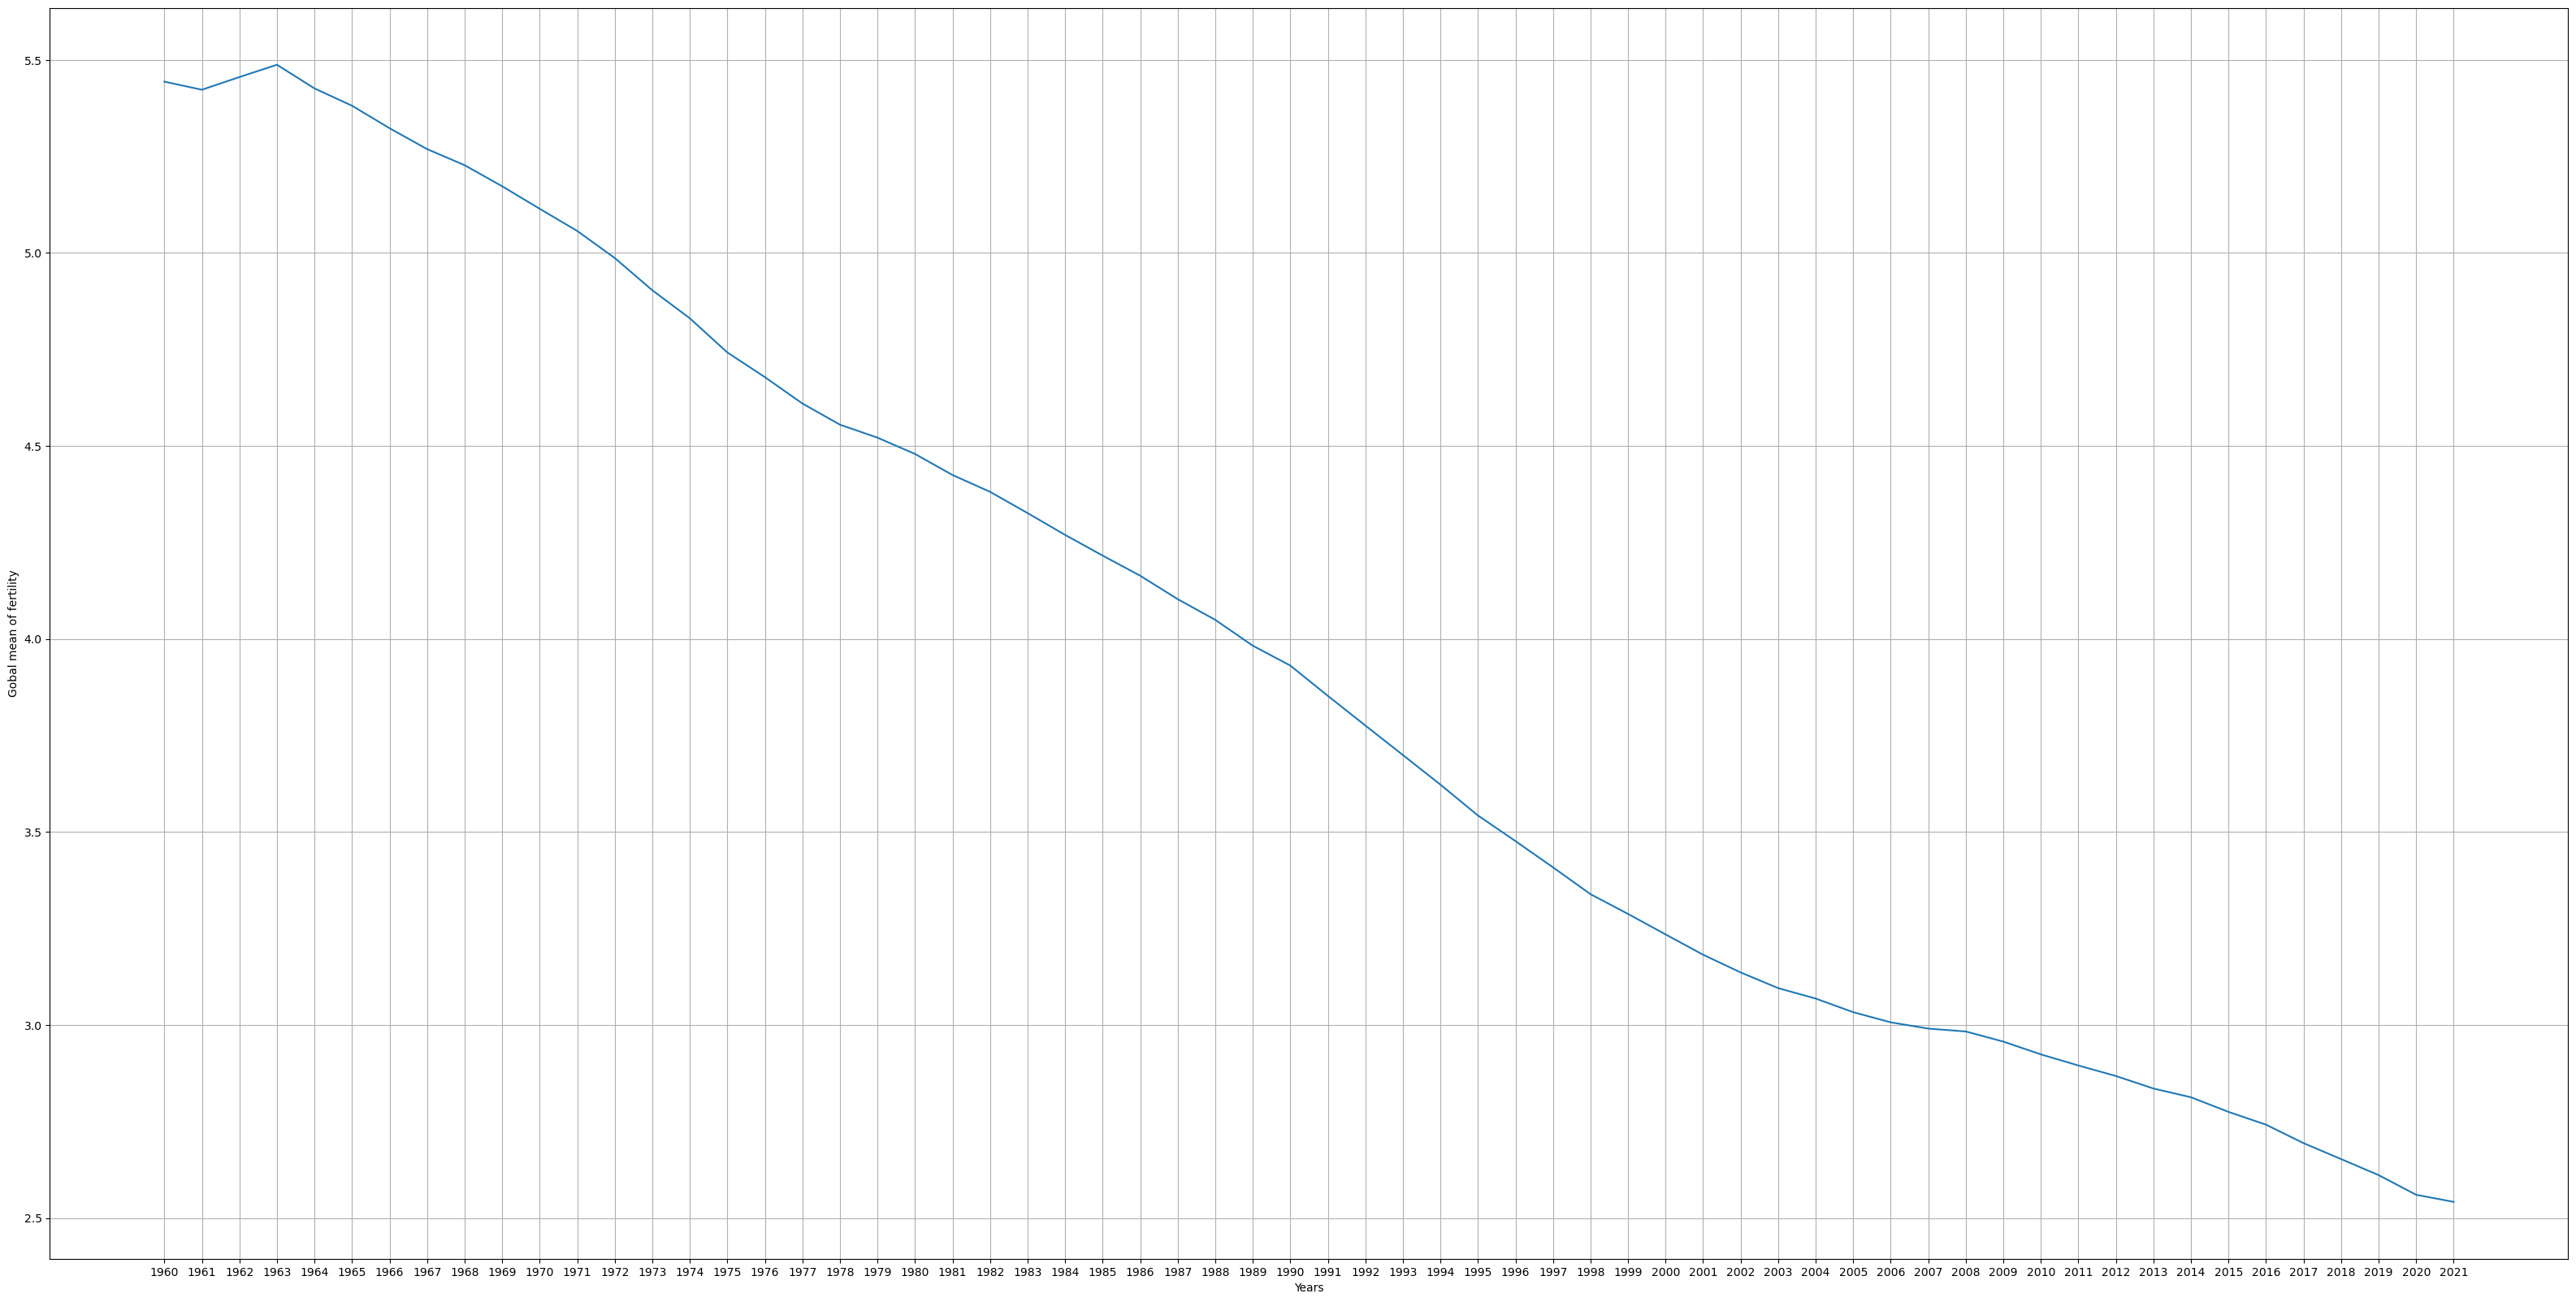

In [10]:
plt.figure(figsize=(40,20))
plt.grid()
plt.xlabel("Years")
plt.ylabel("Gobal mean of fertility")
sns.lineplot(data=global_df_T['mean'])

In [11]:
df_T = df.T

/tmp/ipykernel_20/3192731082.py:2: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(30,15))


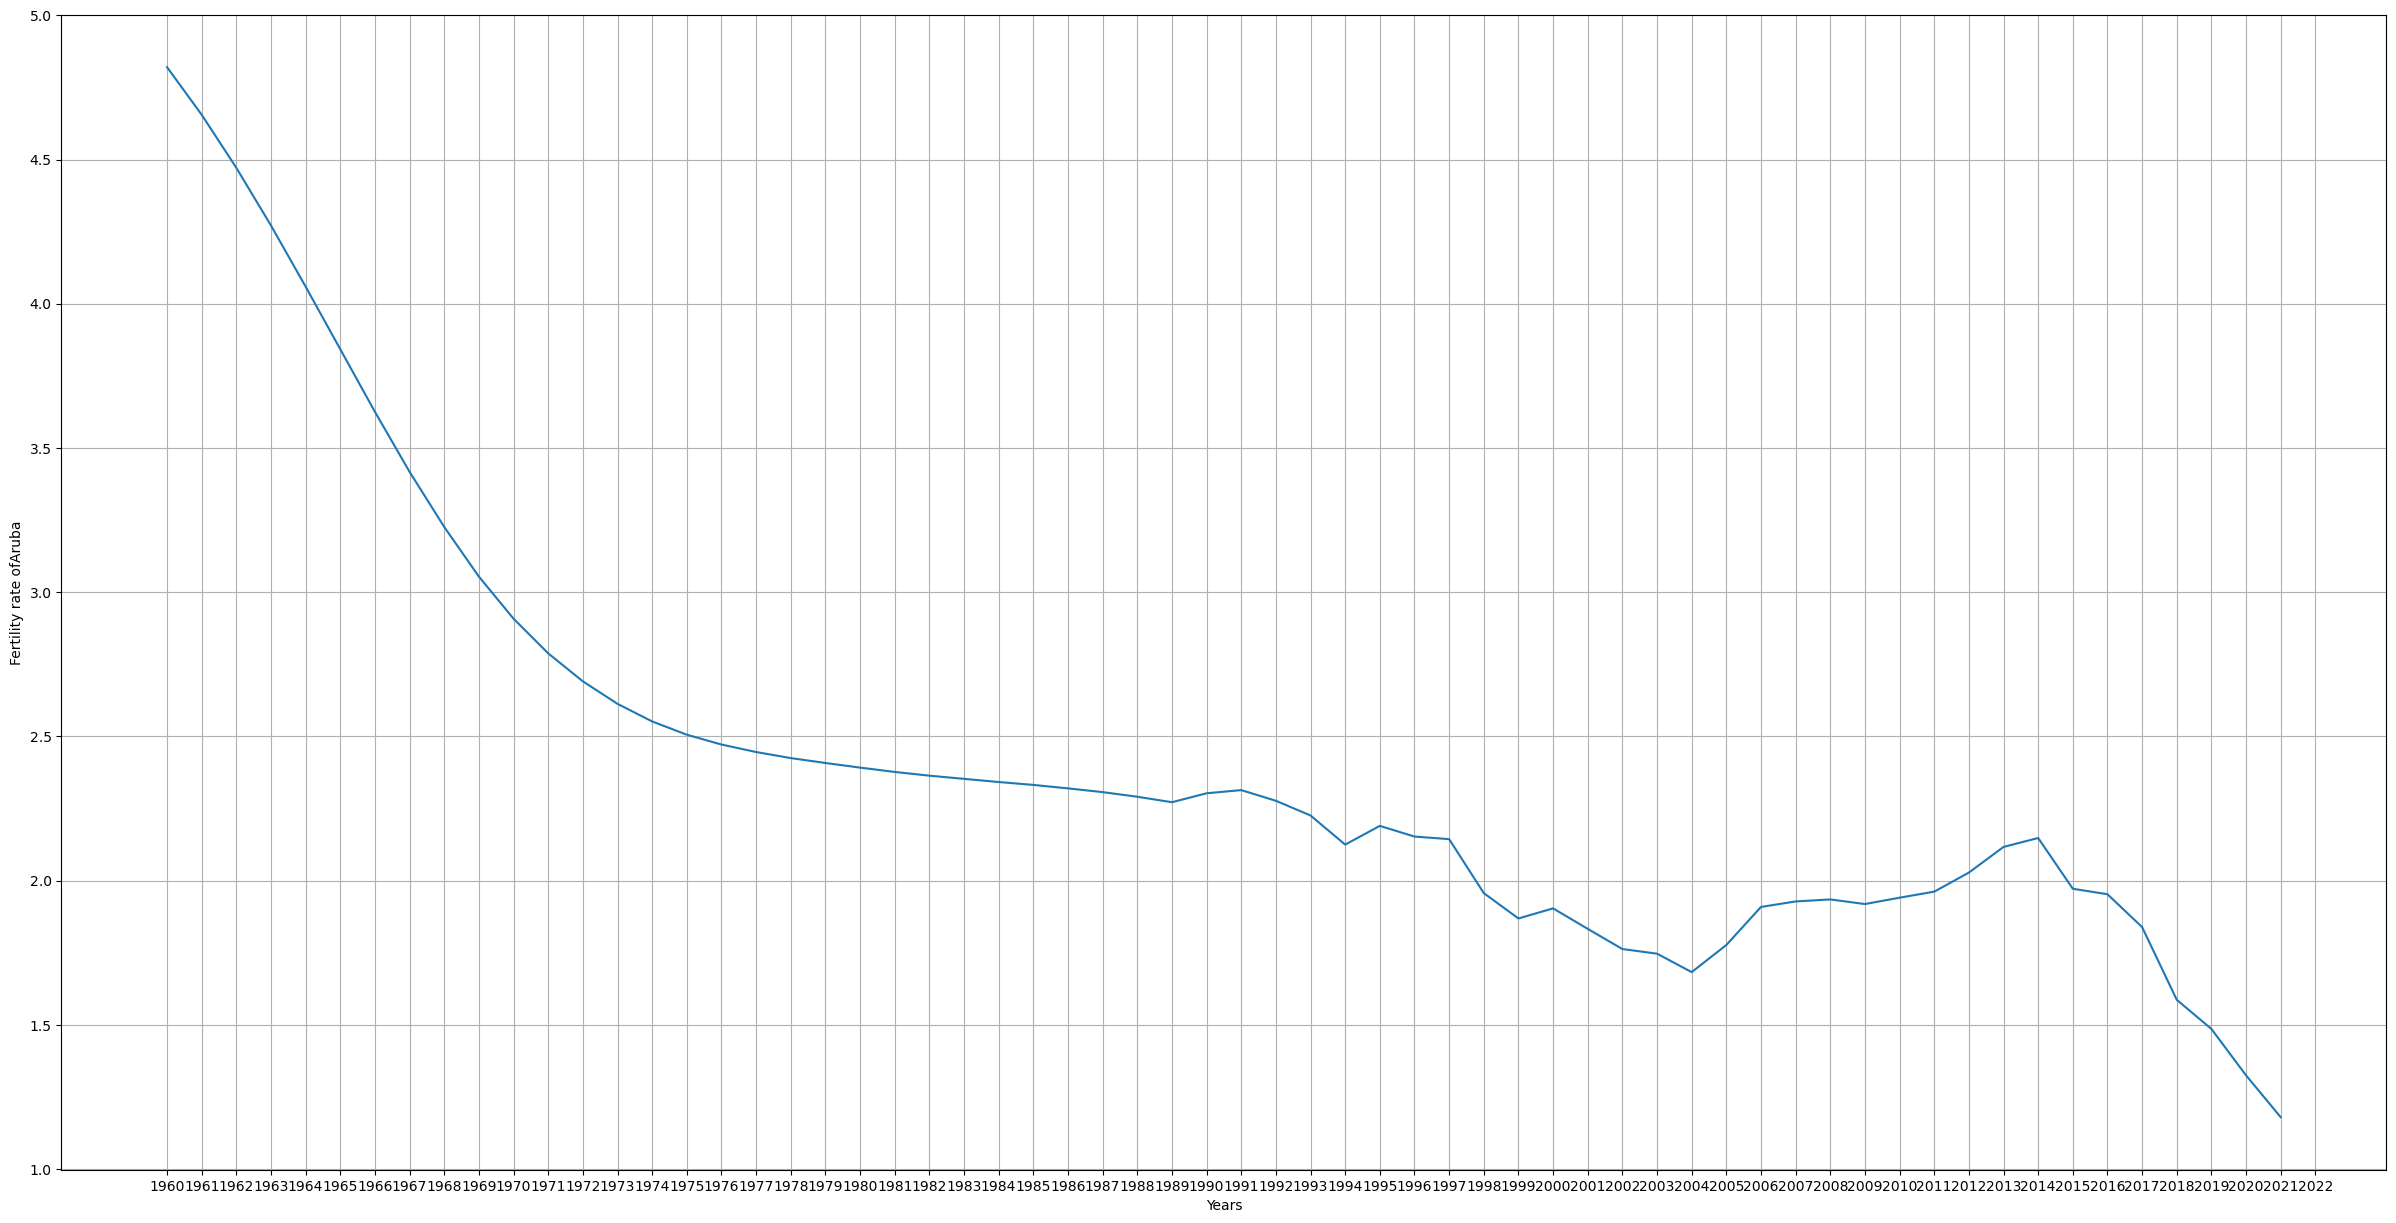

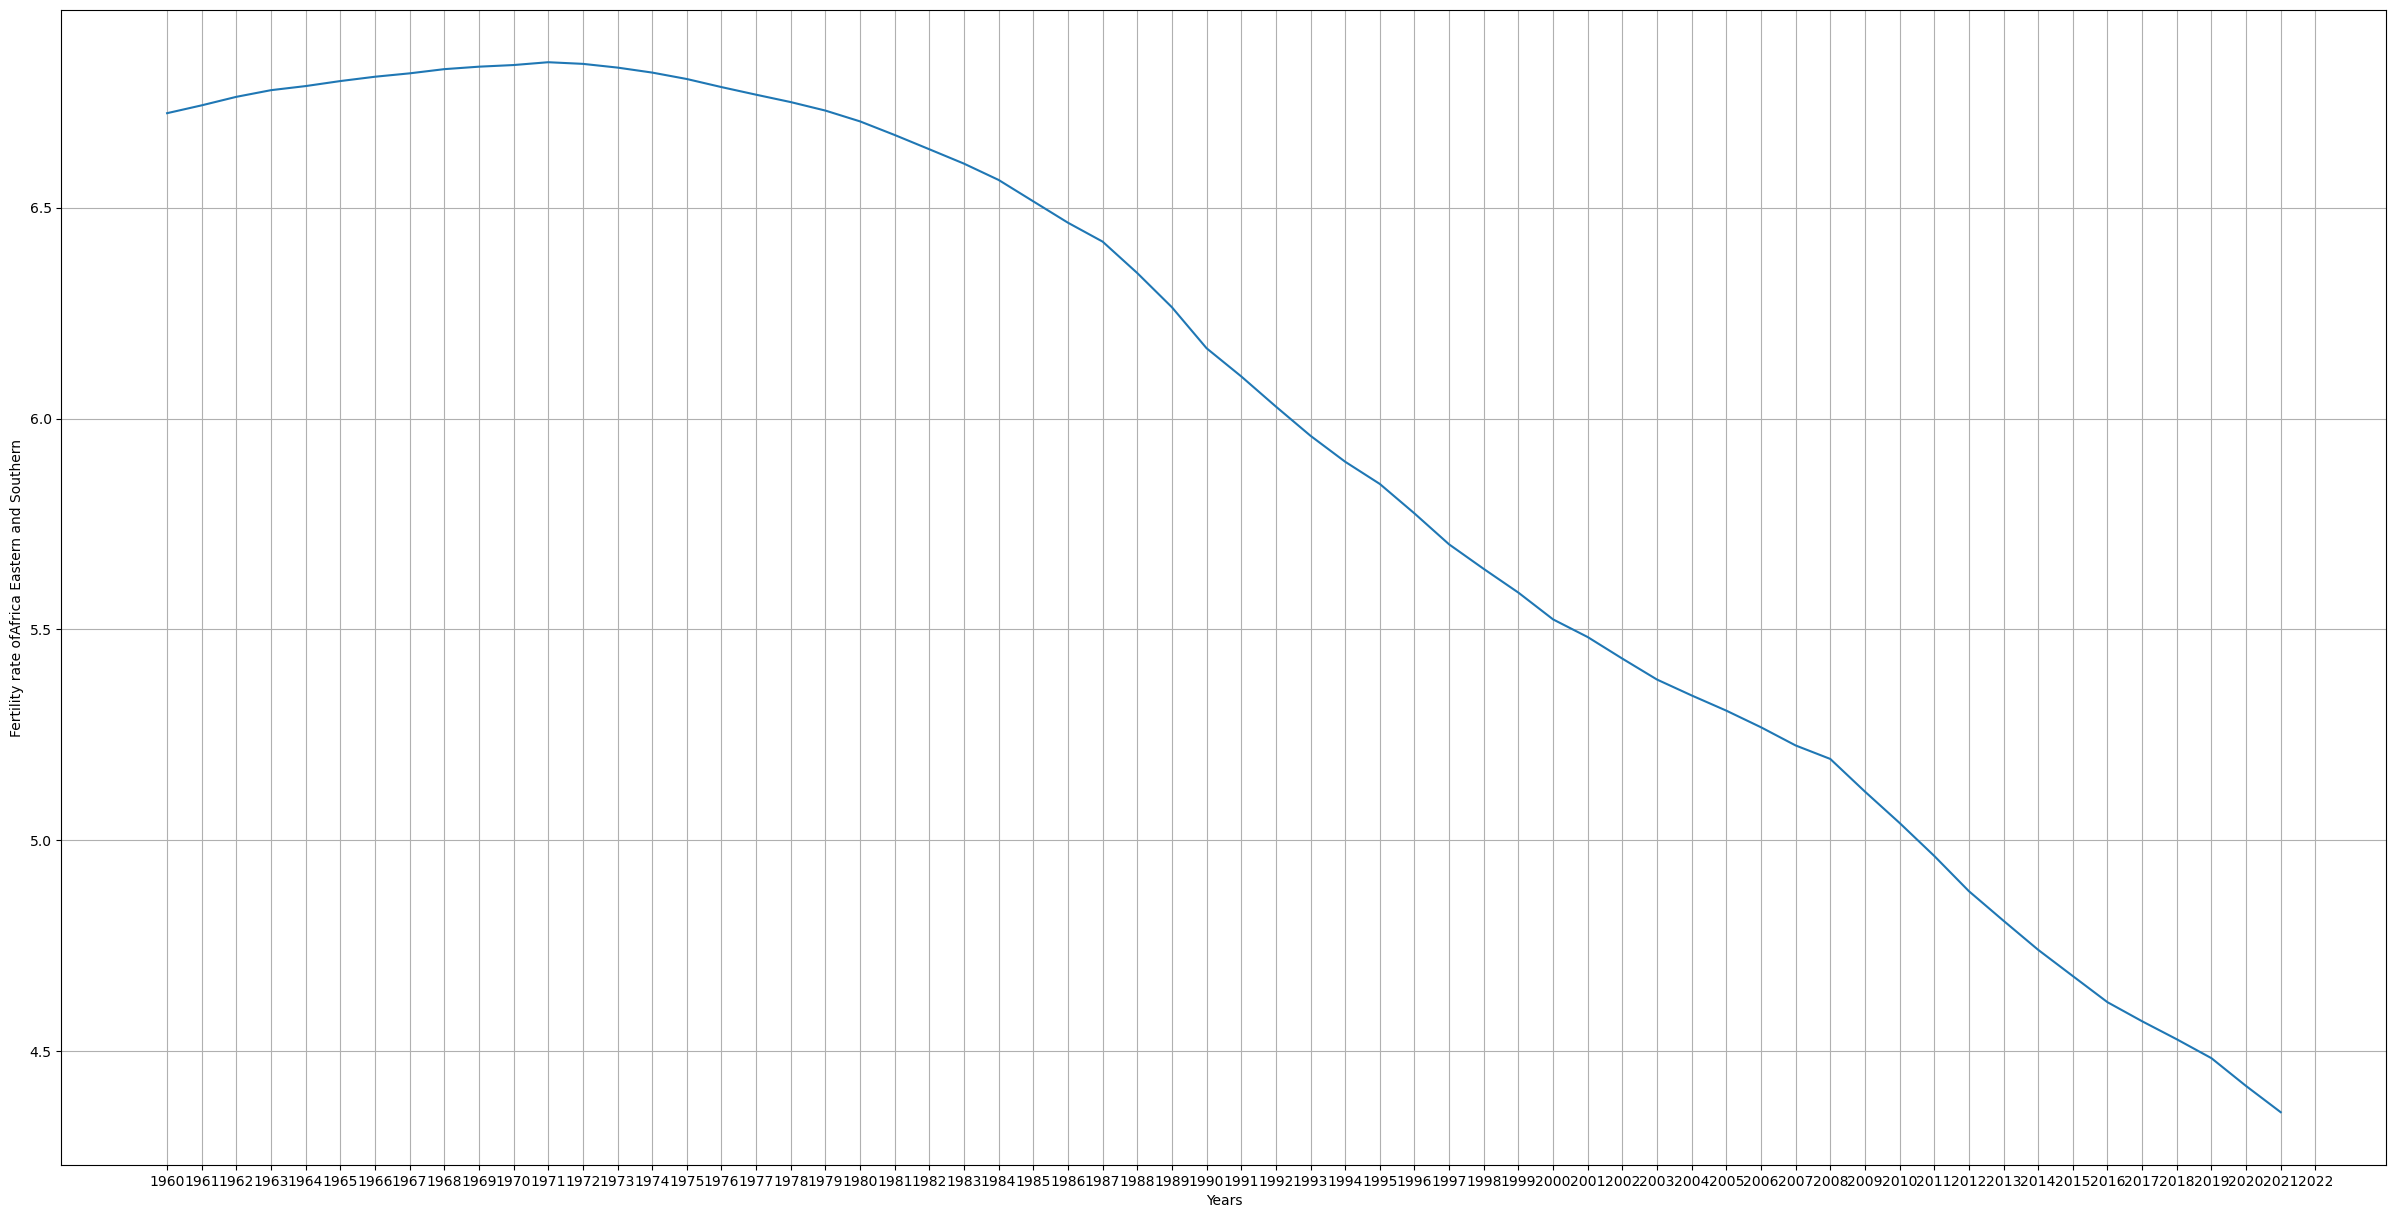

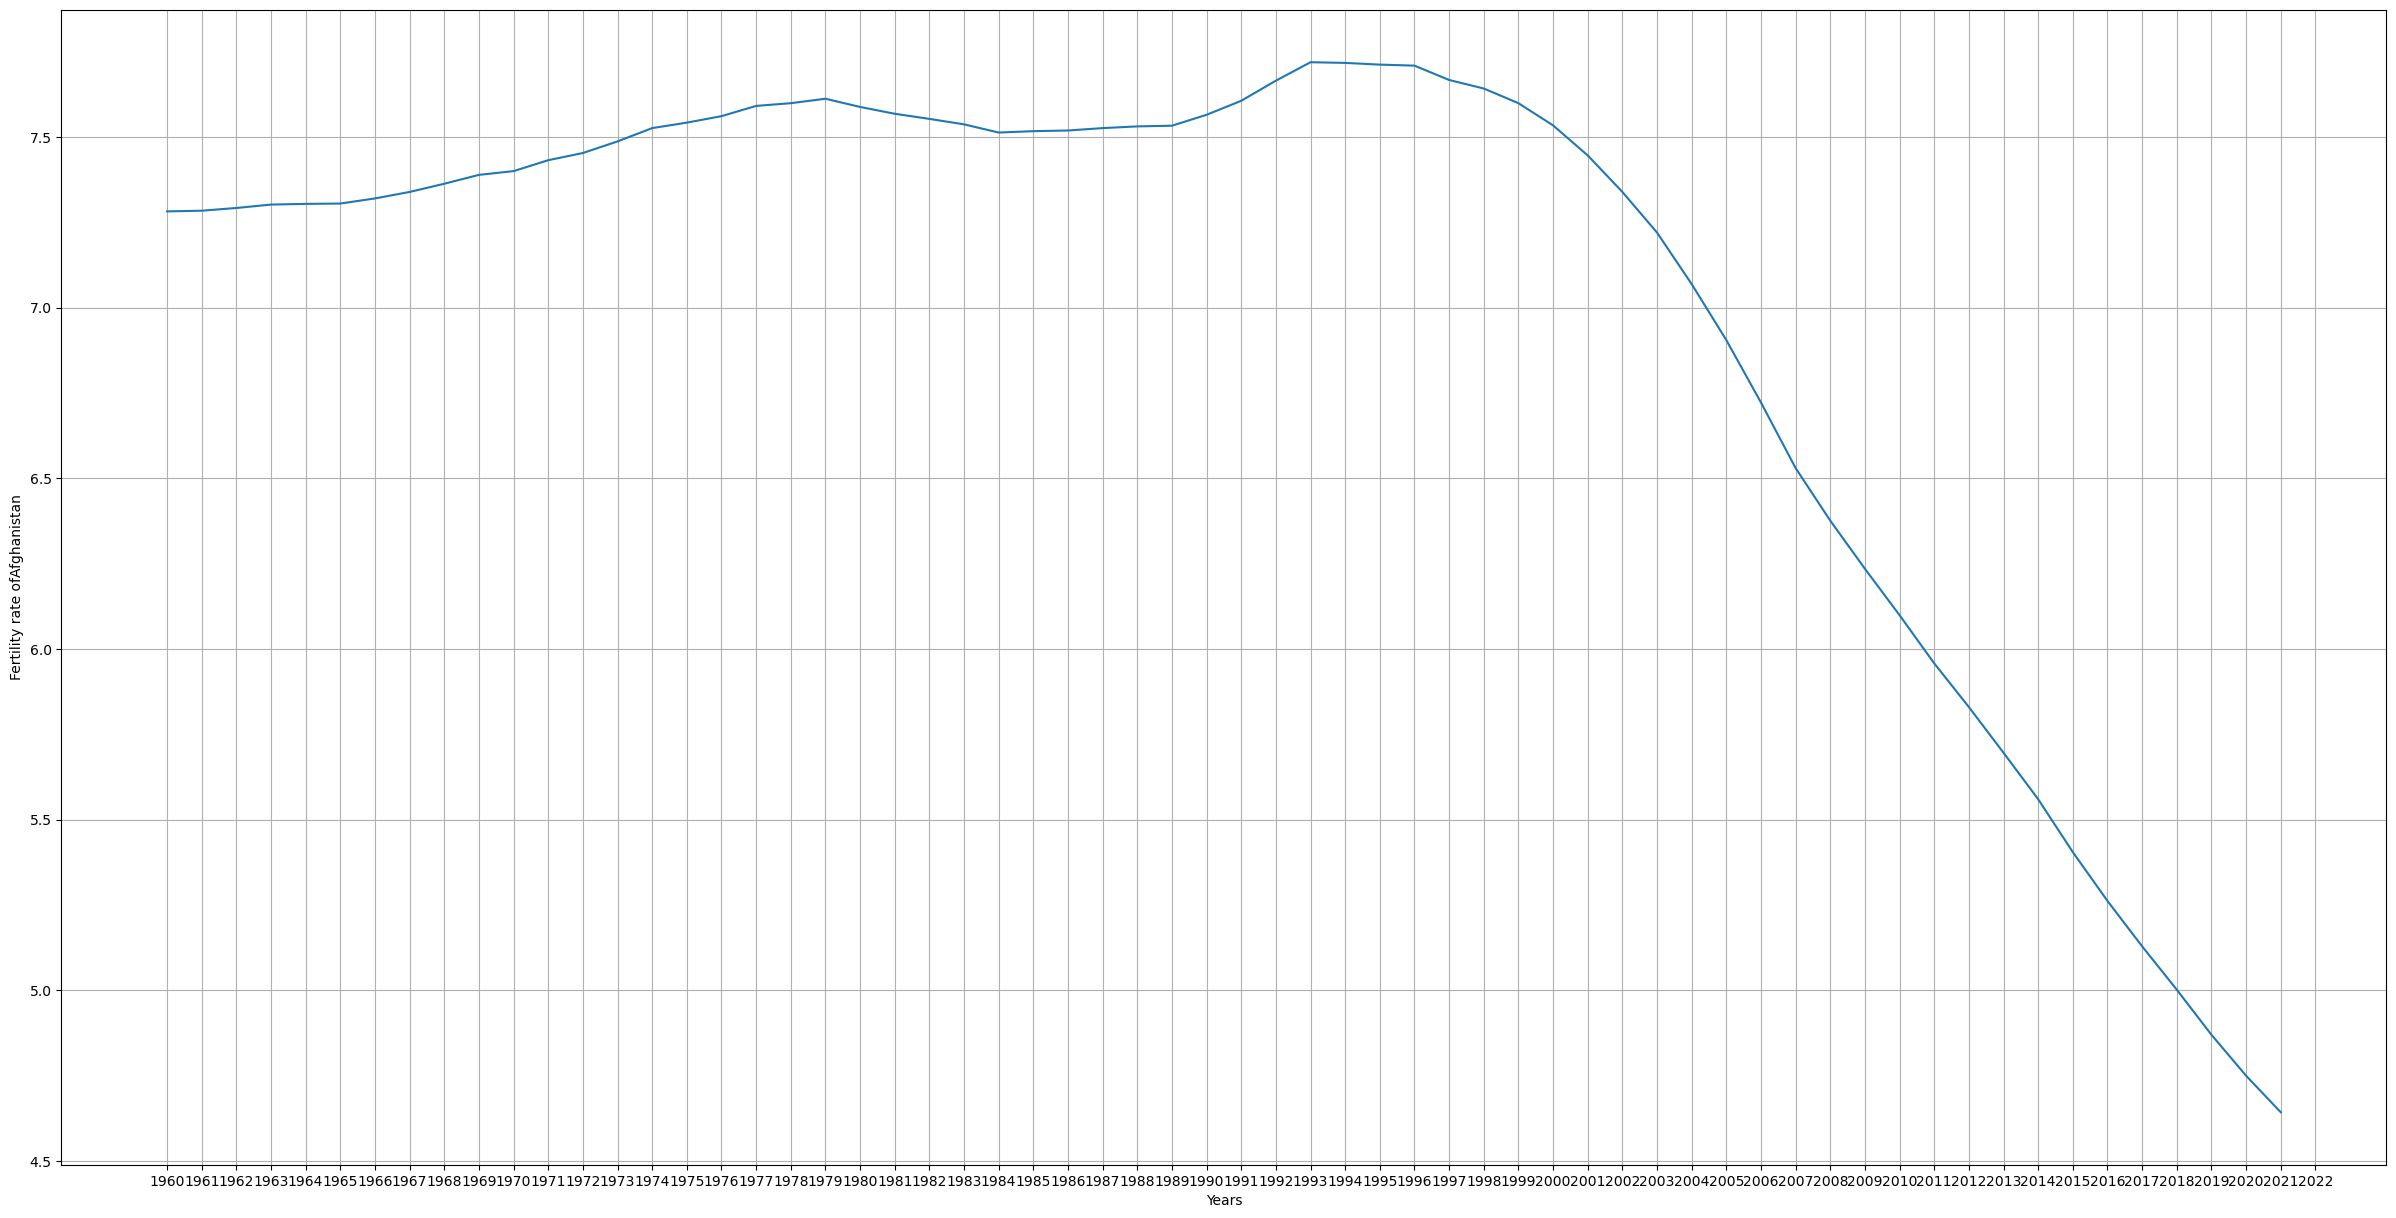

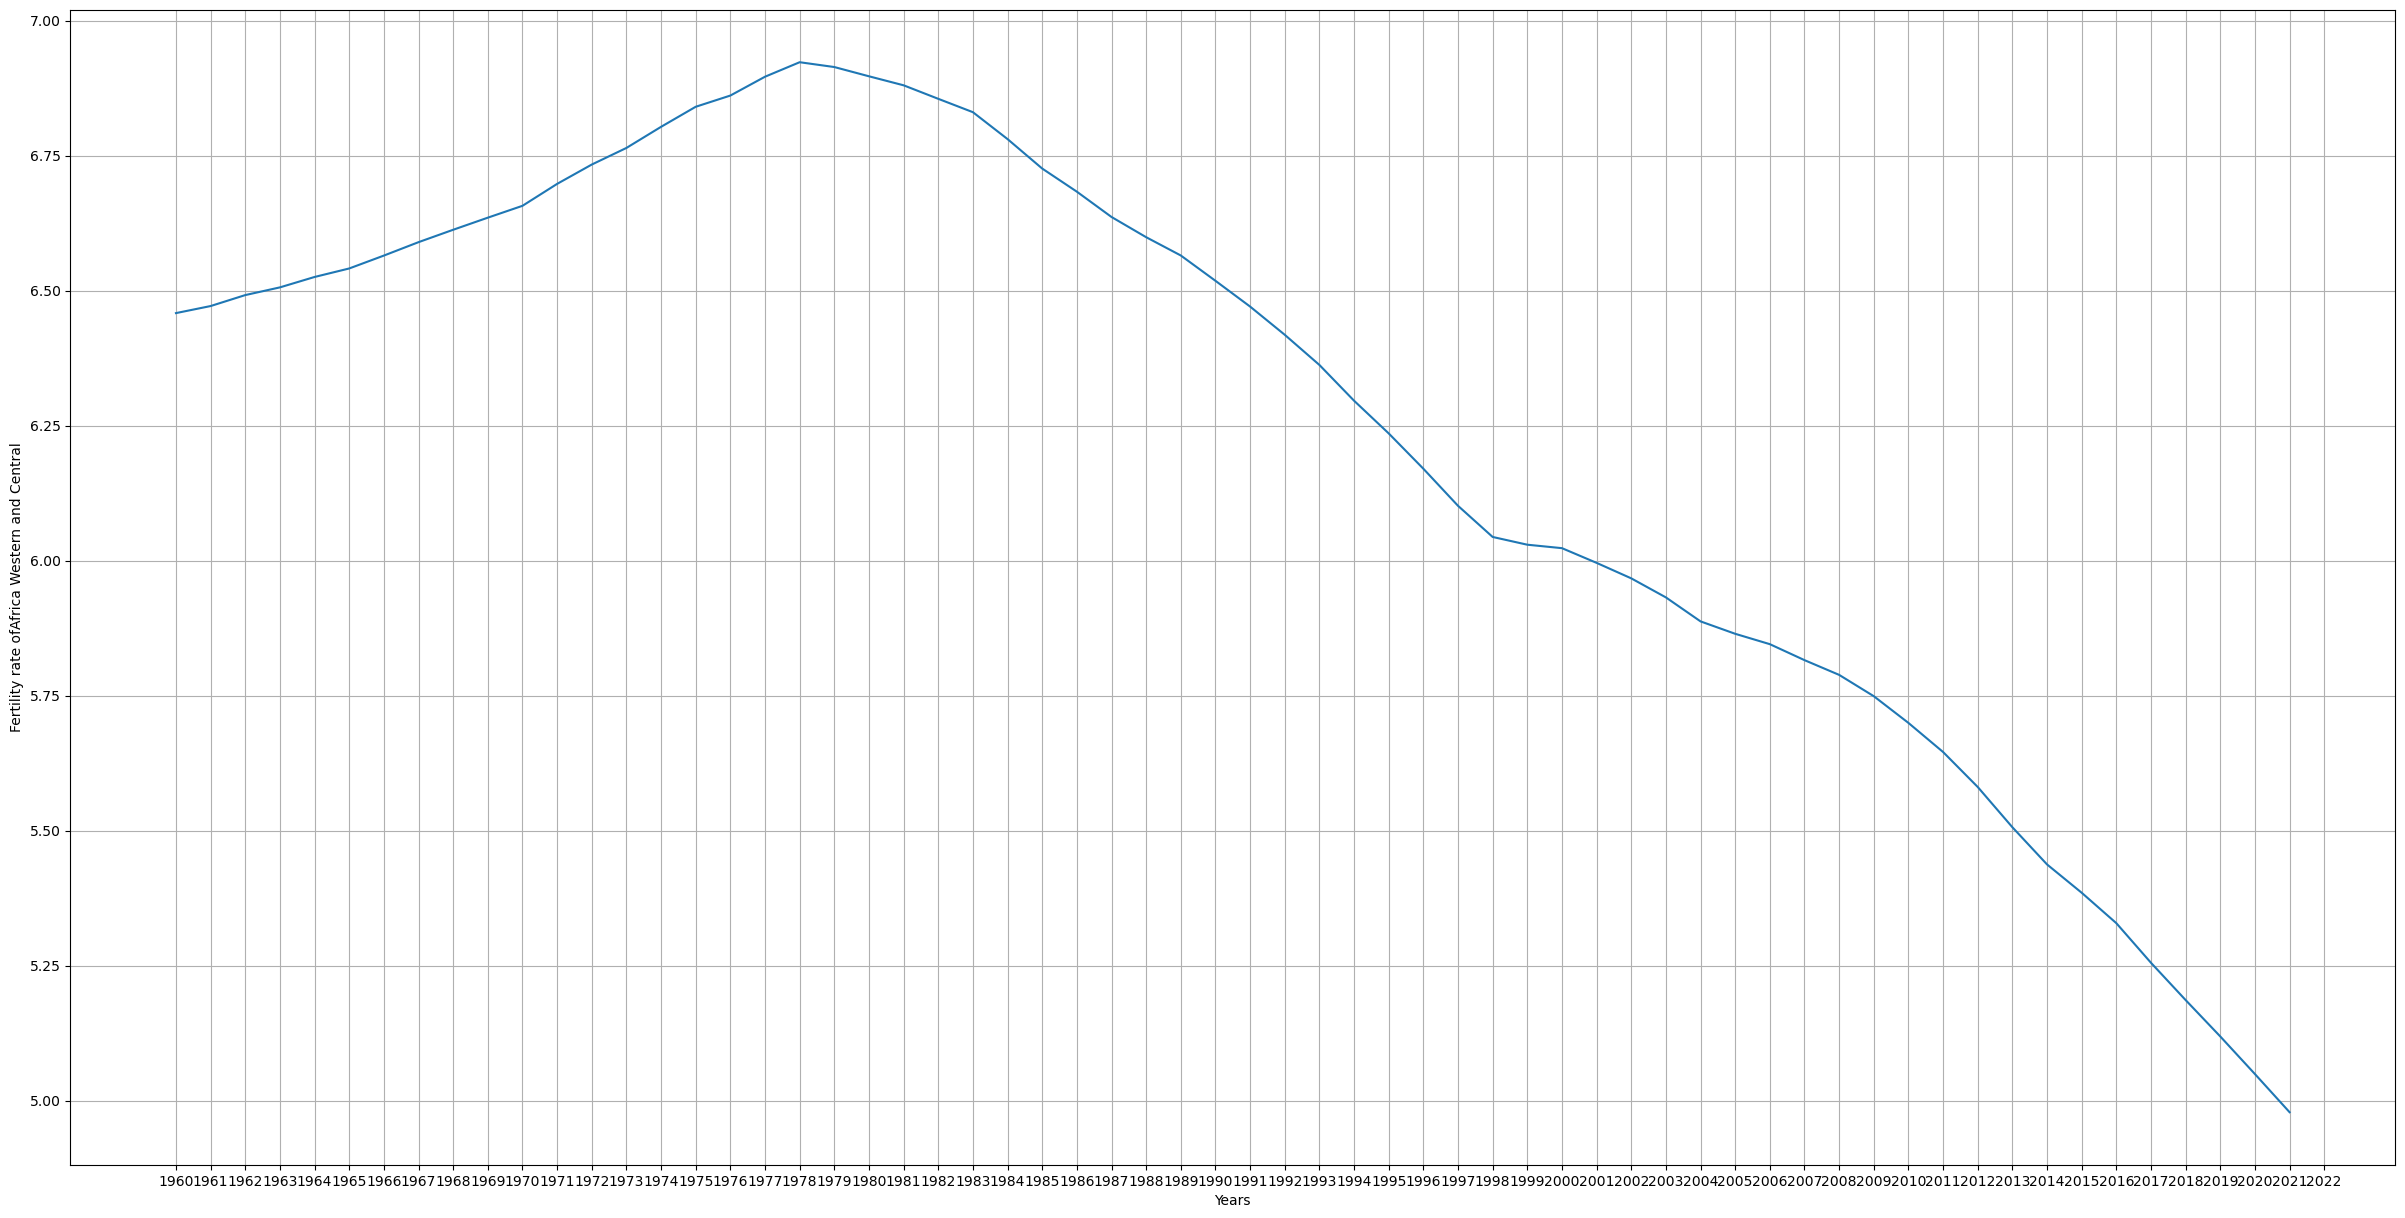

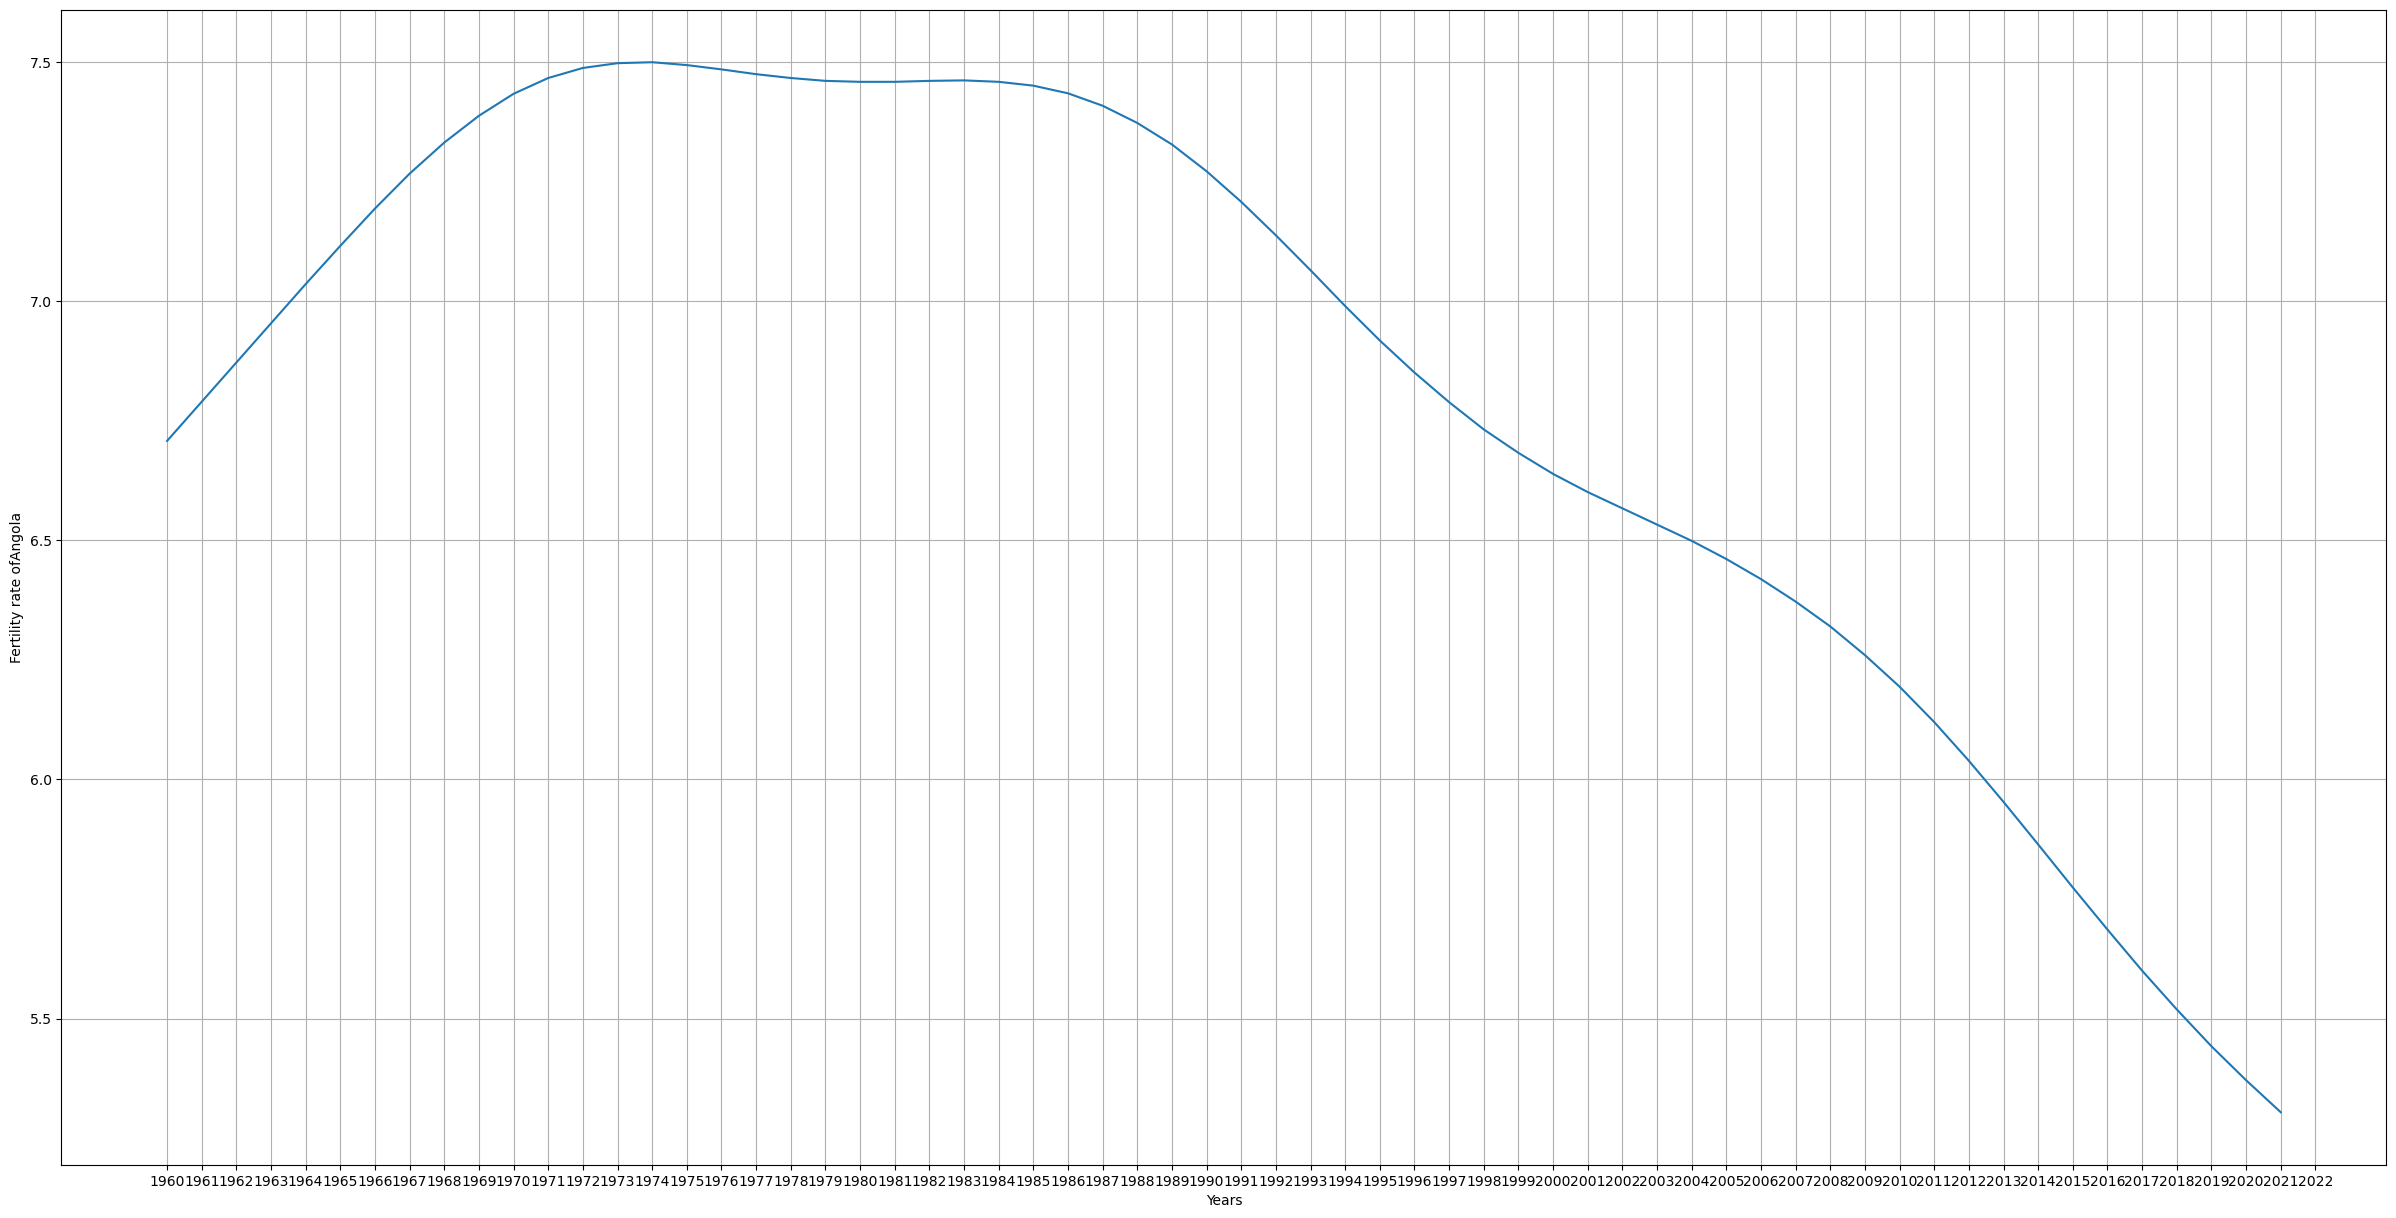

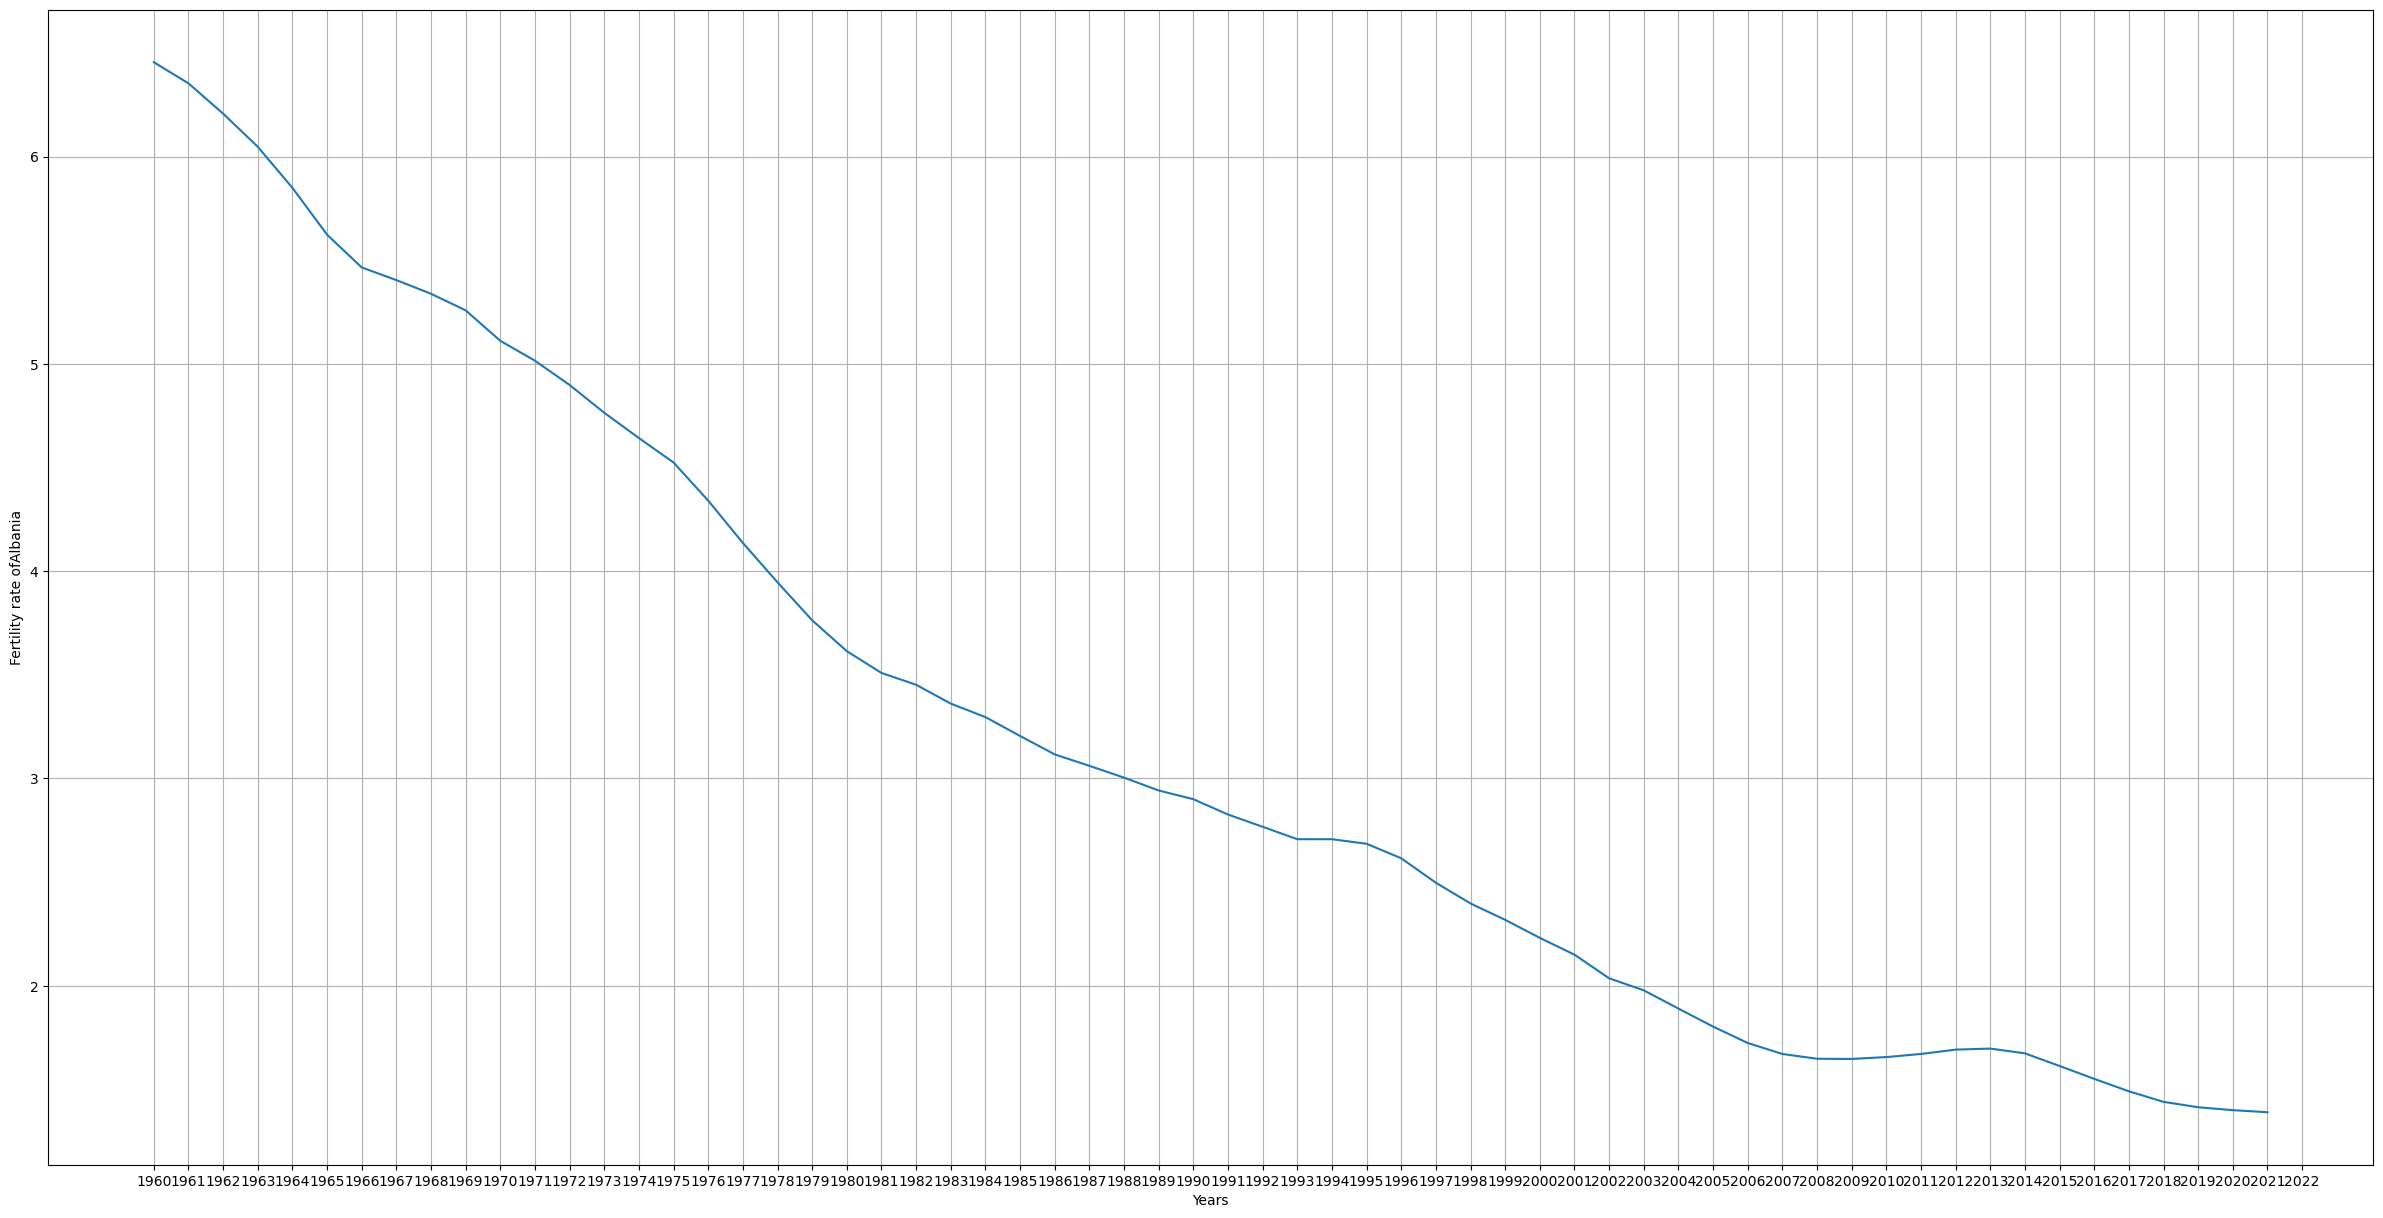

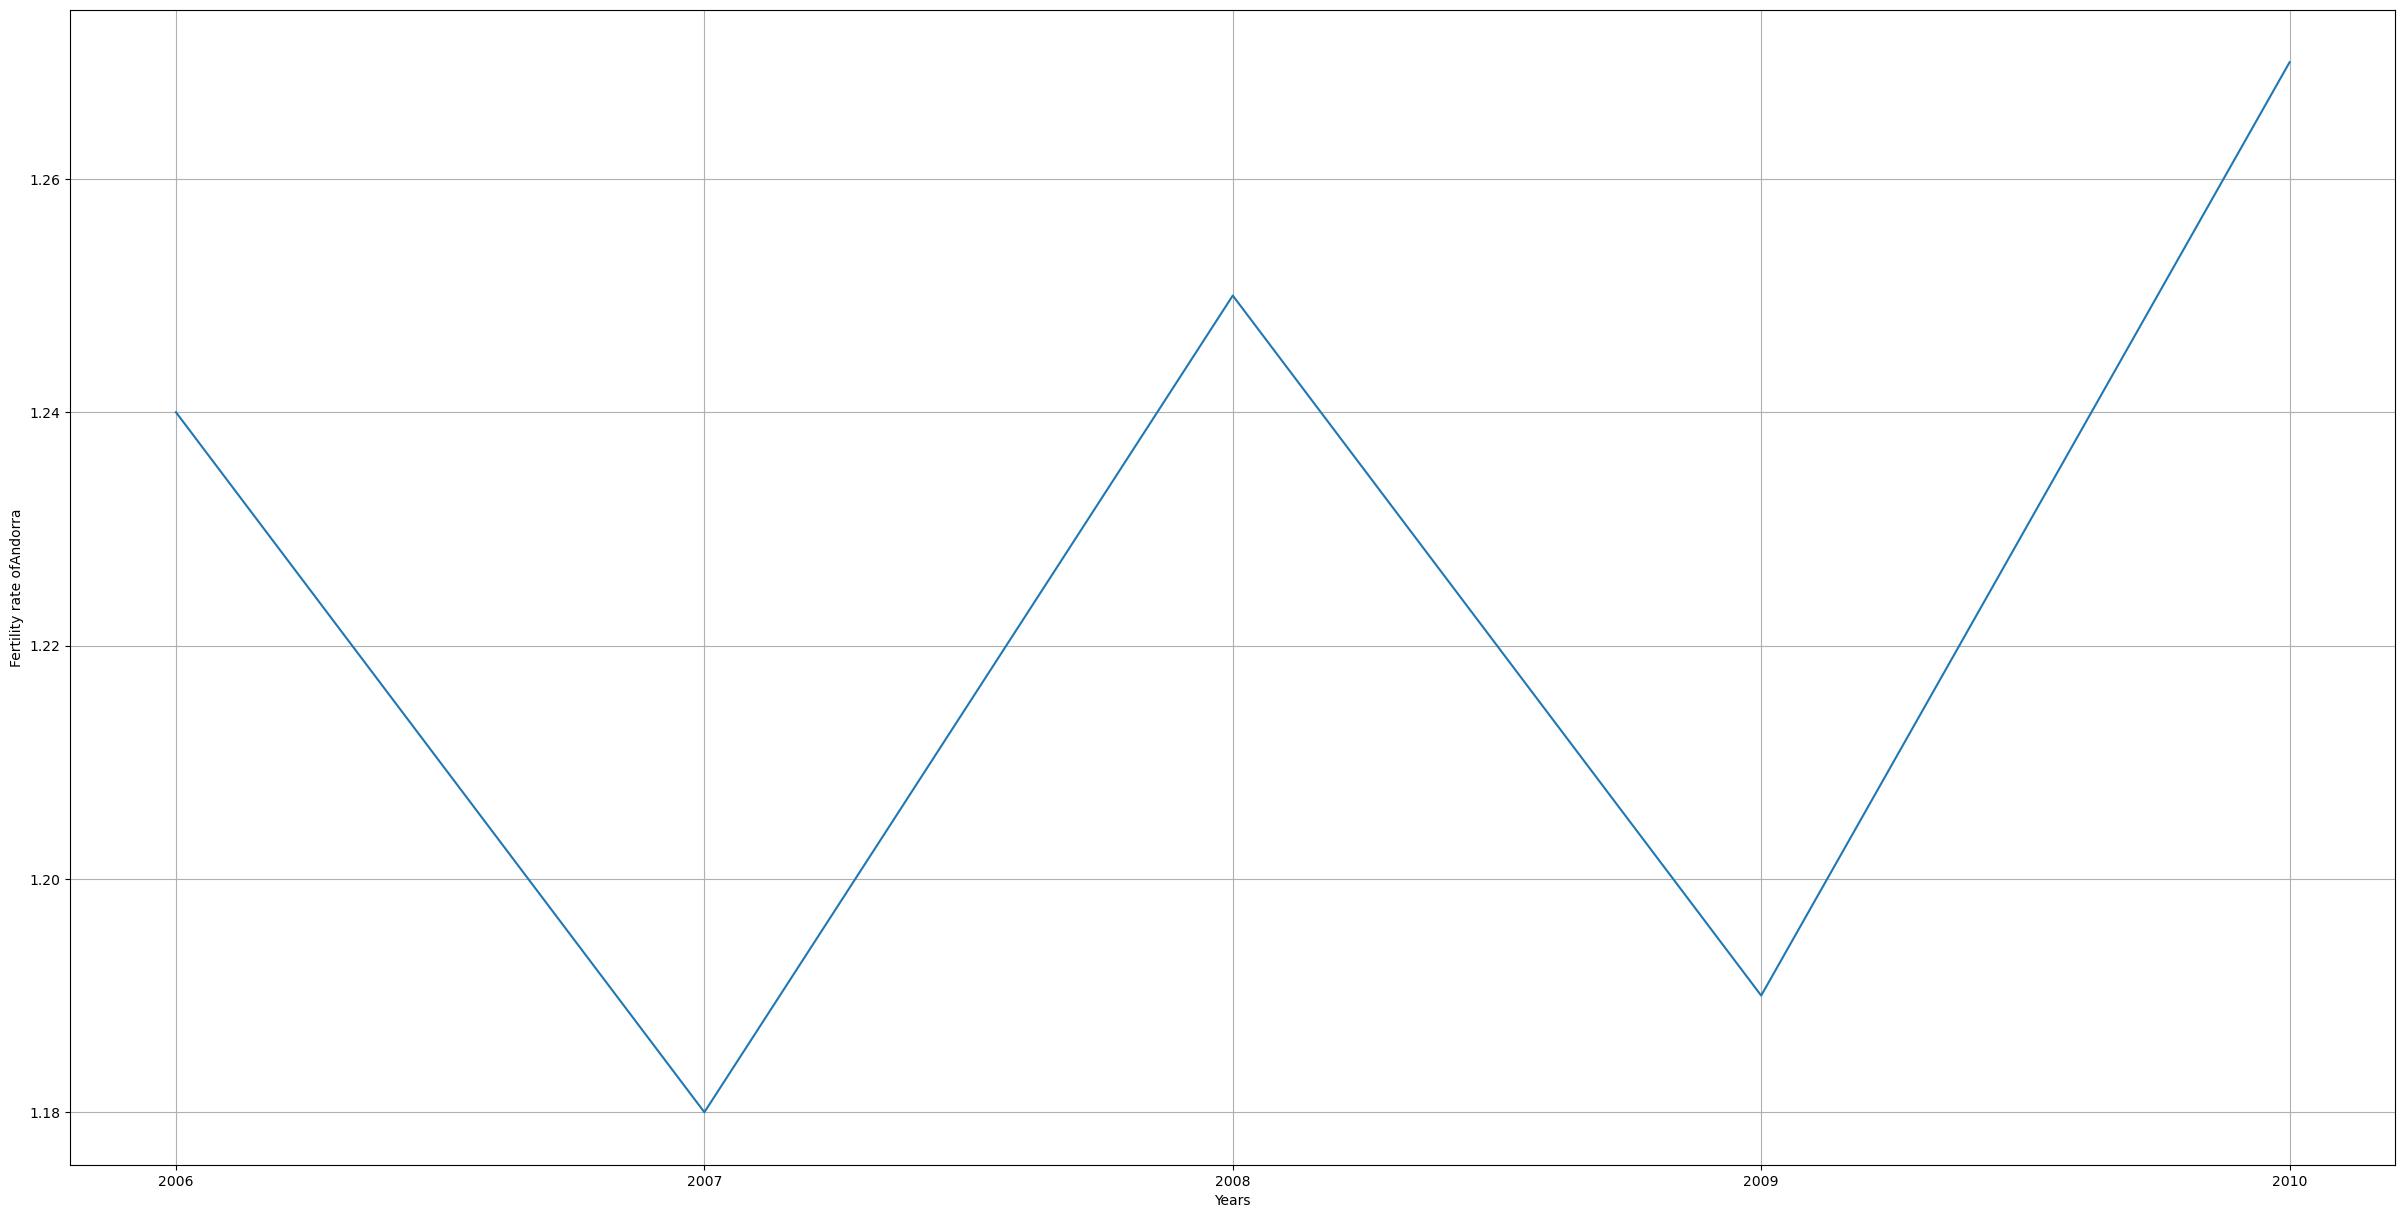

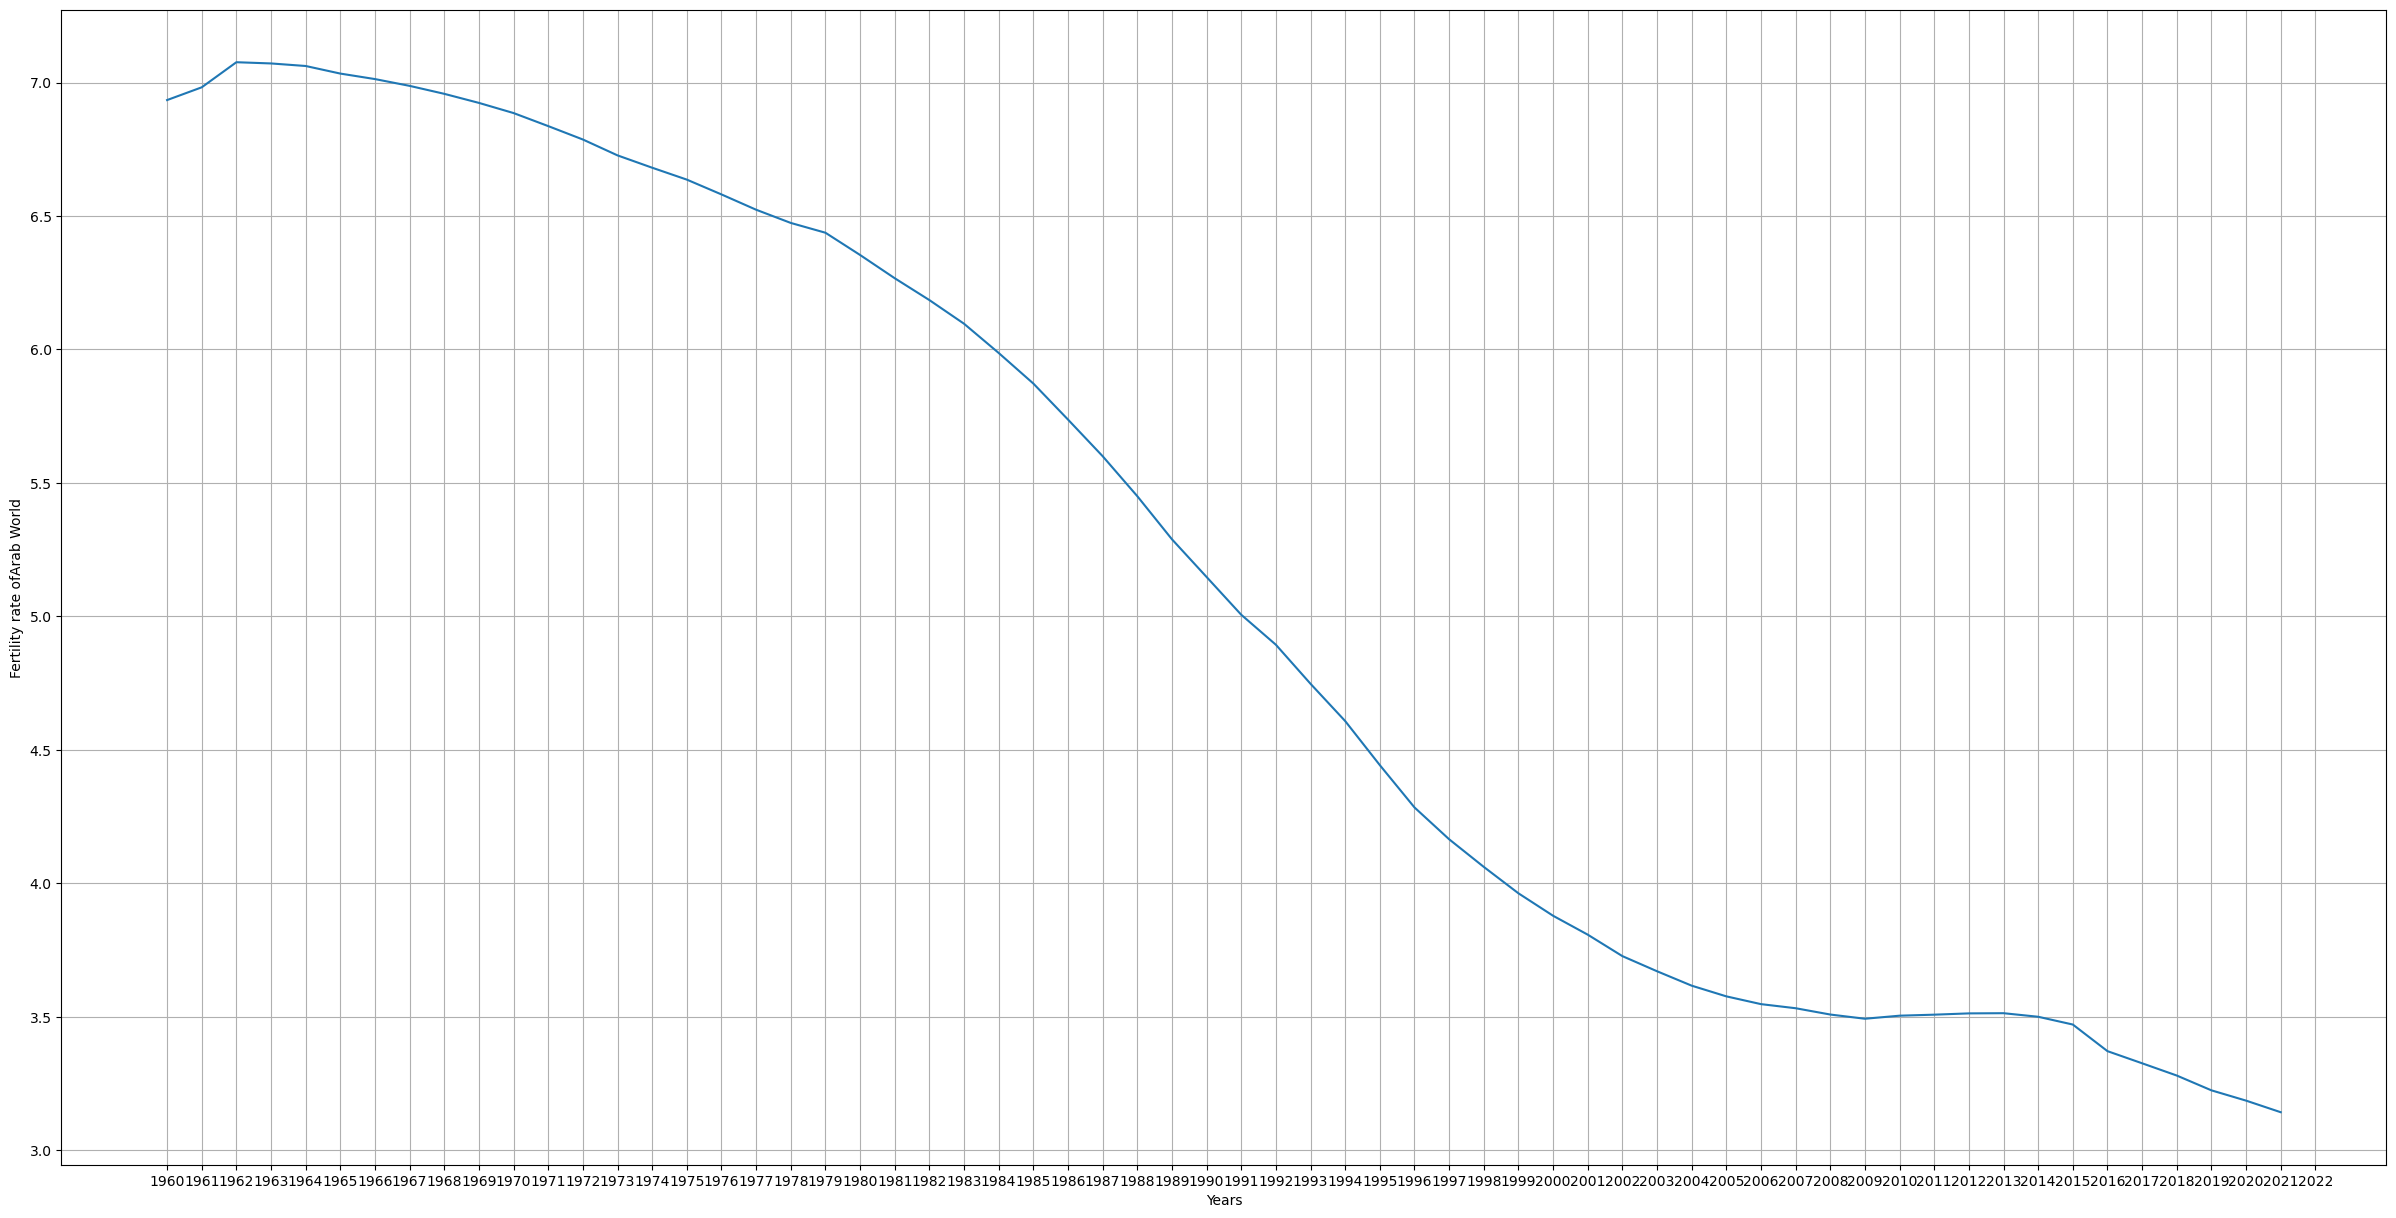

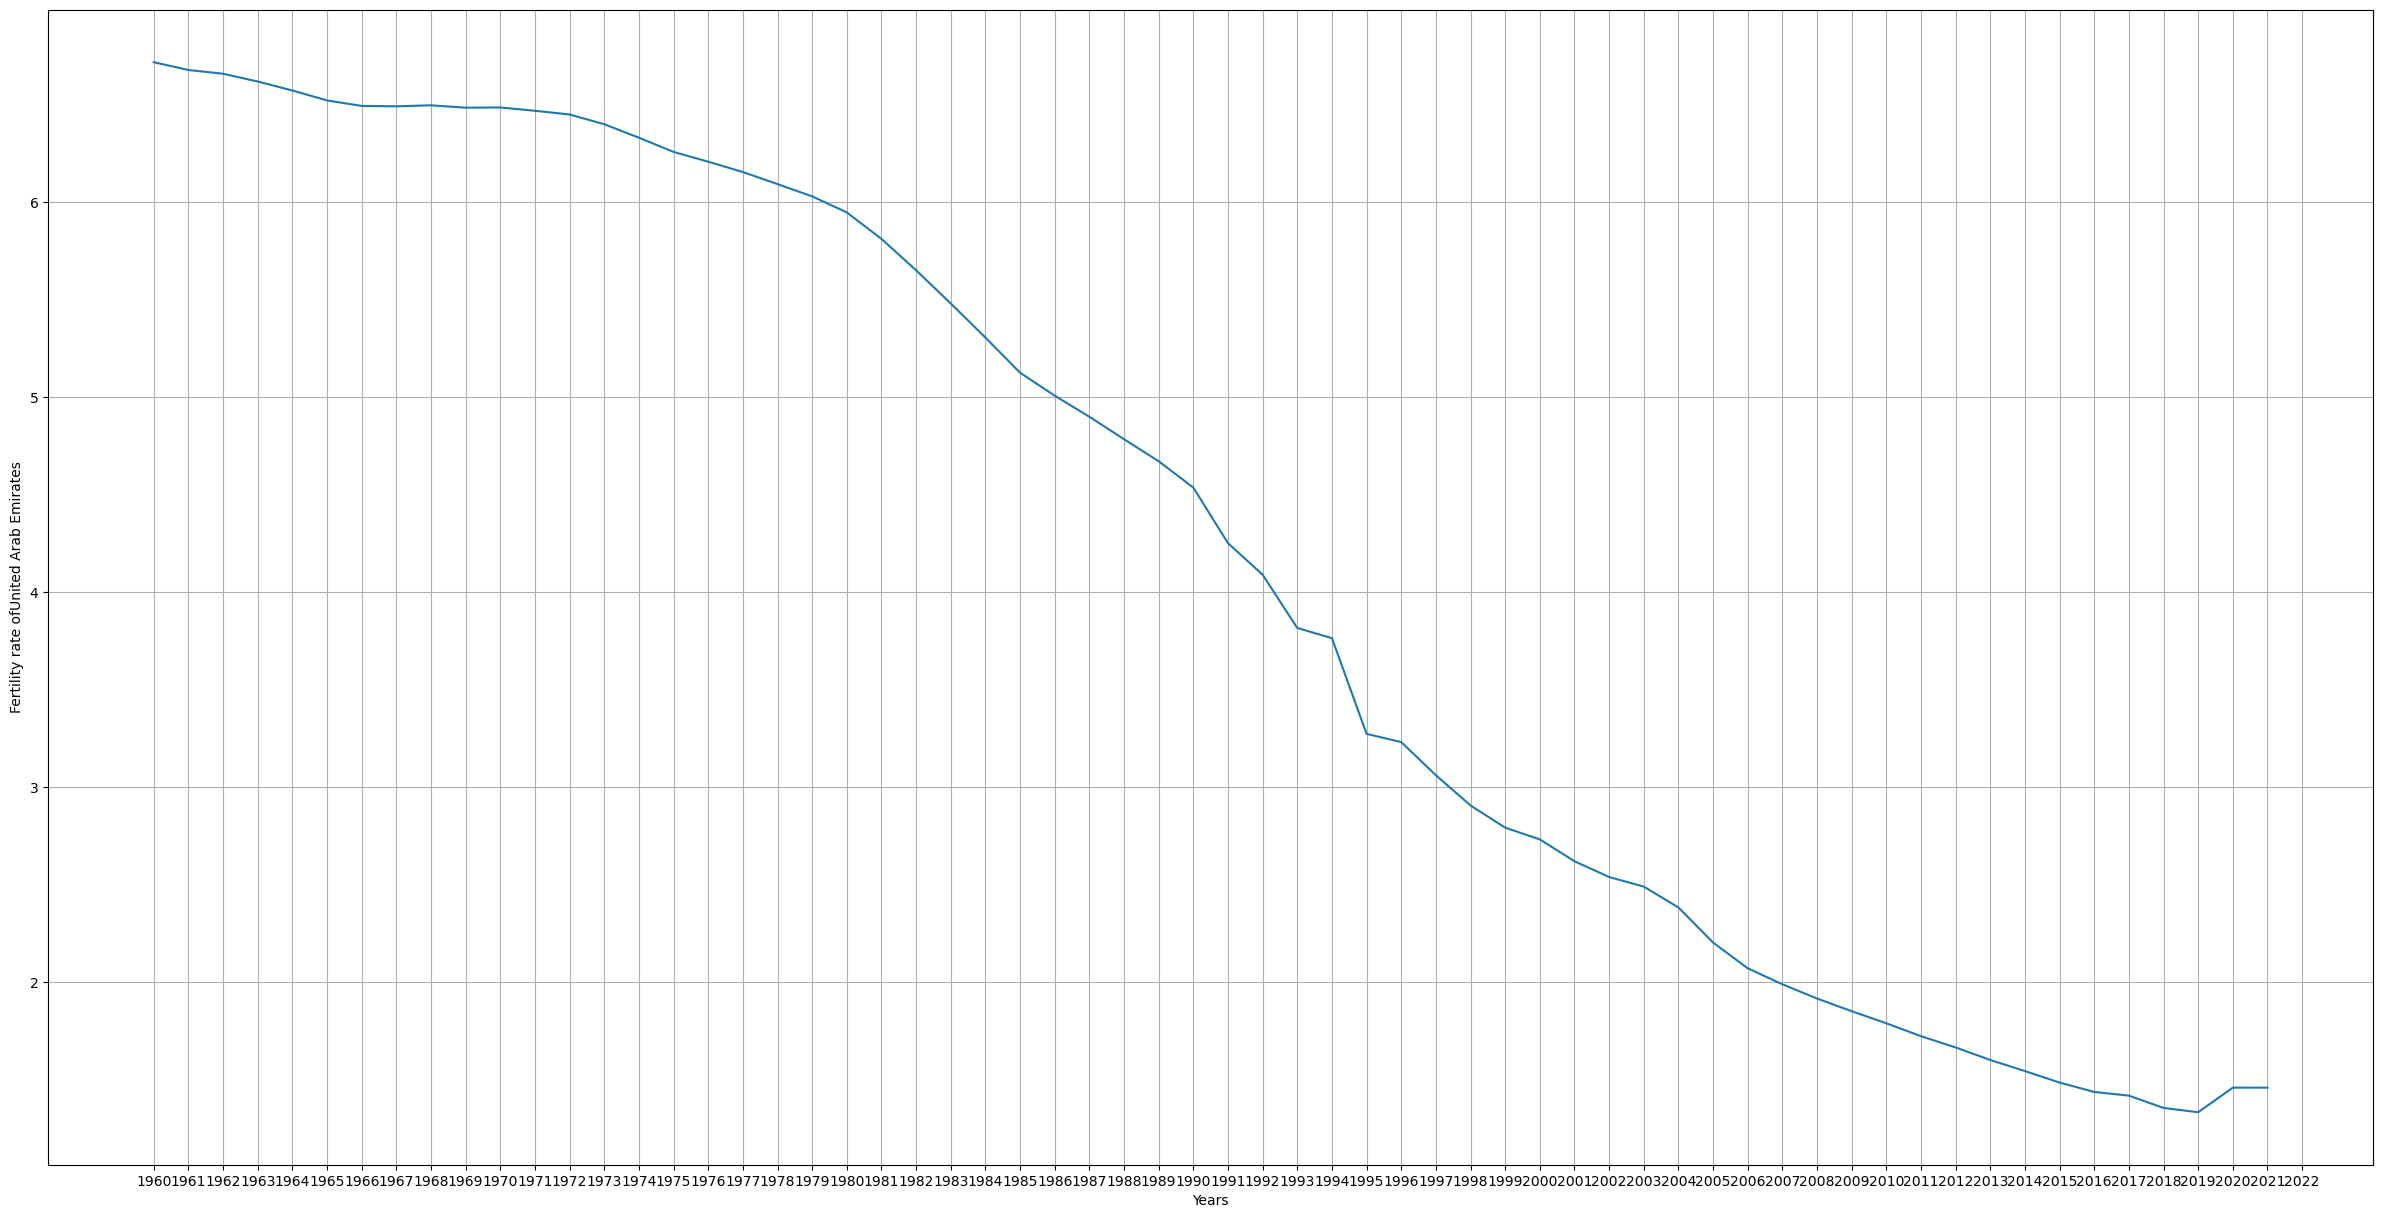

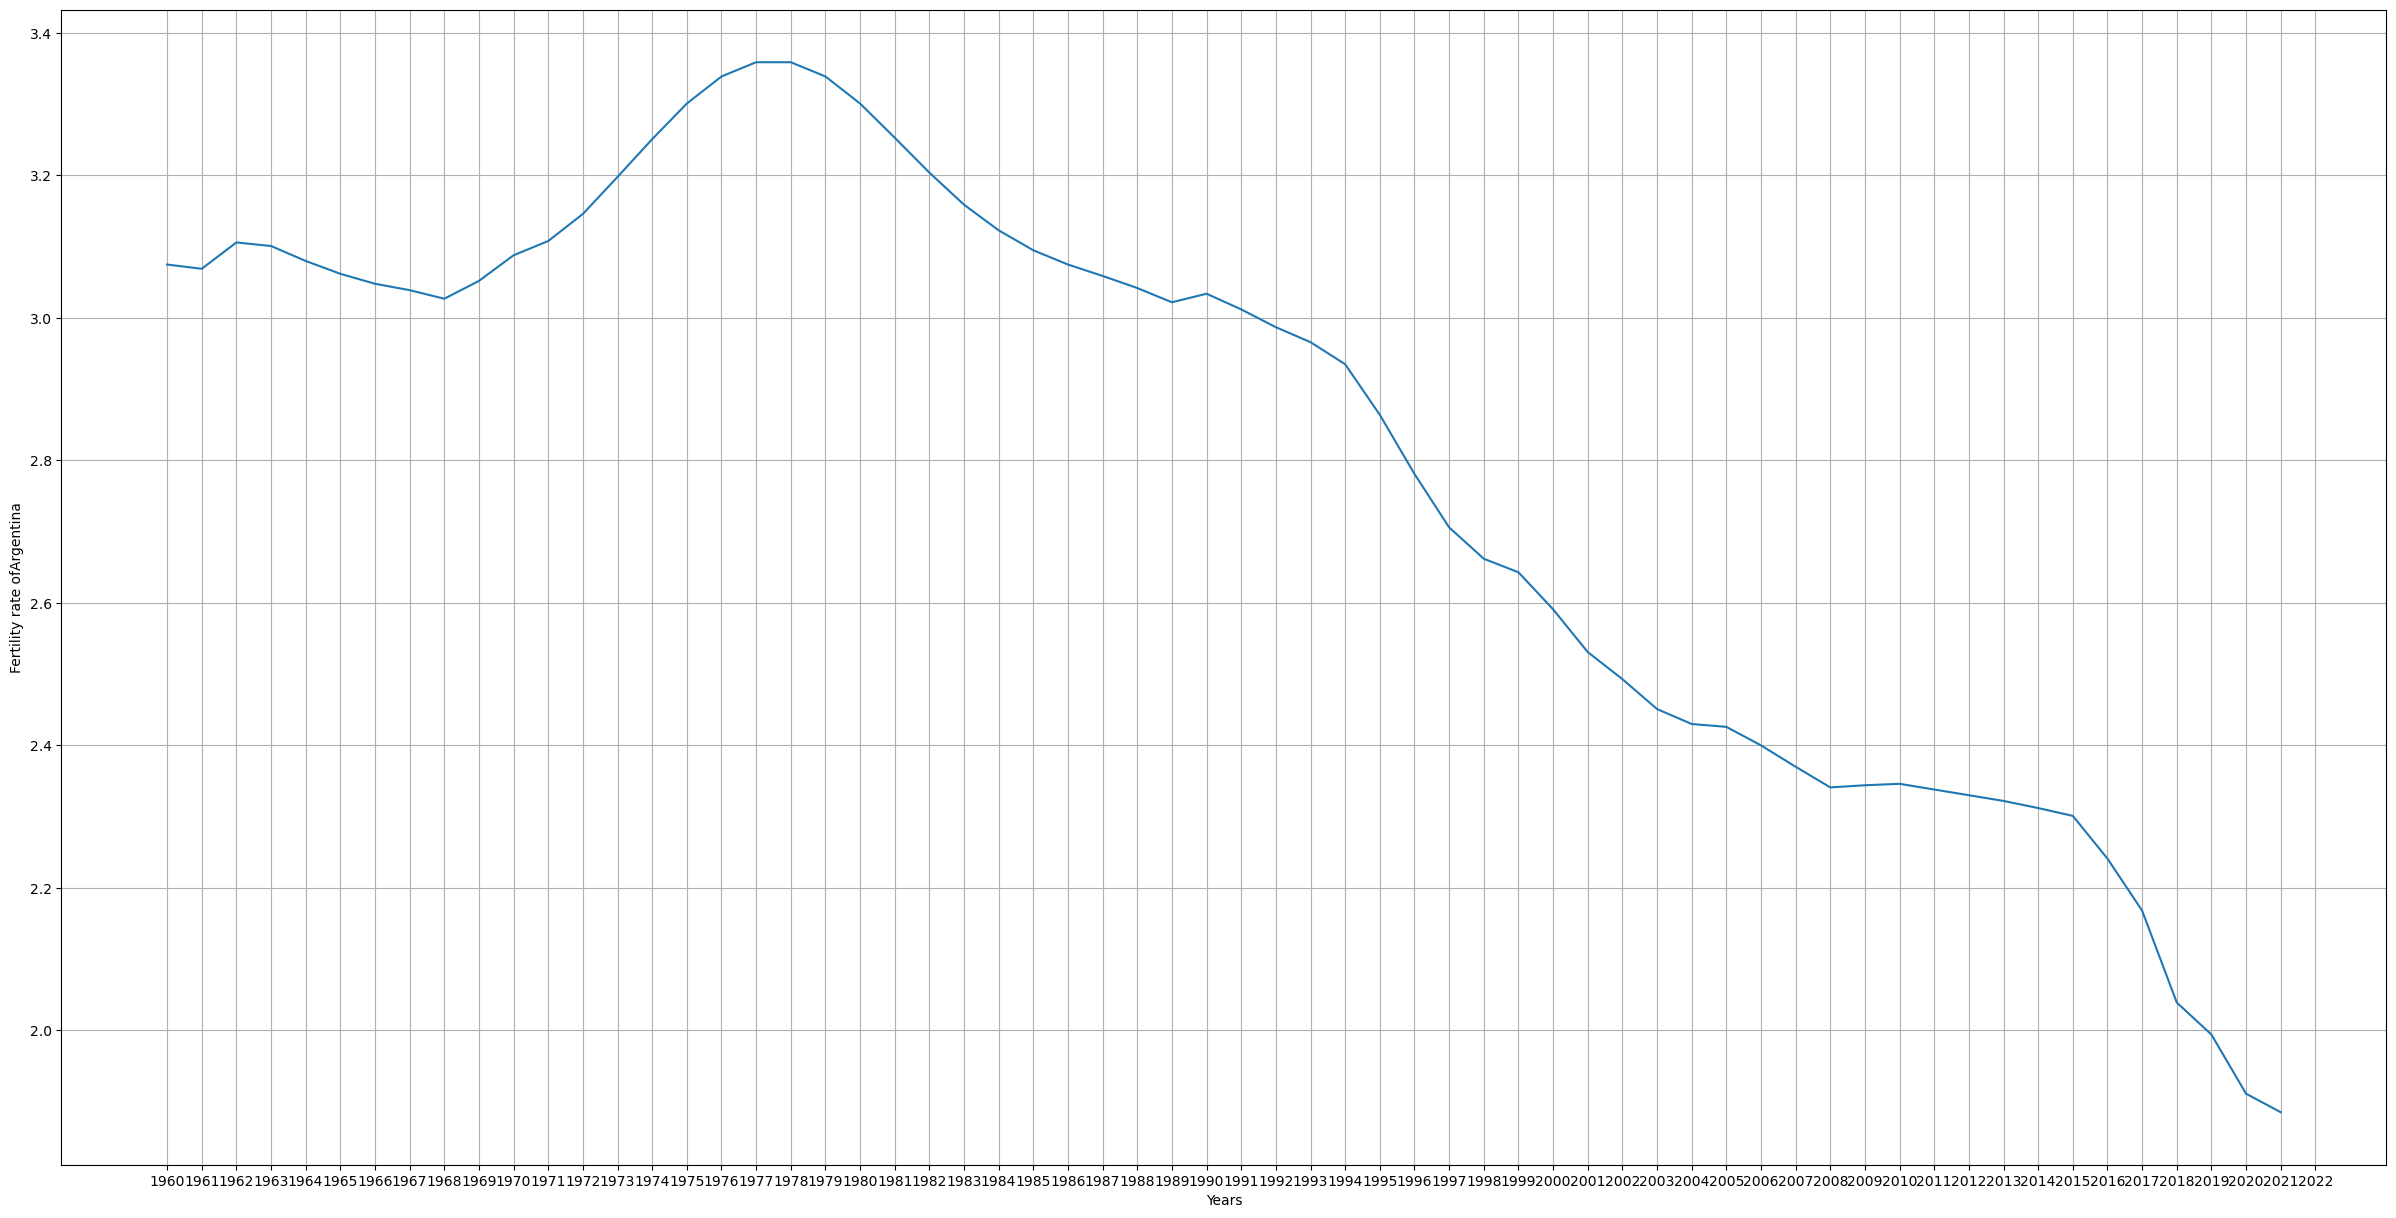

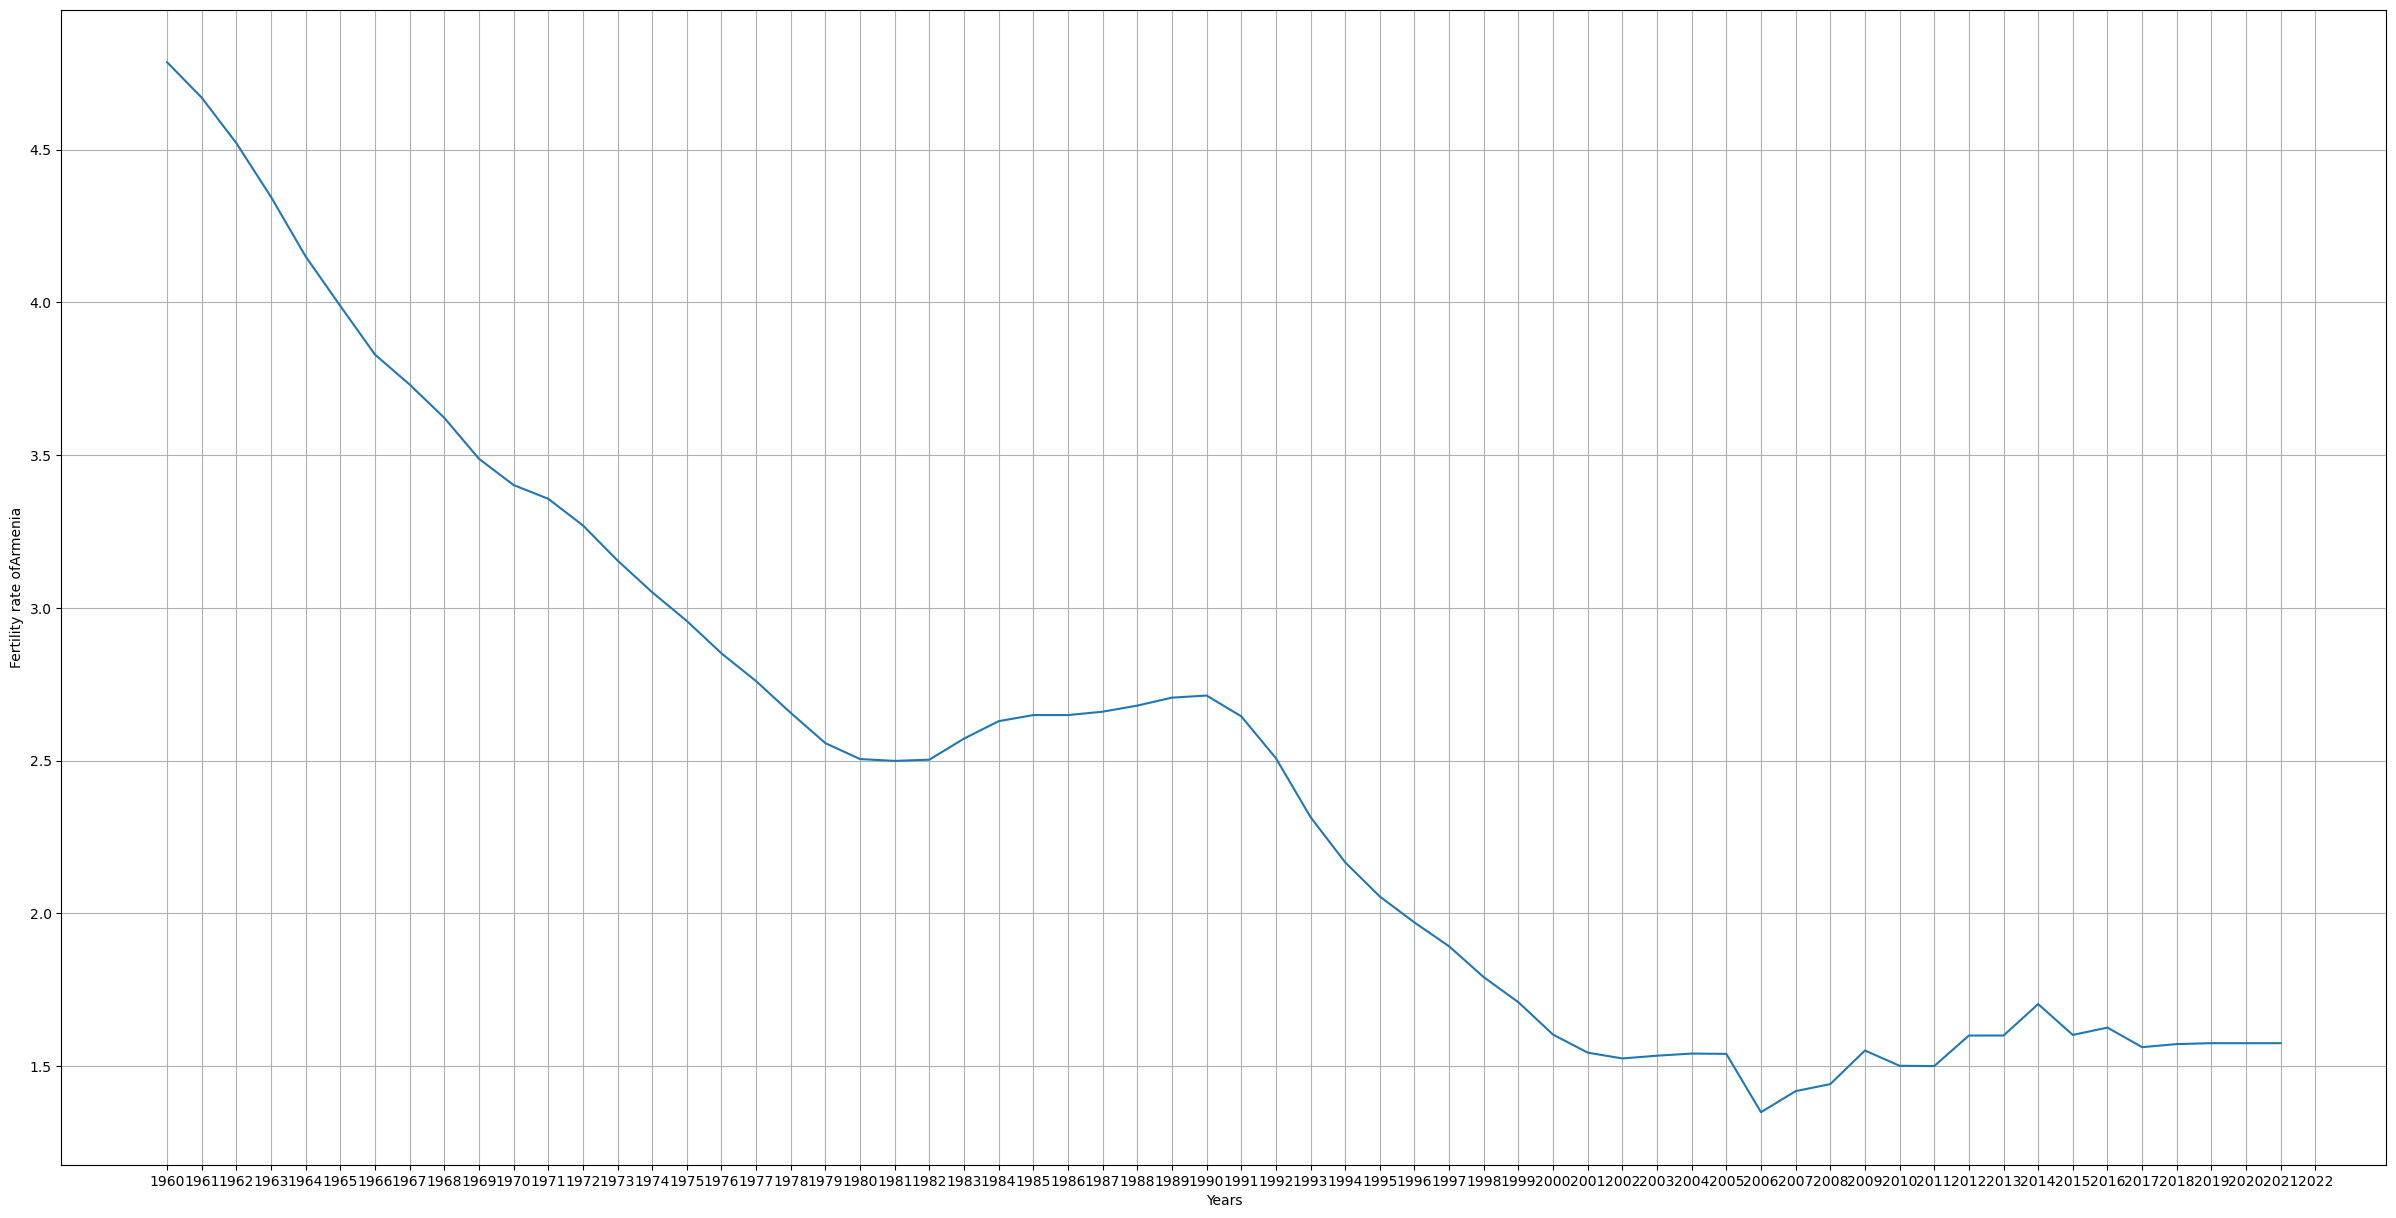

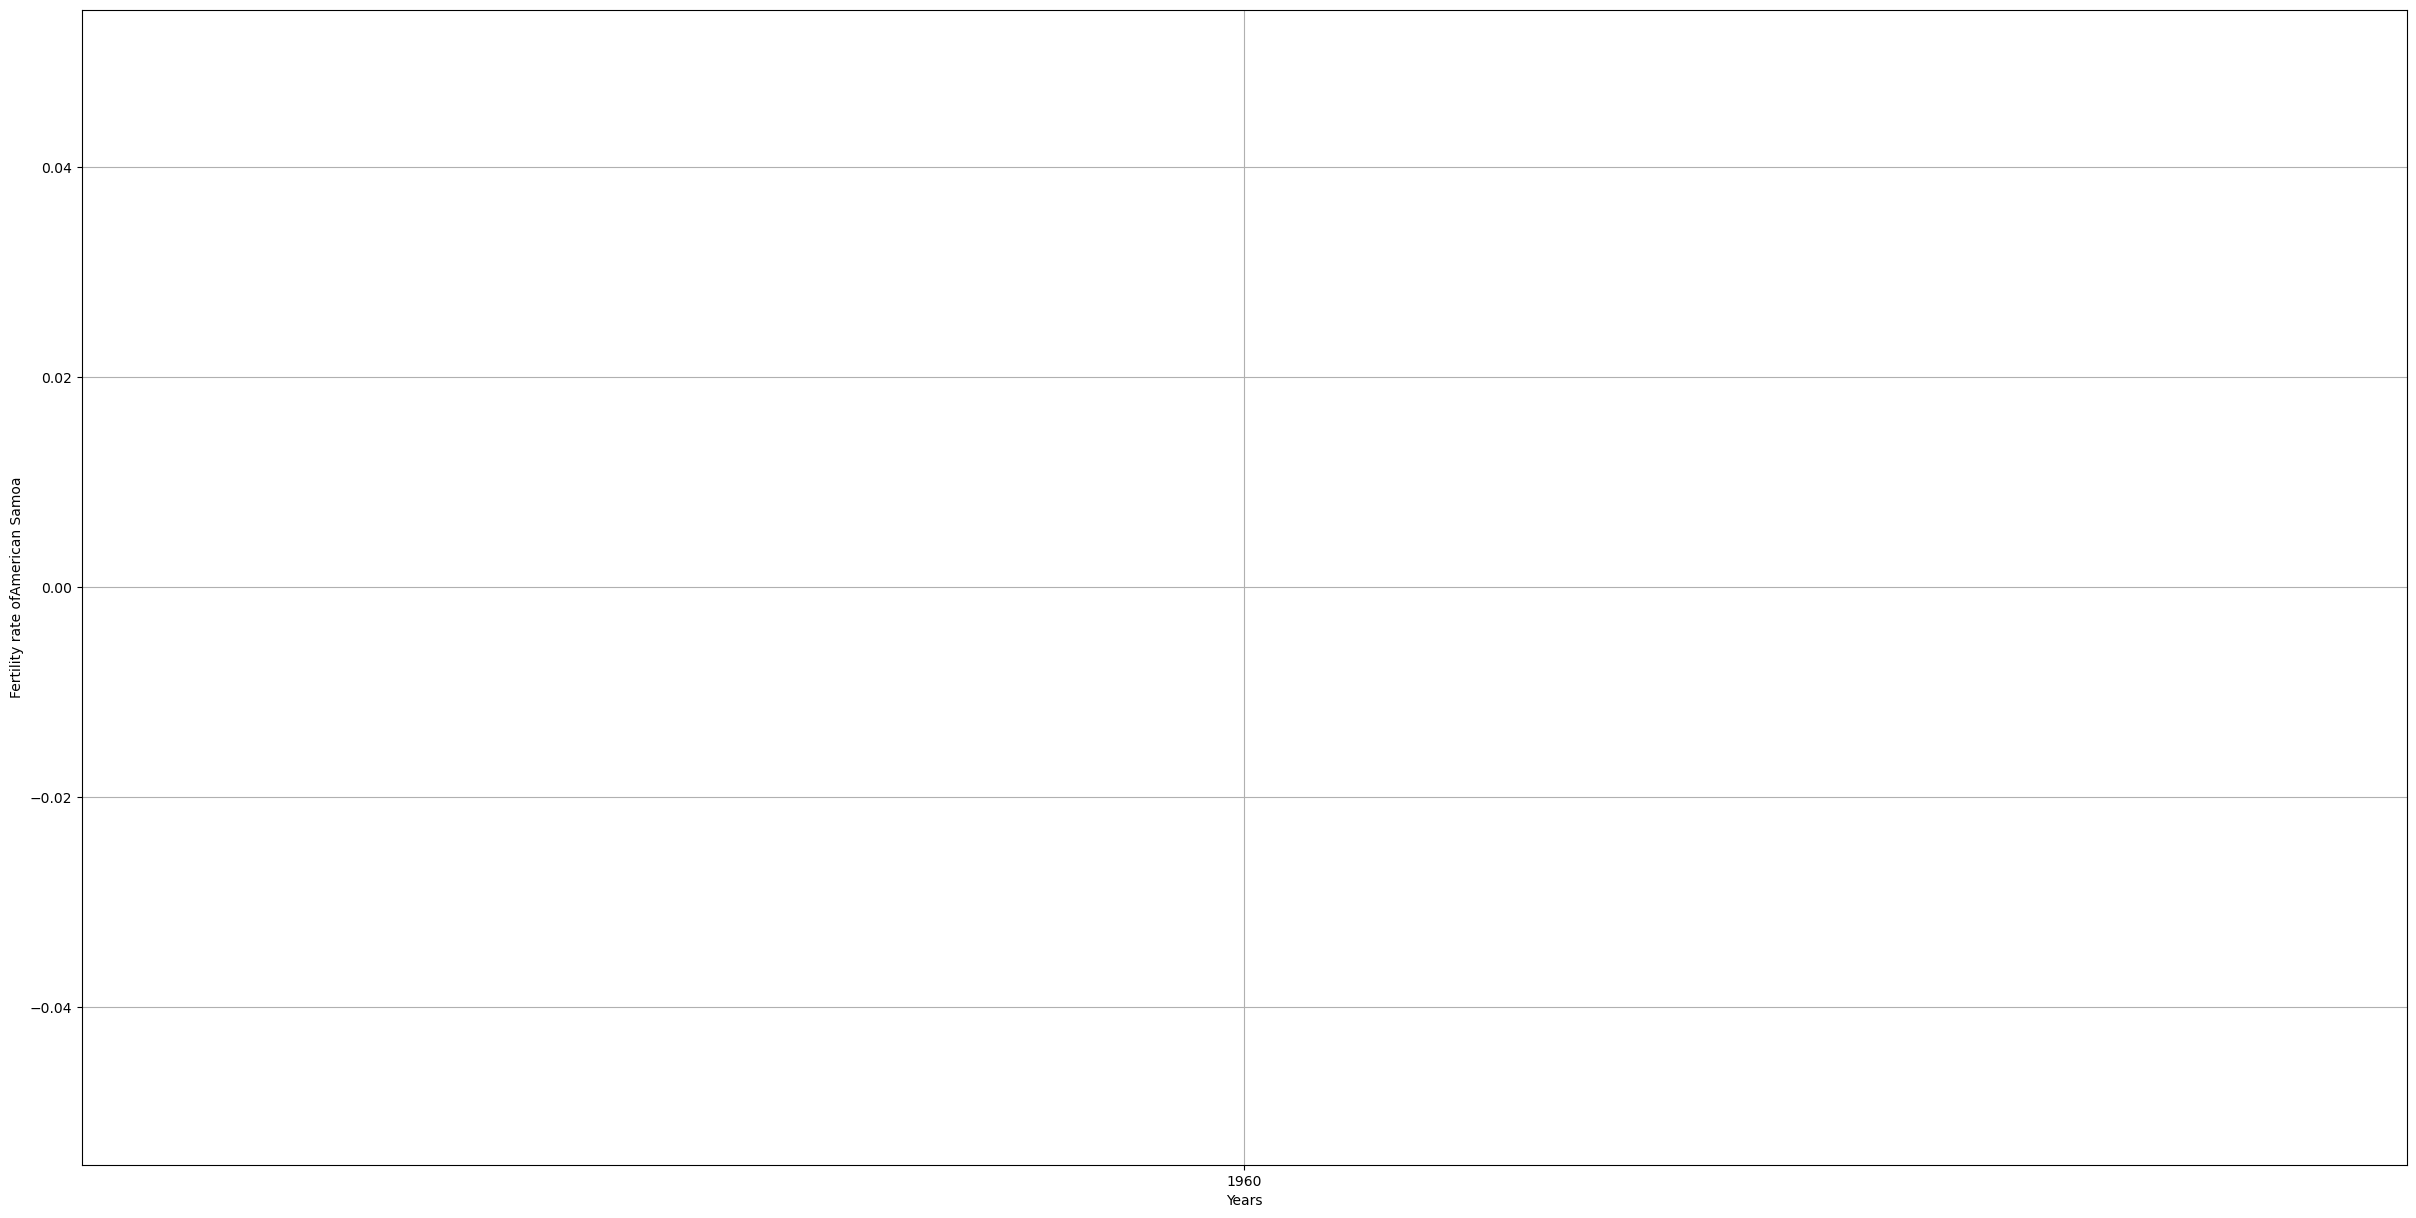

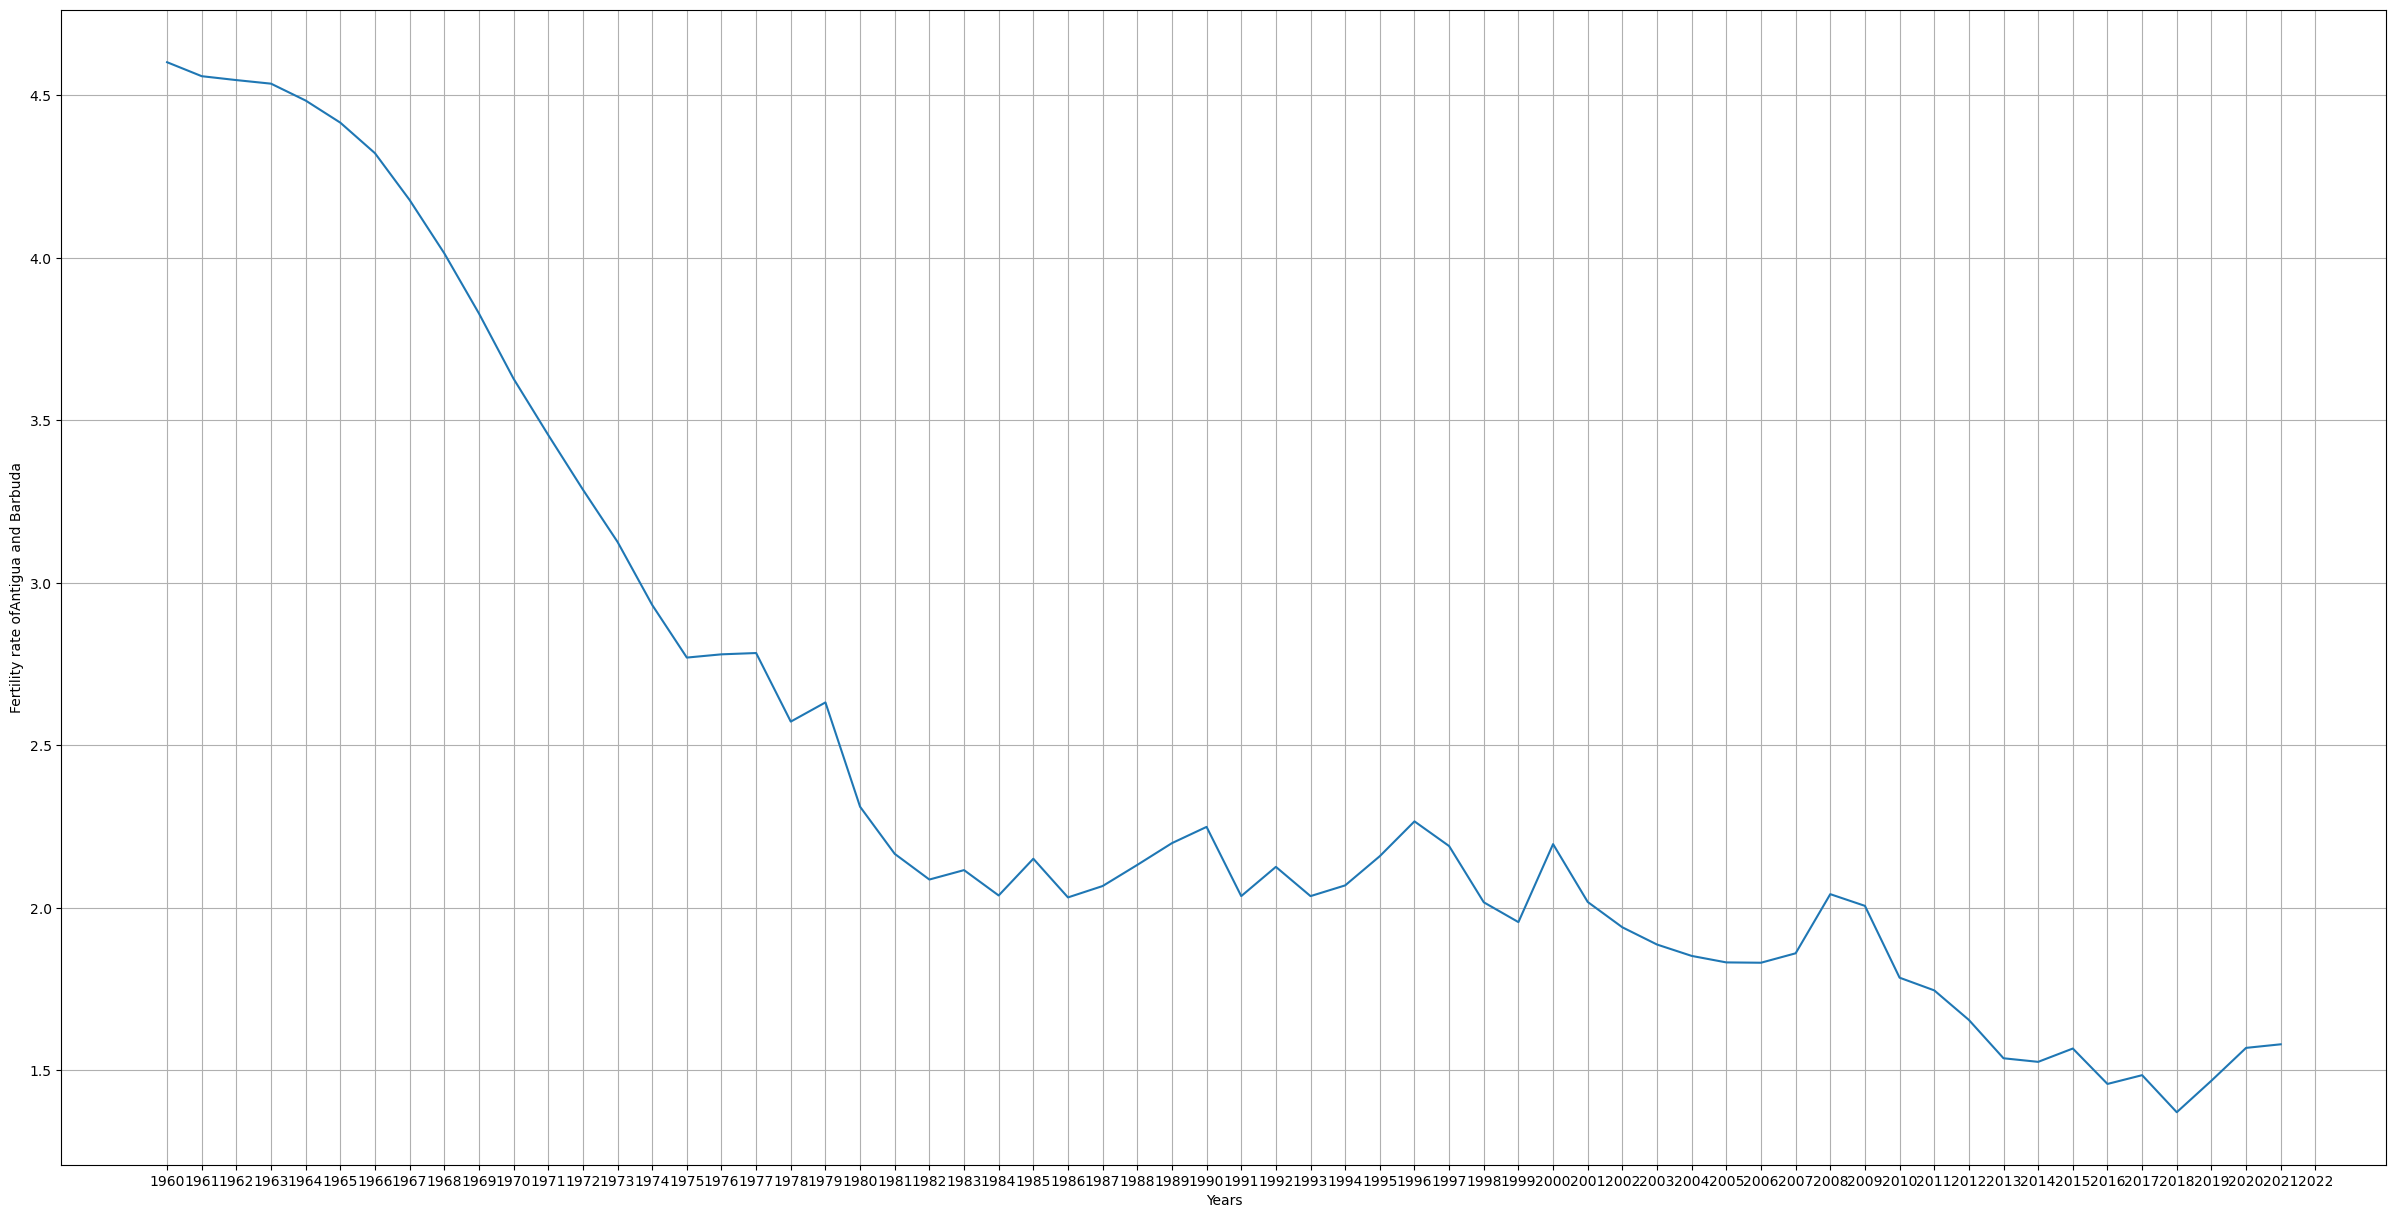

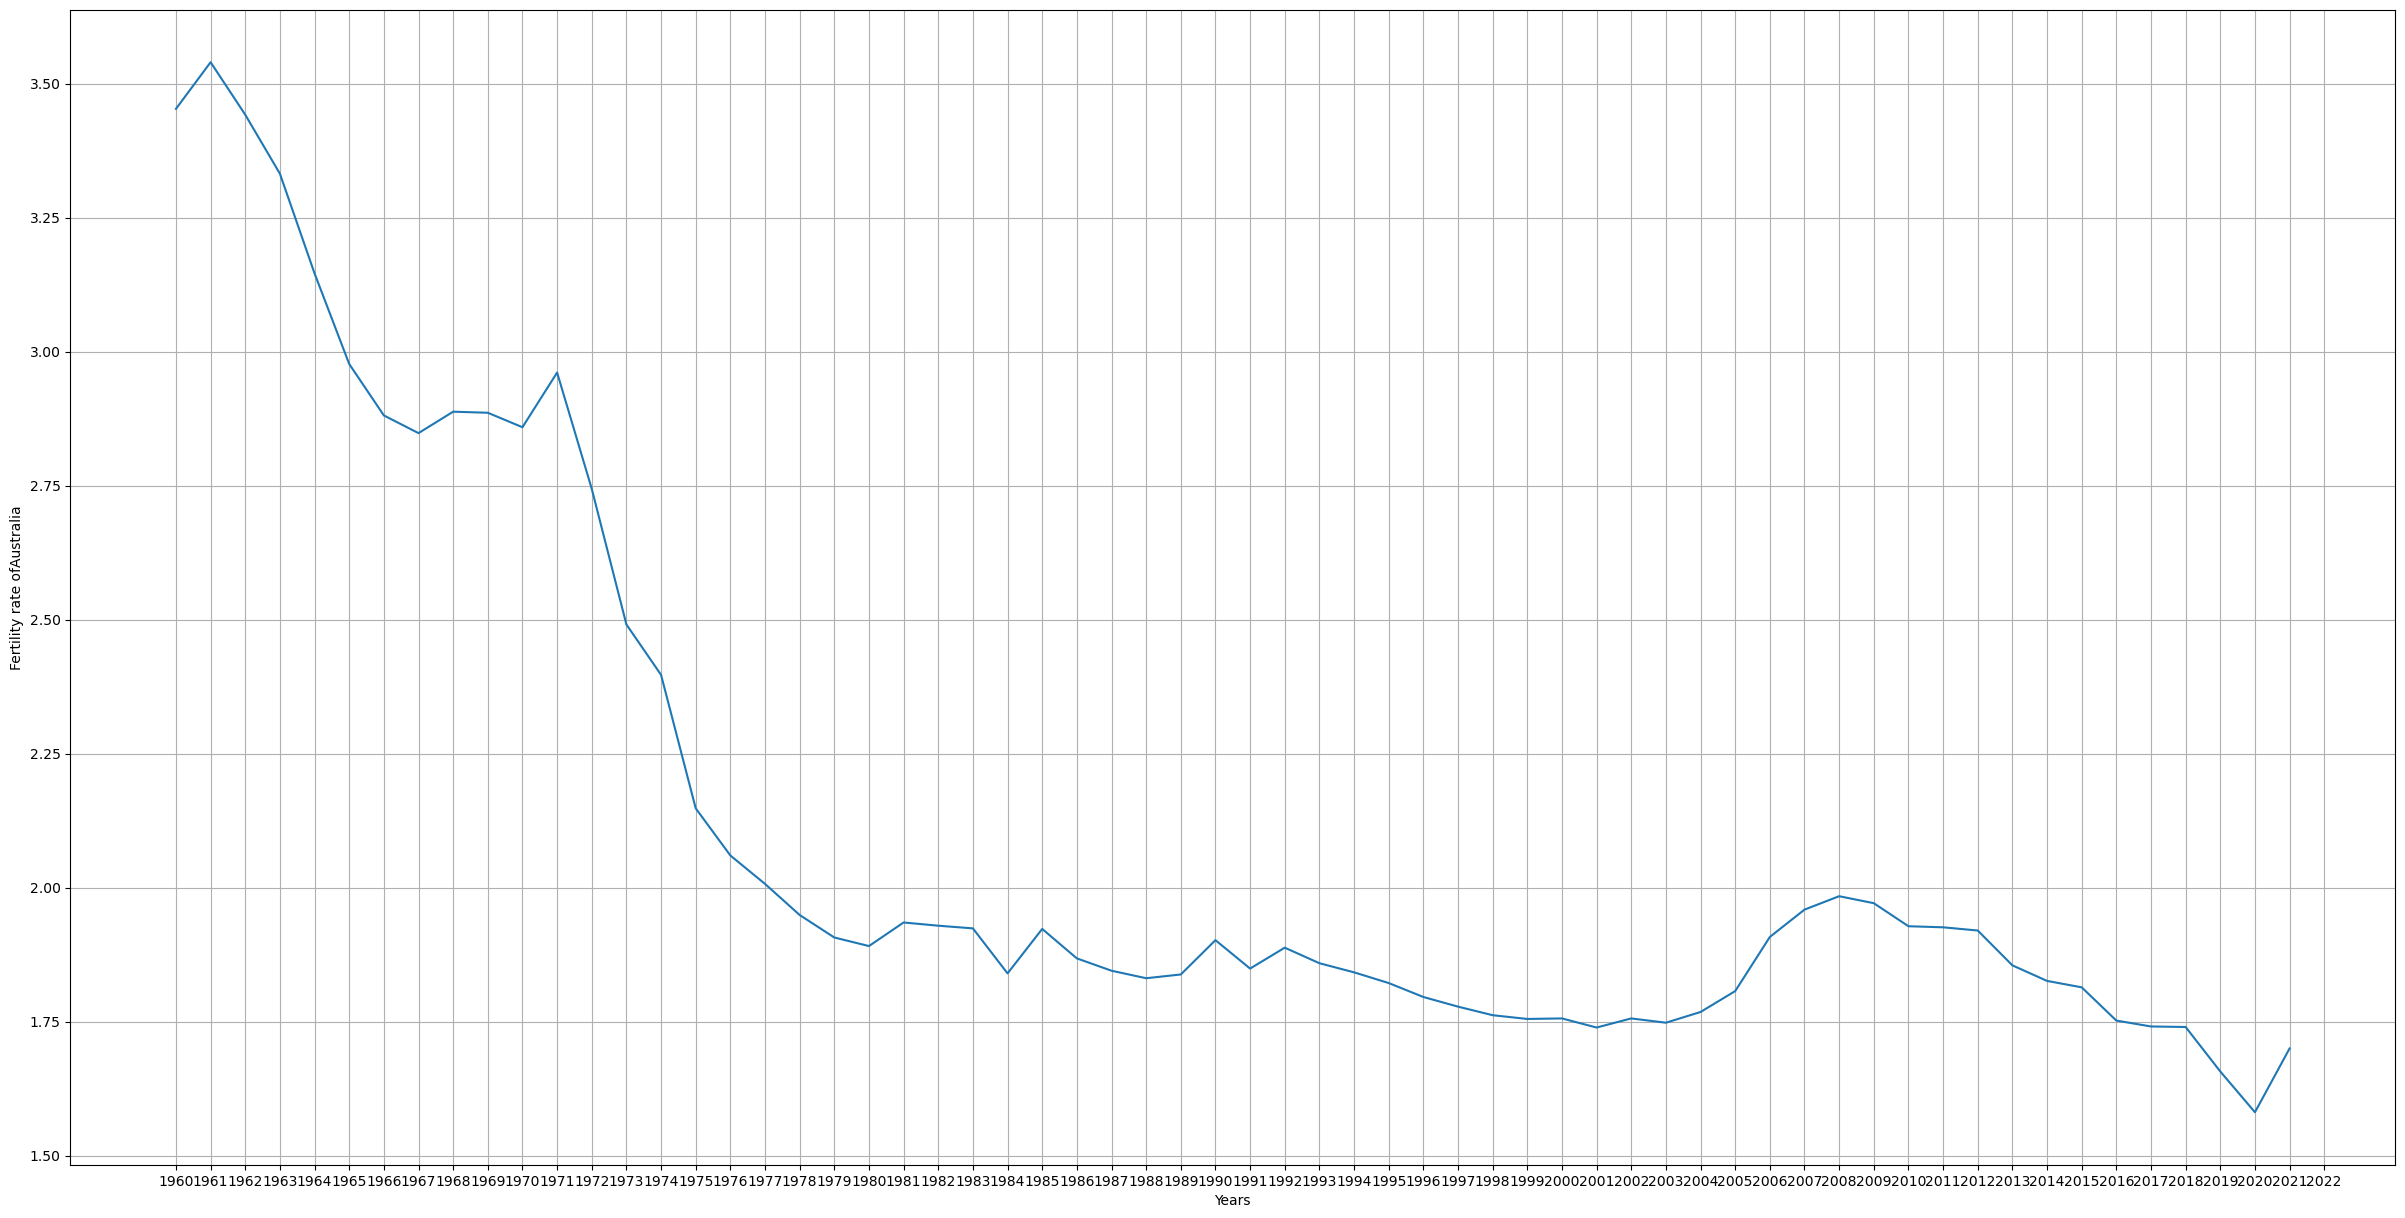

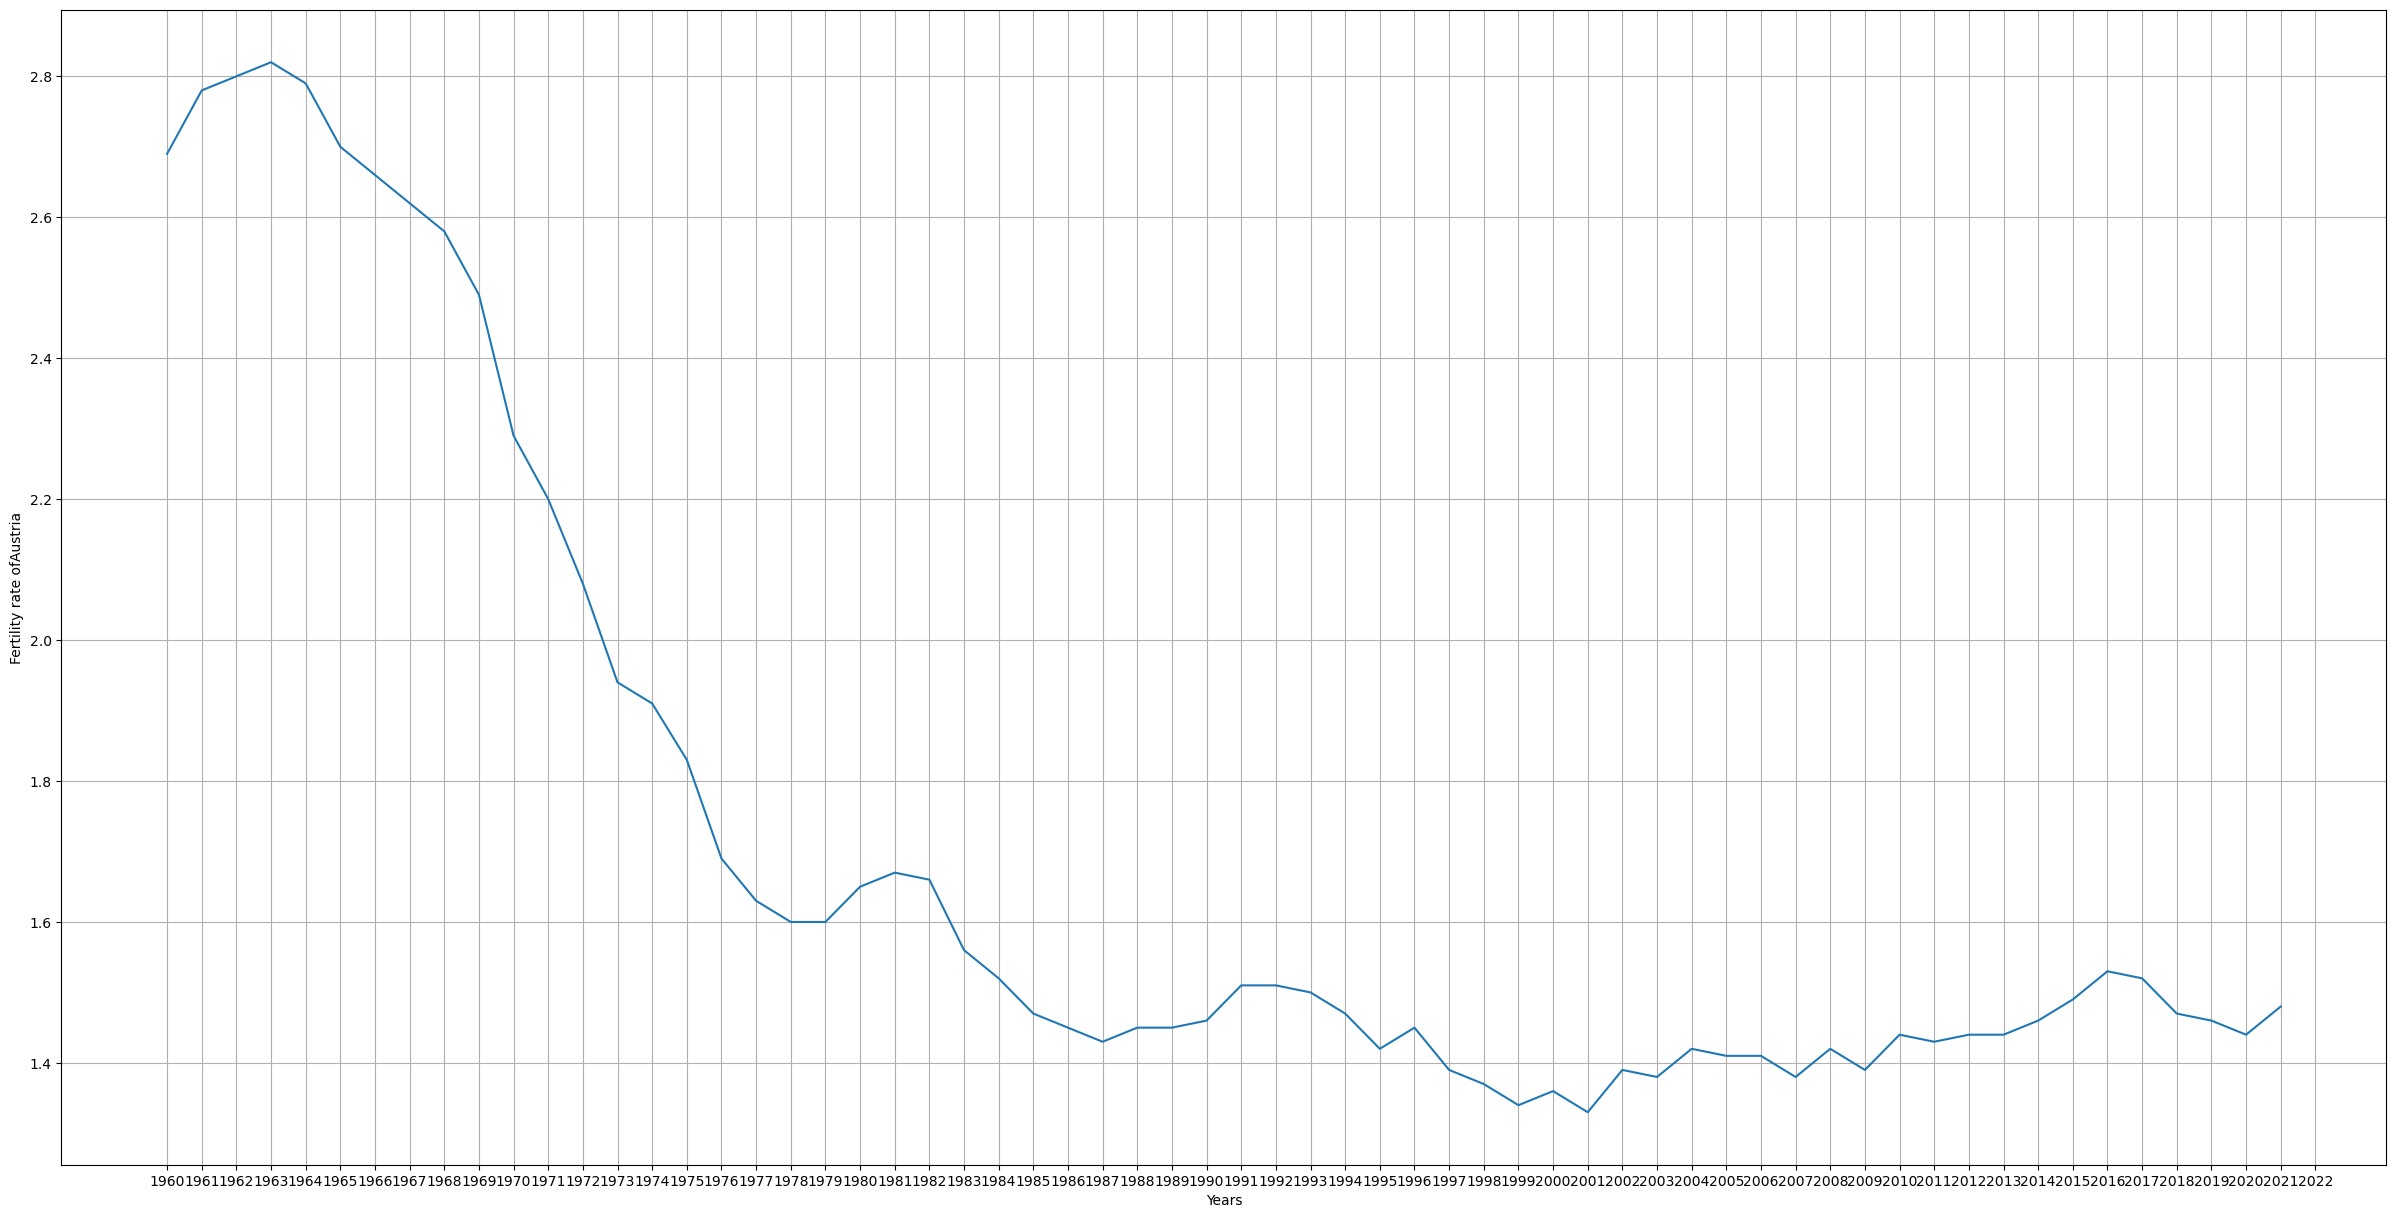

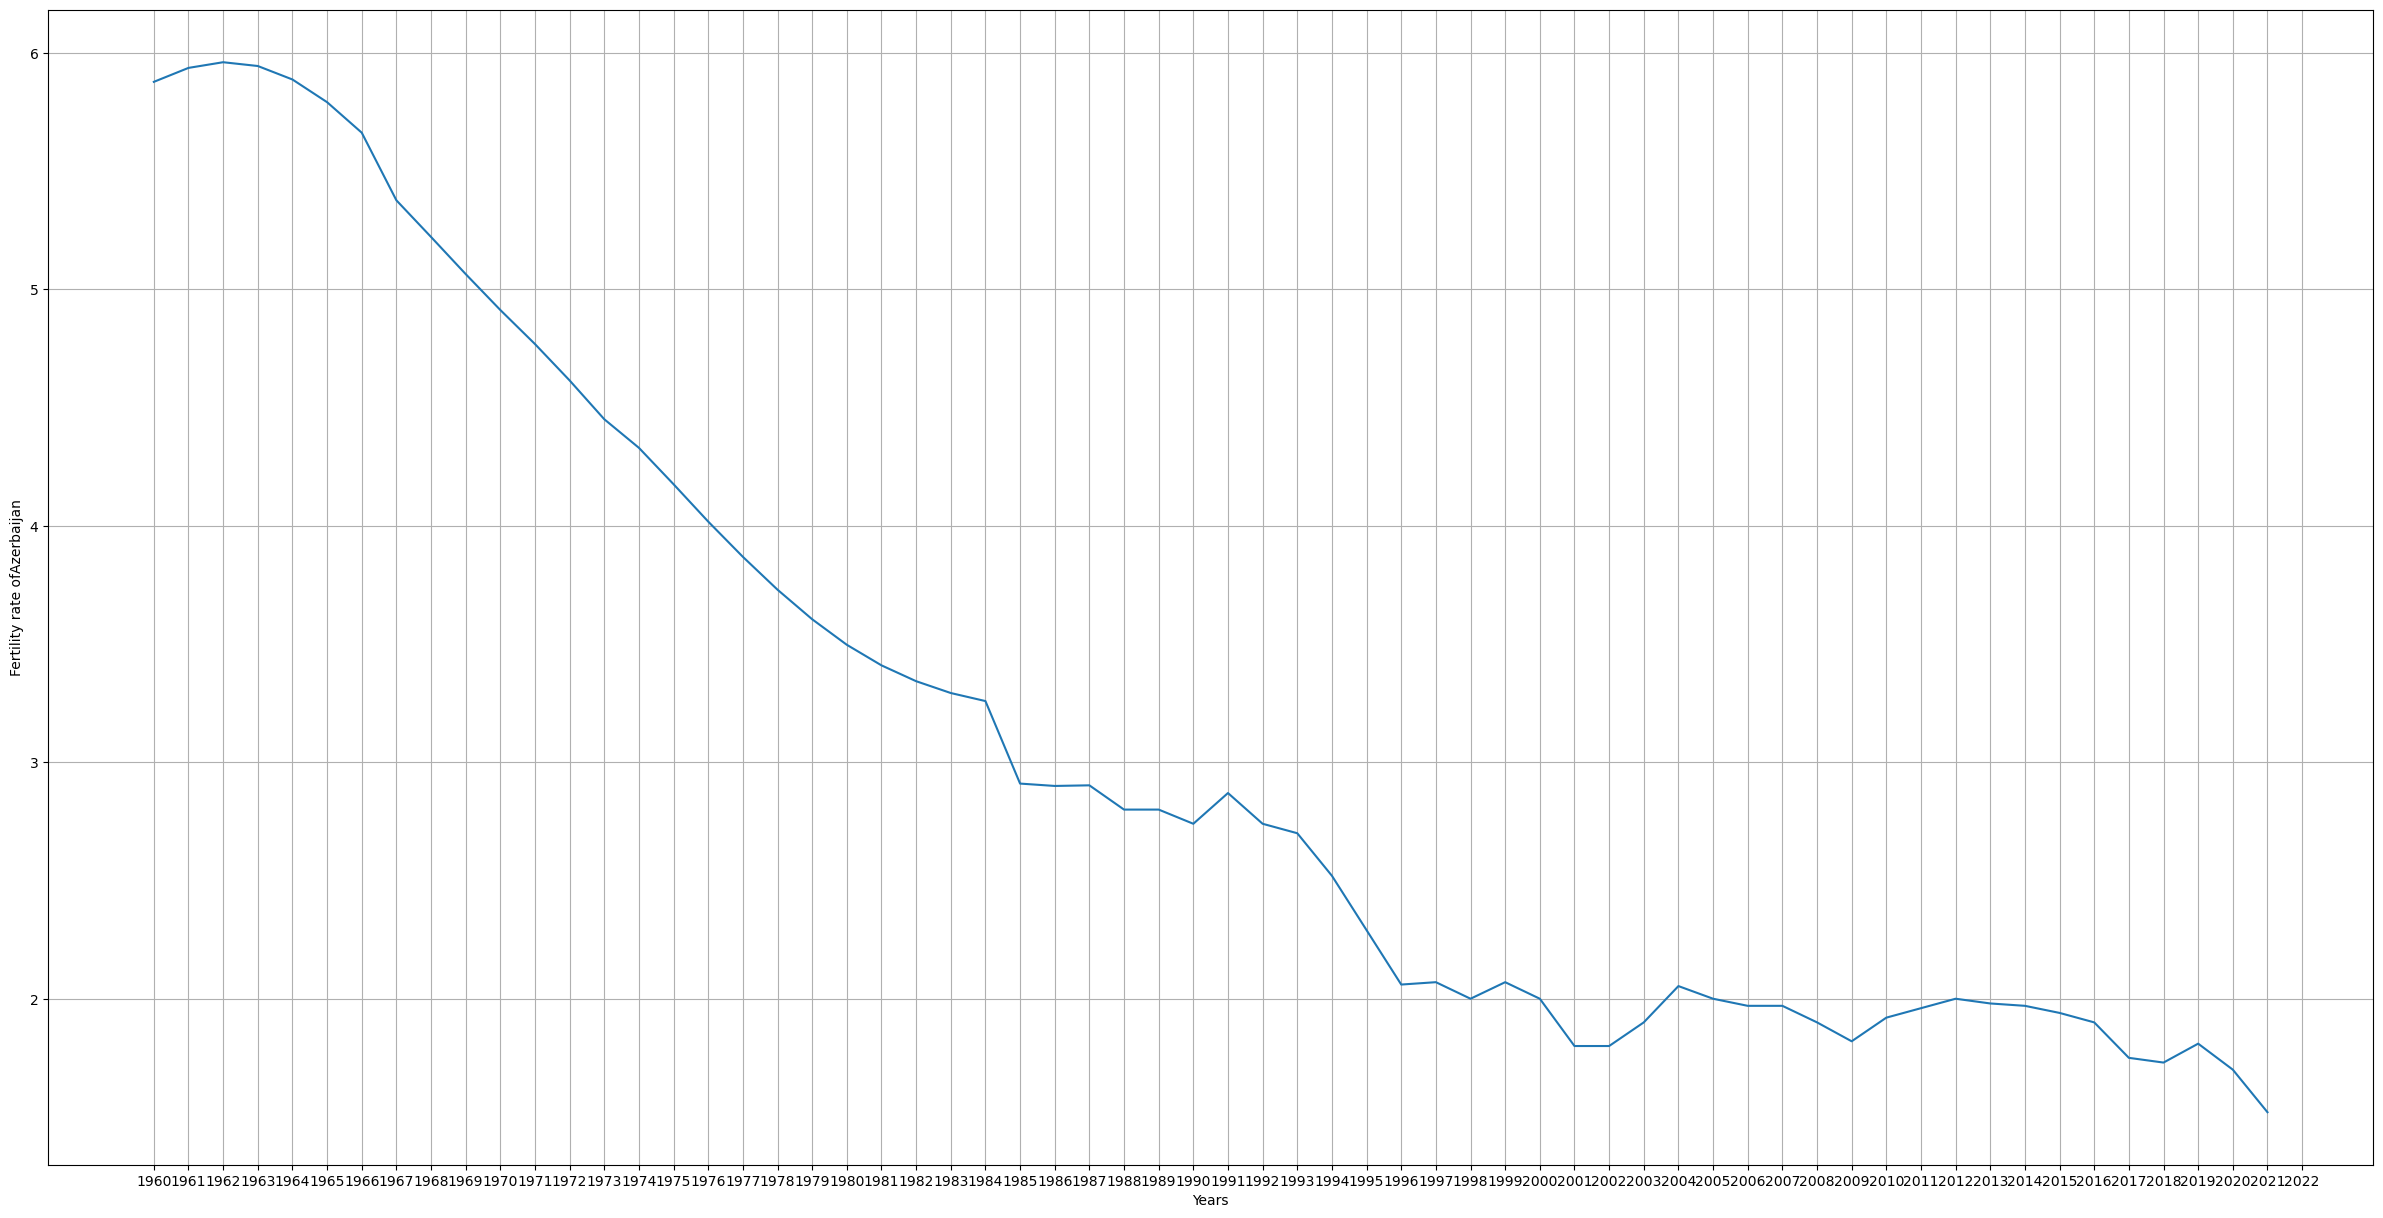

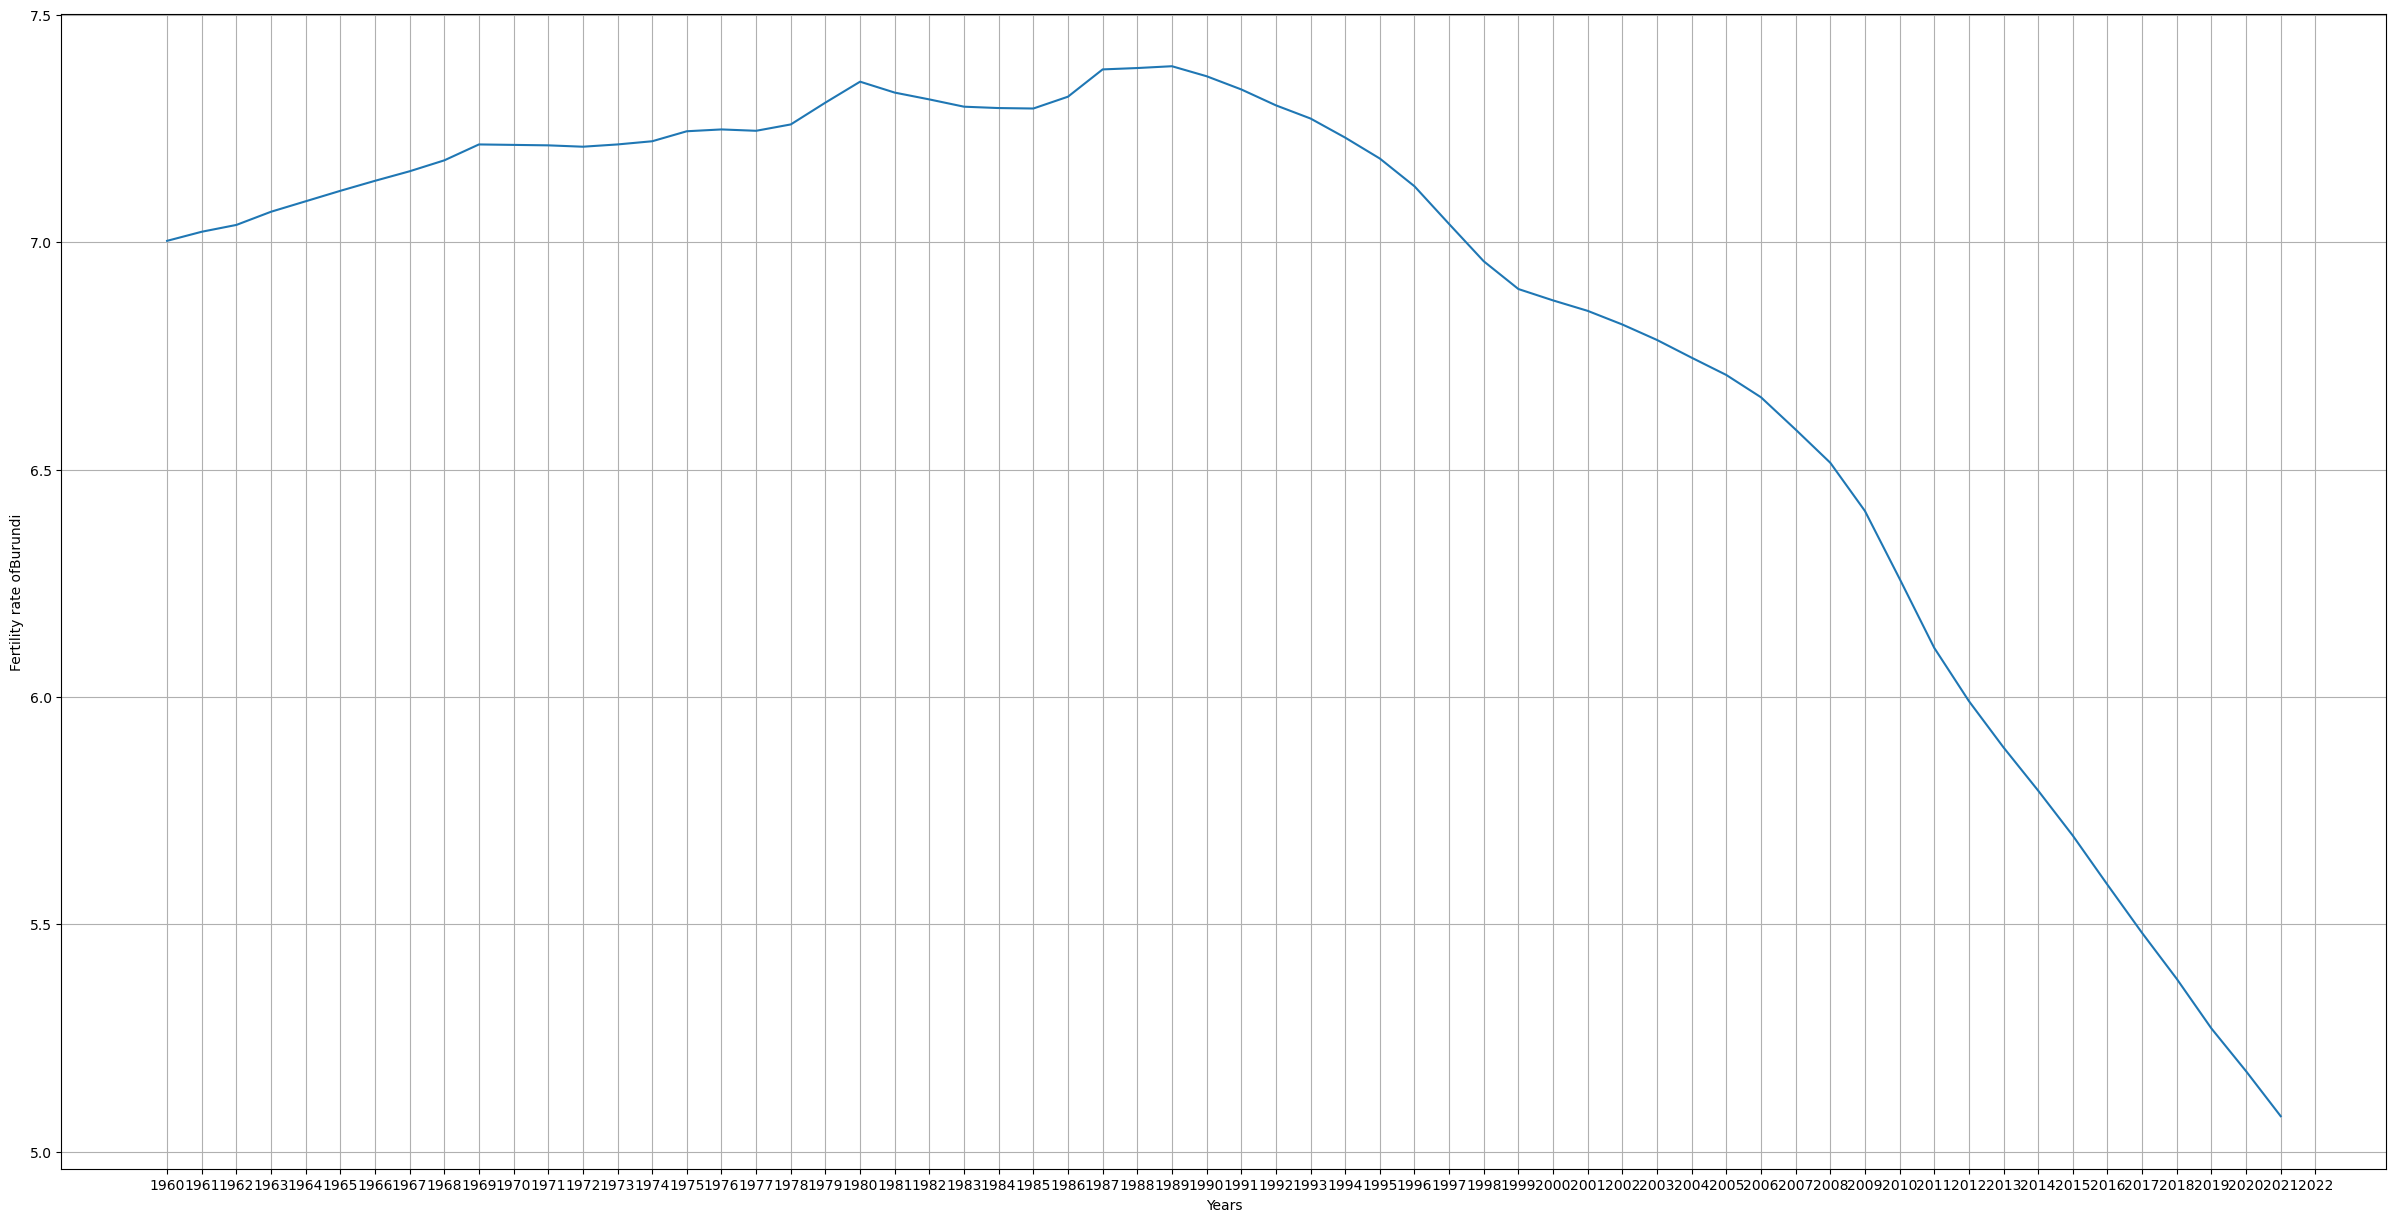

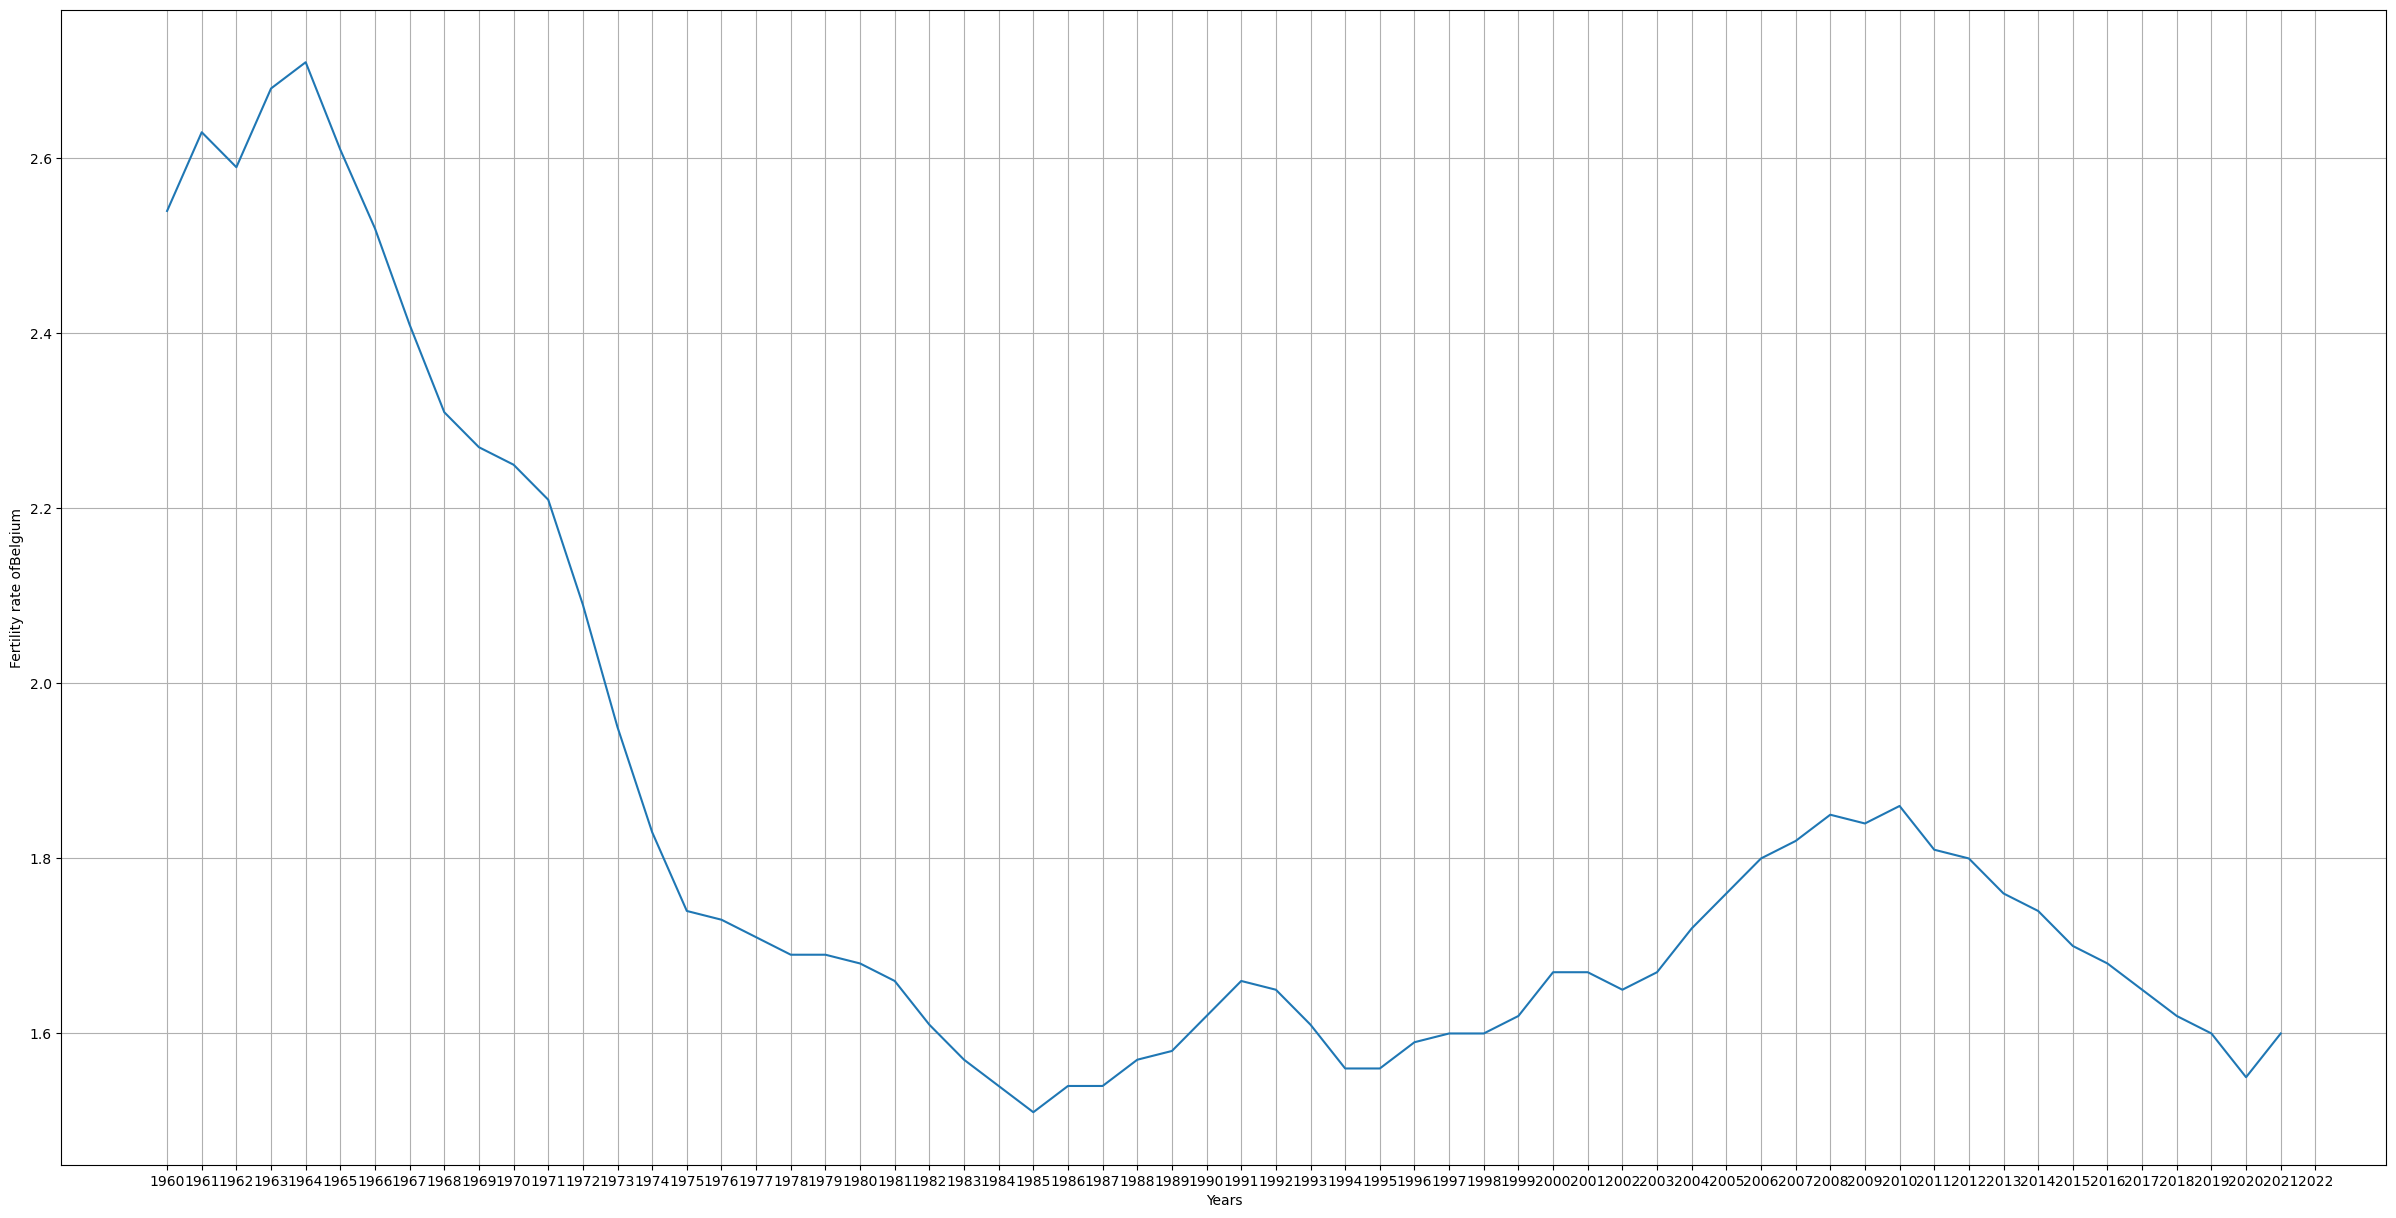

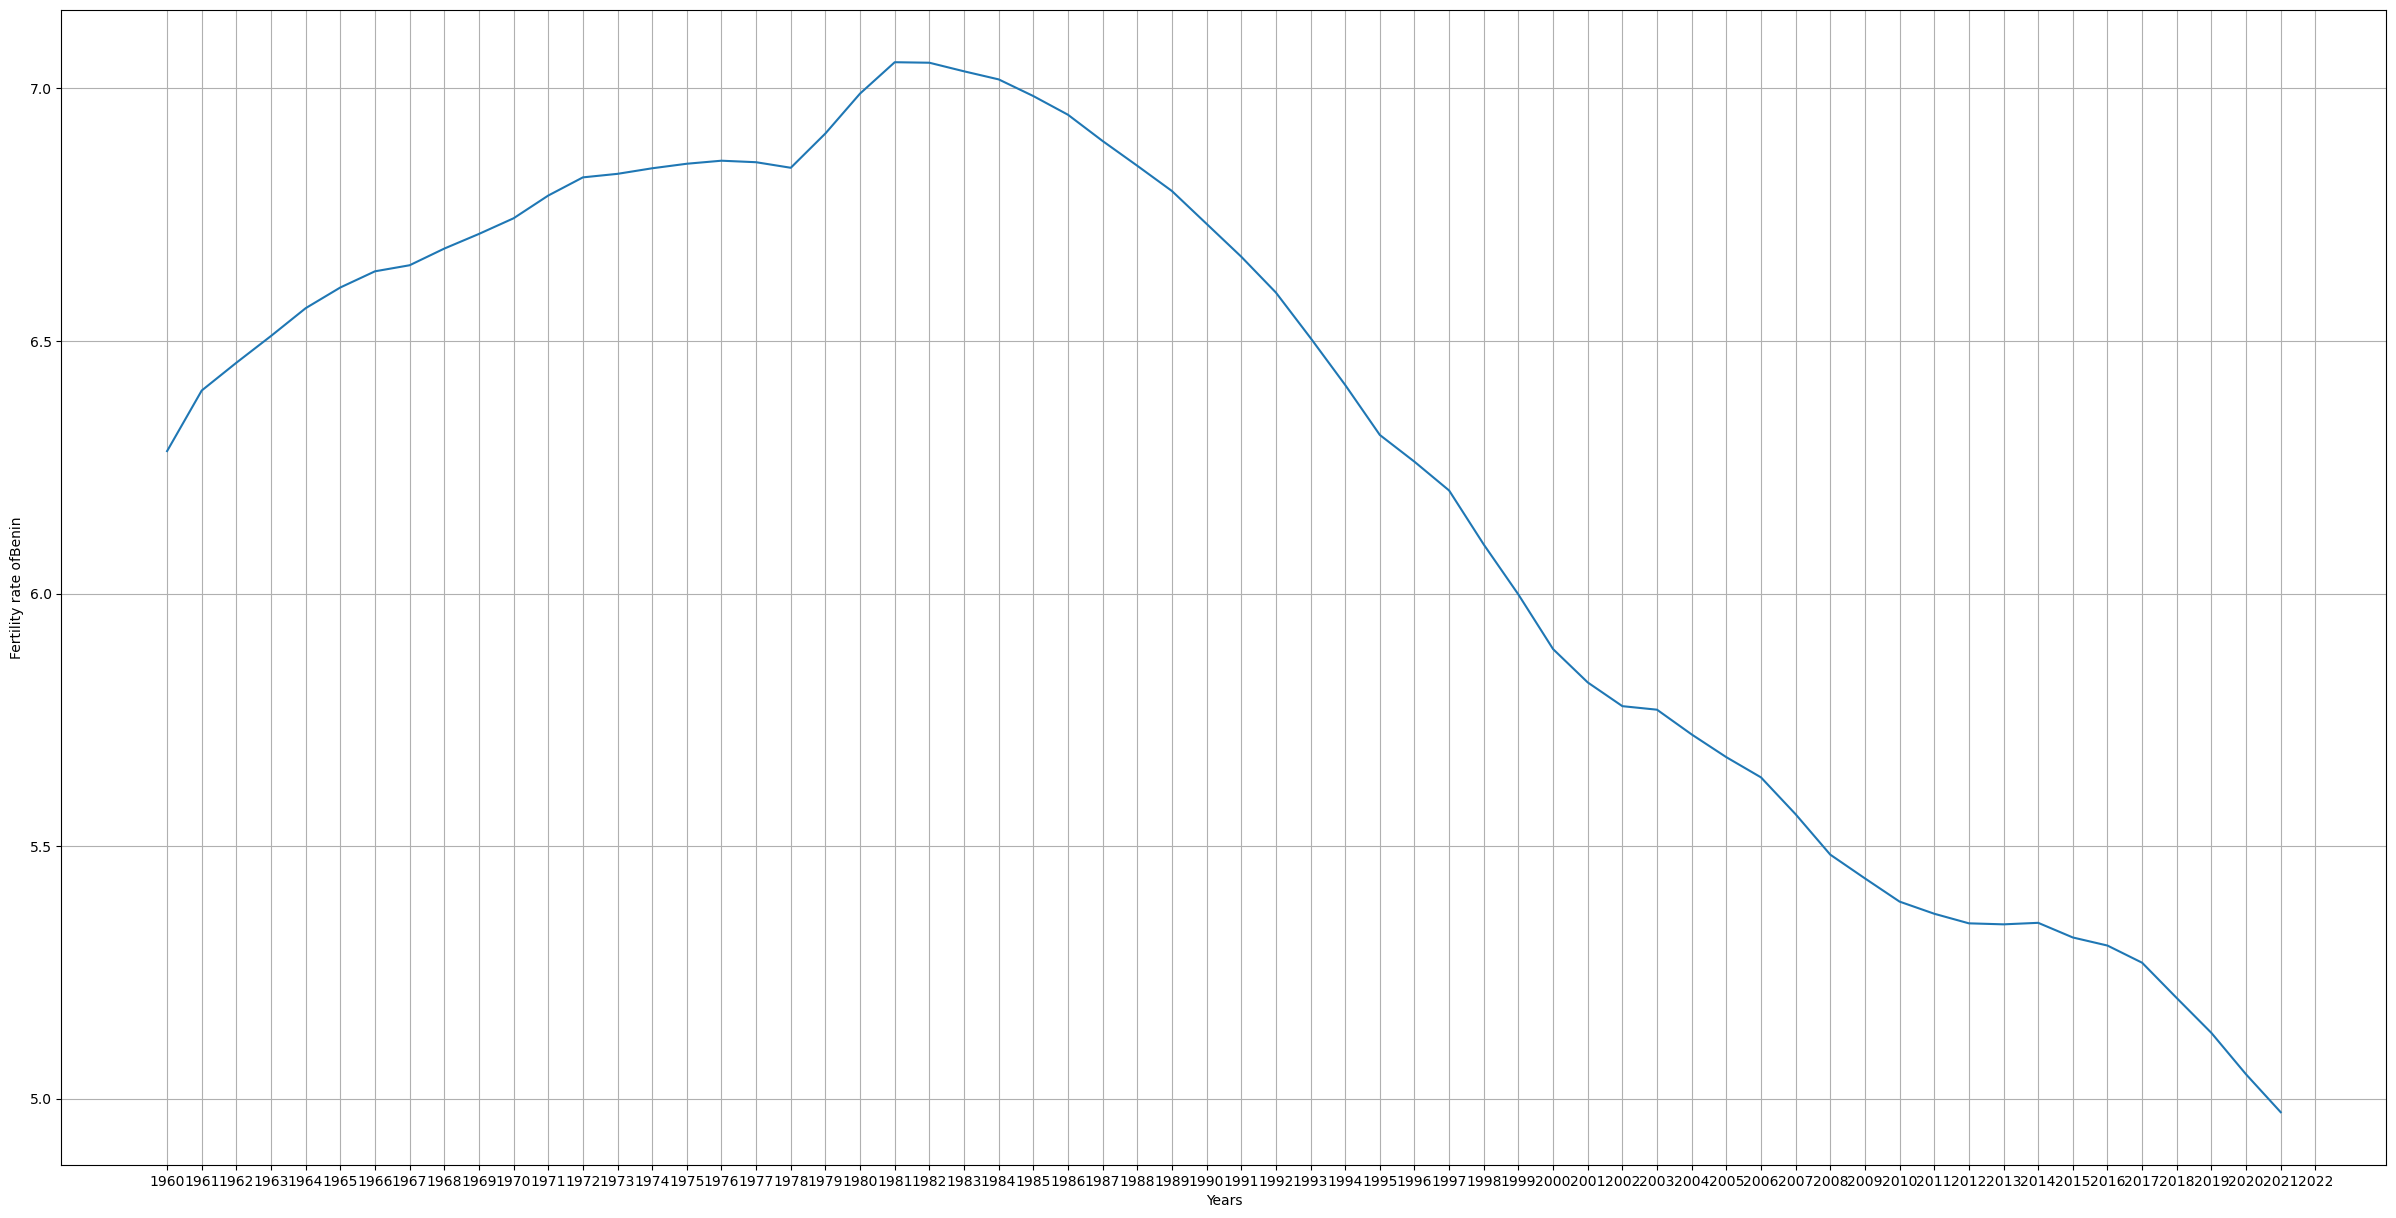

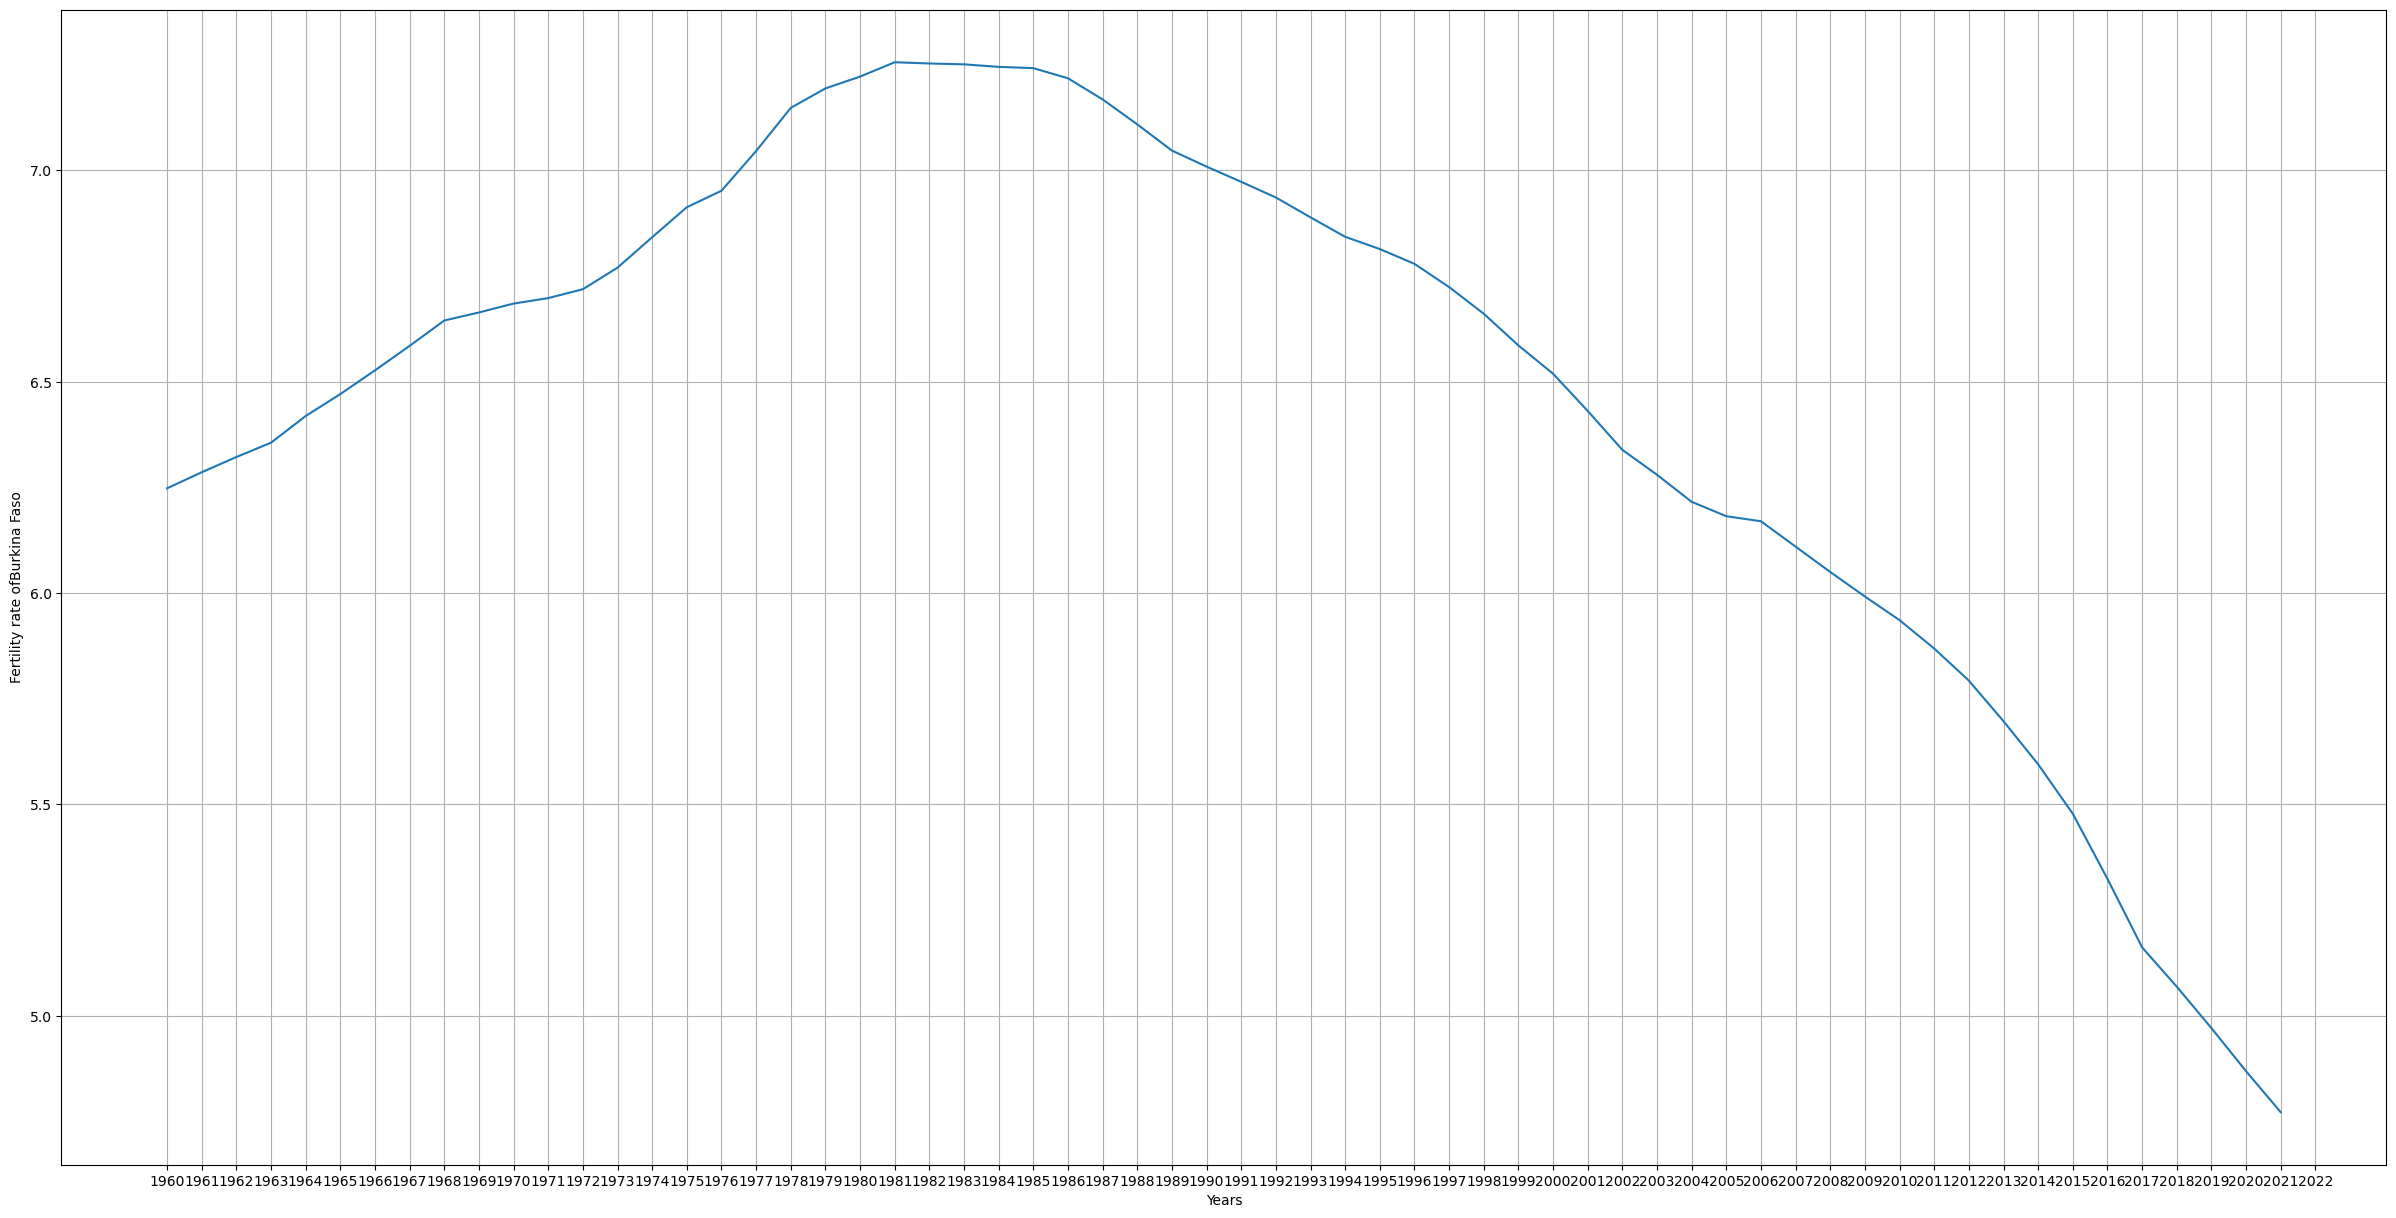

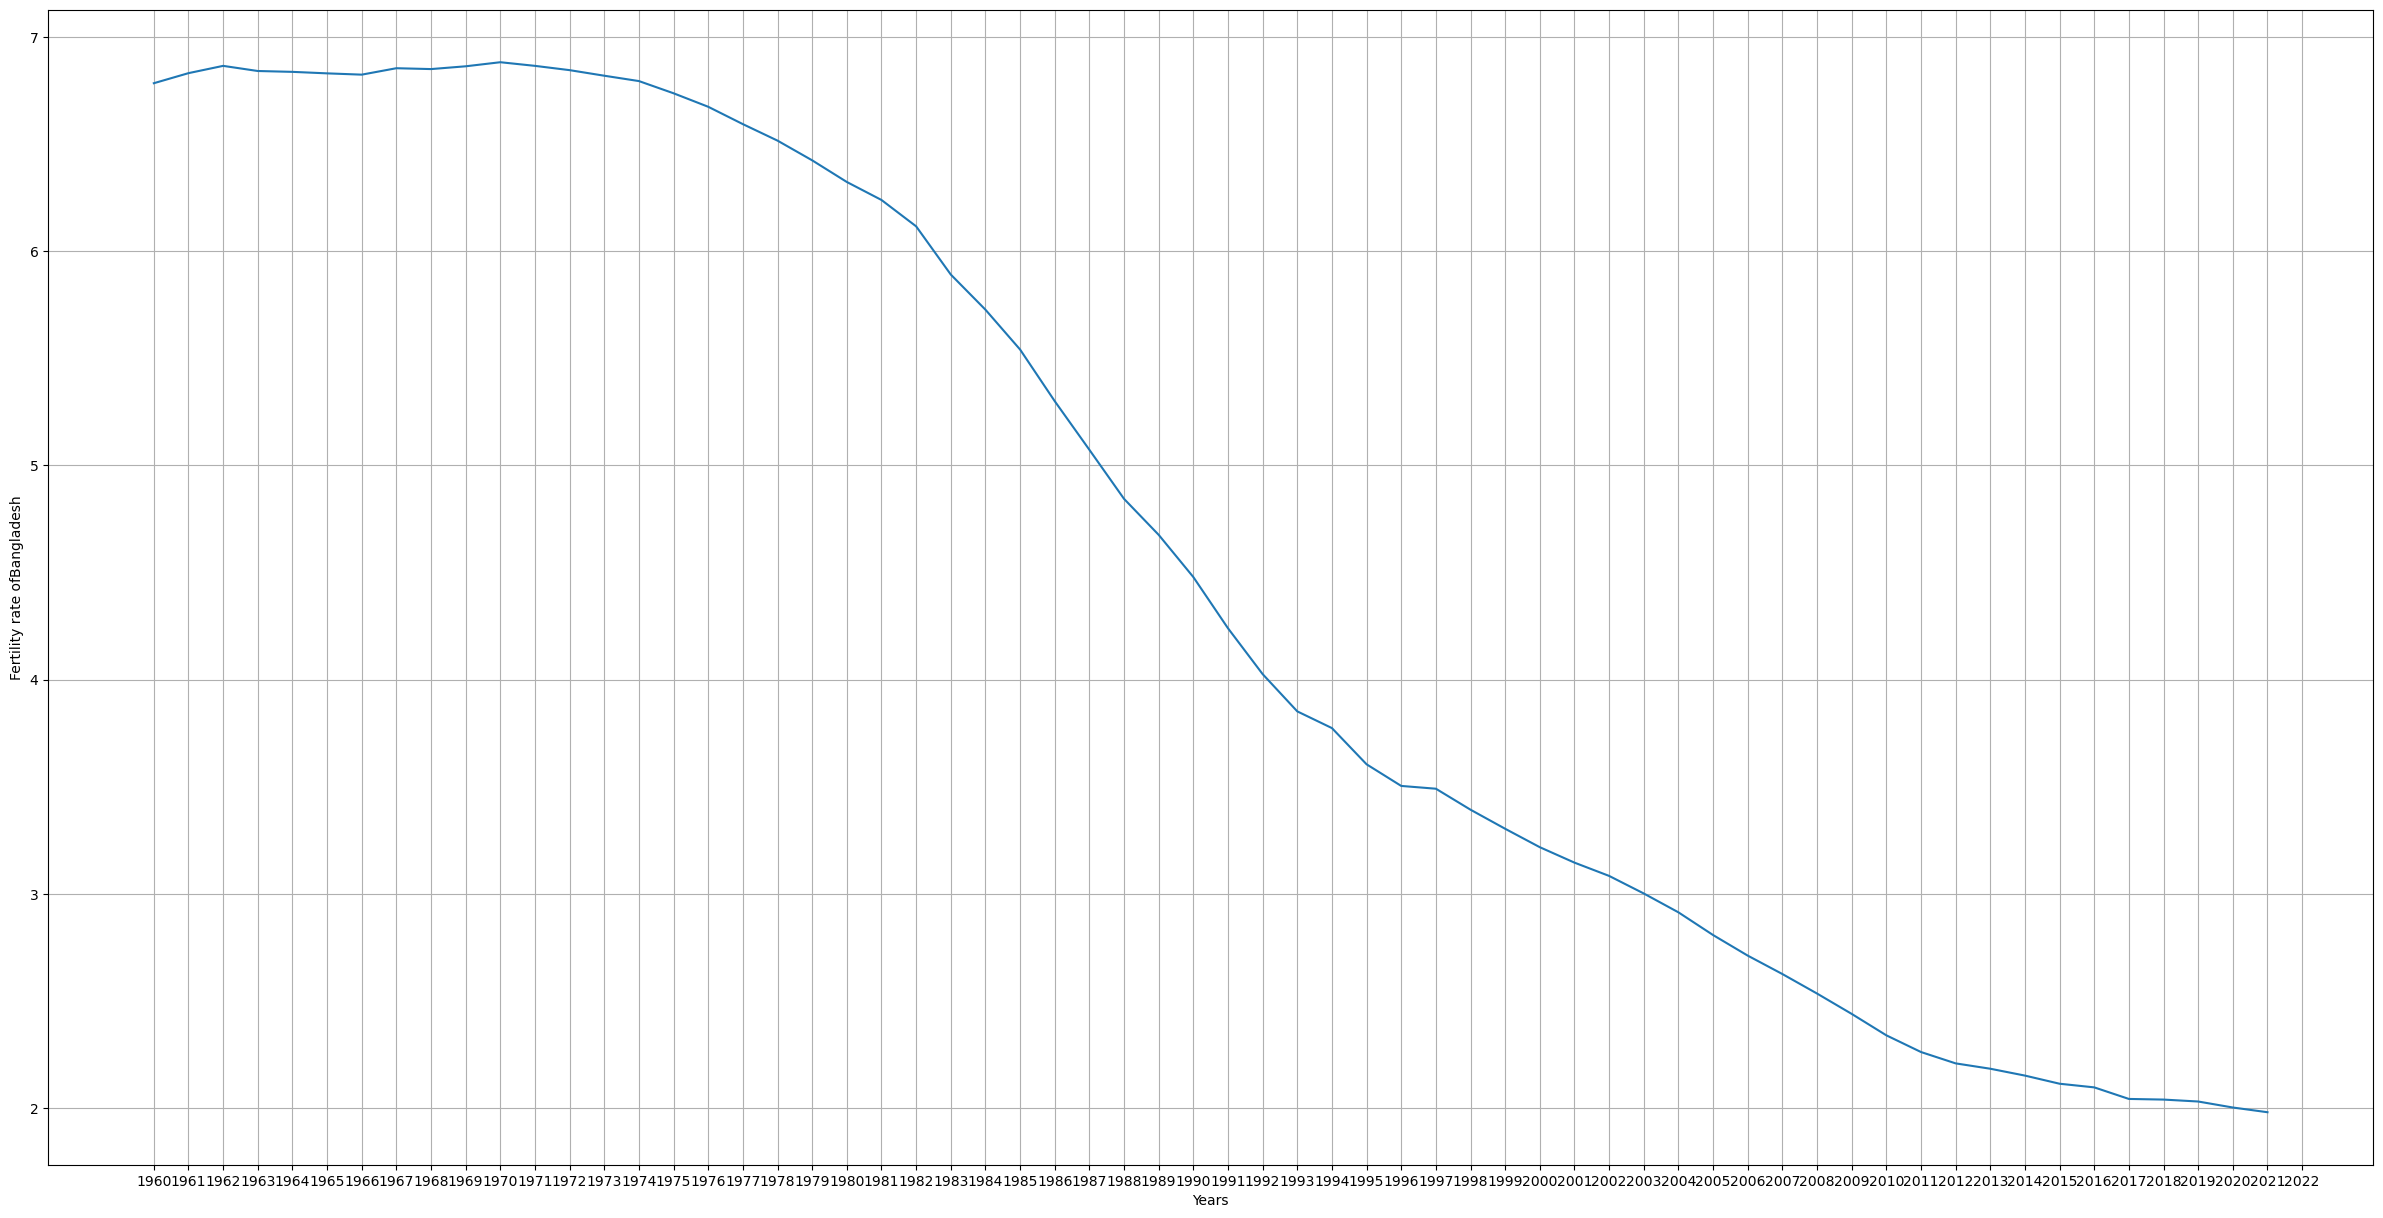

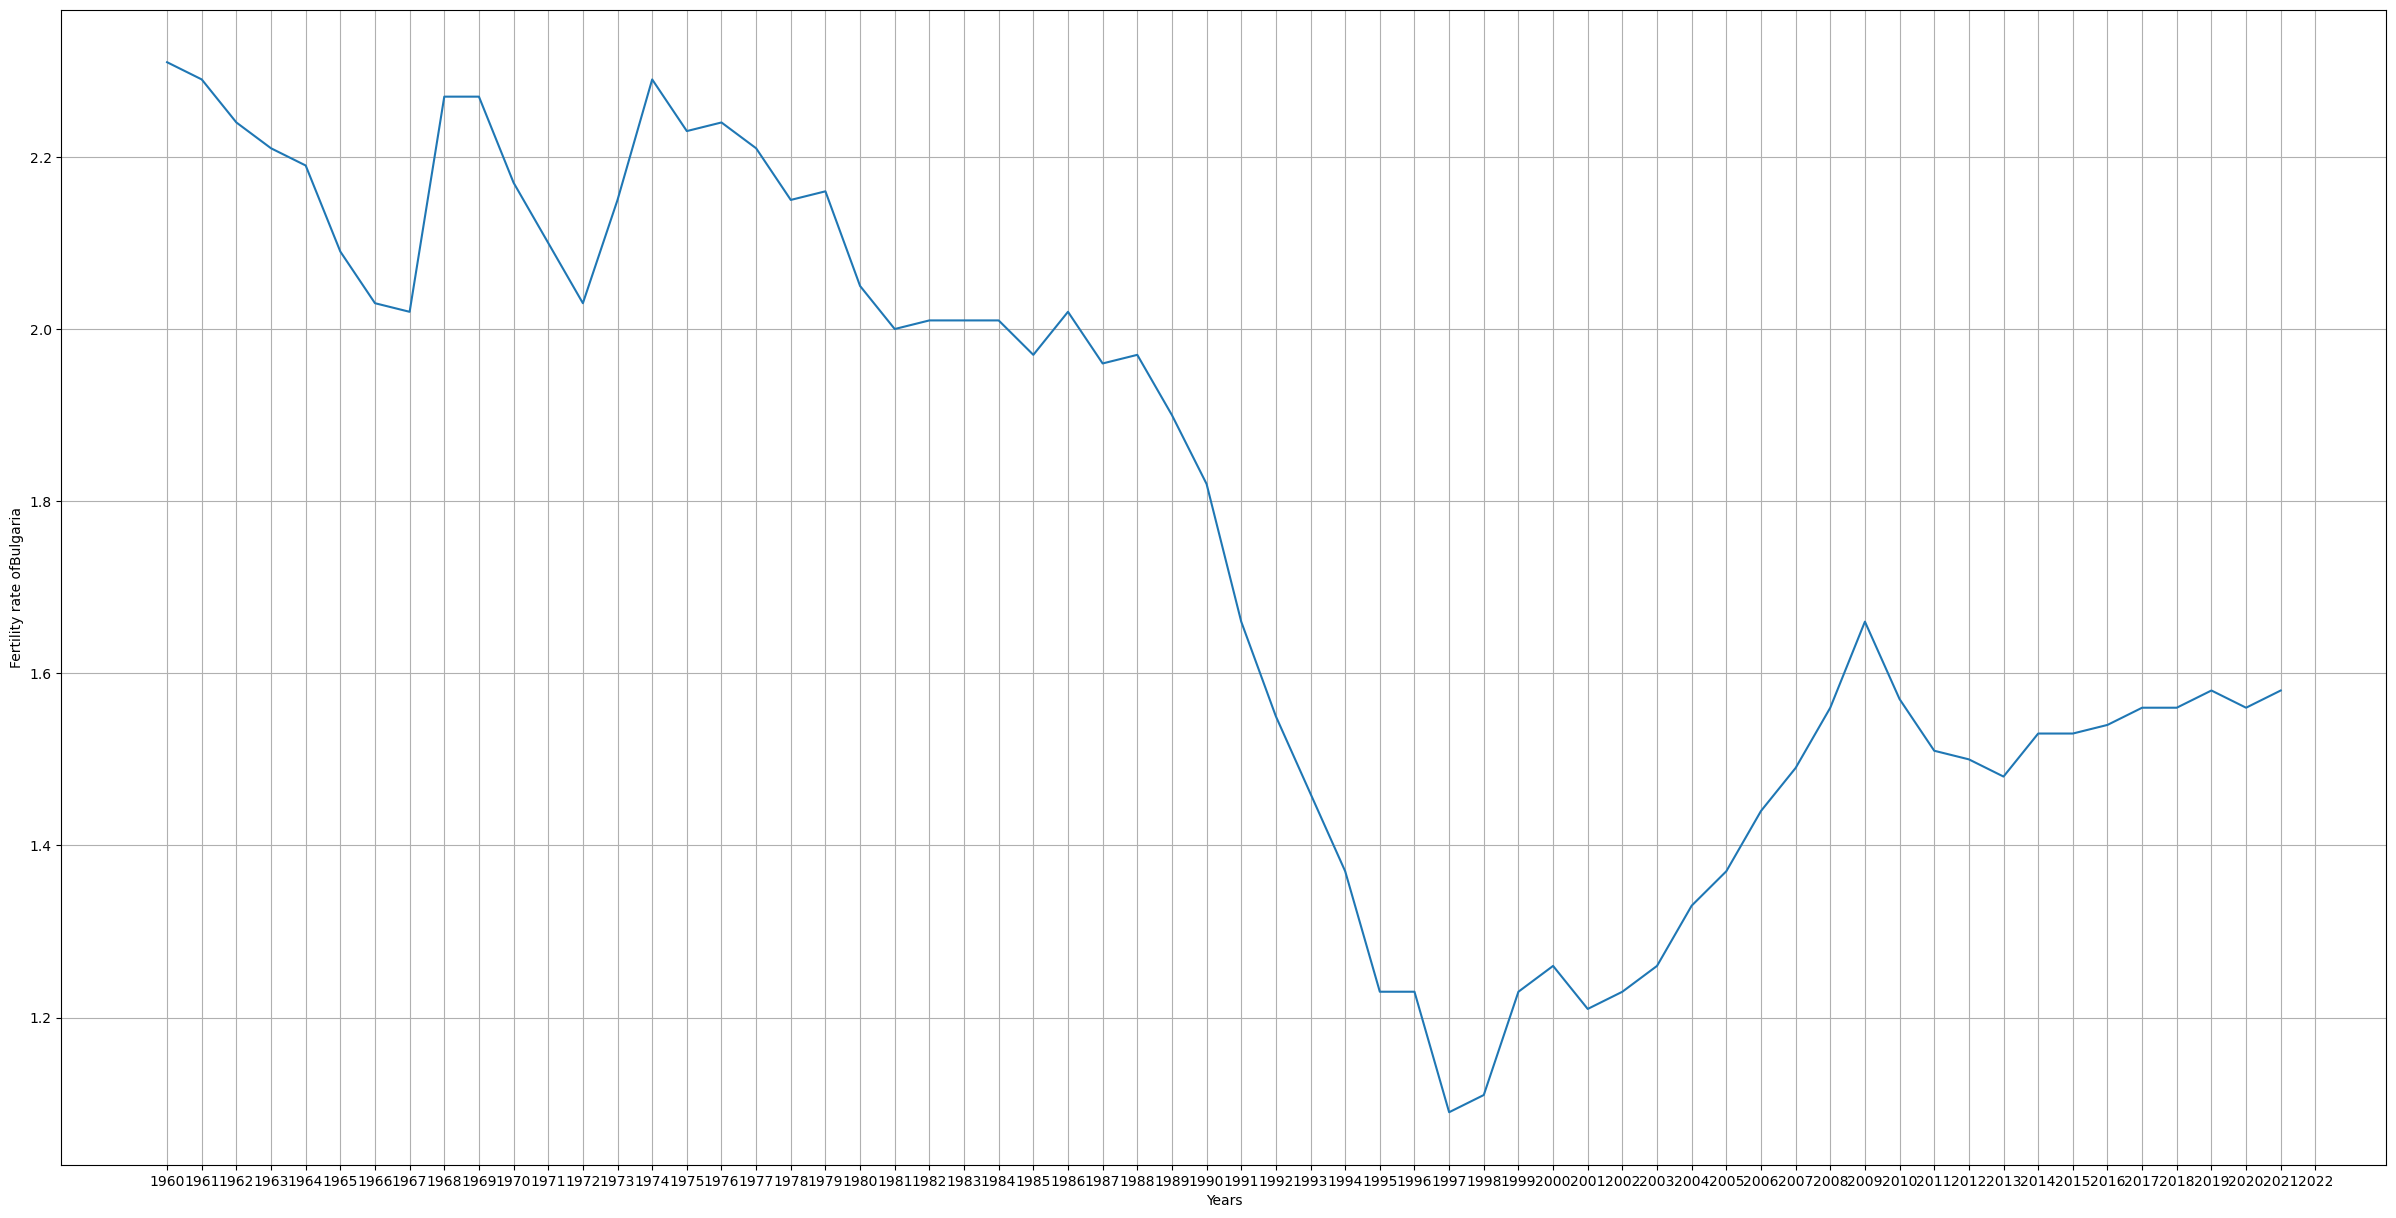

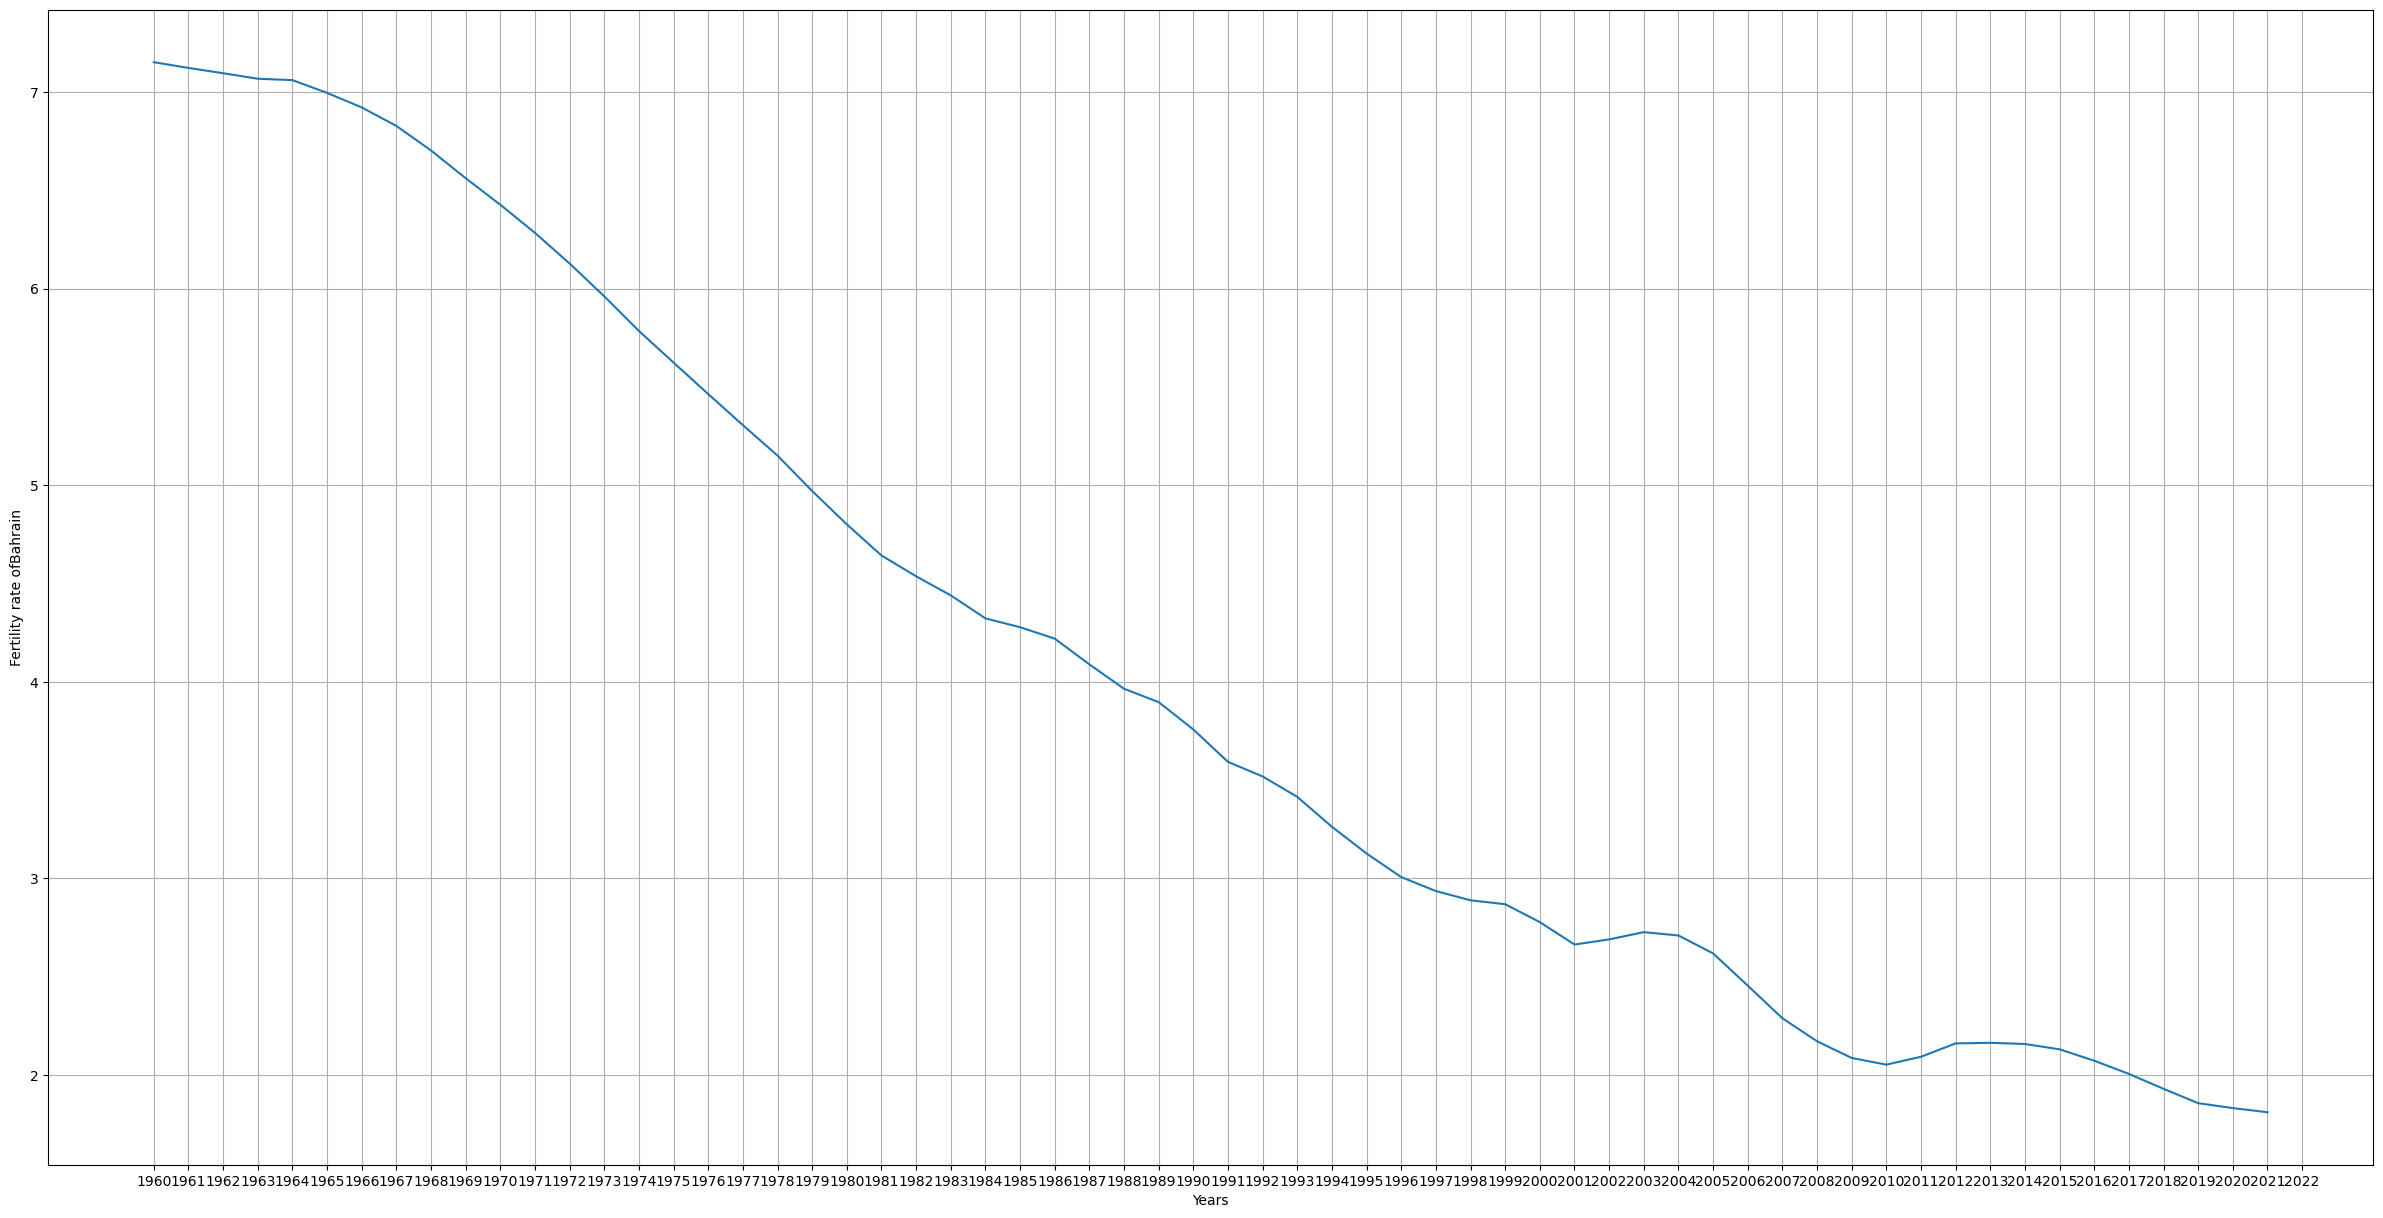

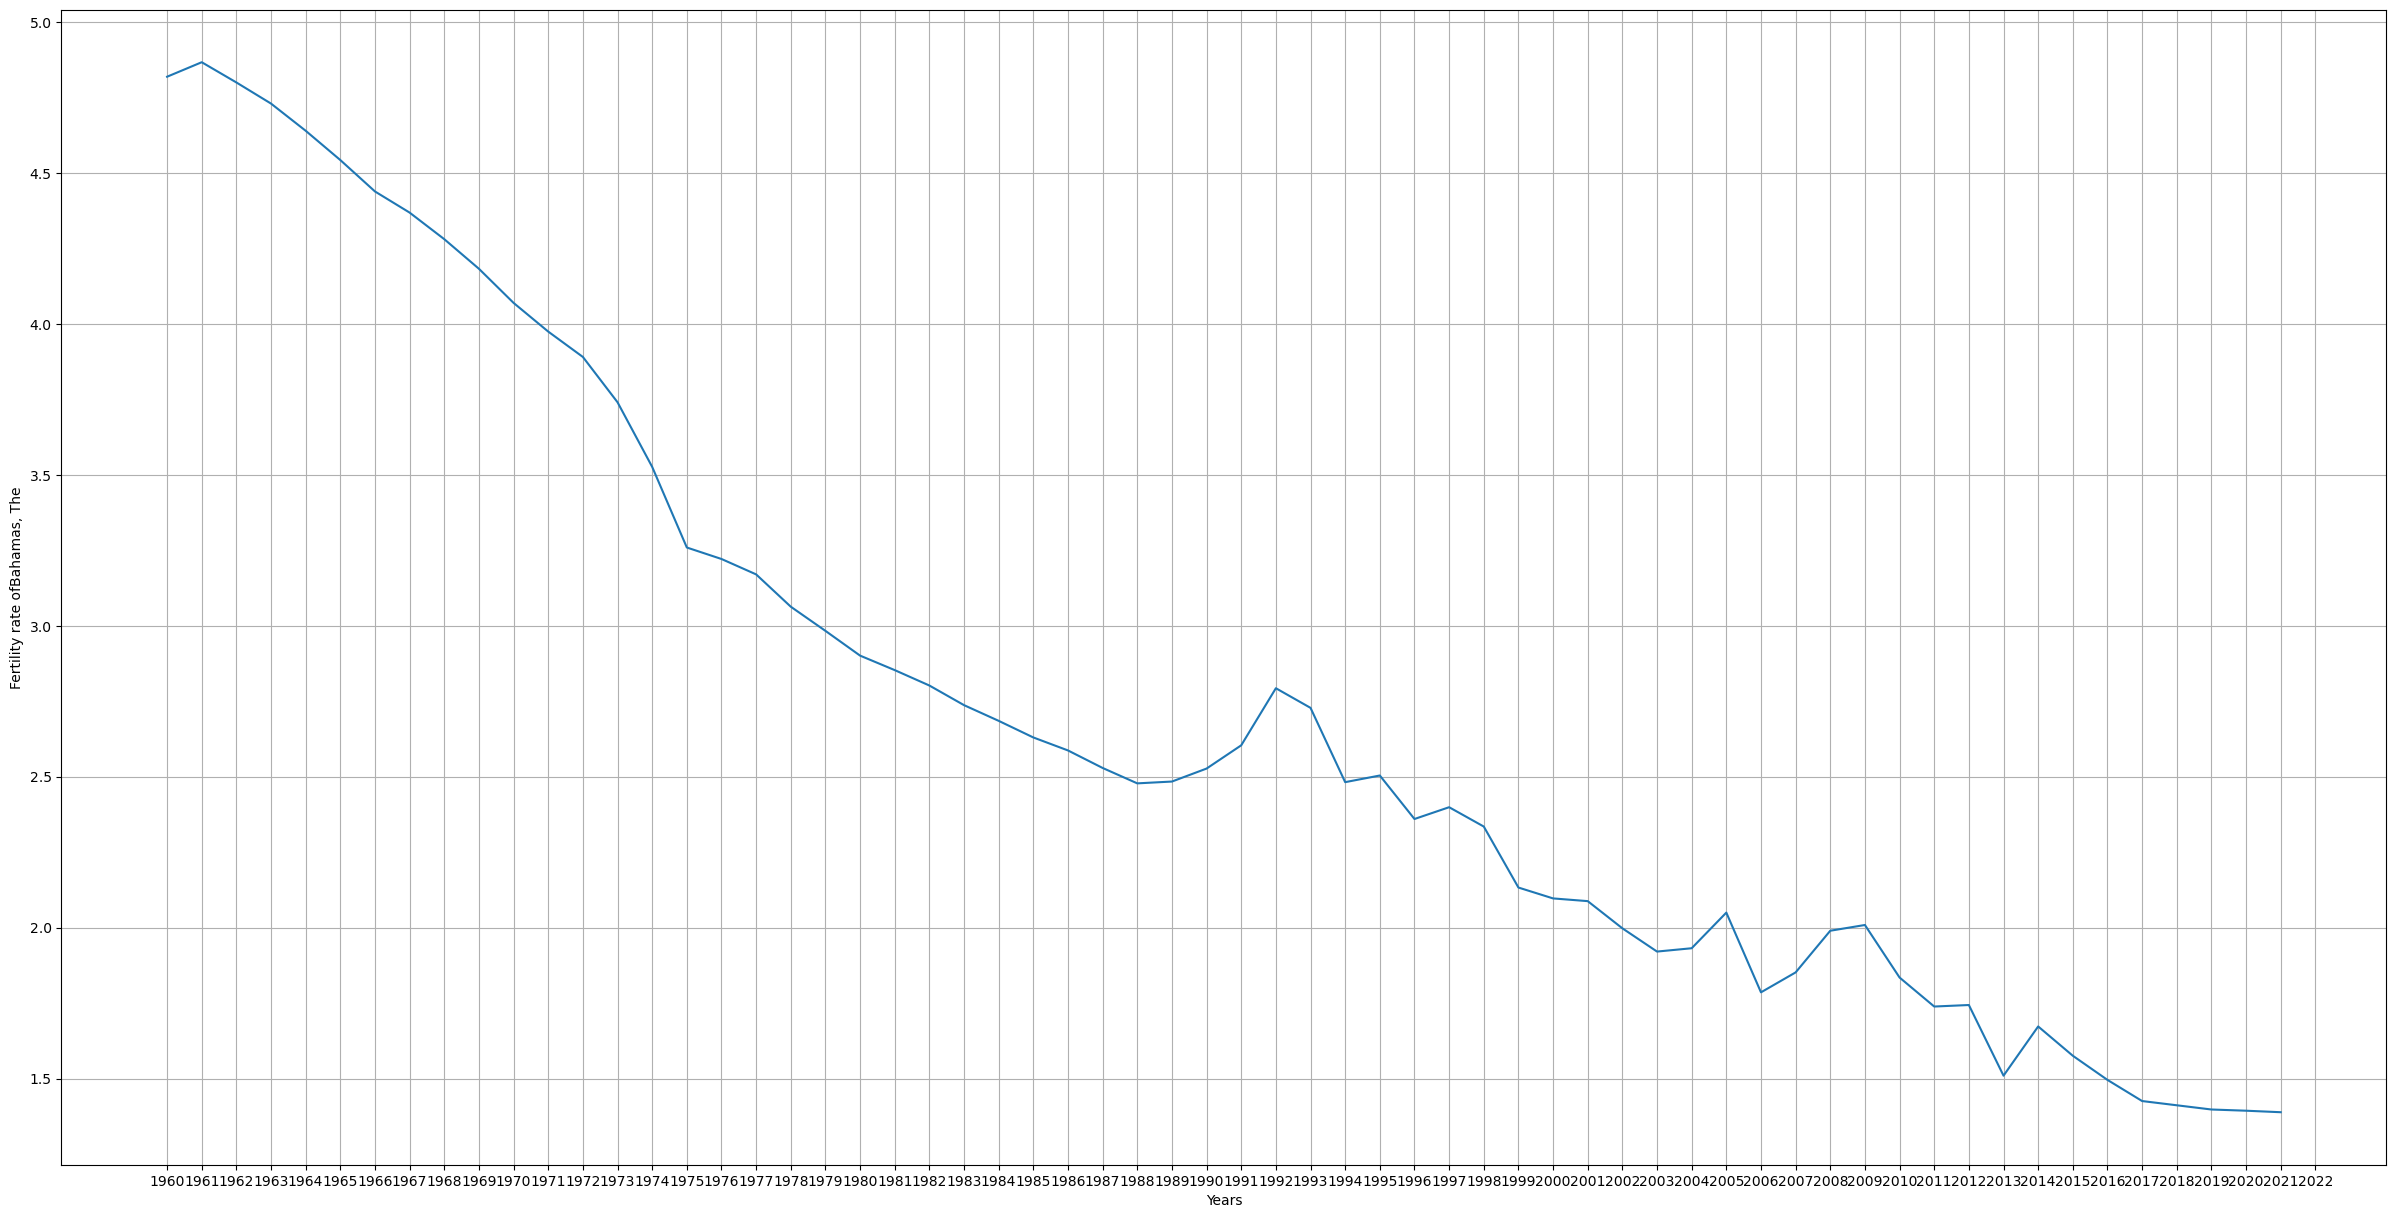

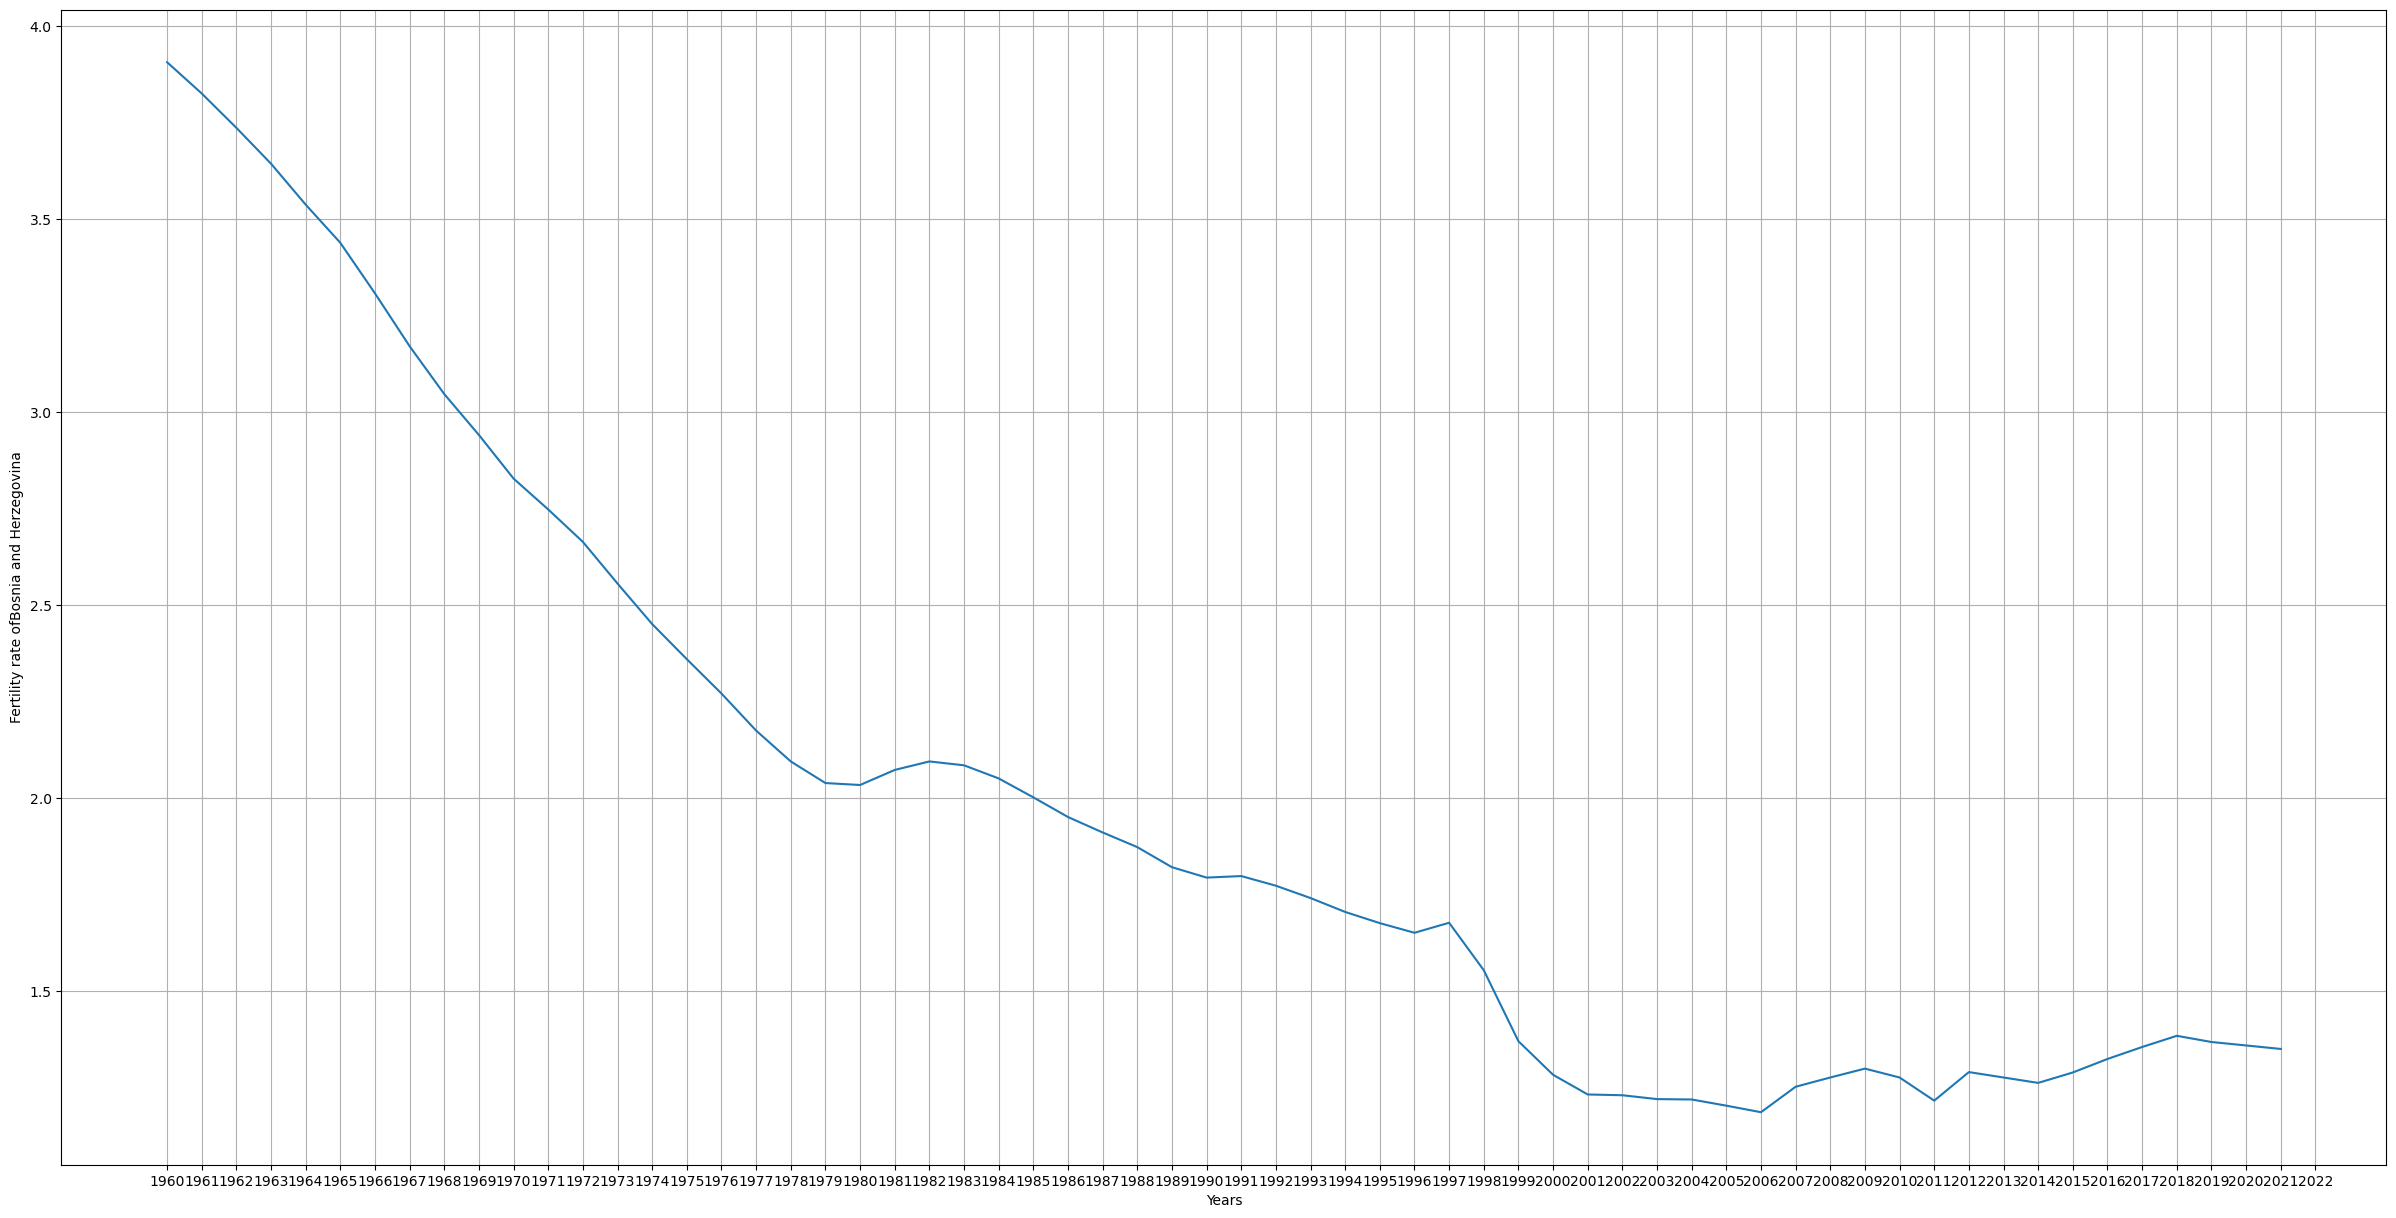

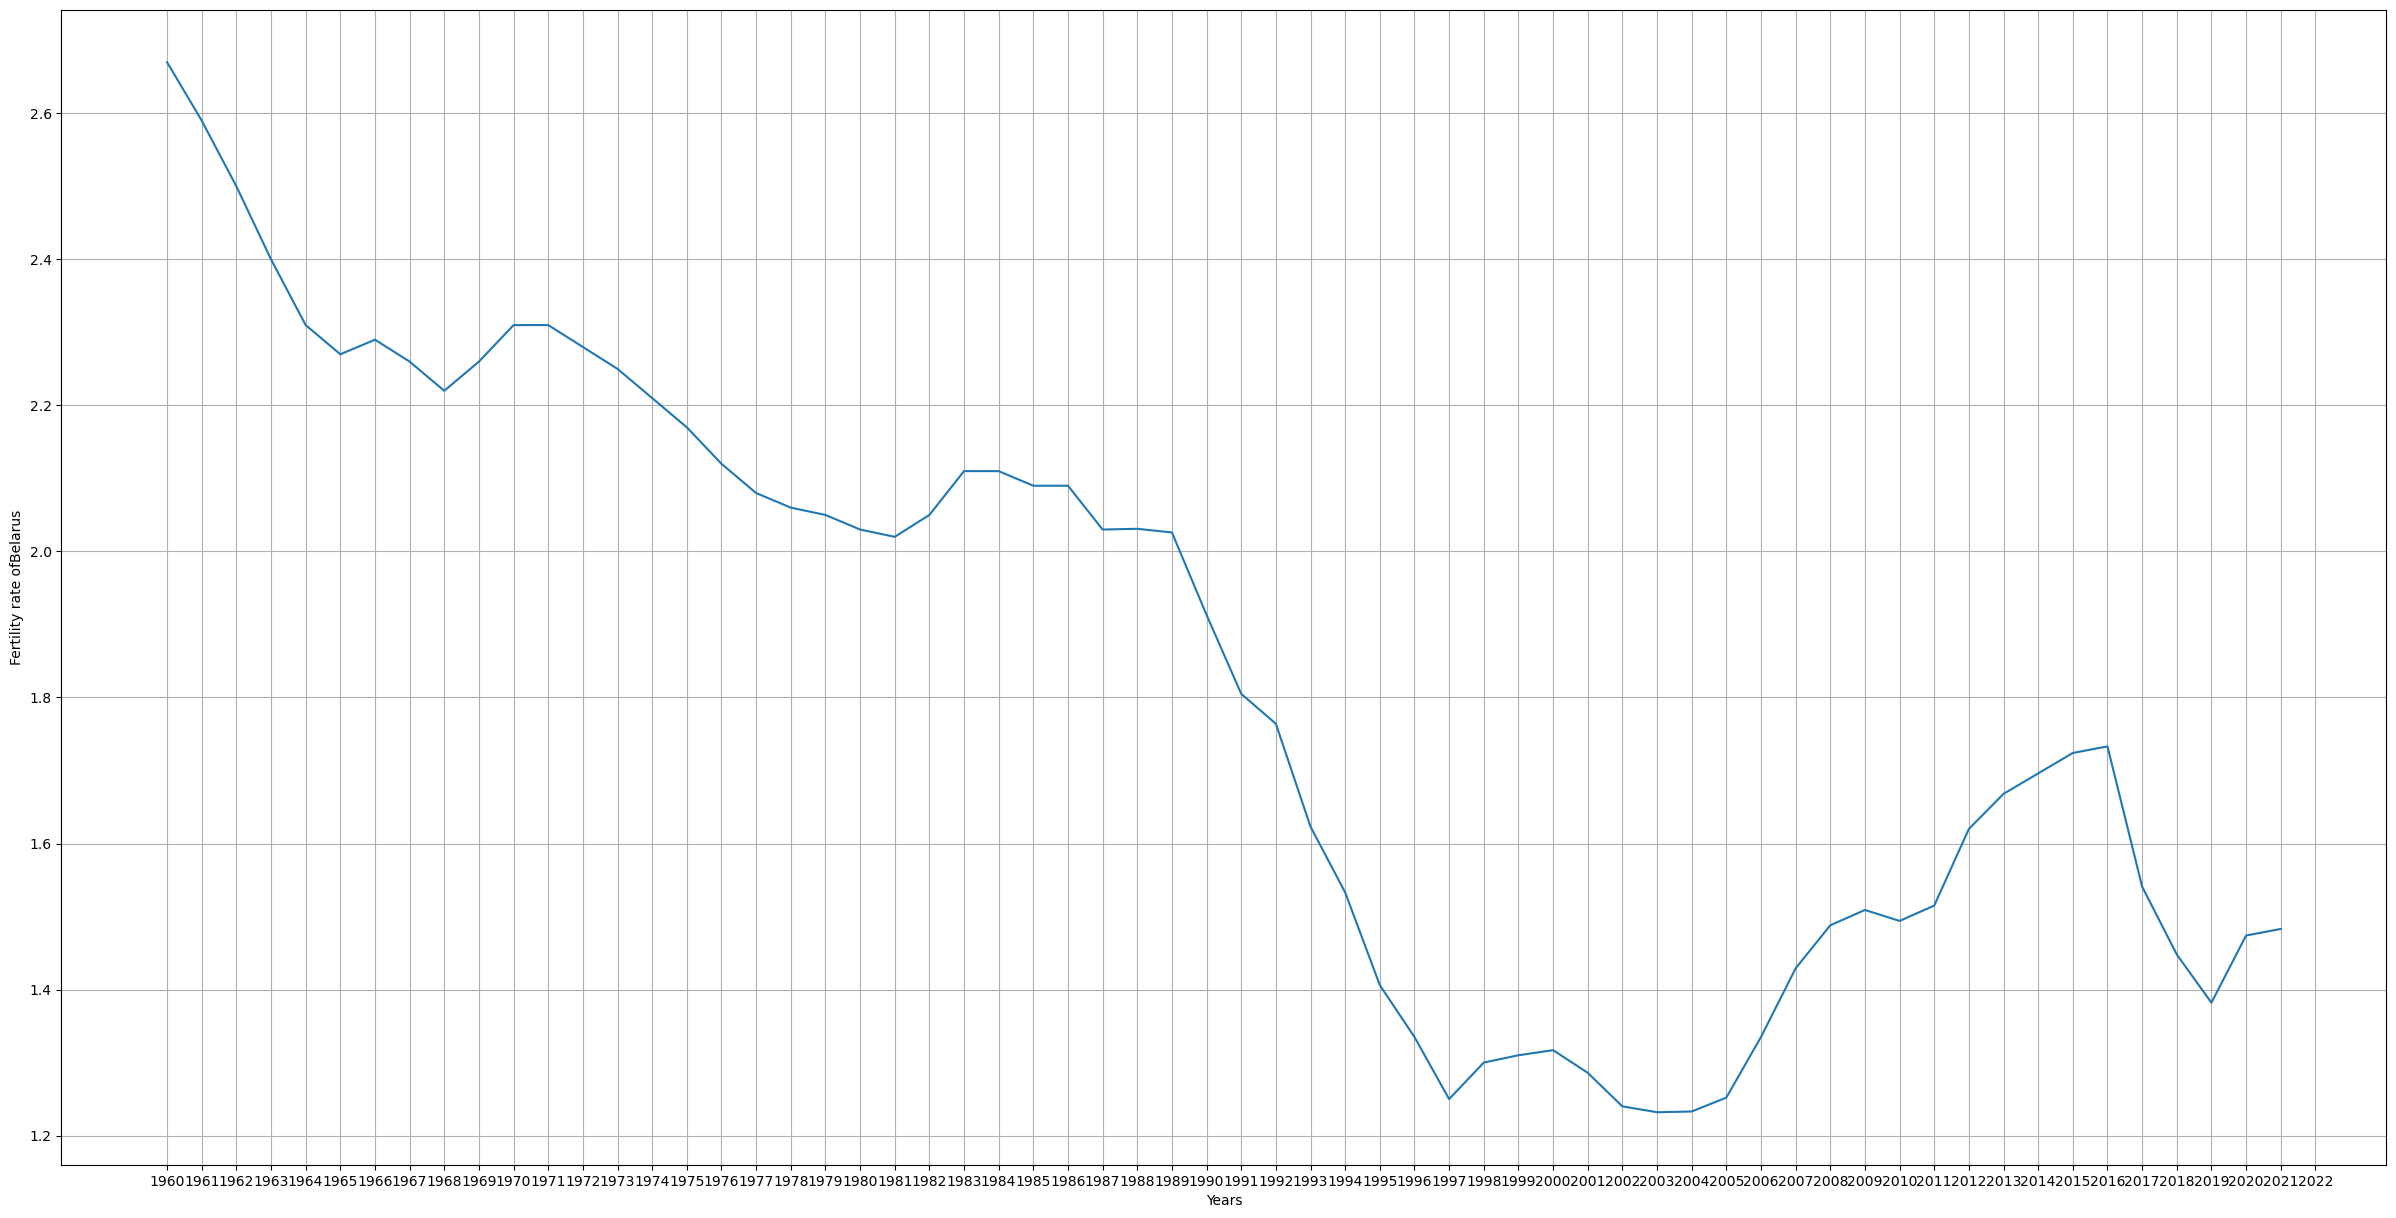

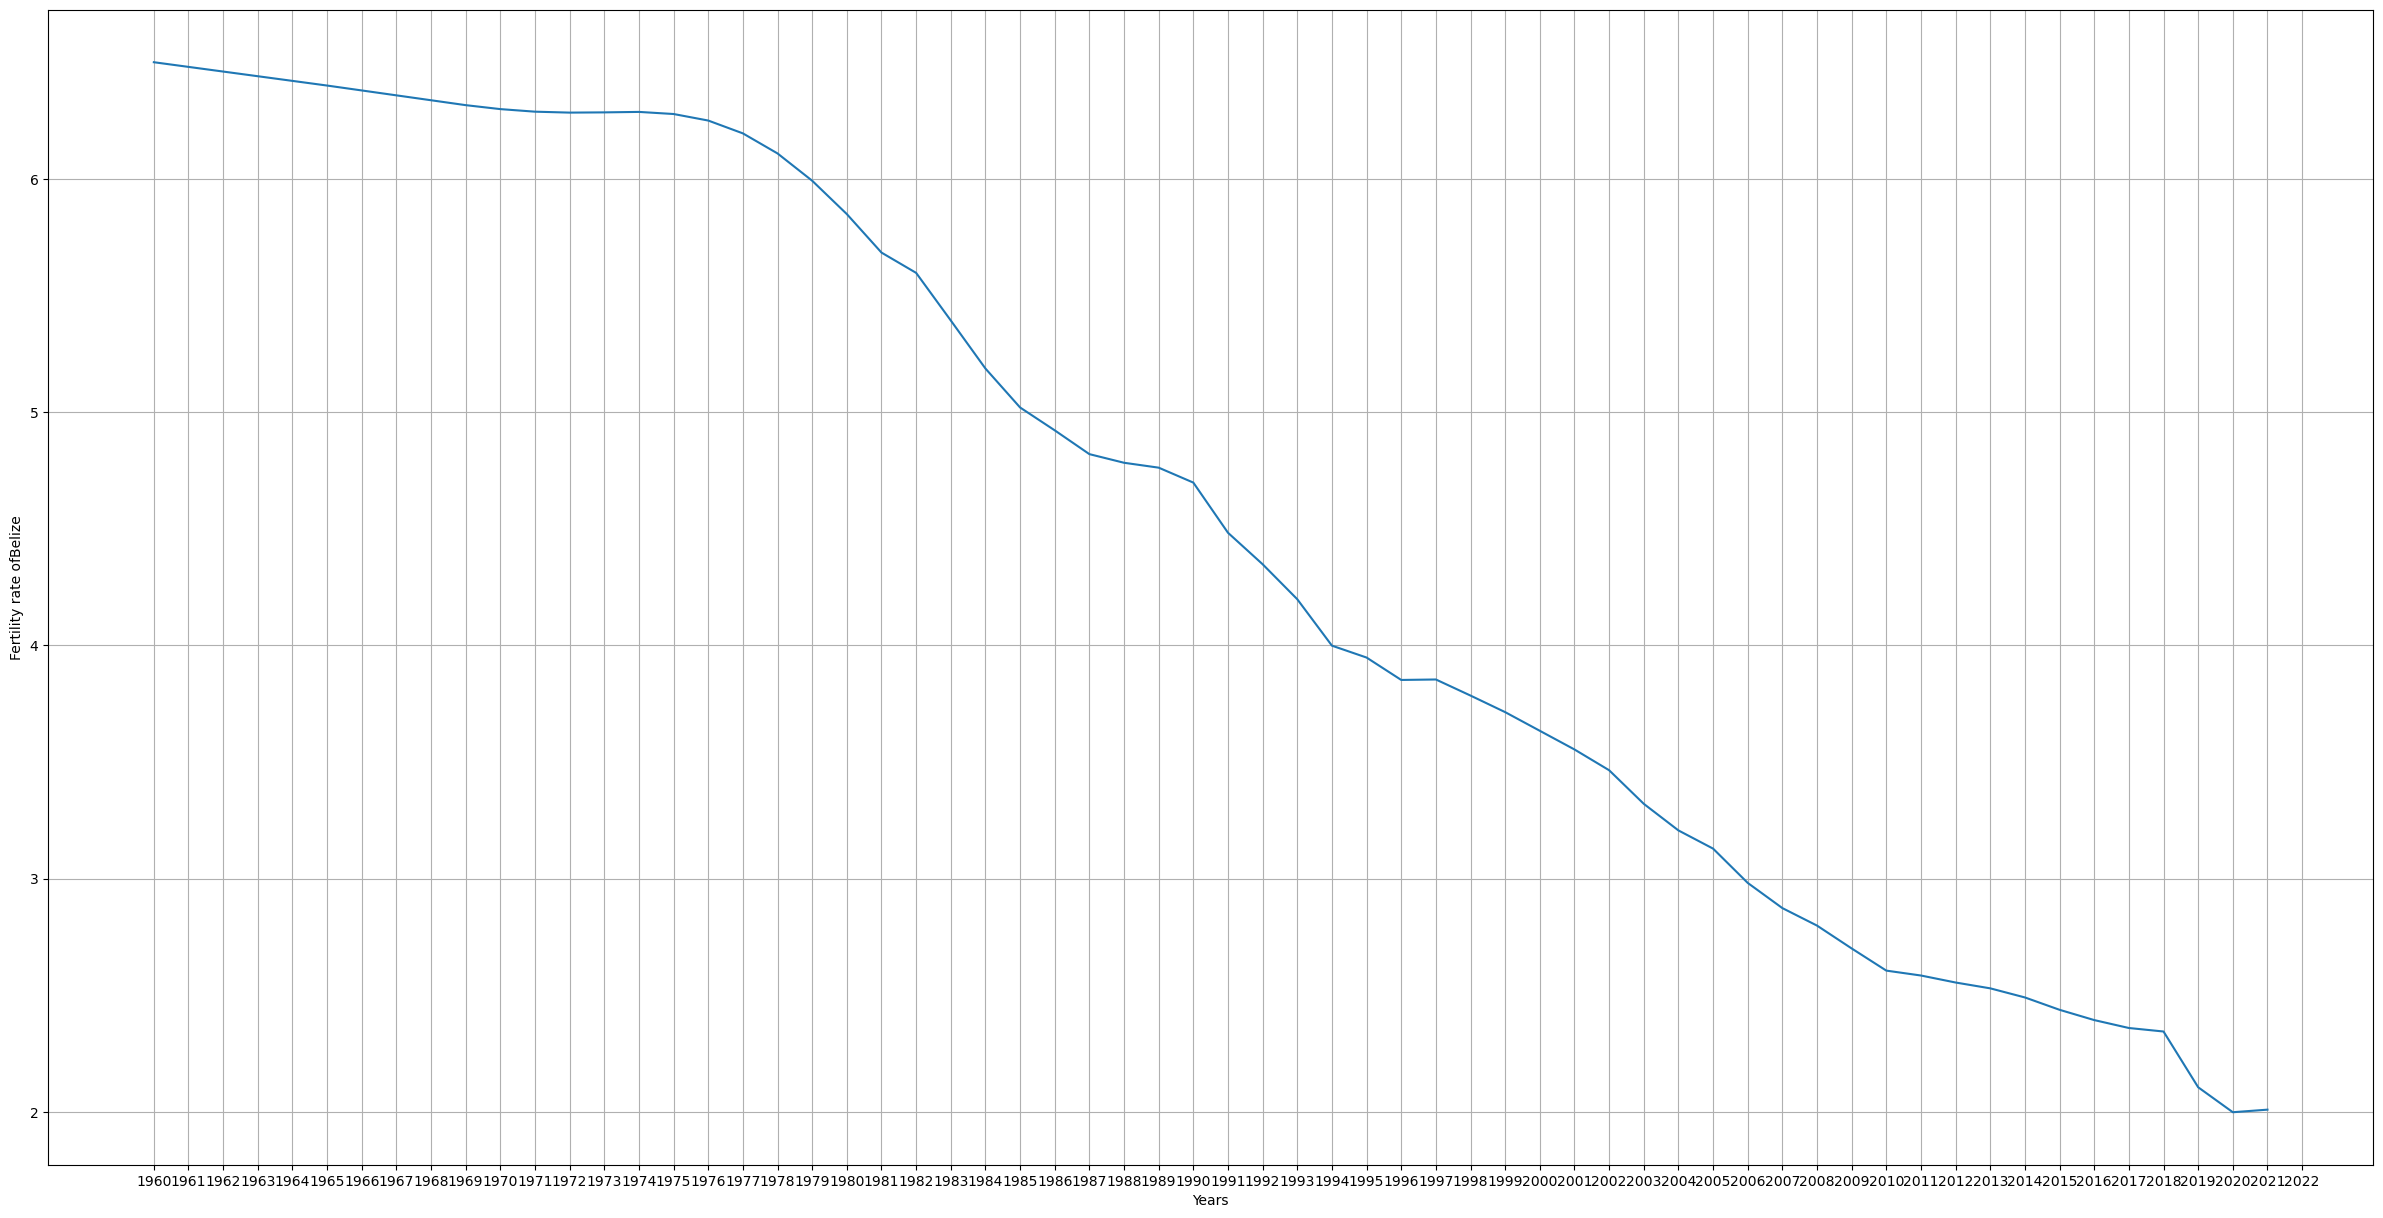

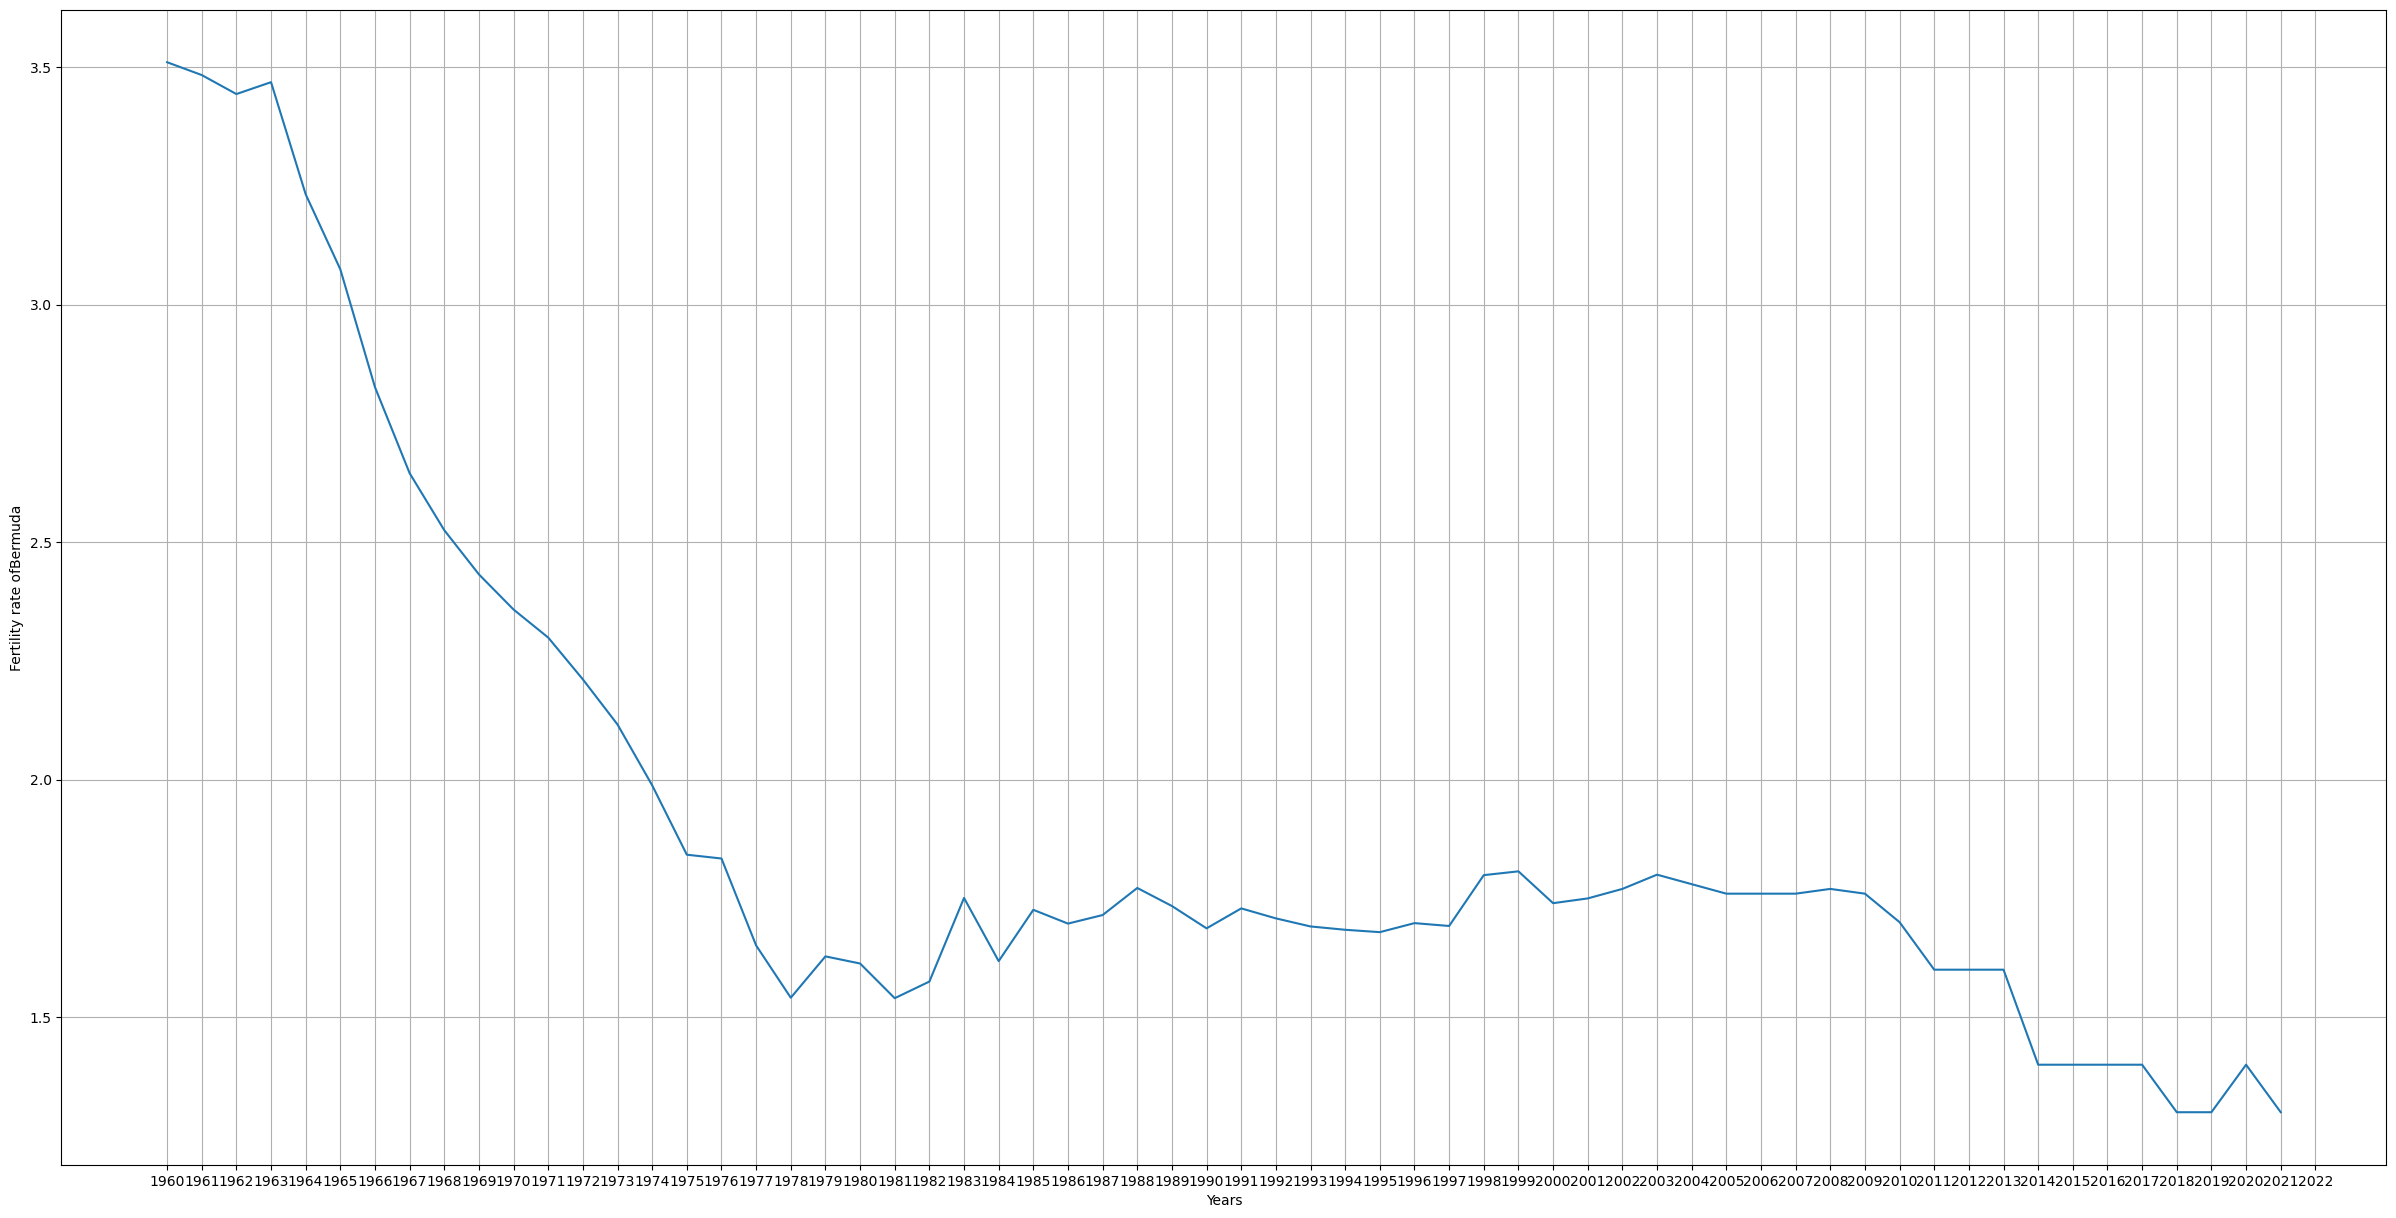

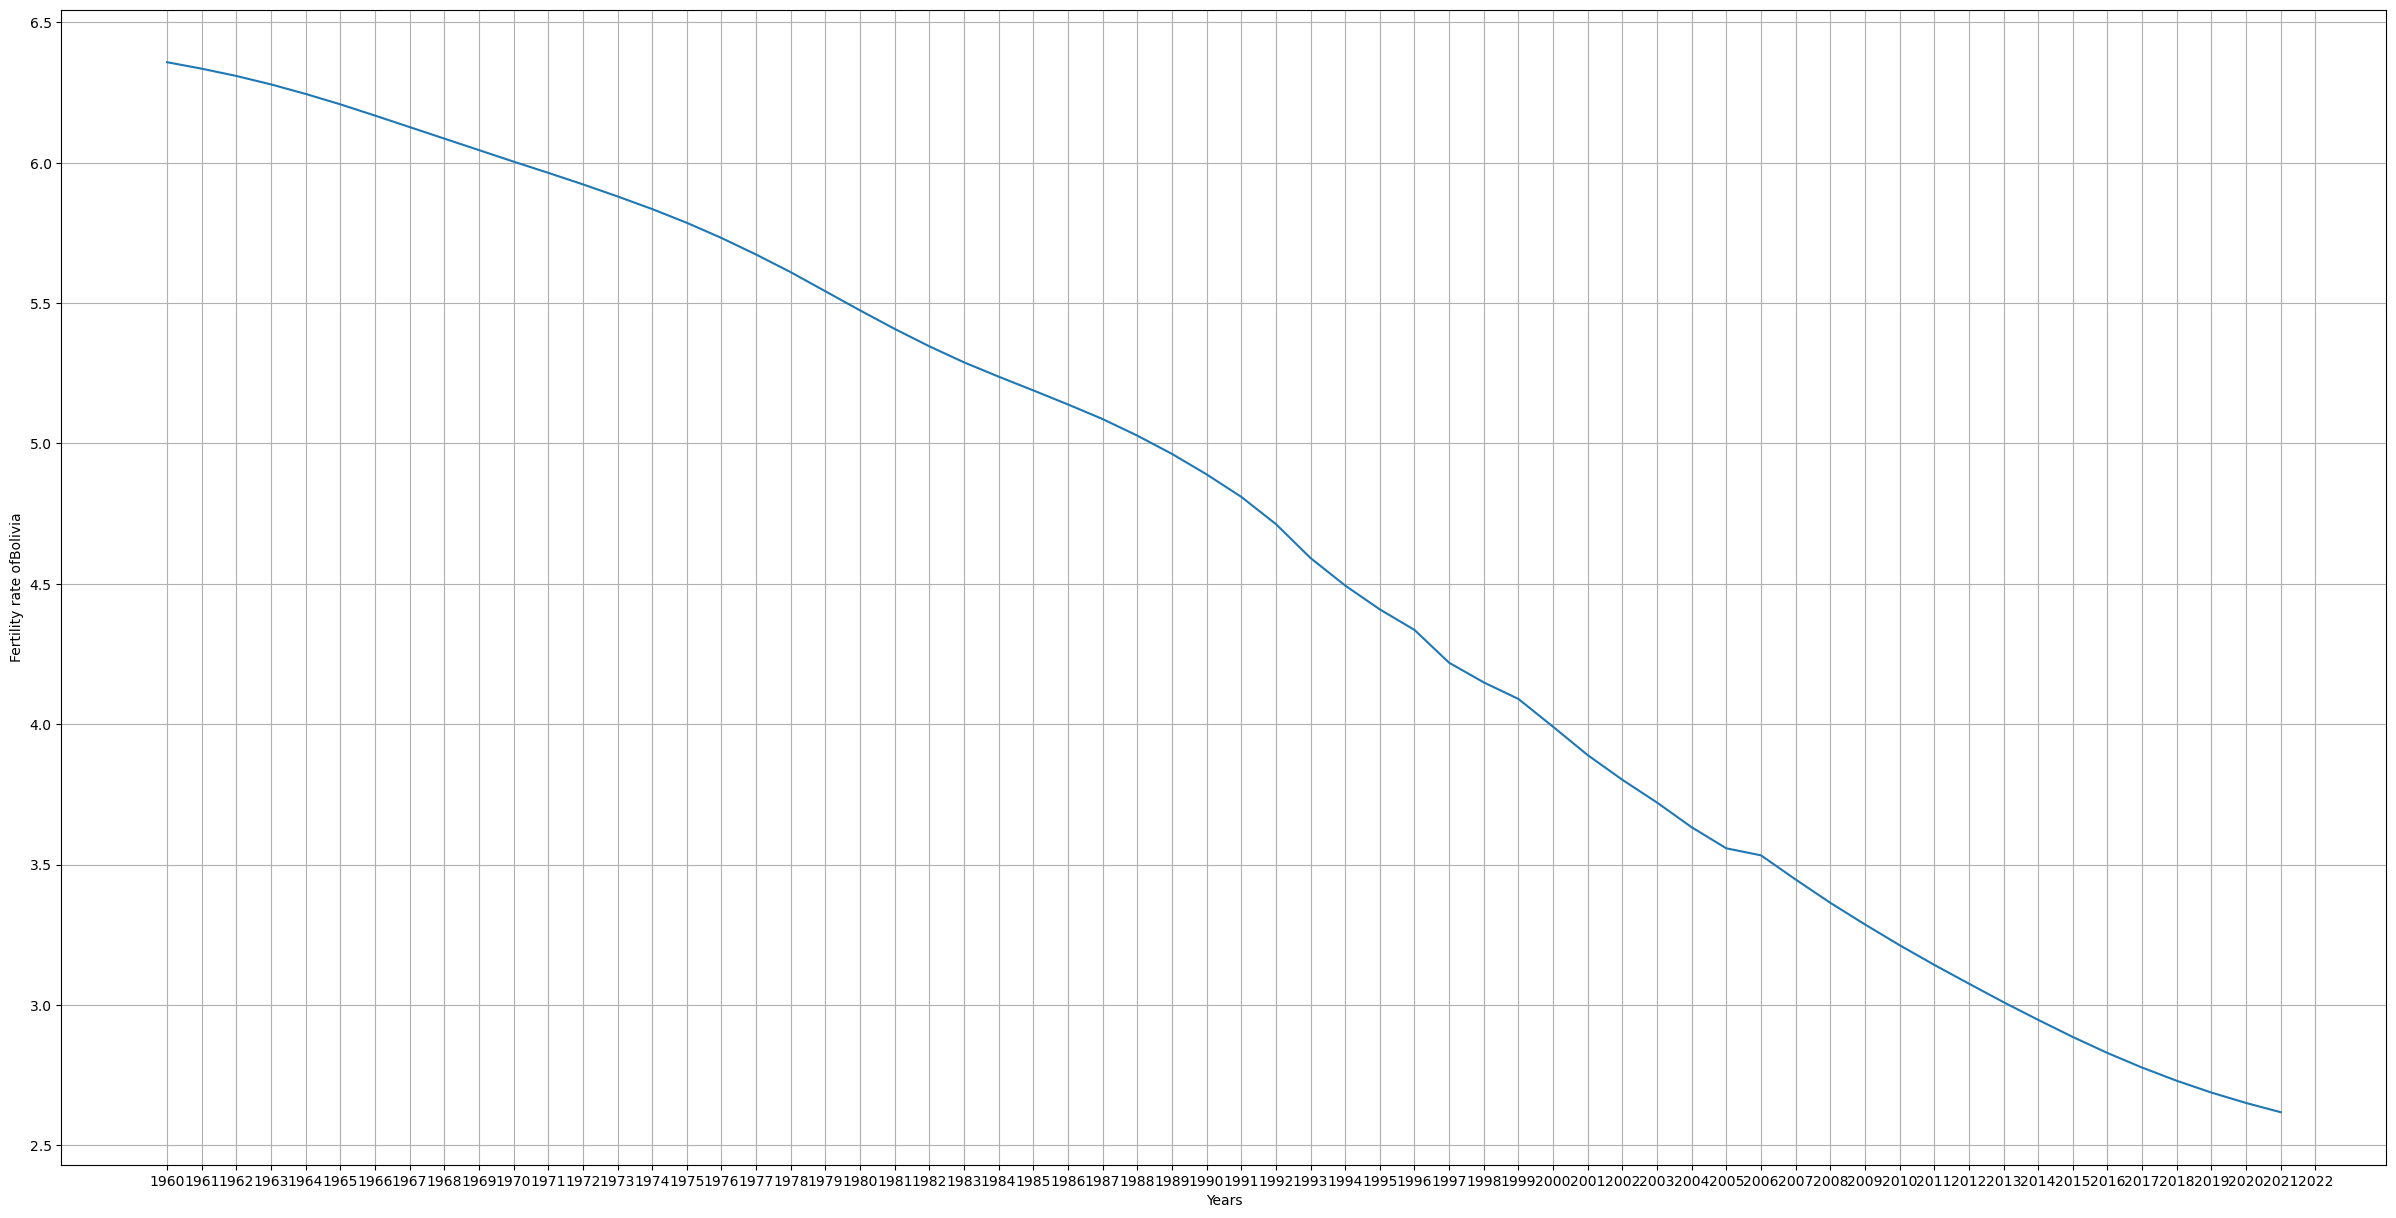

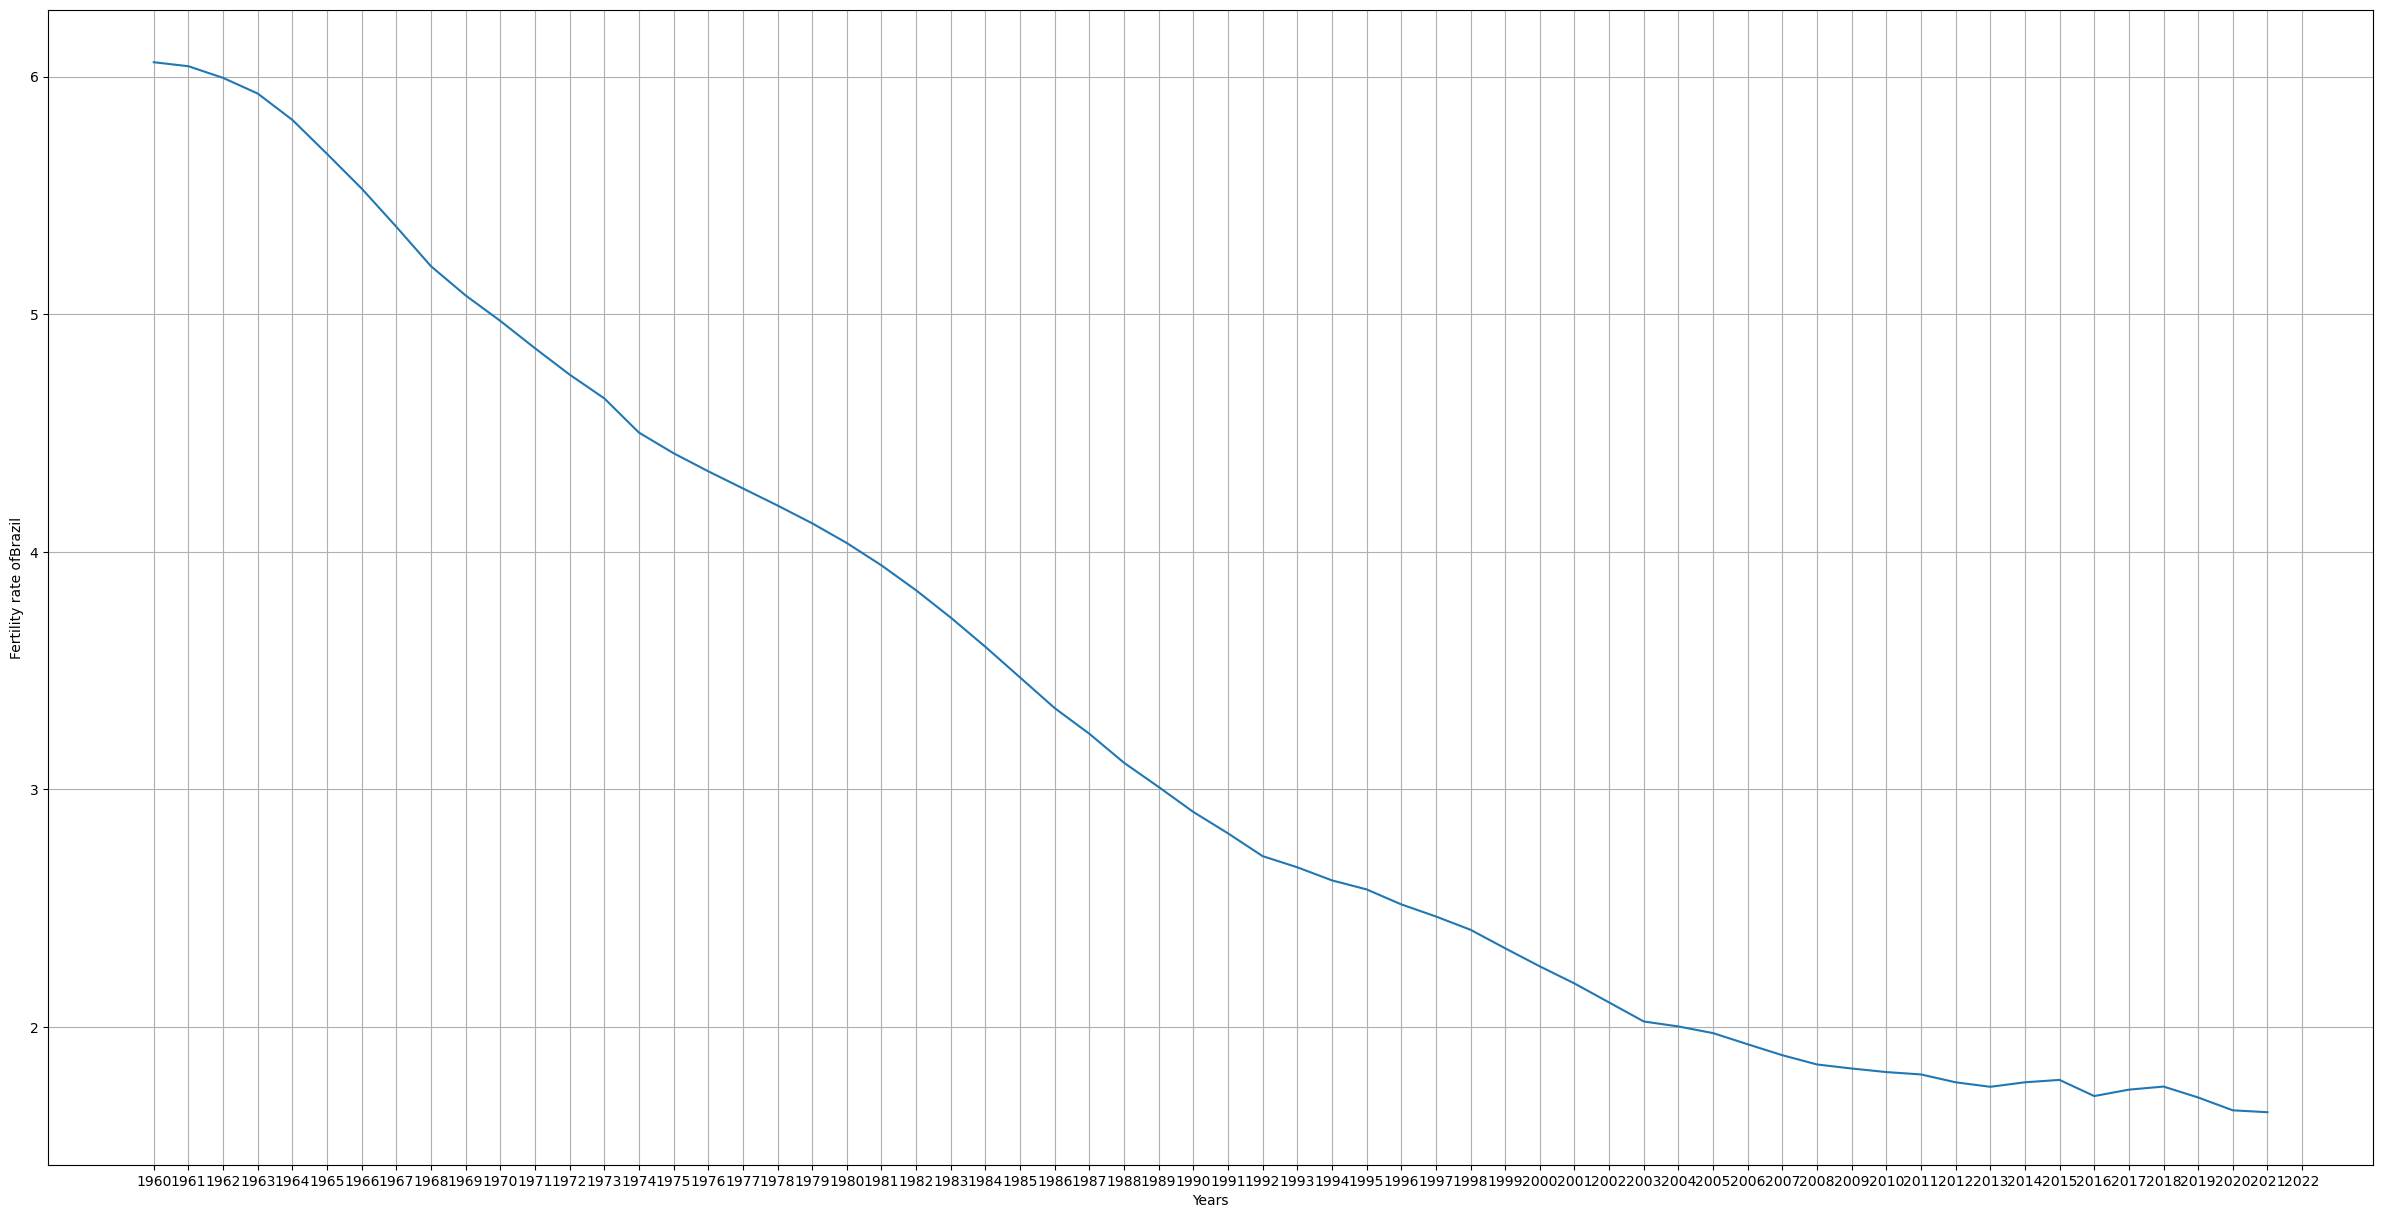

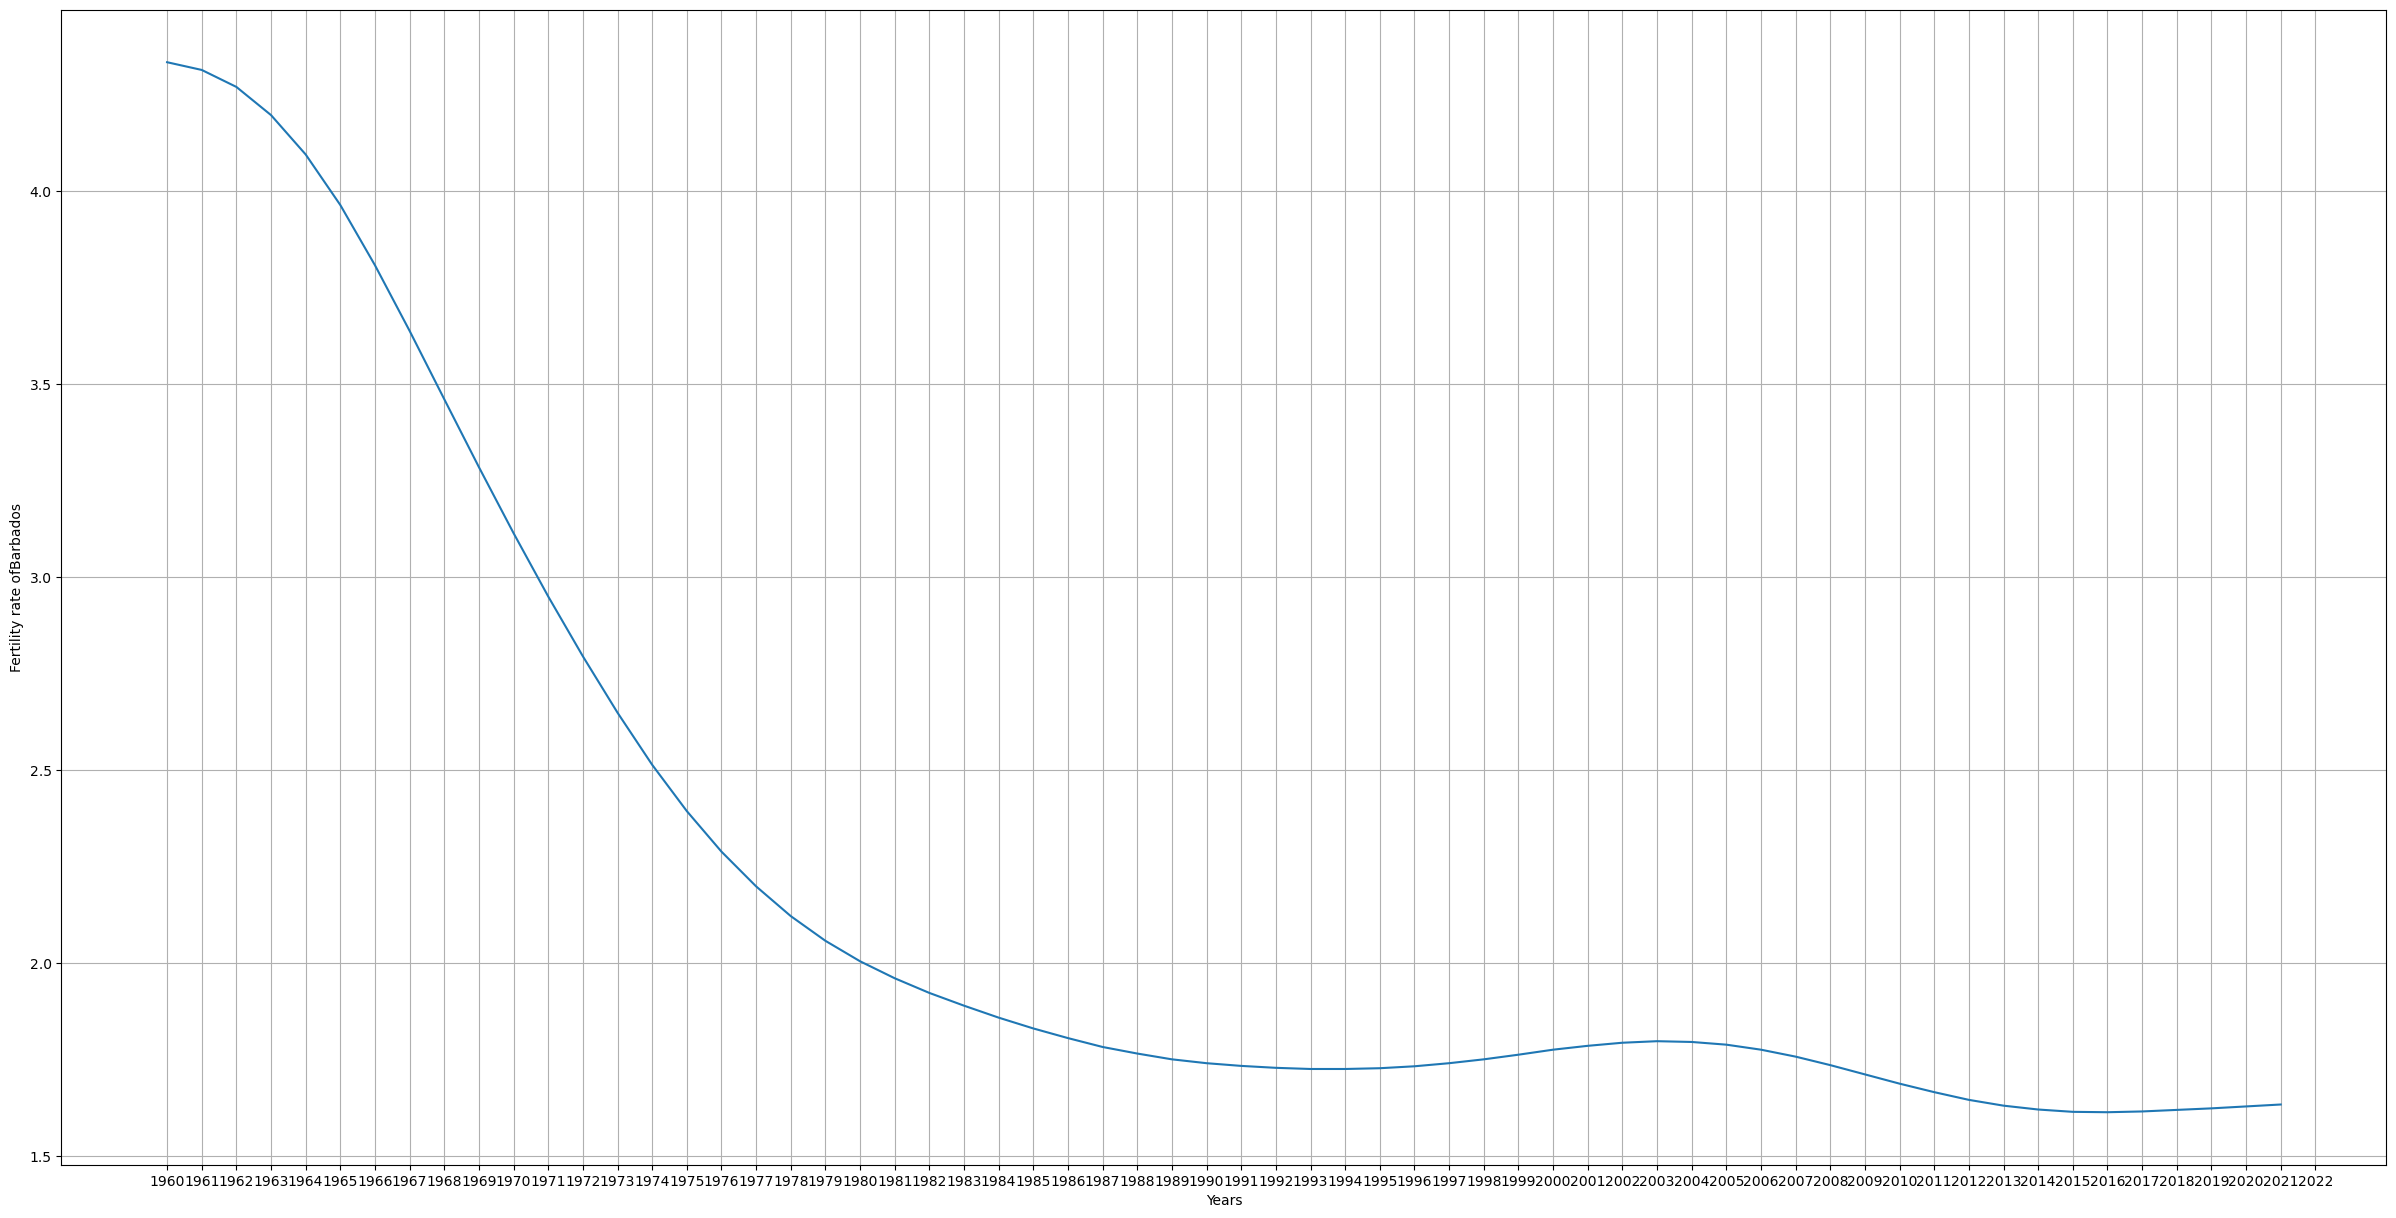

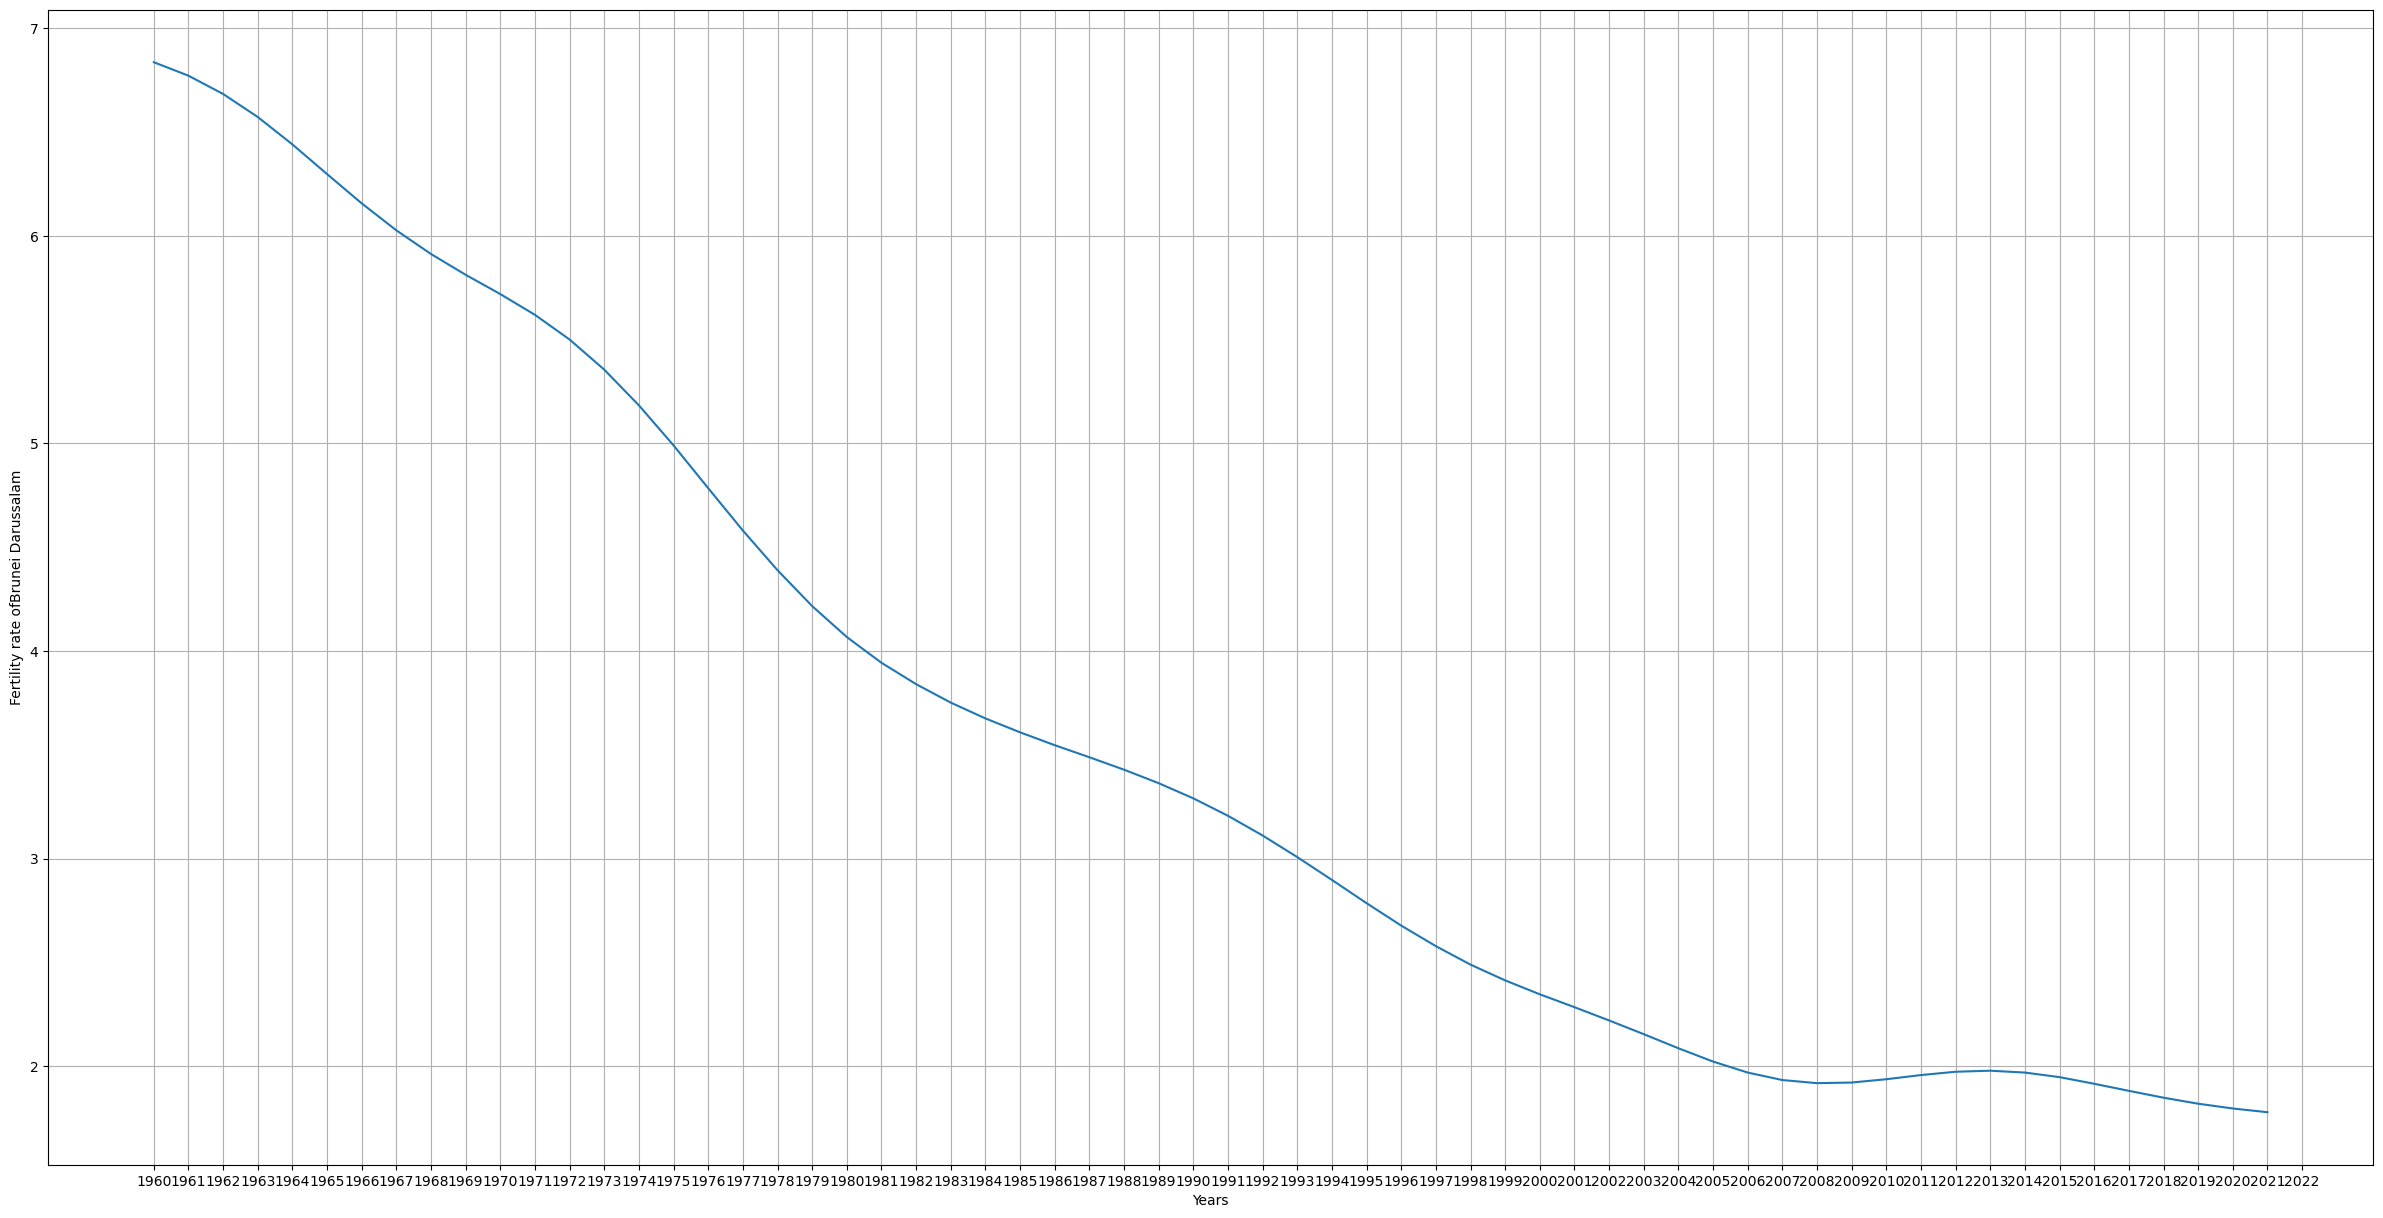

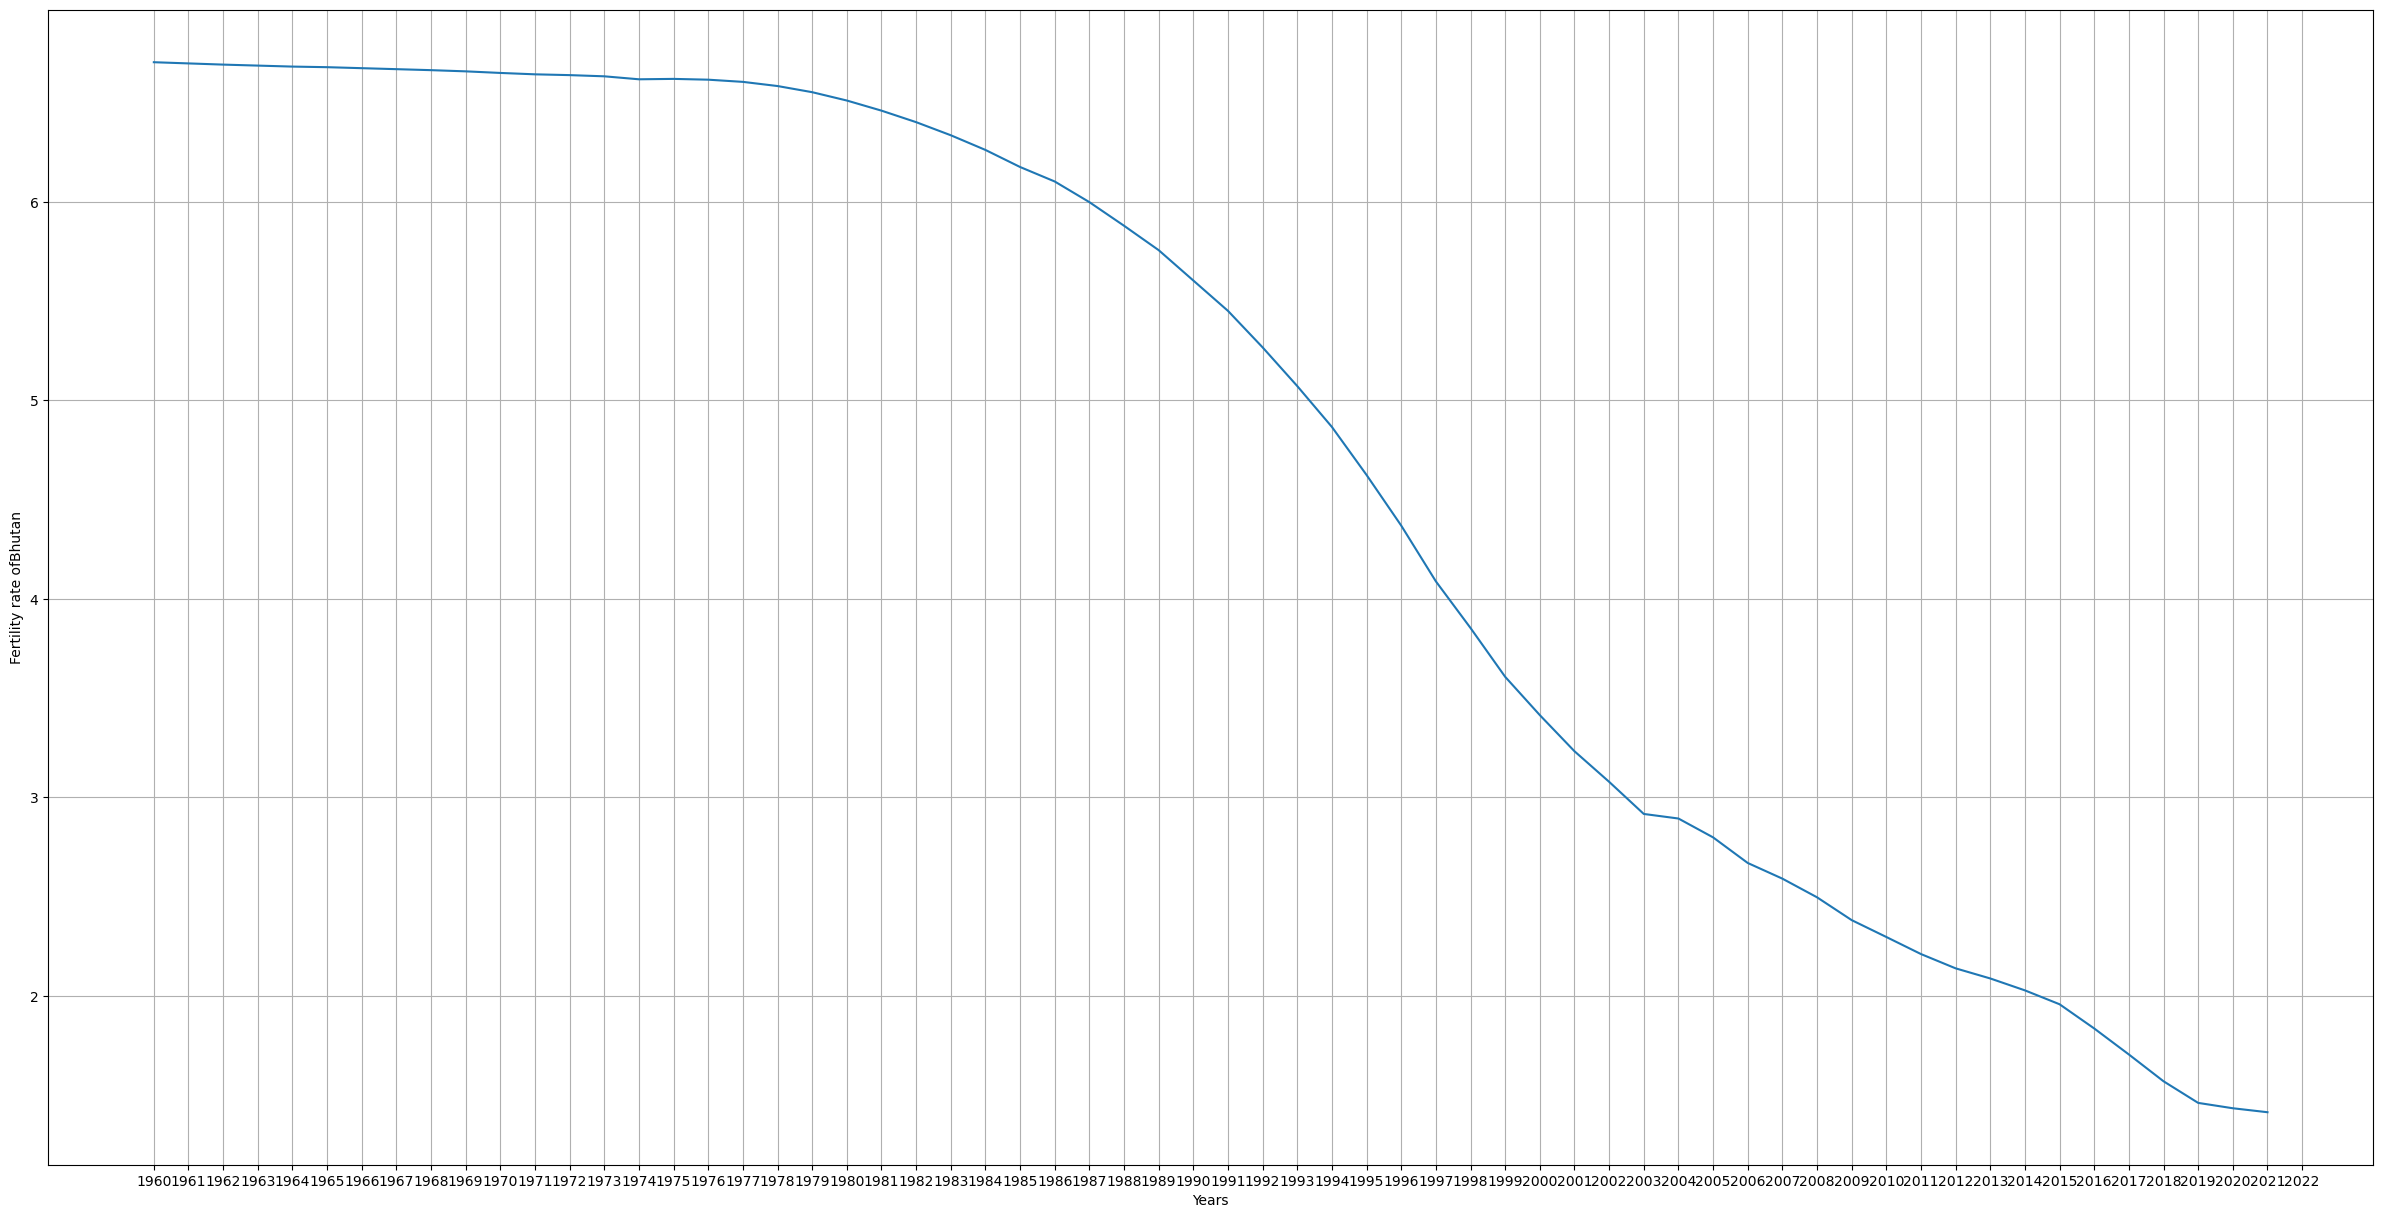

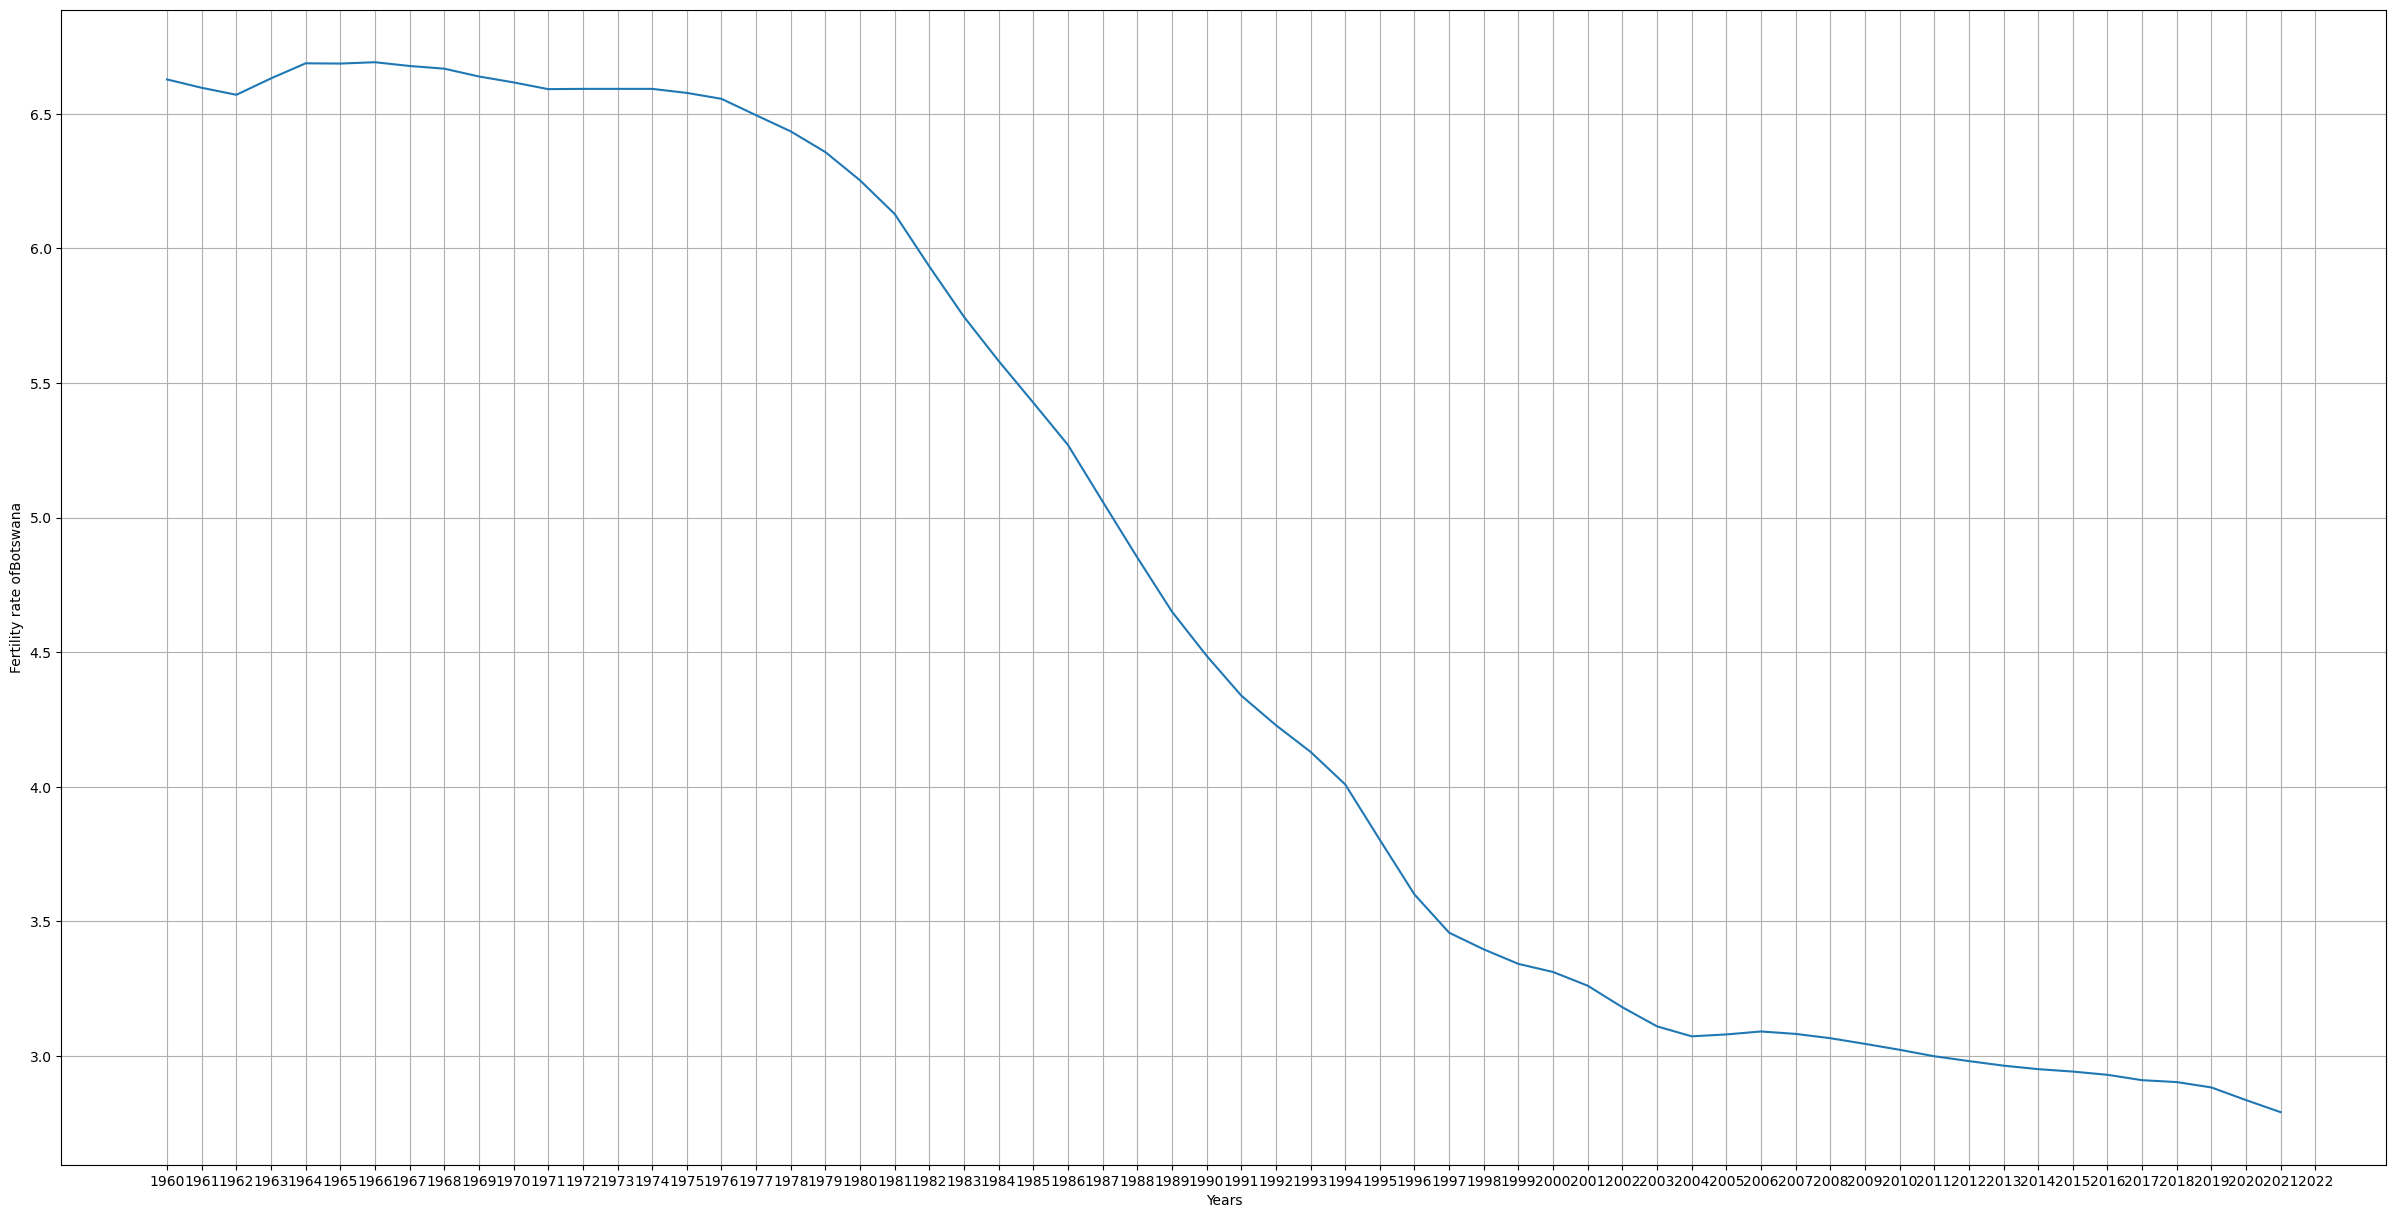

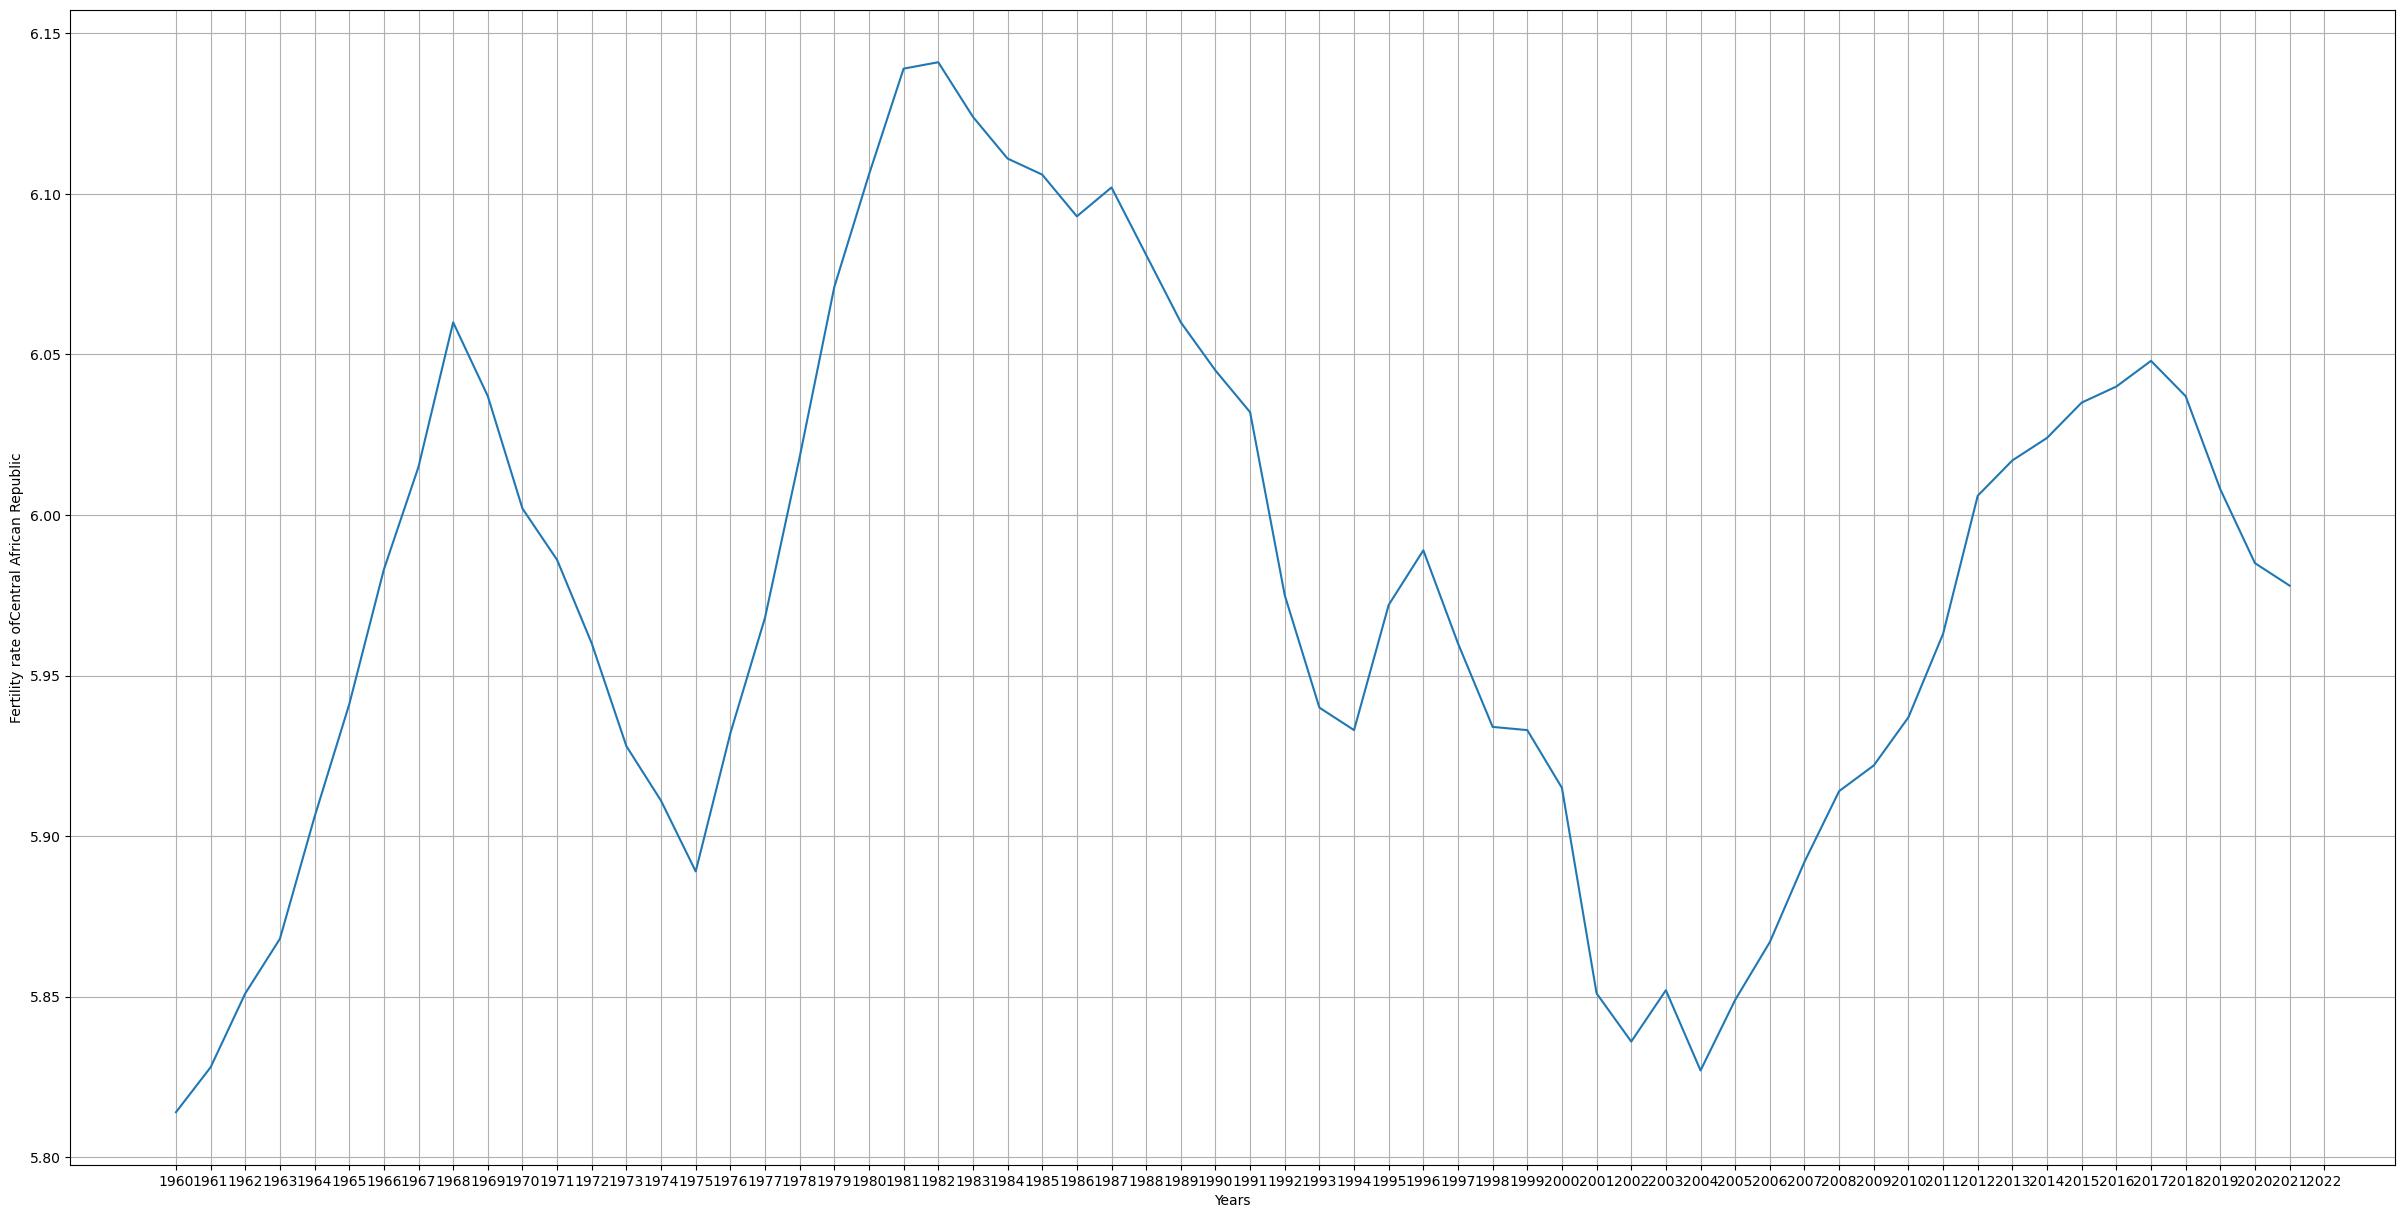

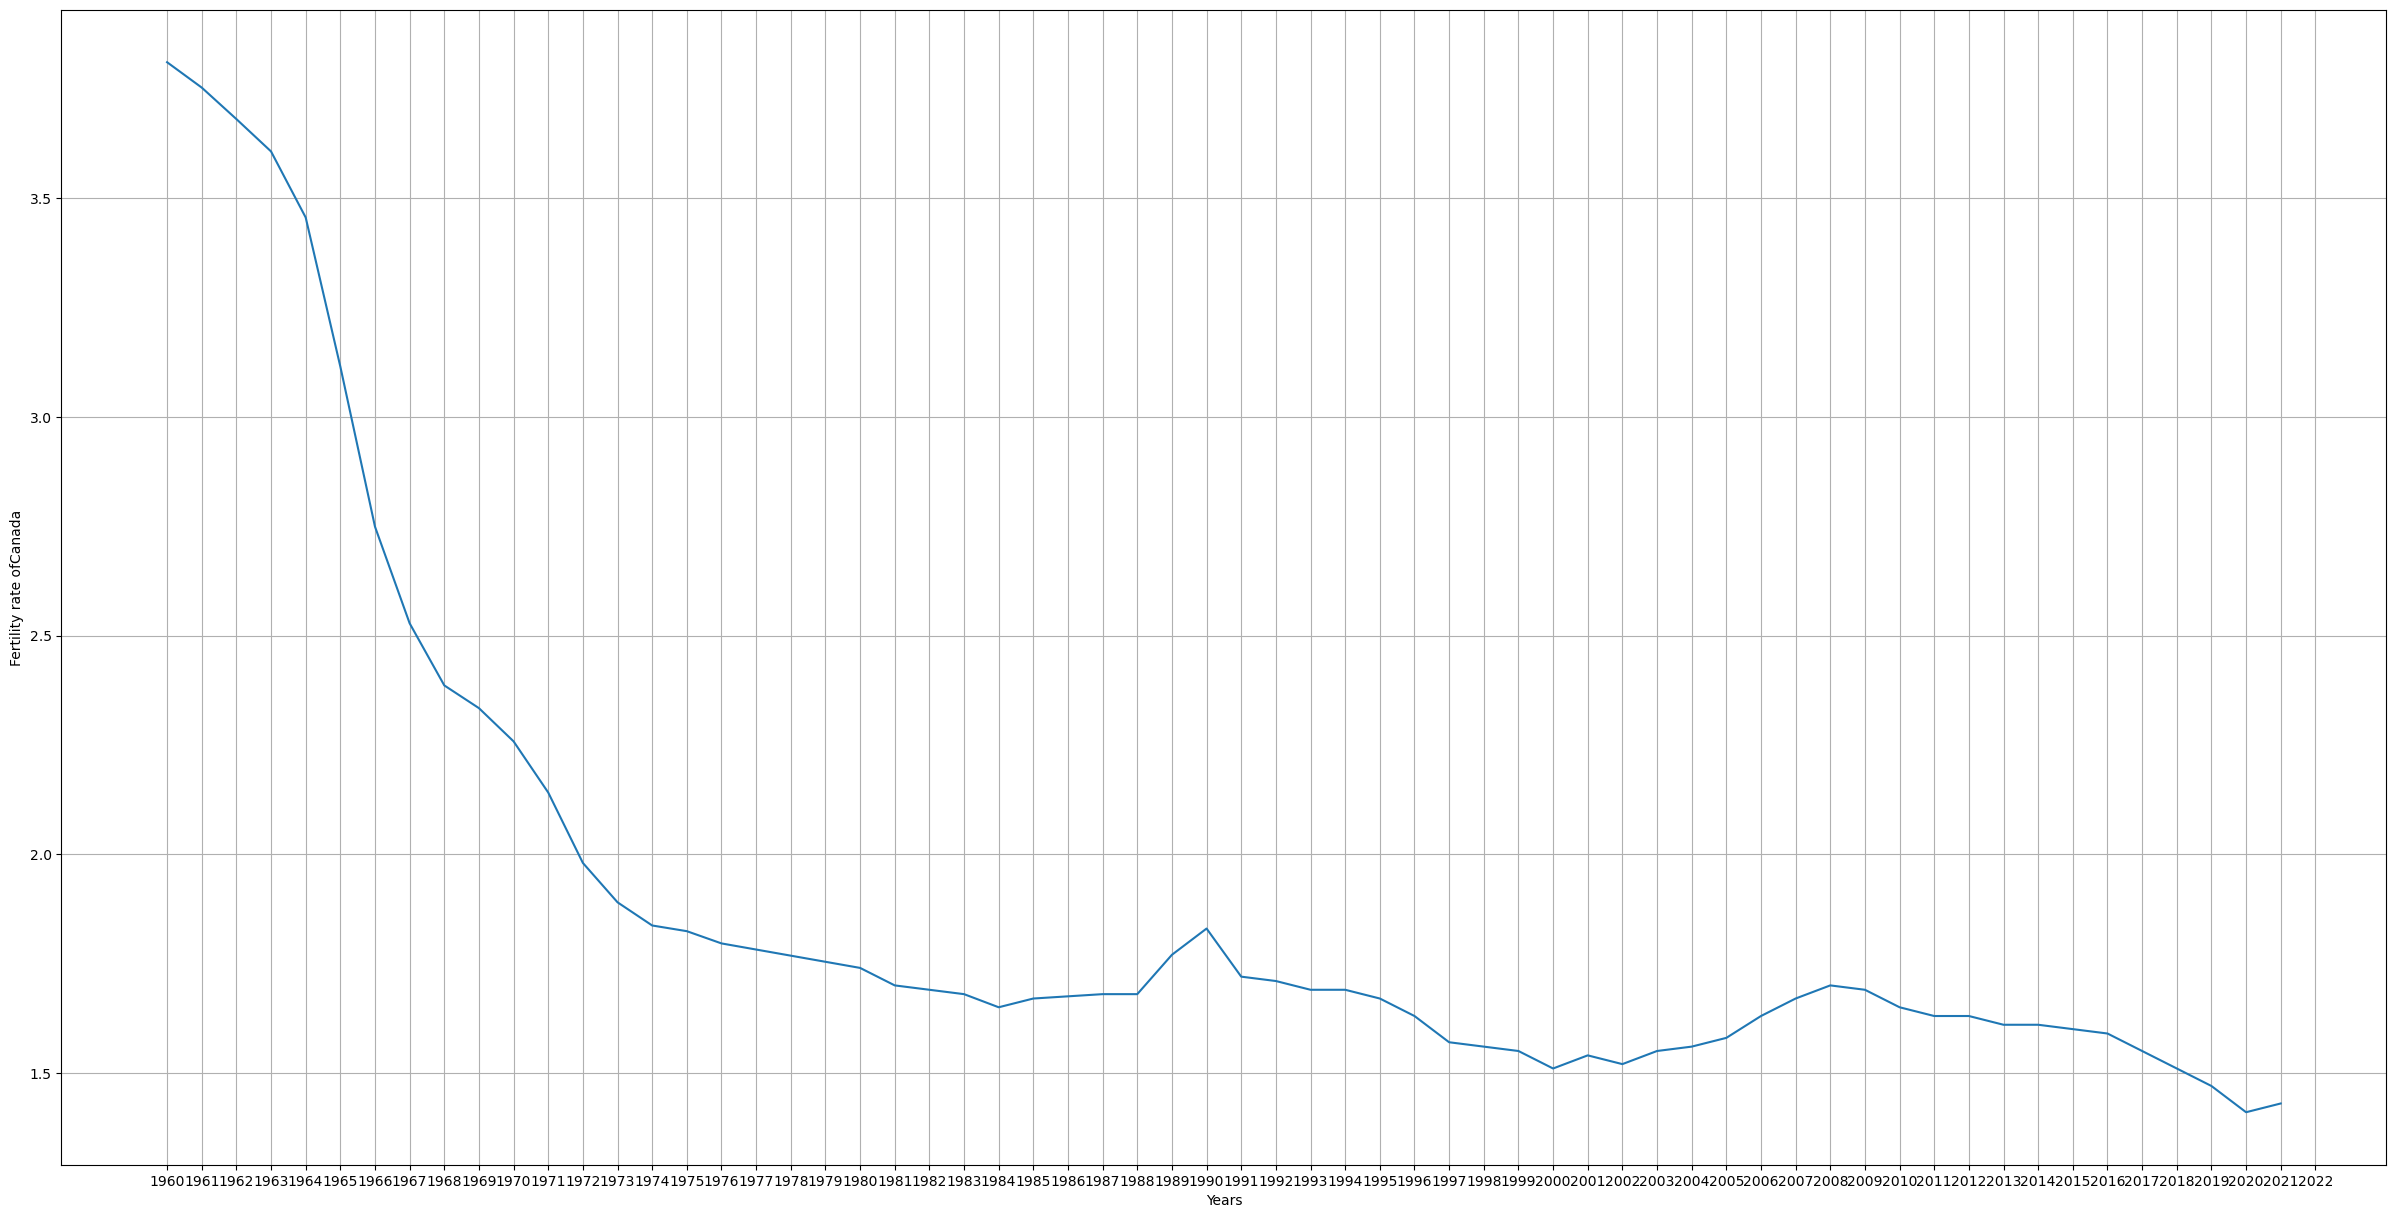

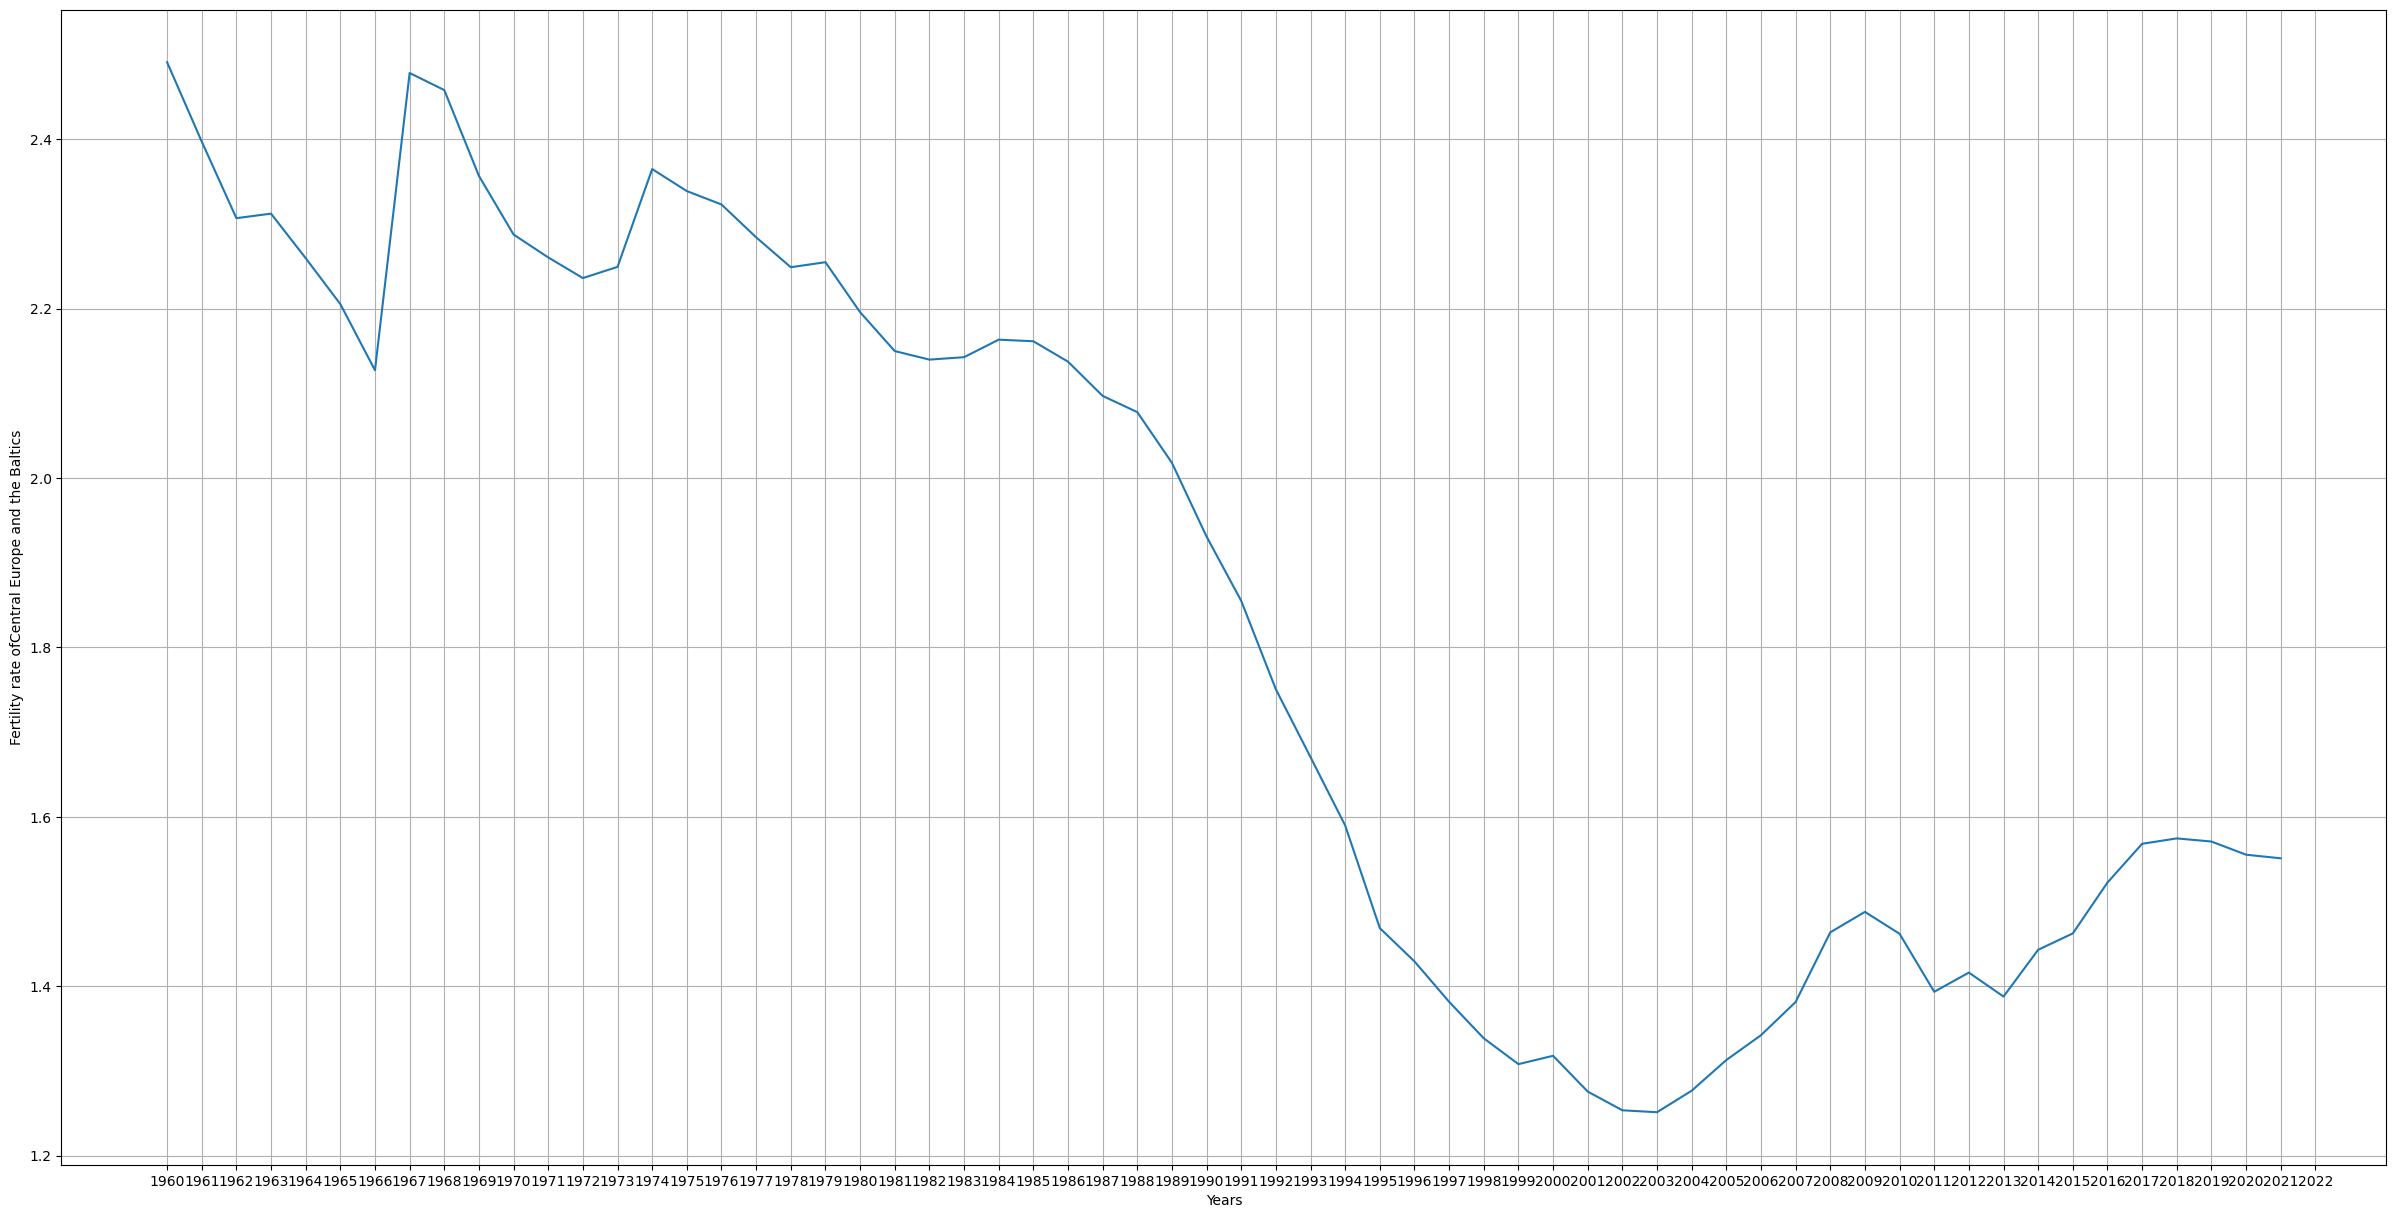

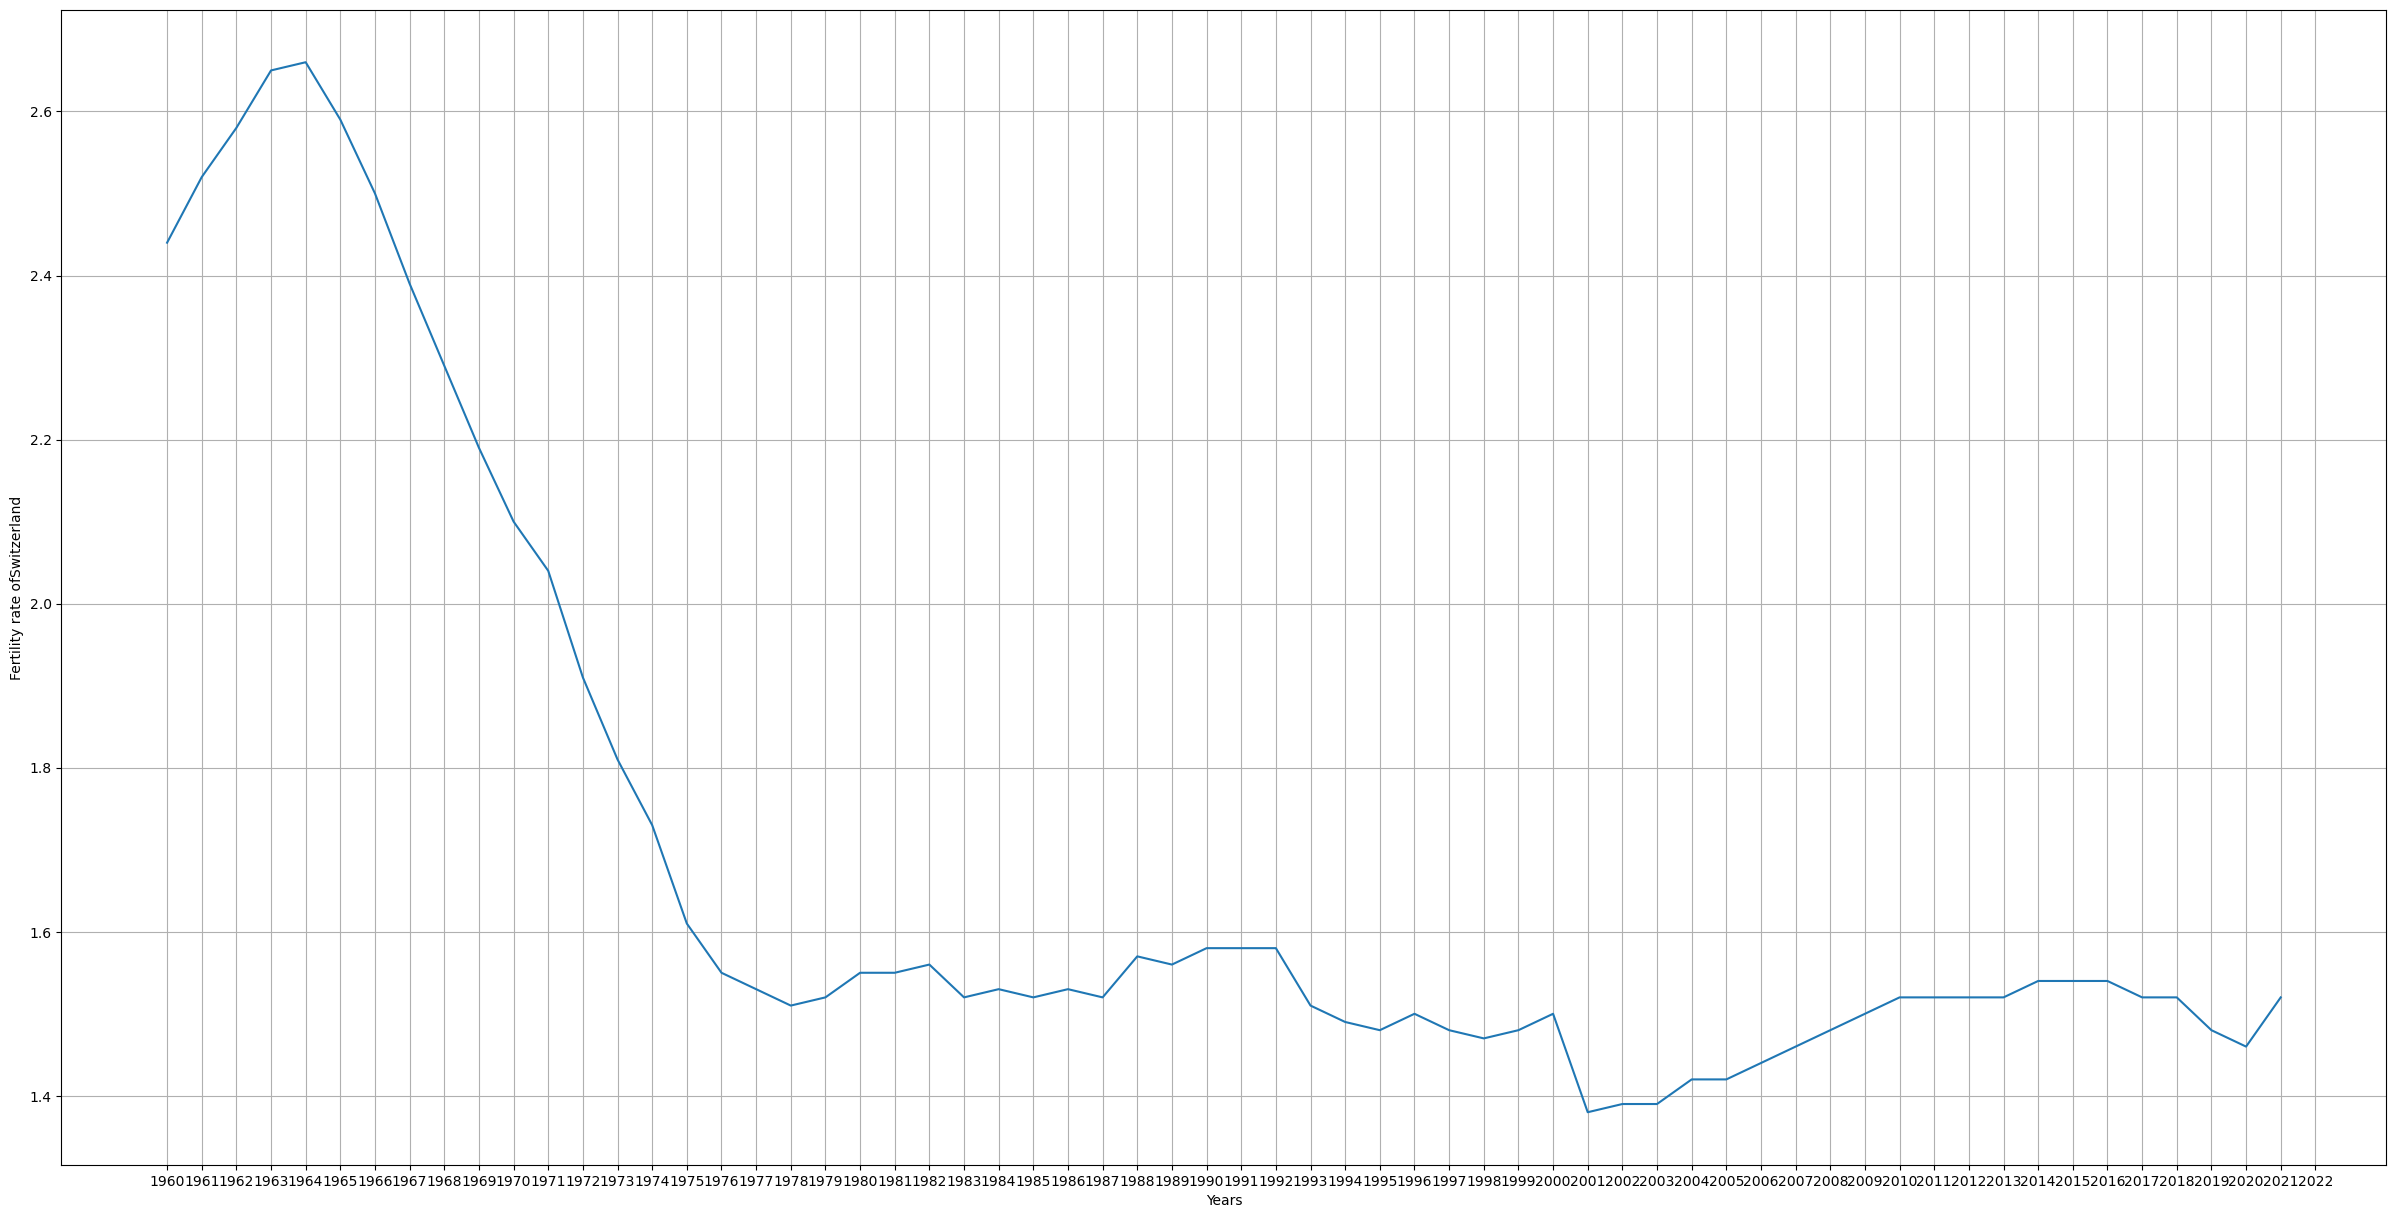

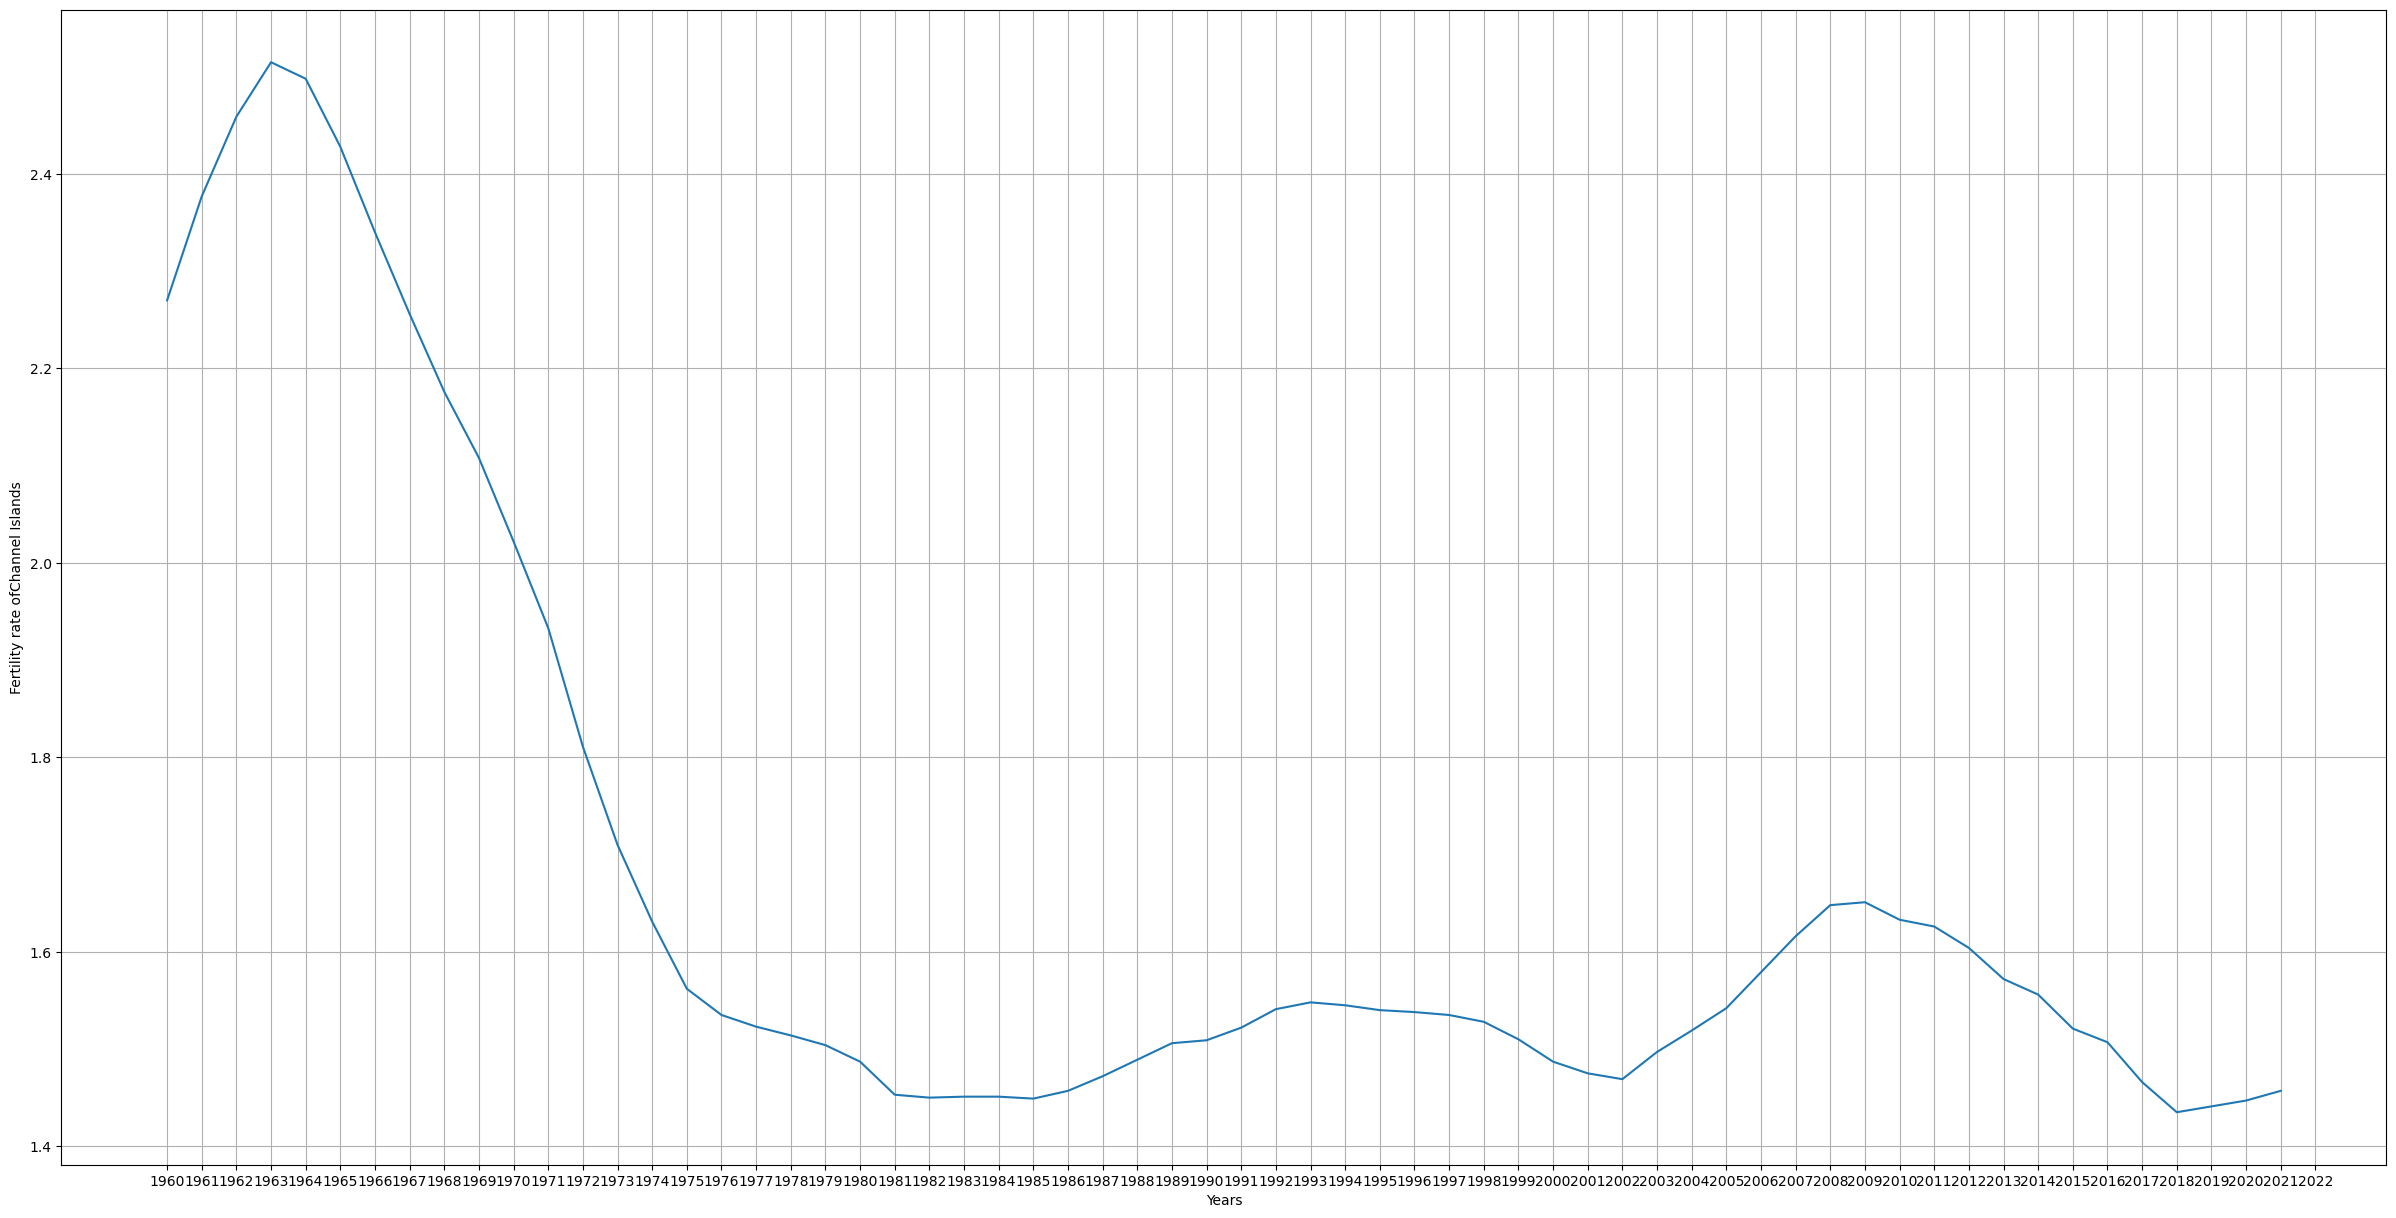

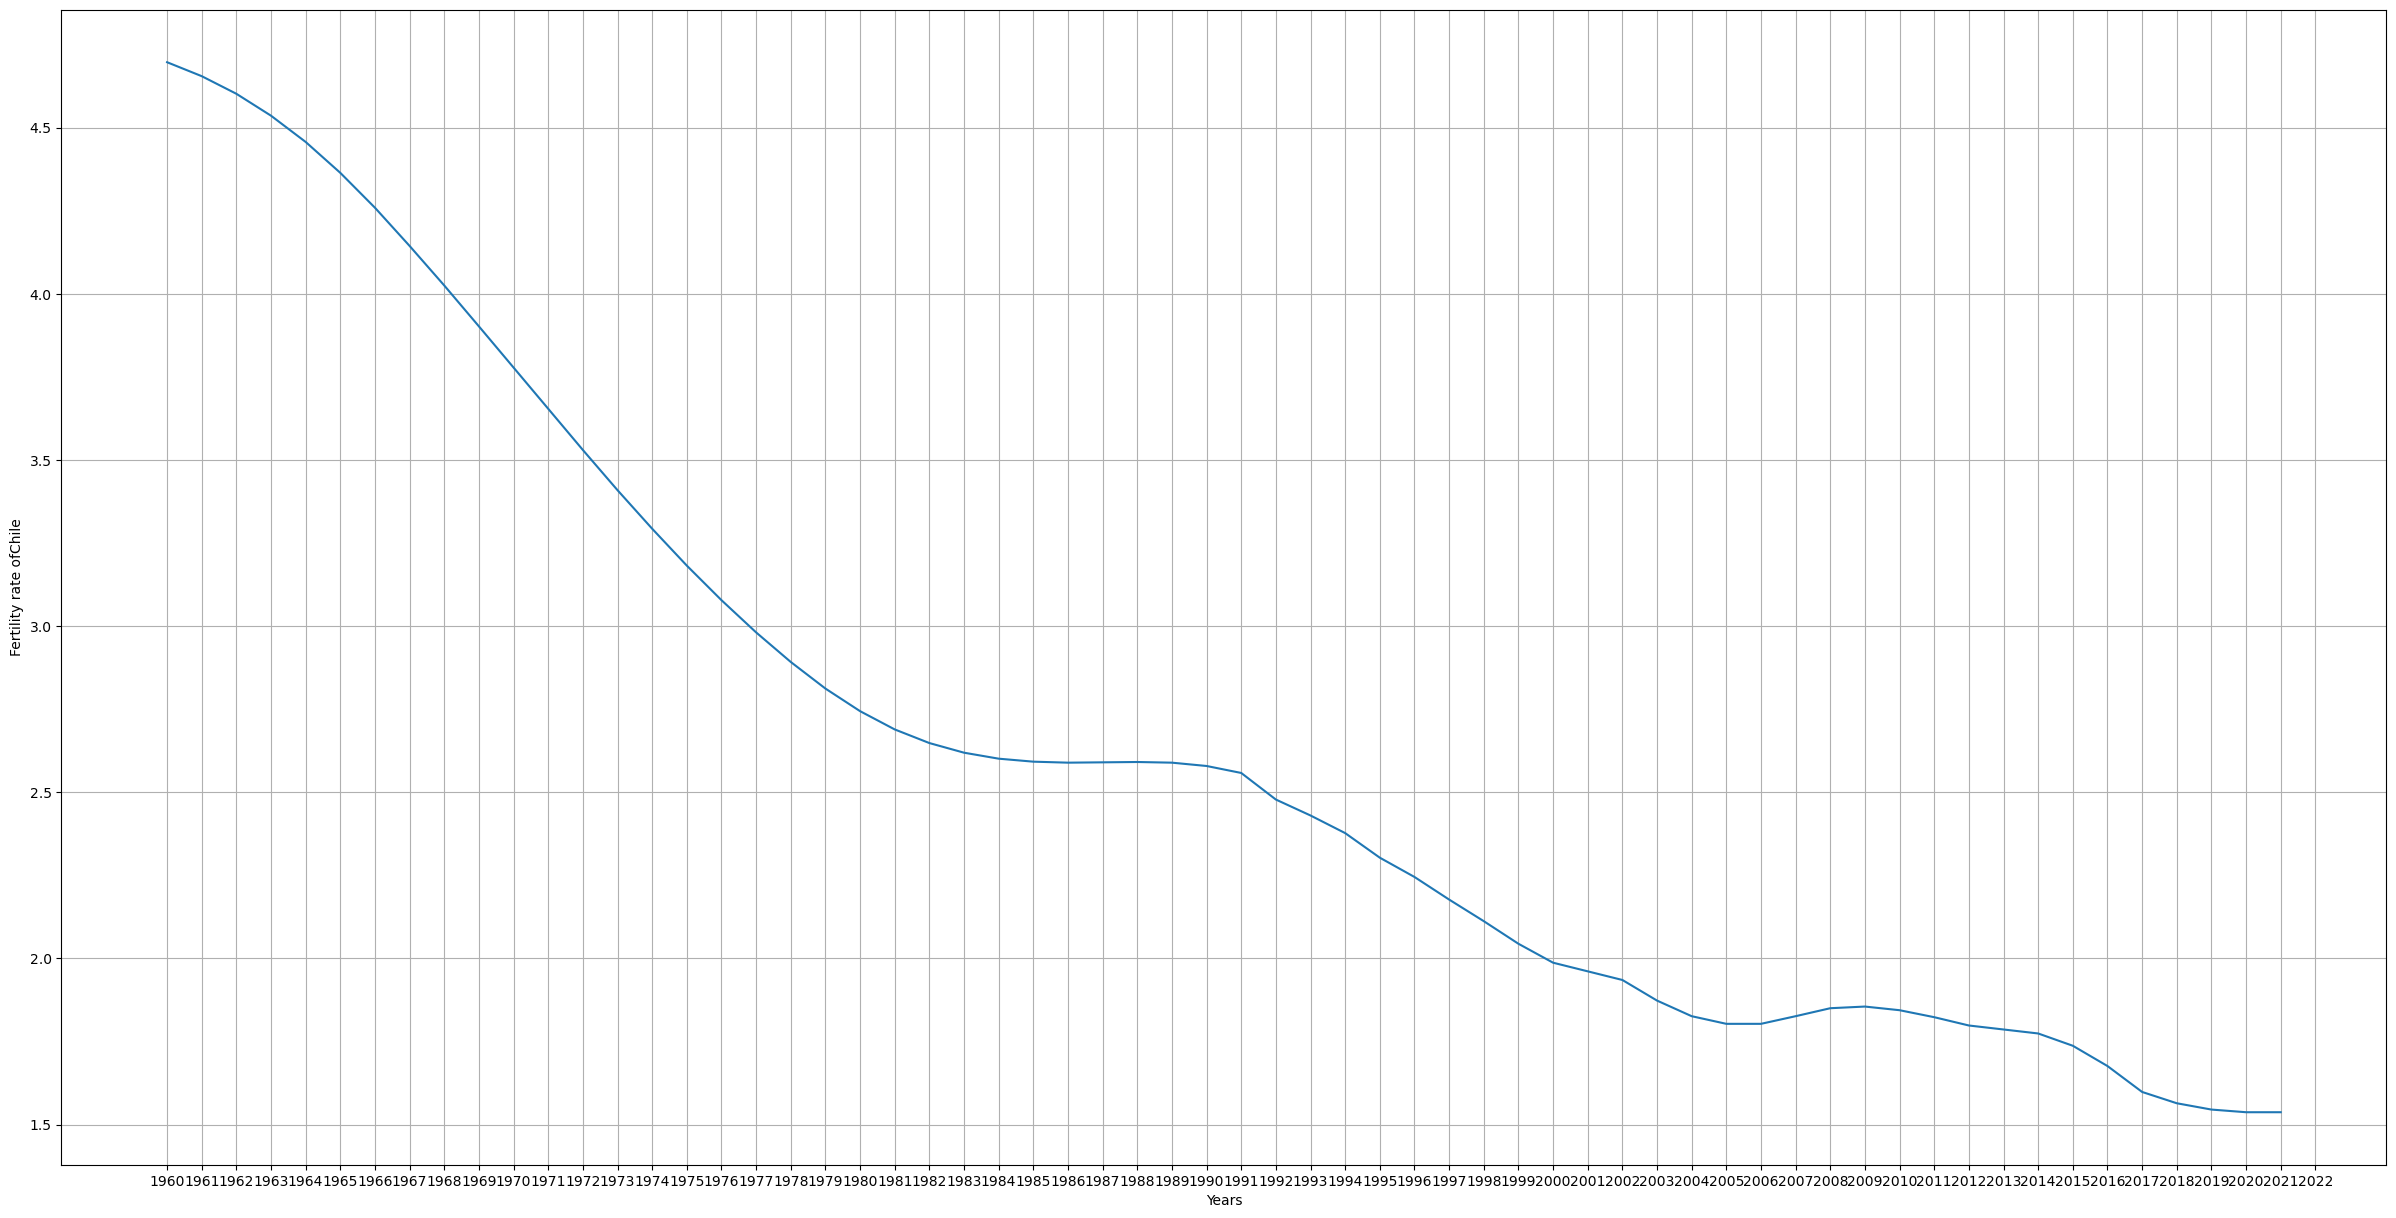

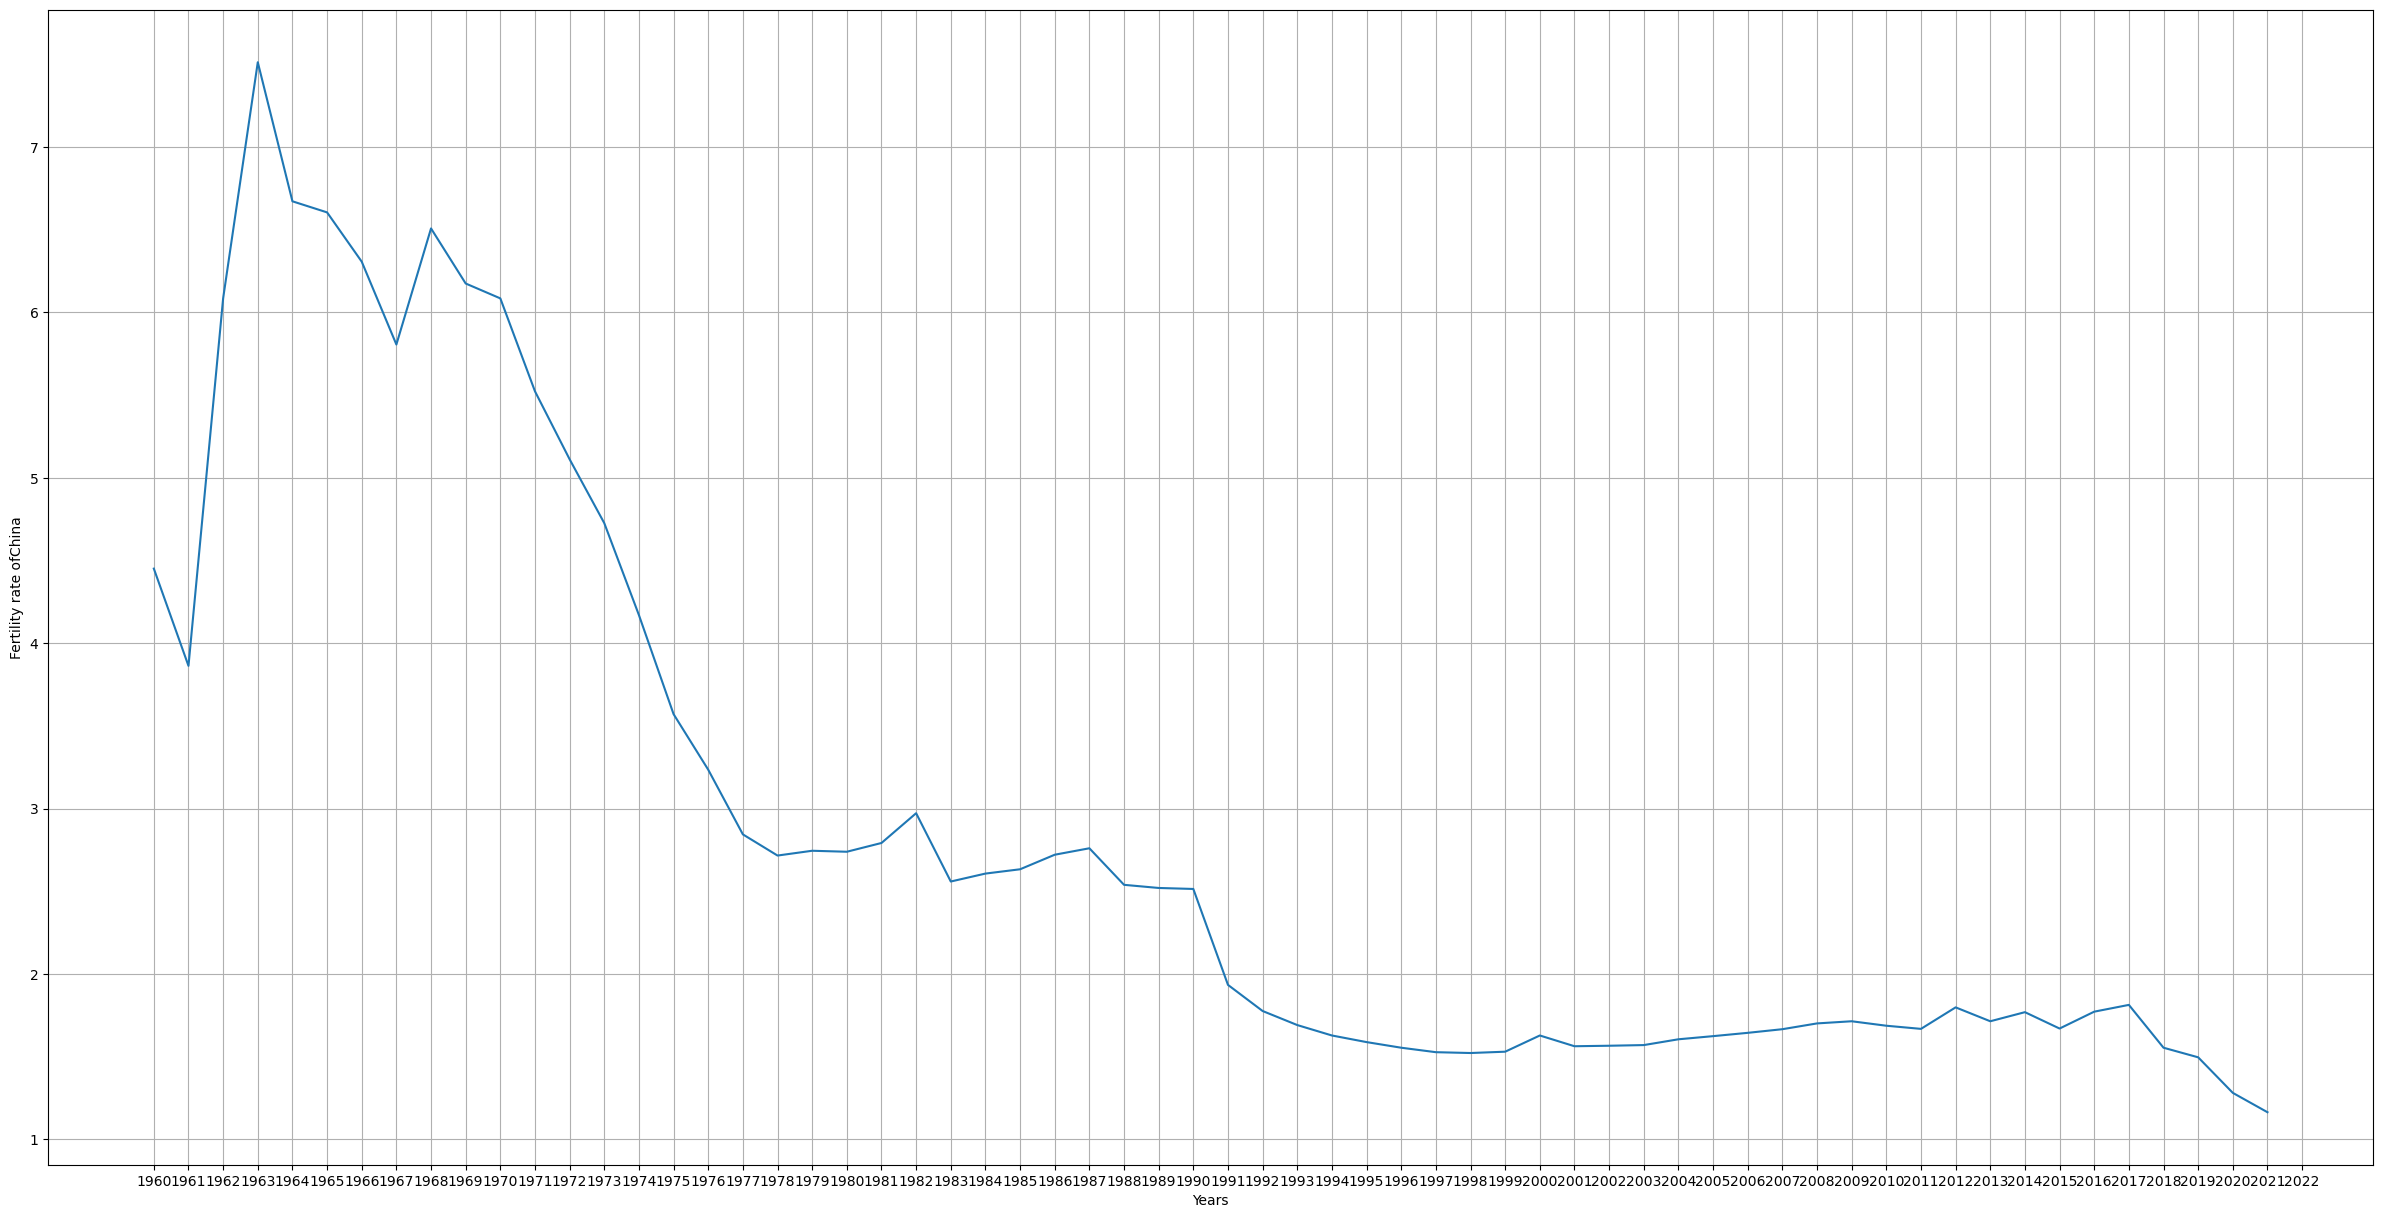

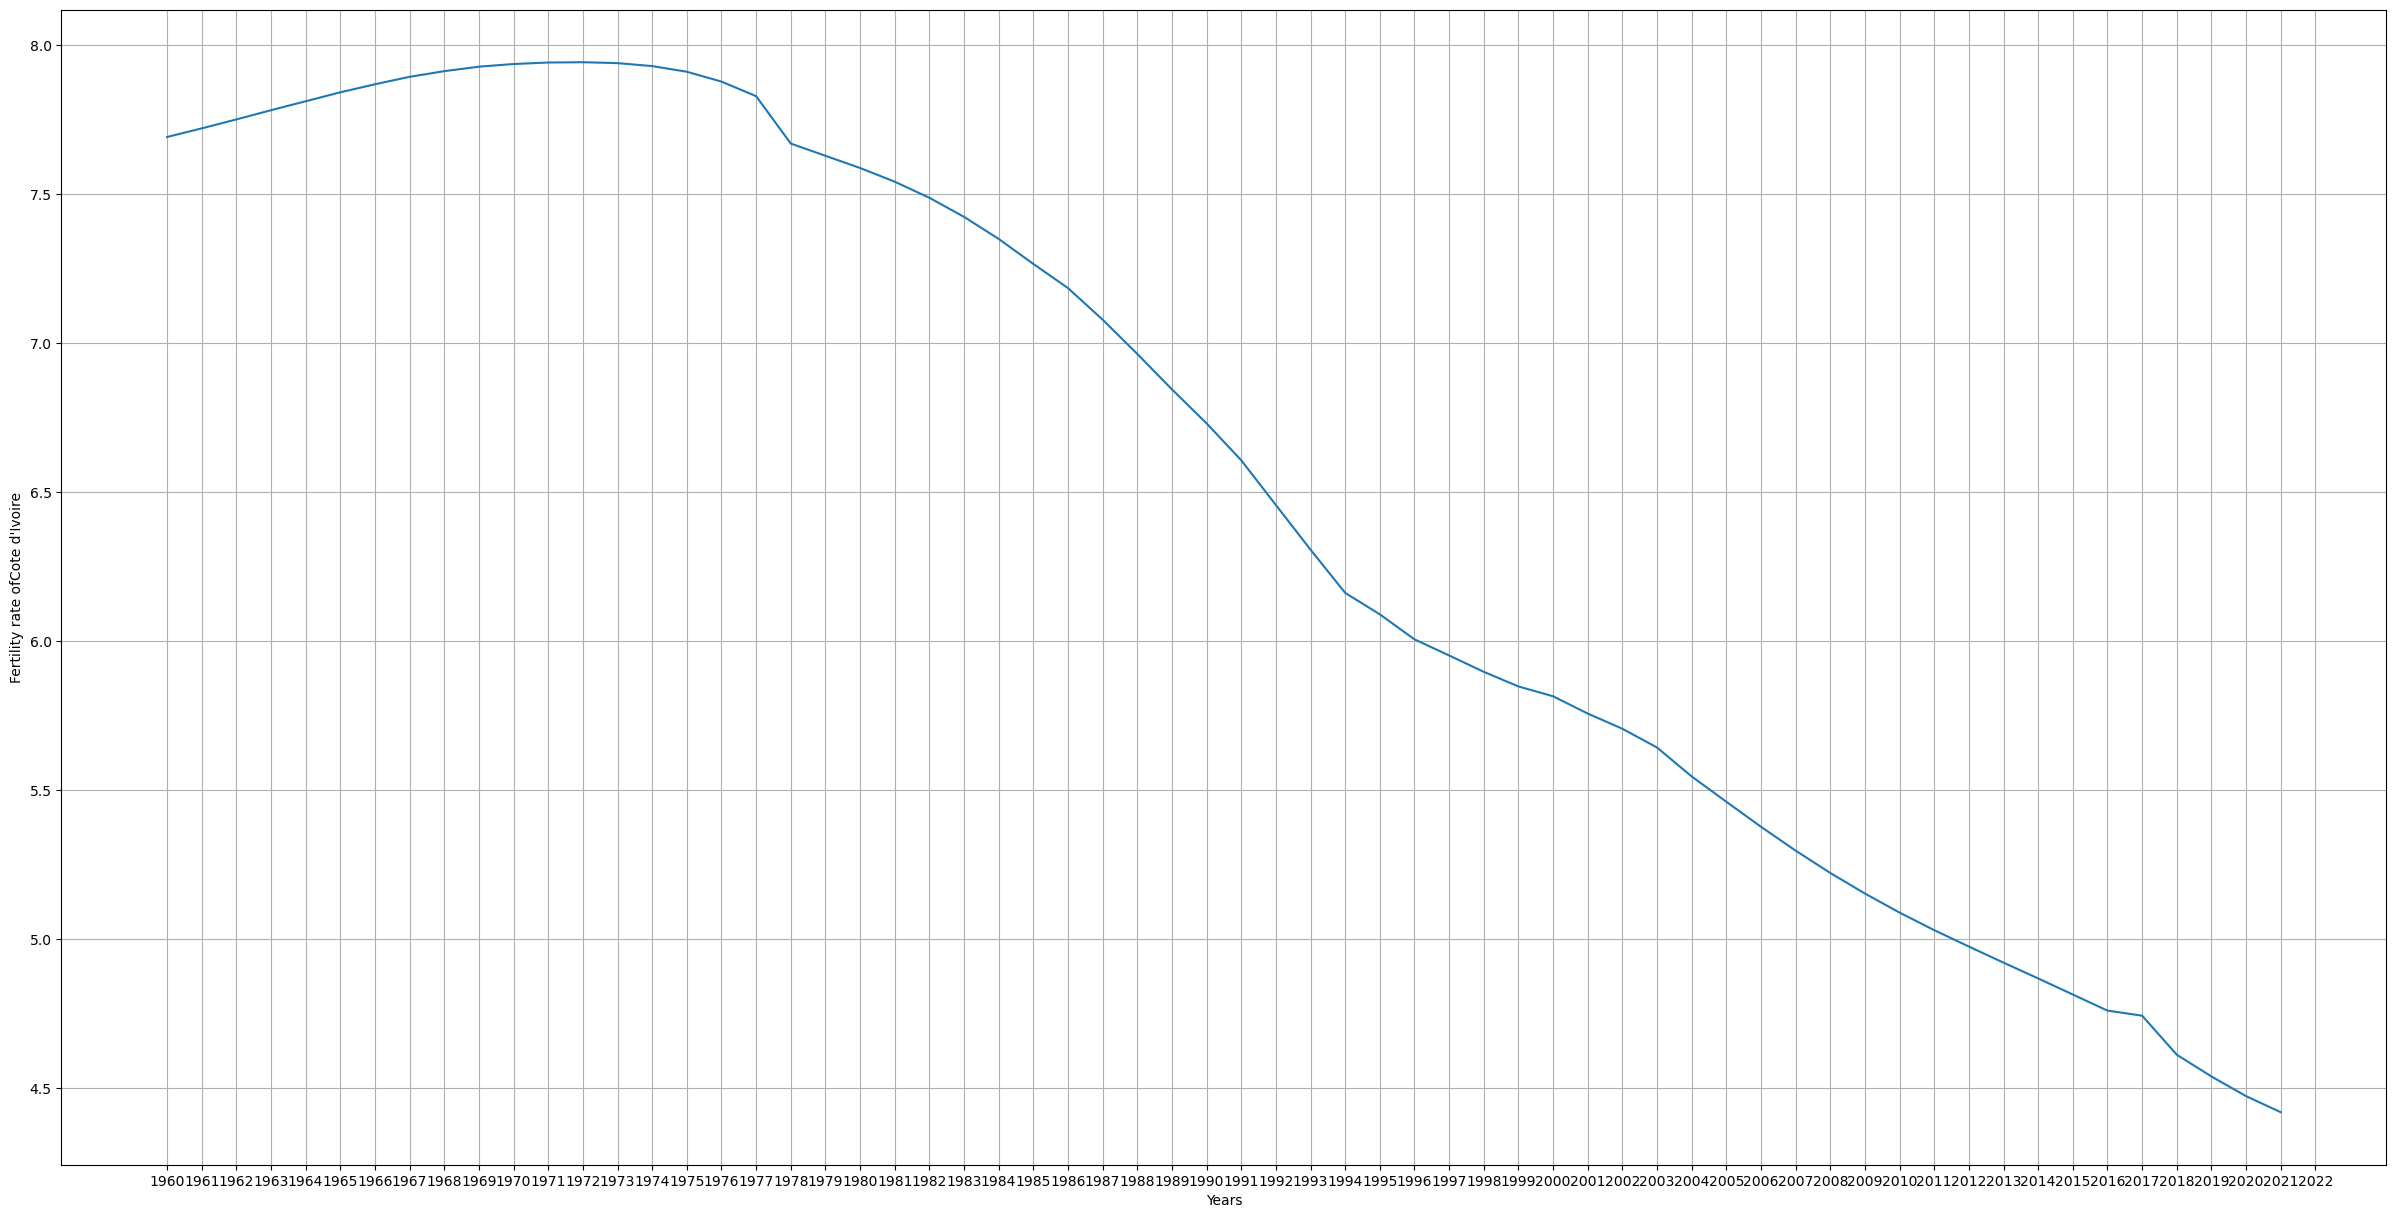

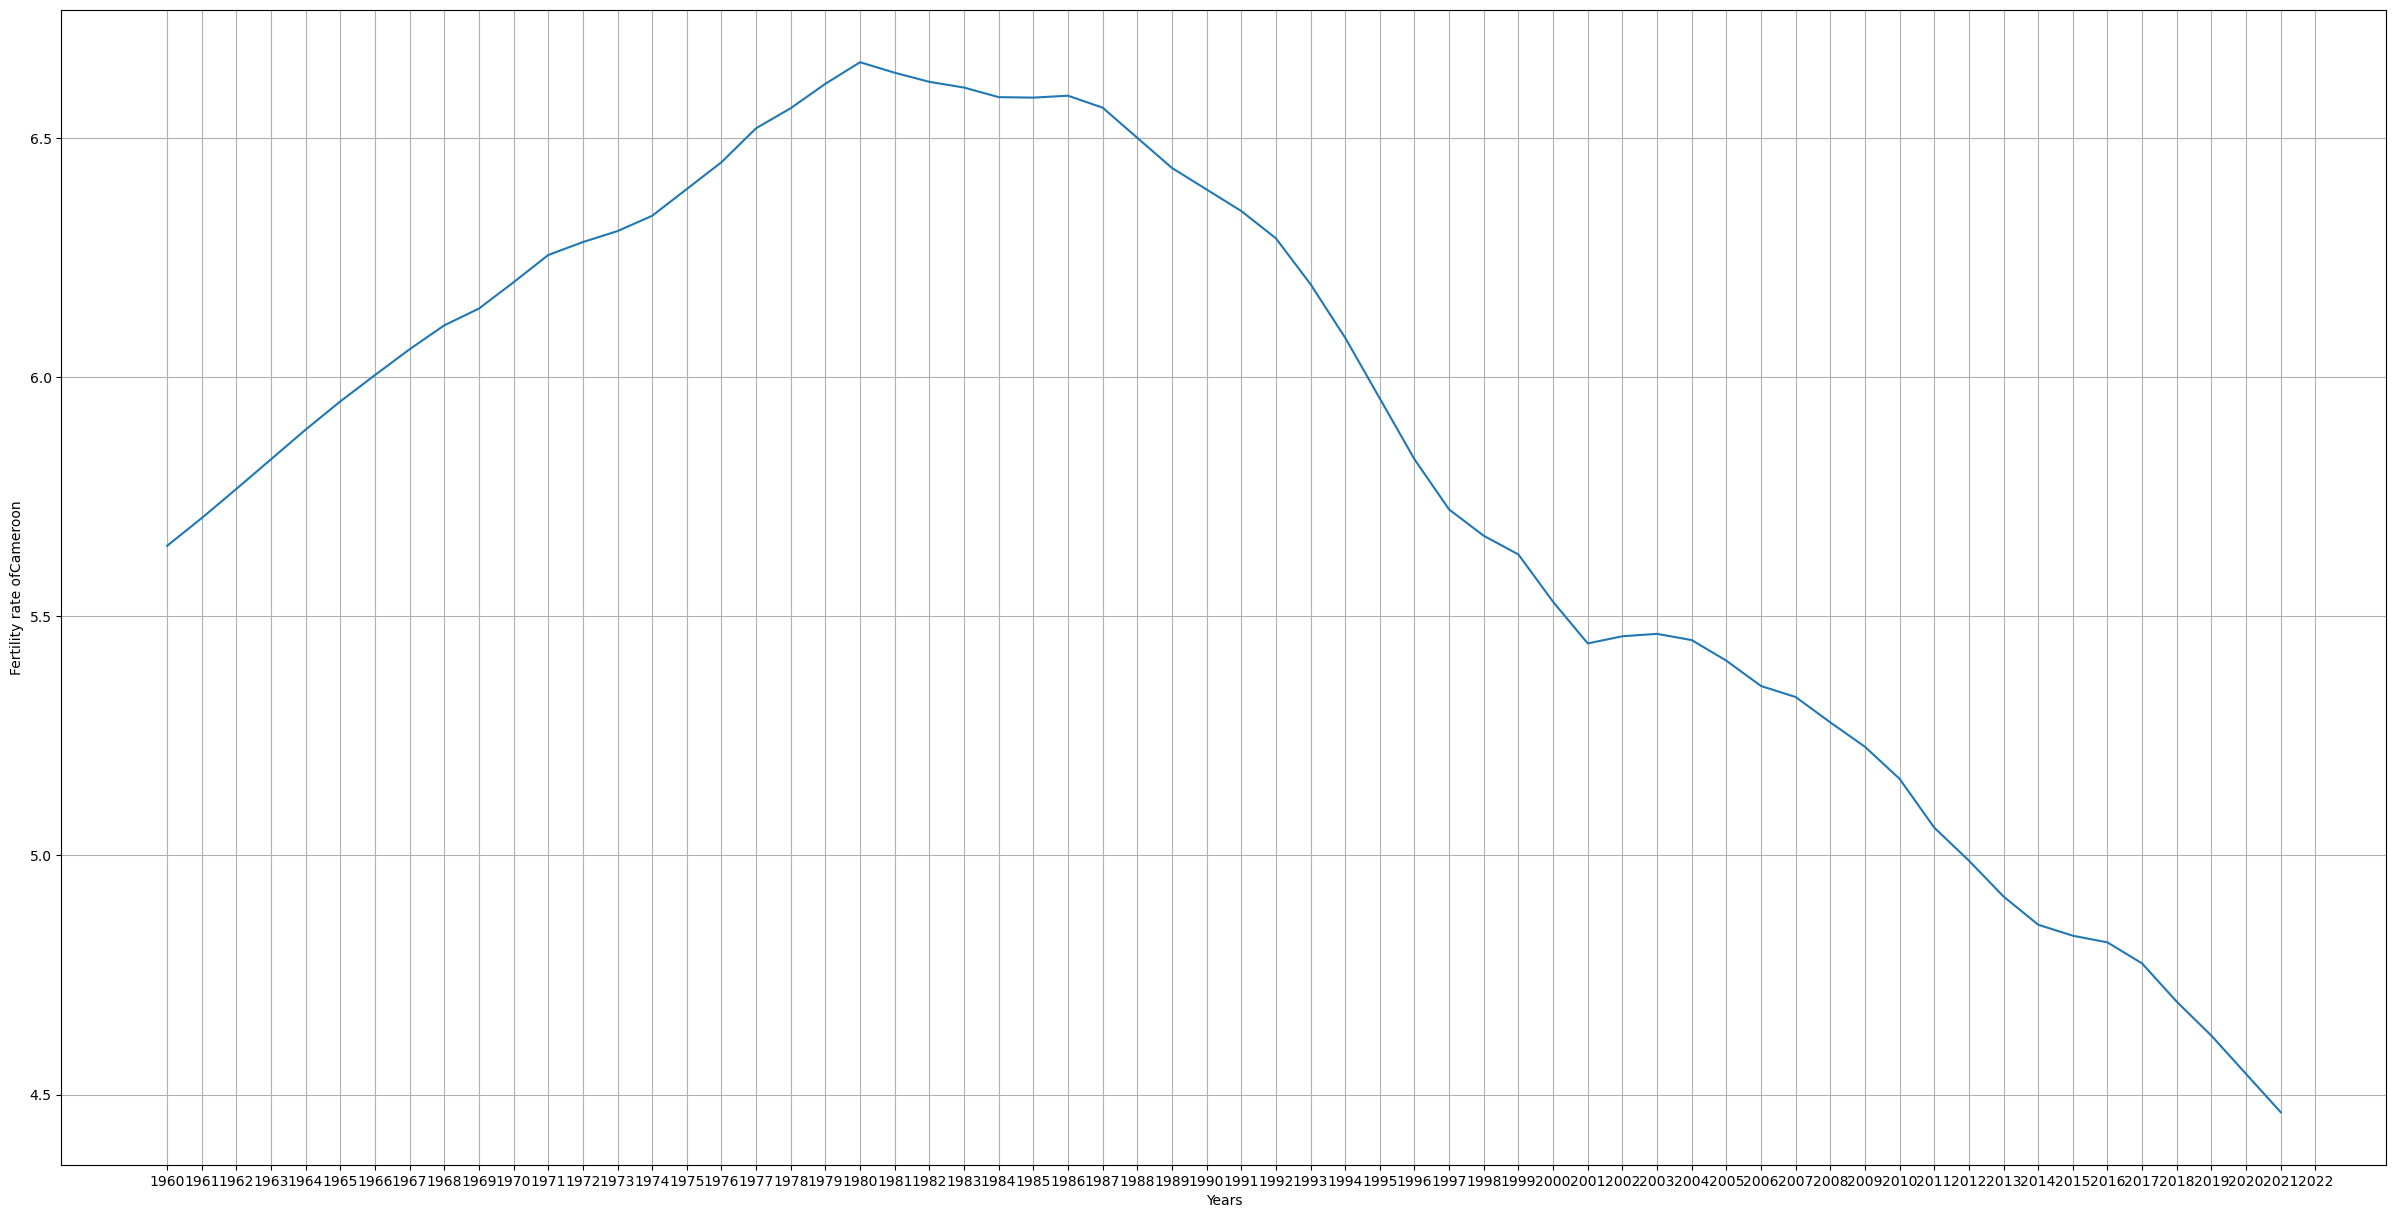

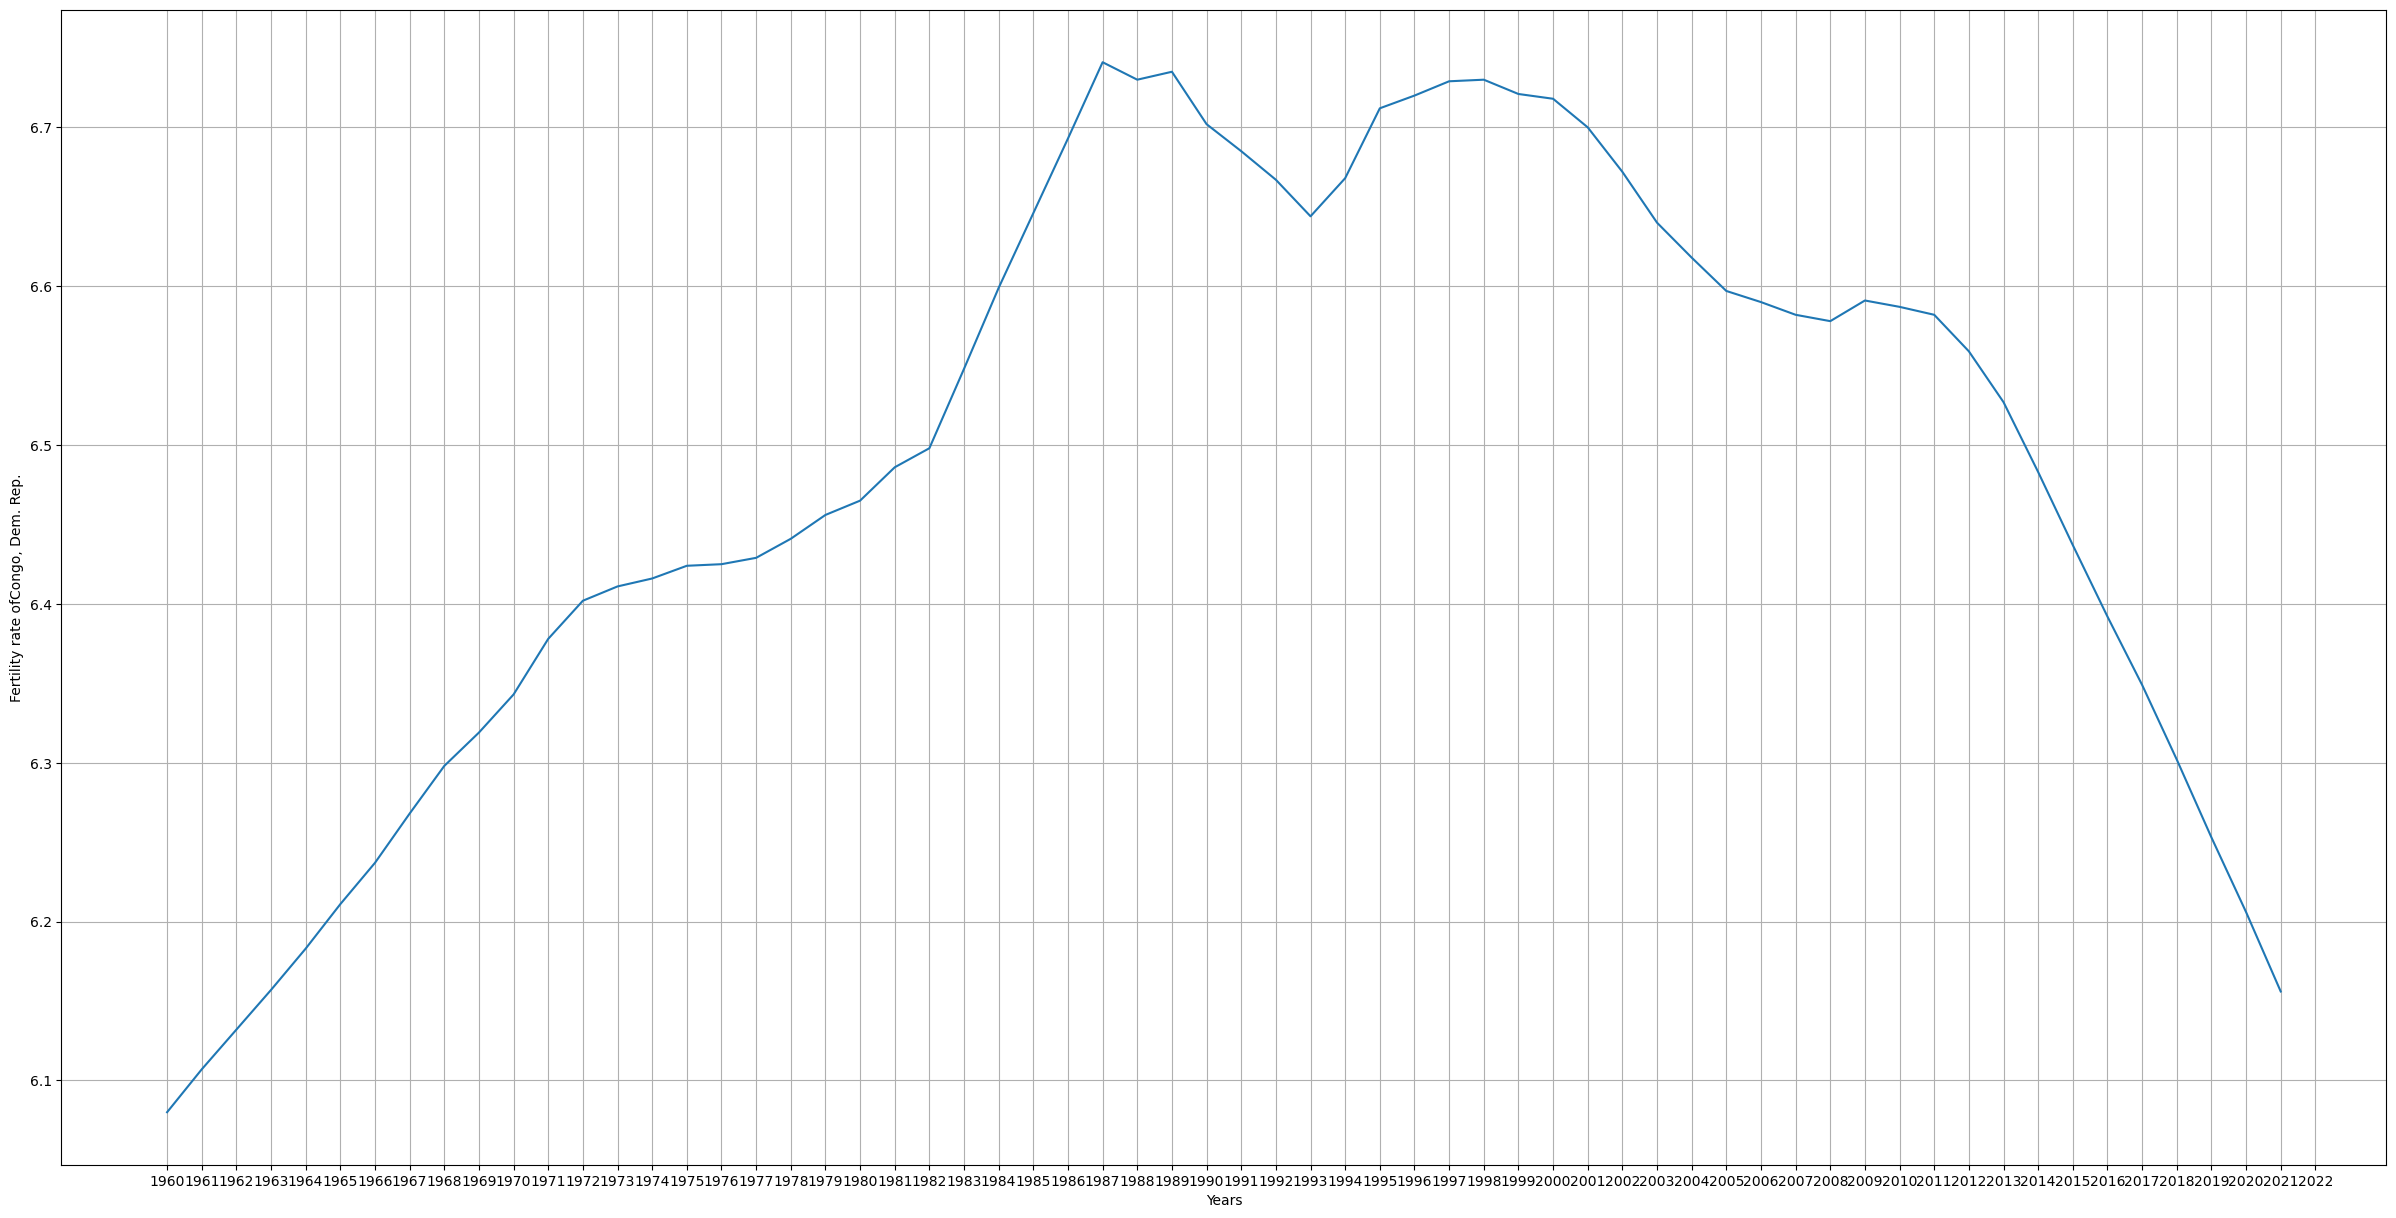

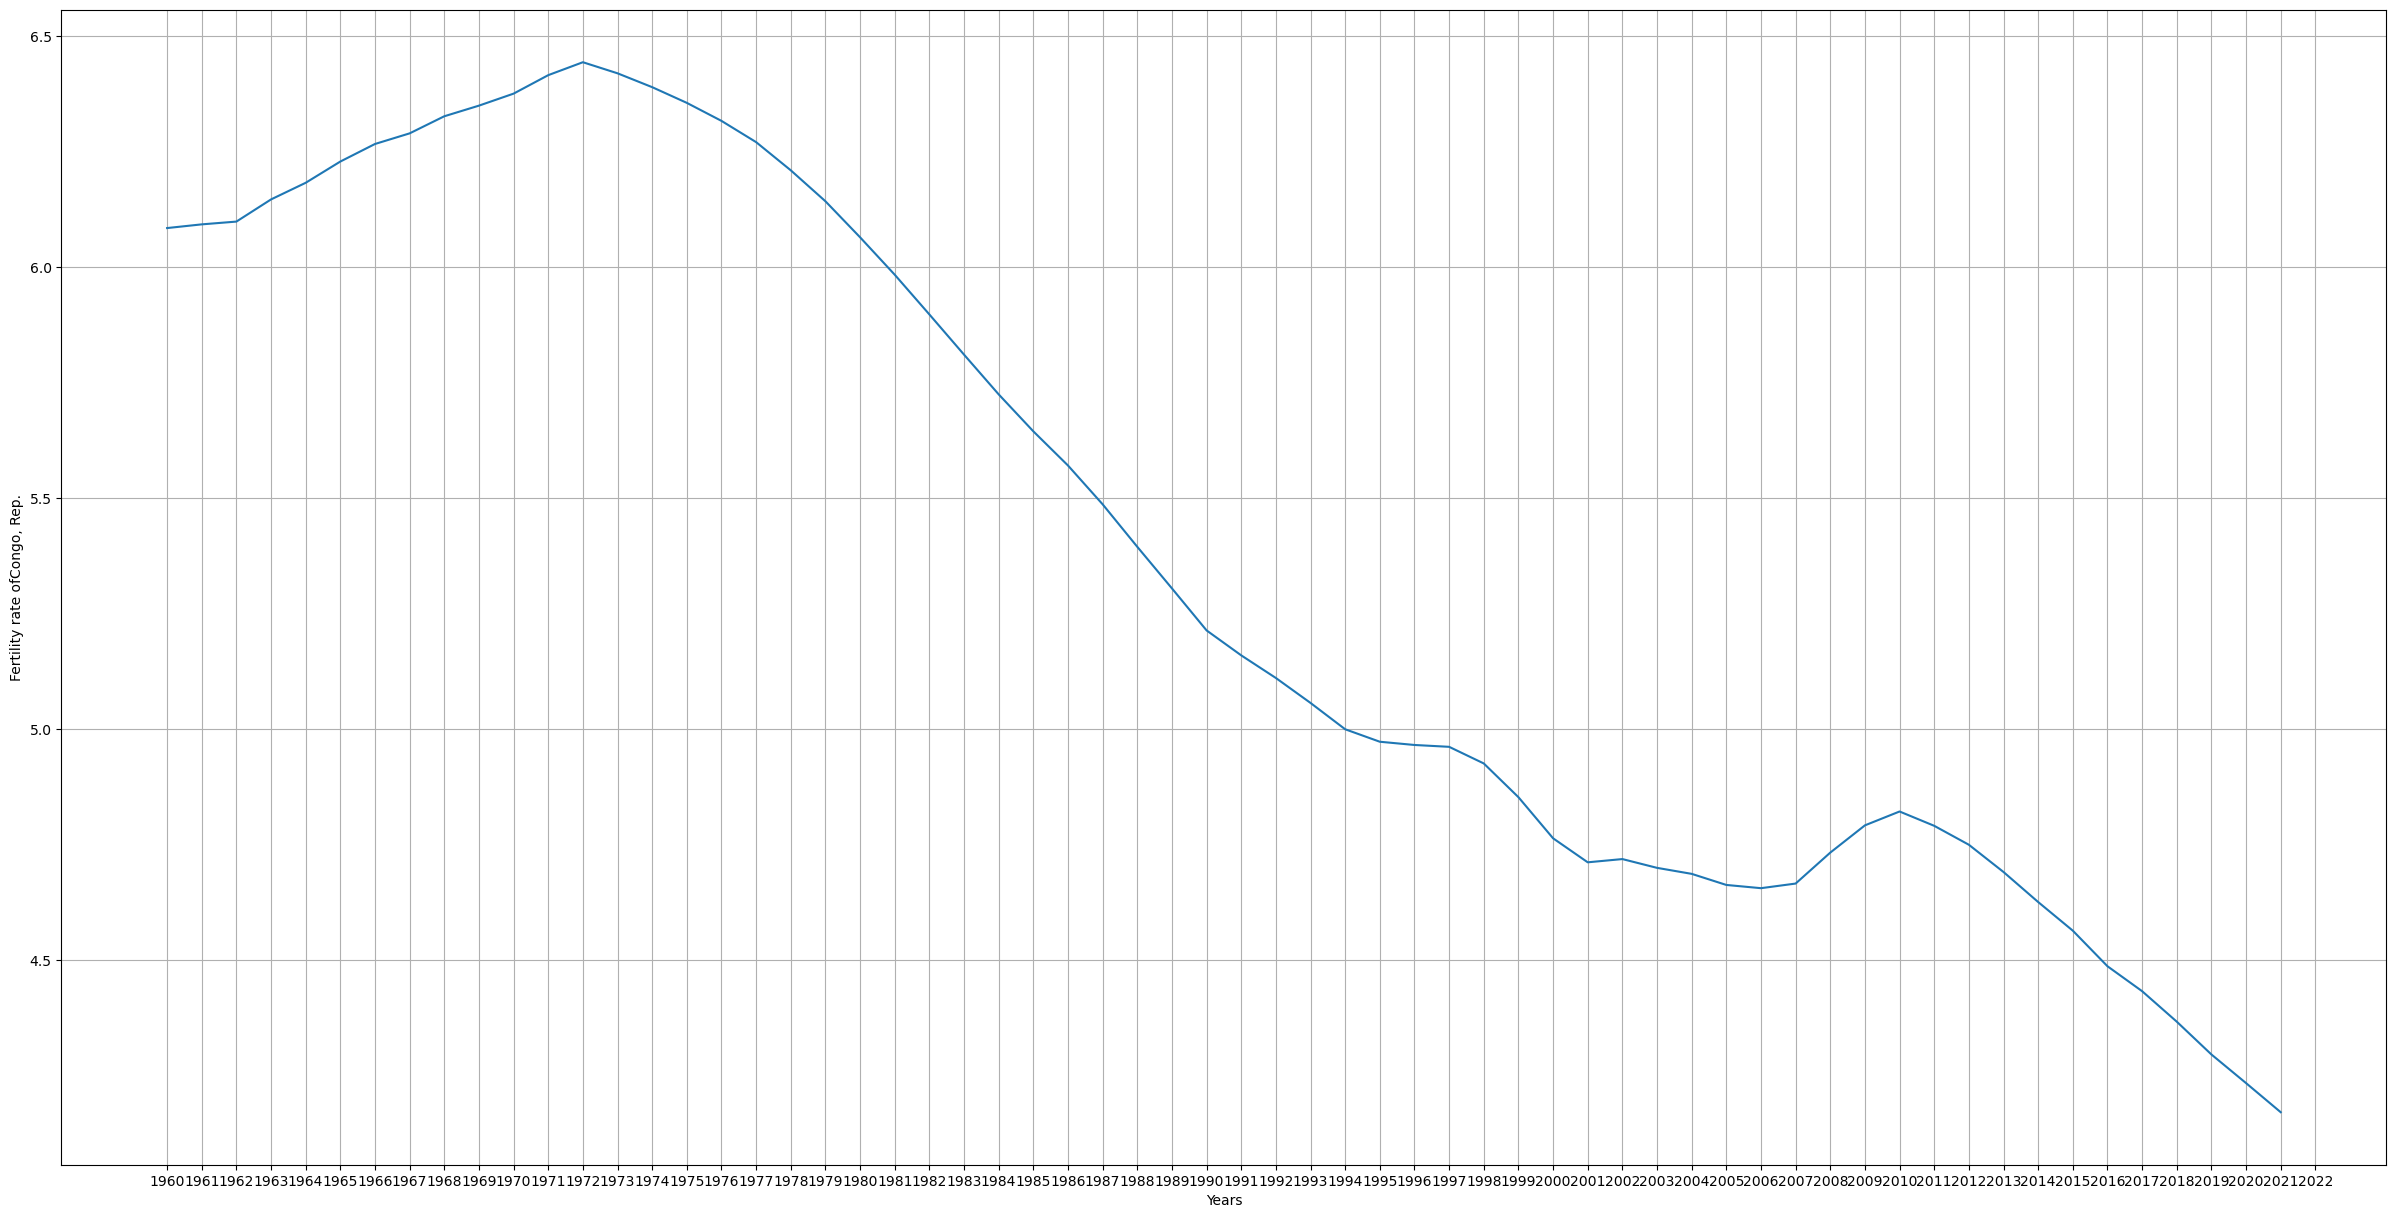

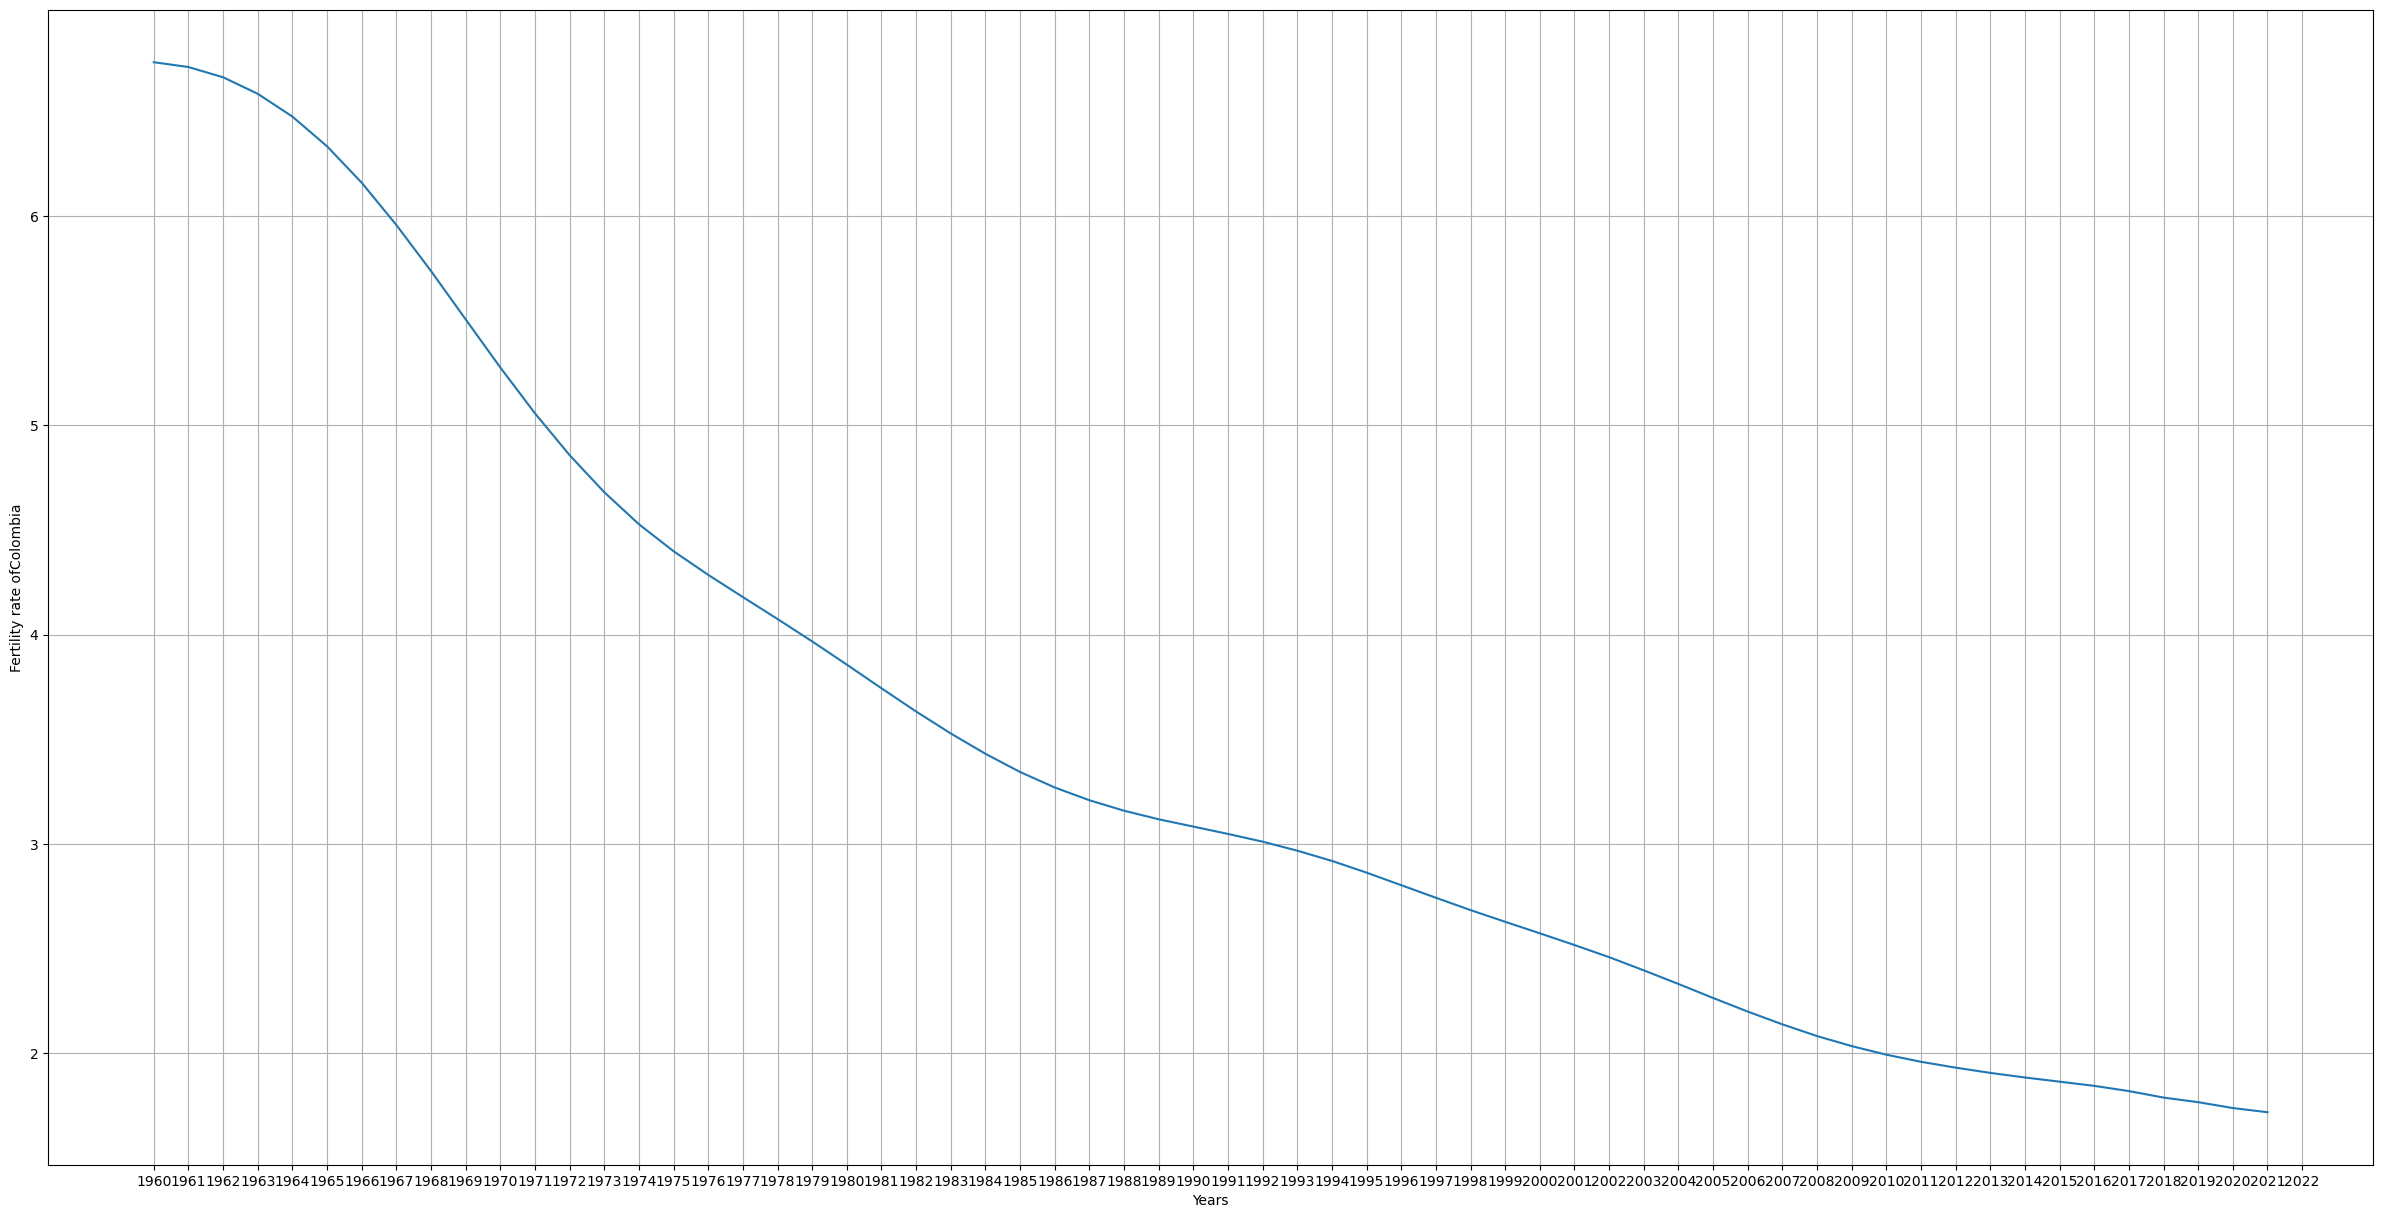

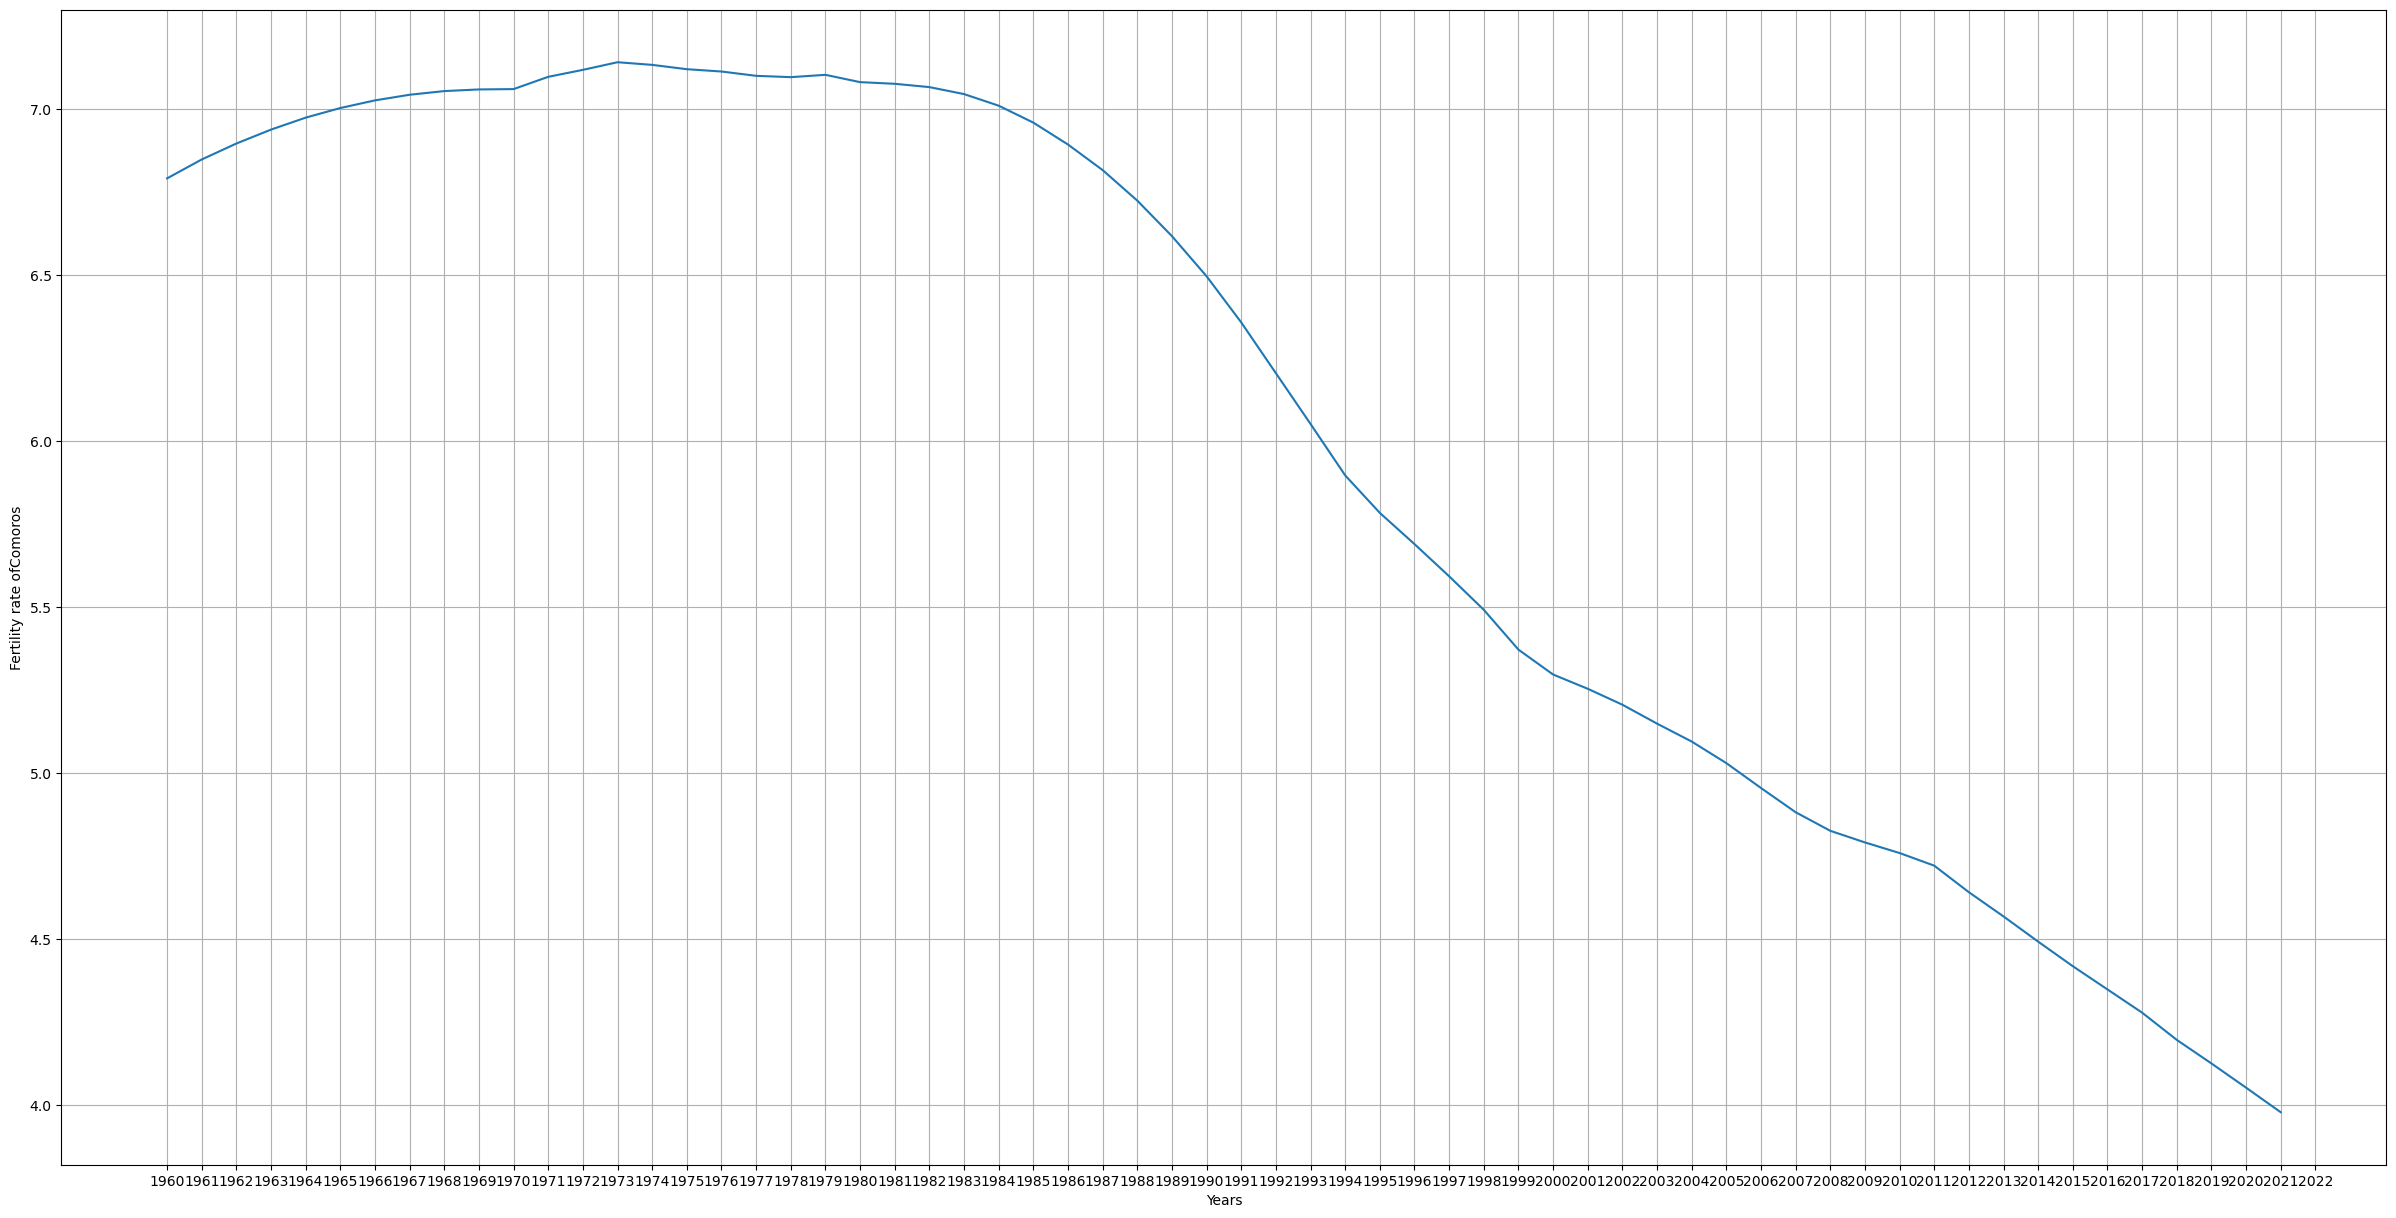

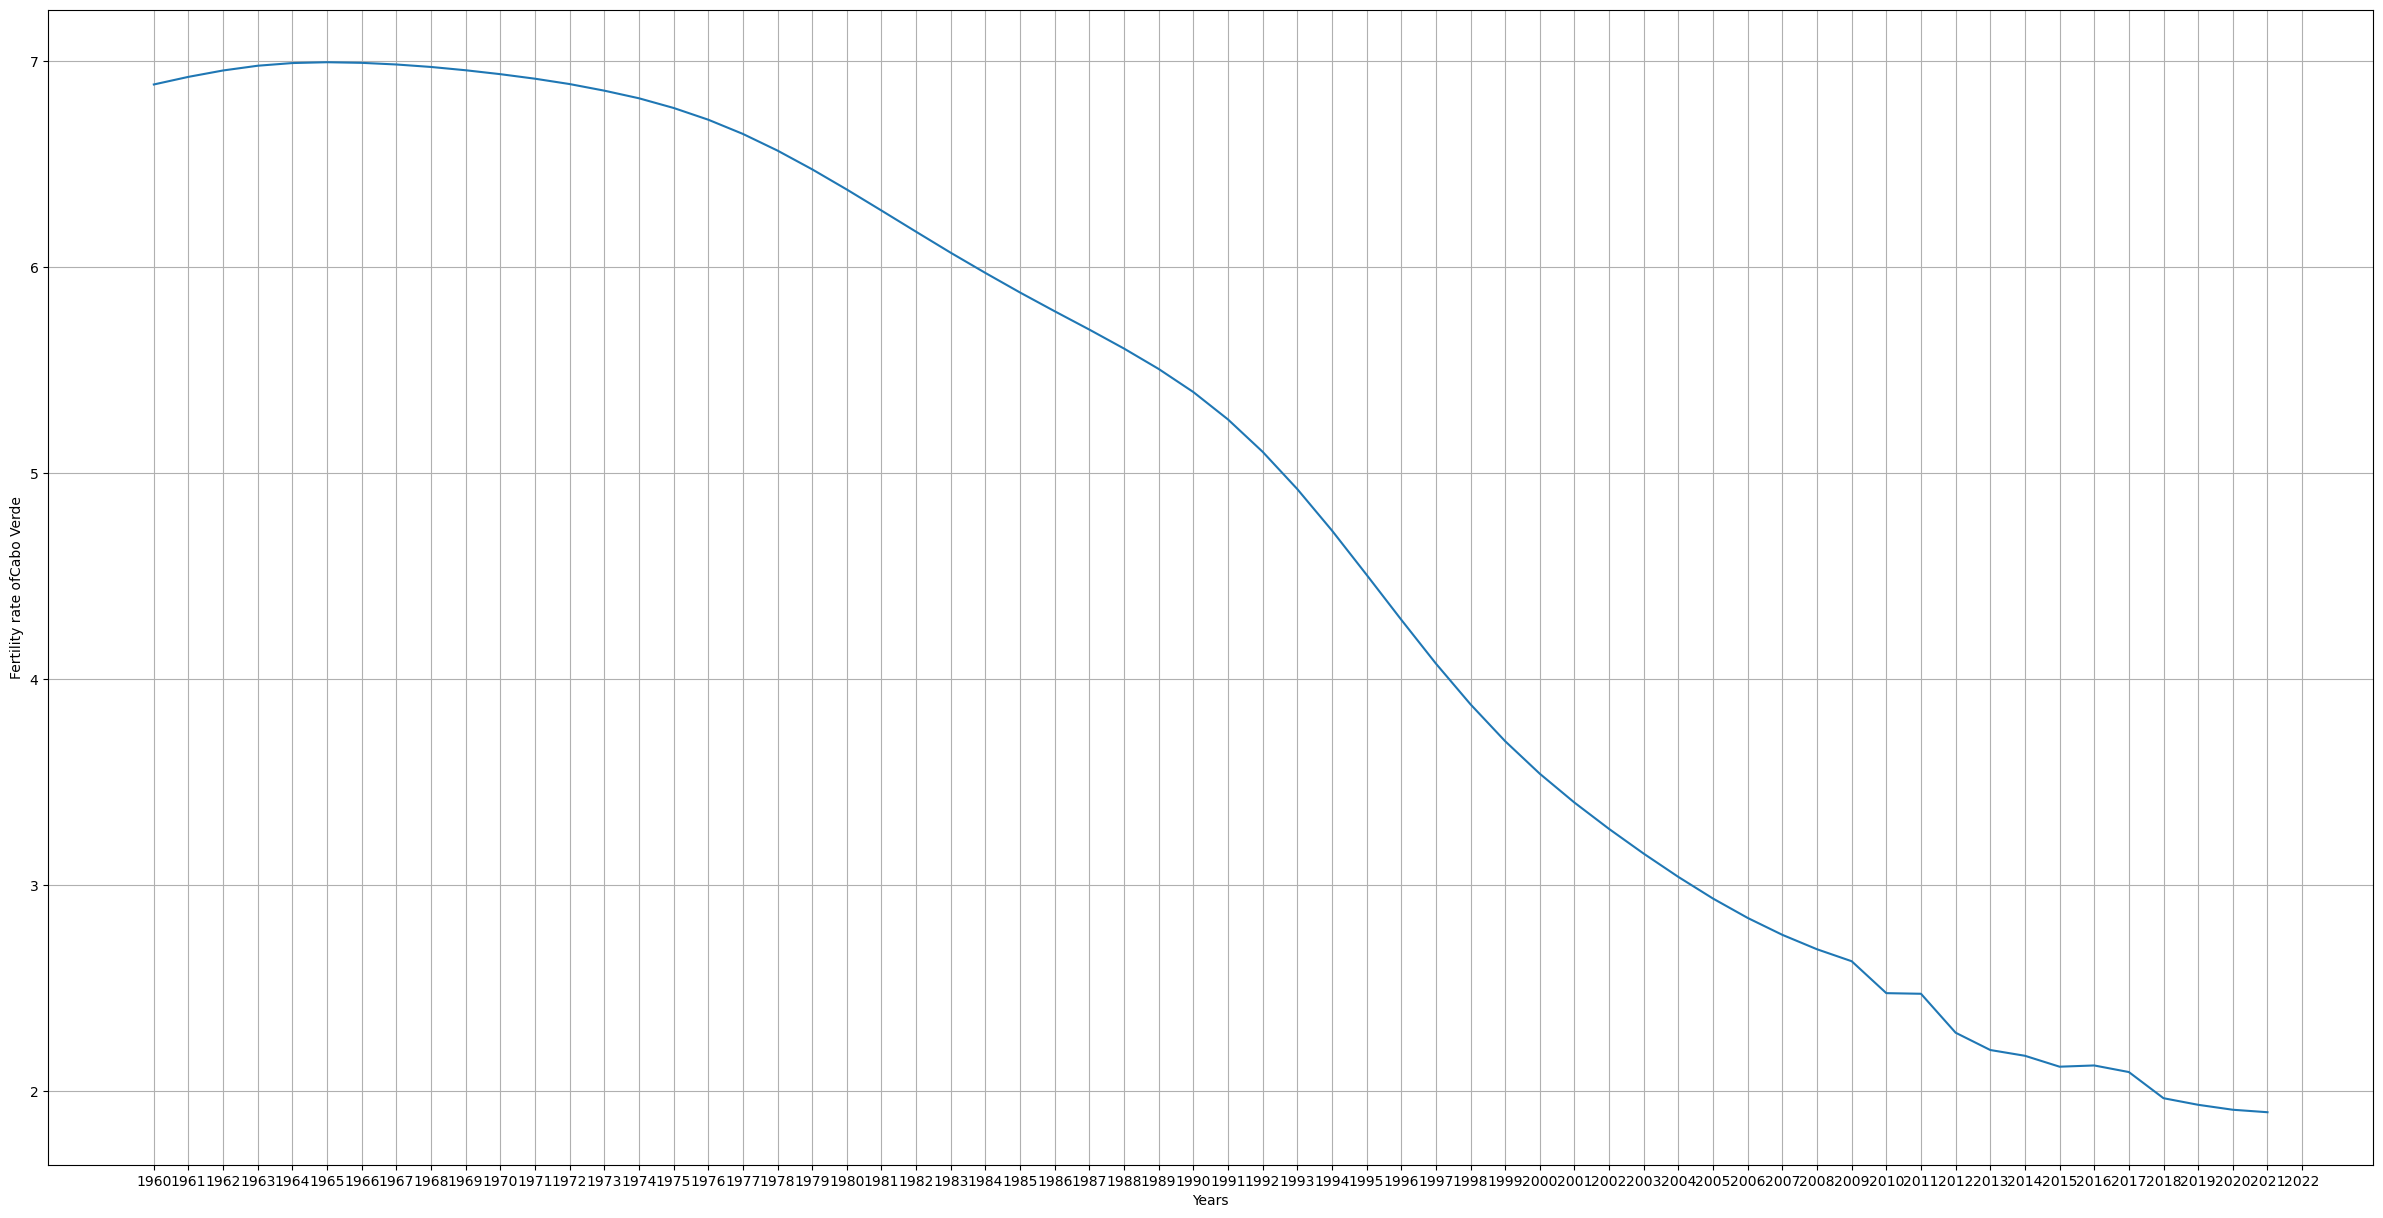

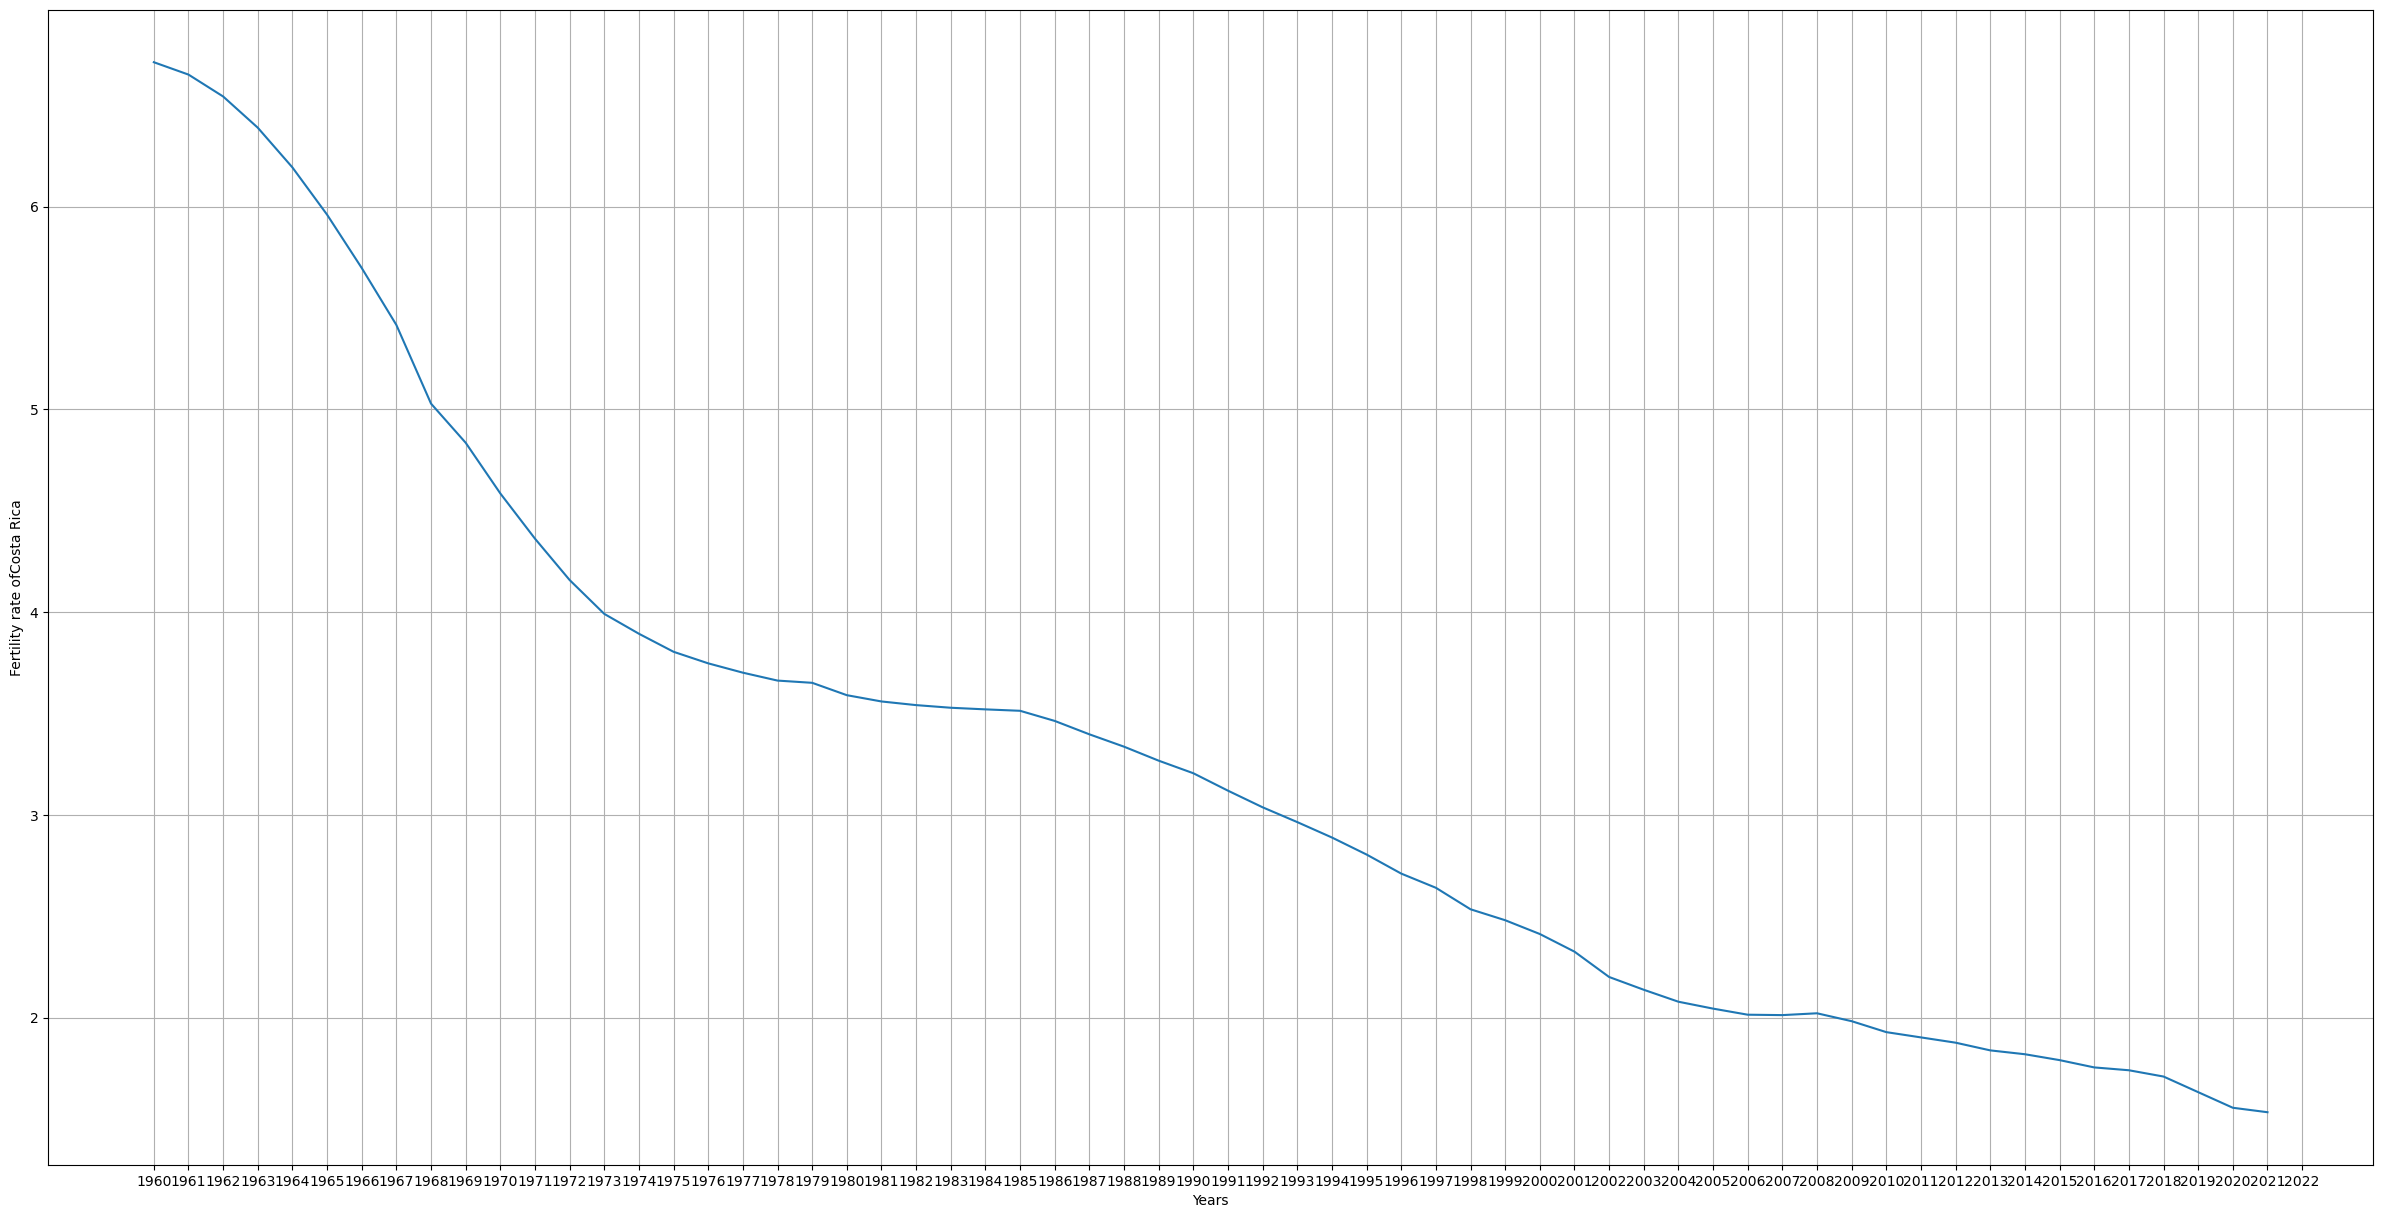

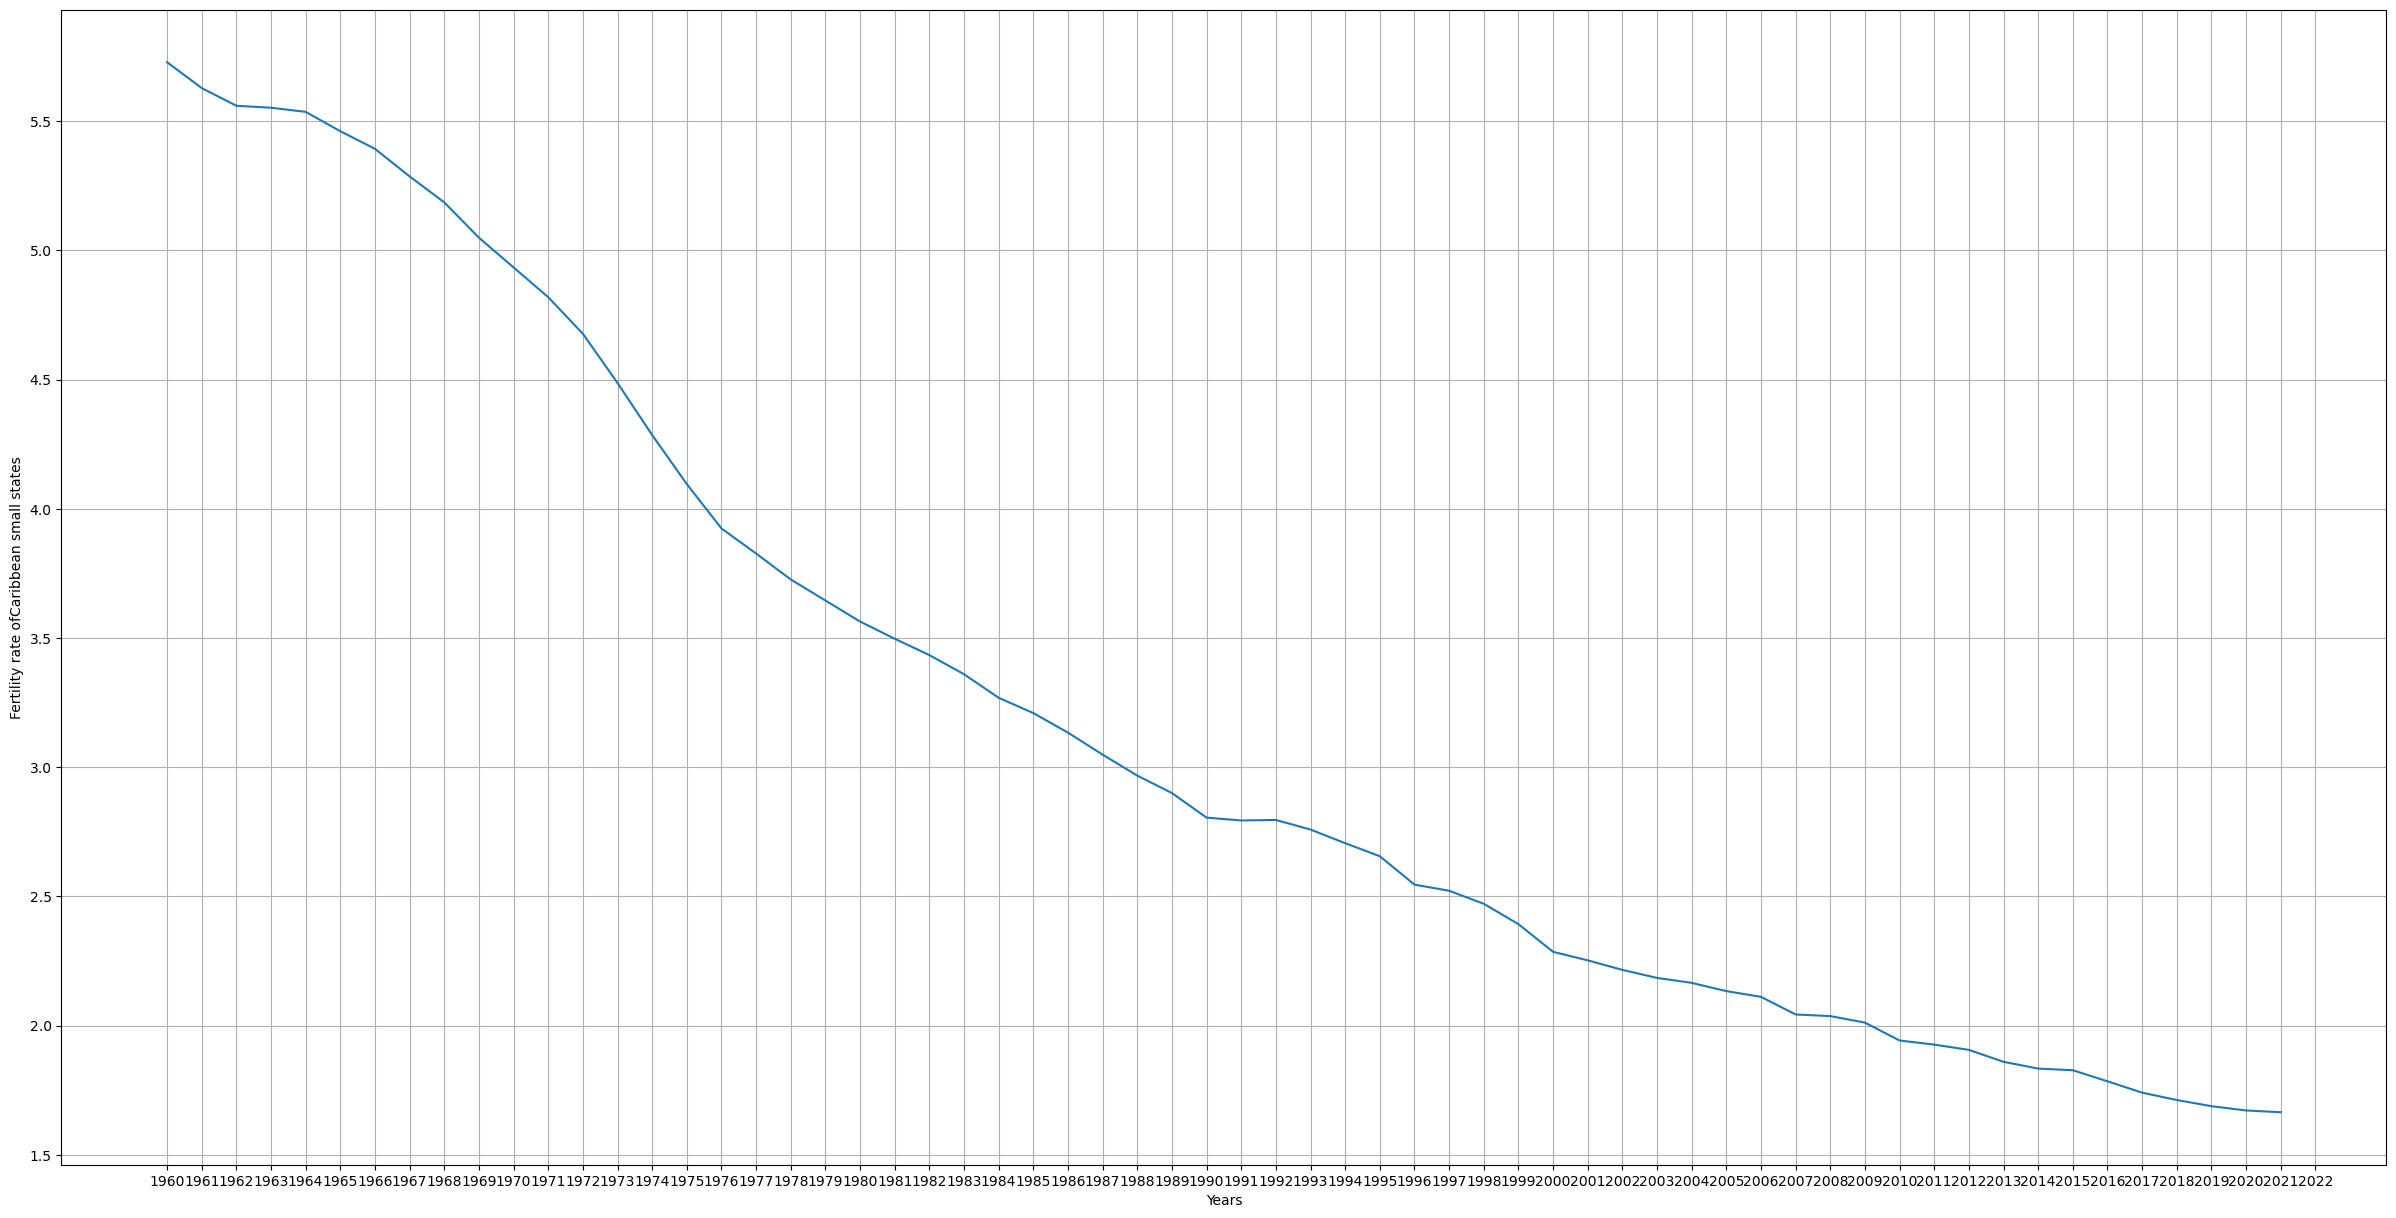

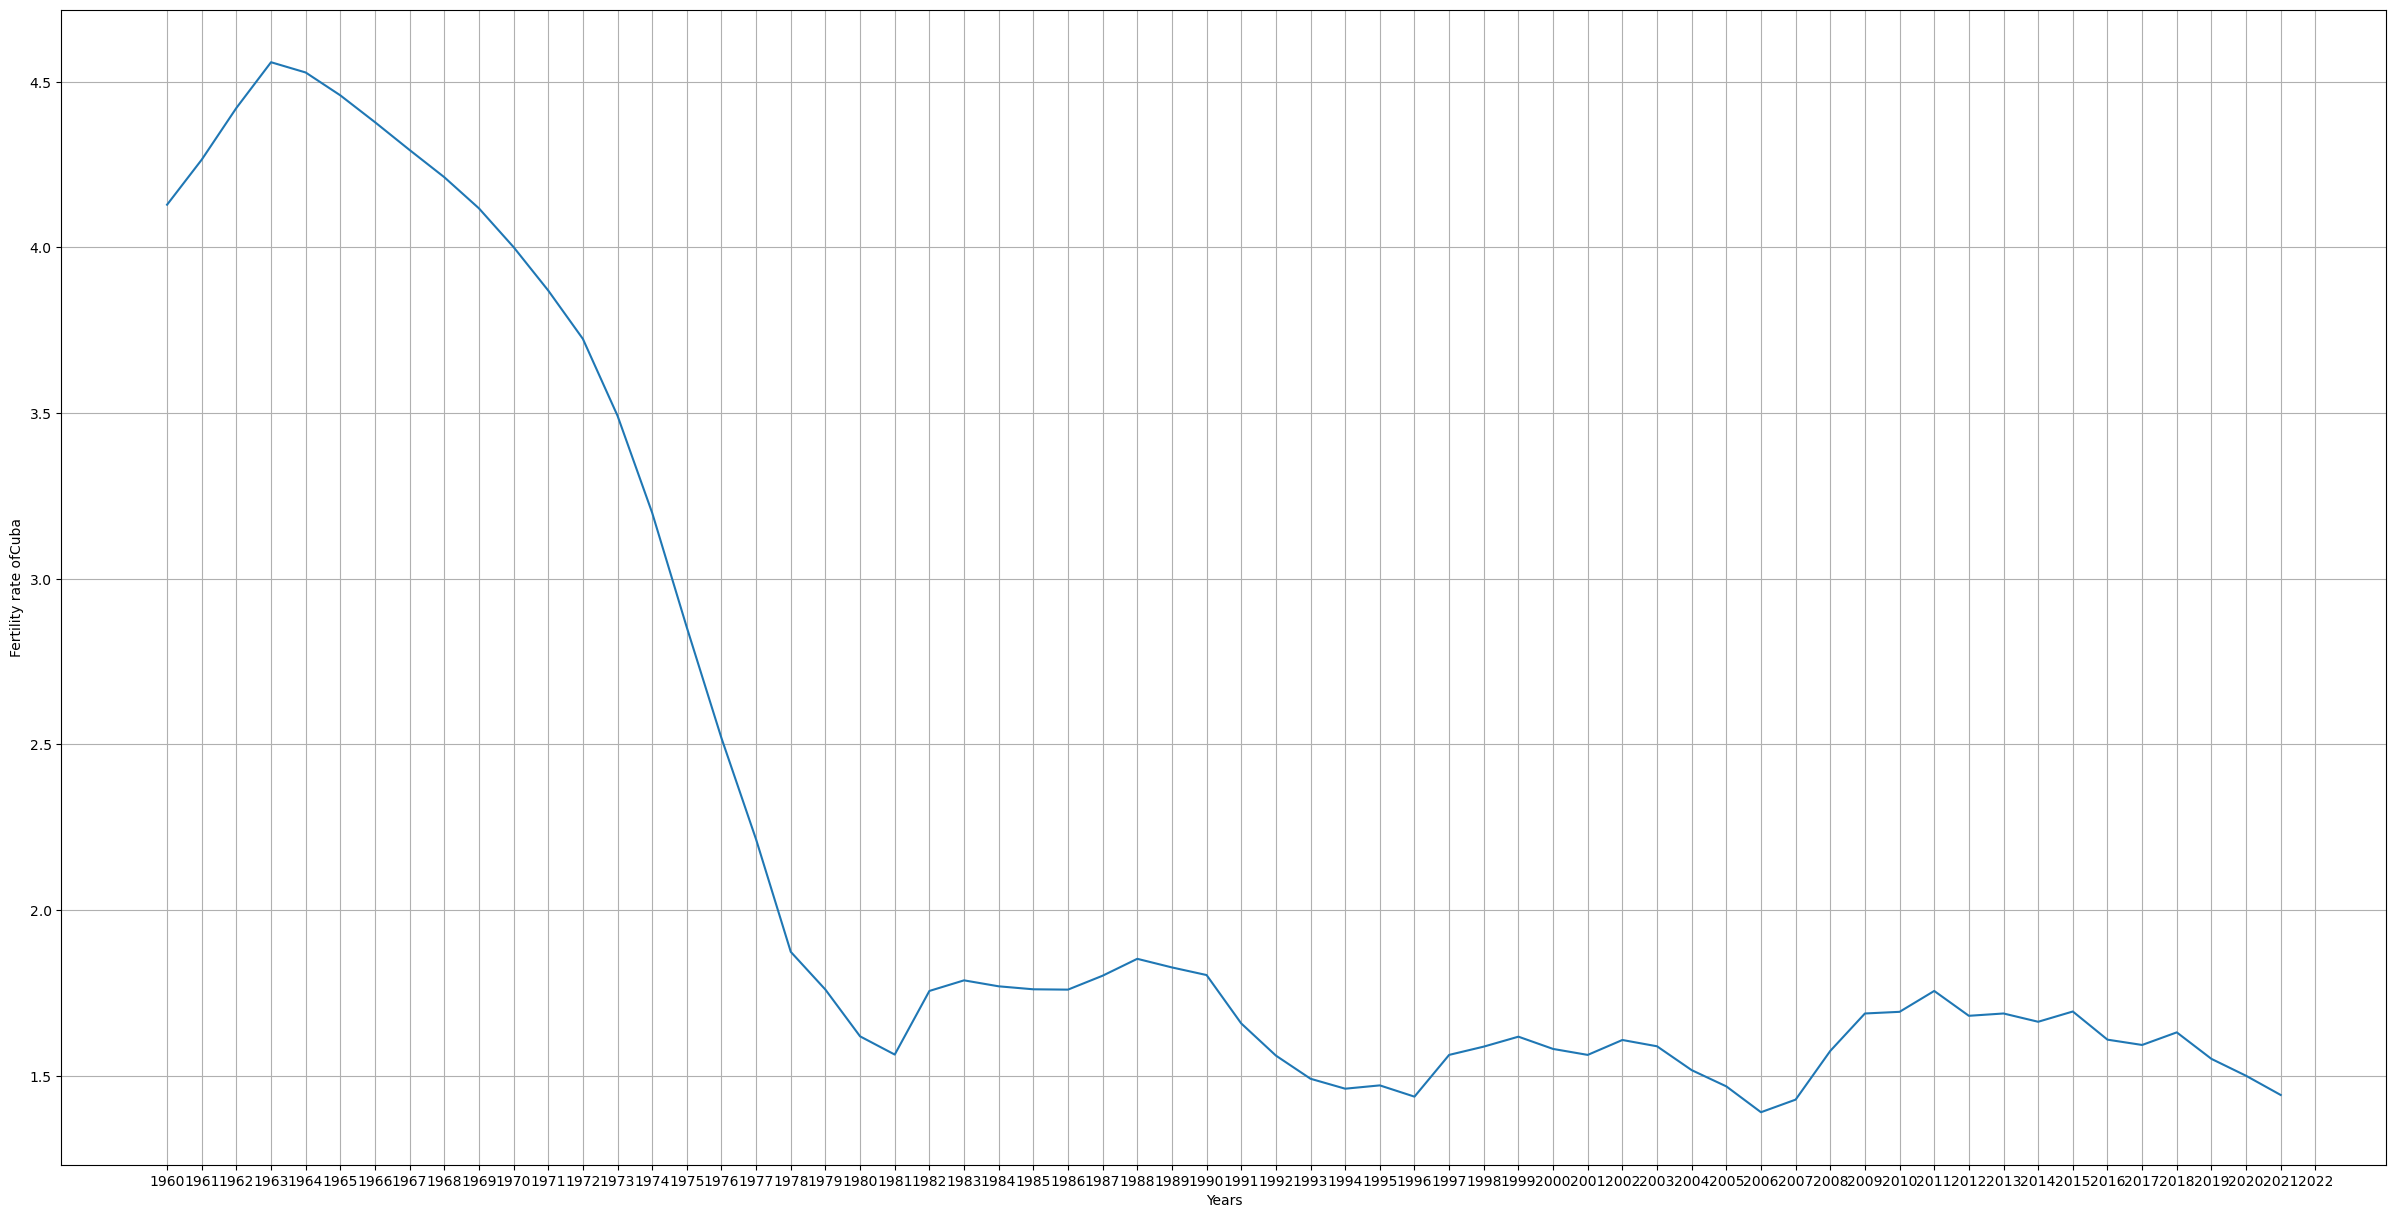

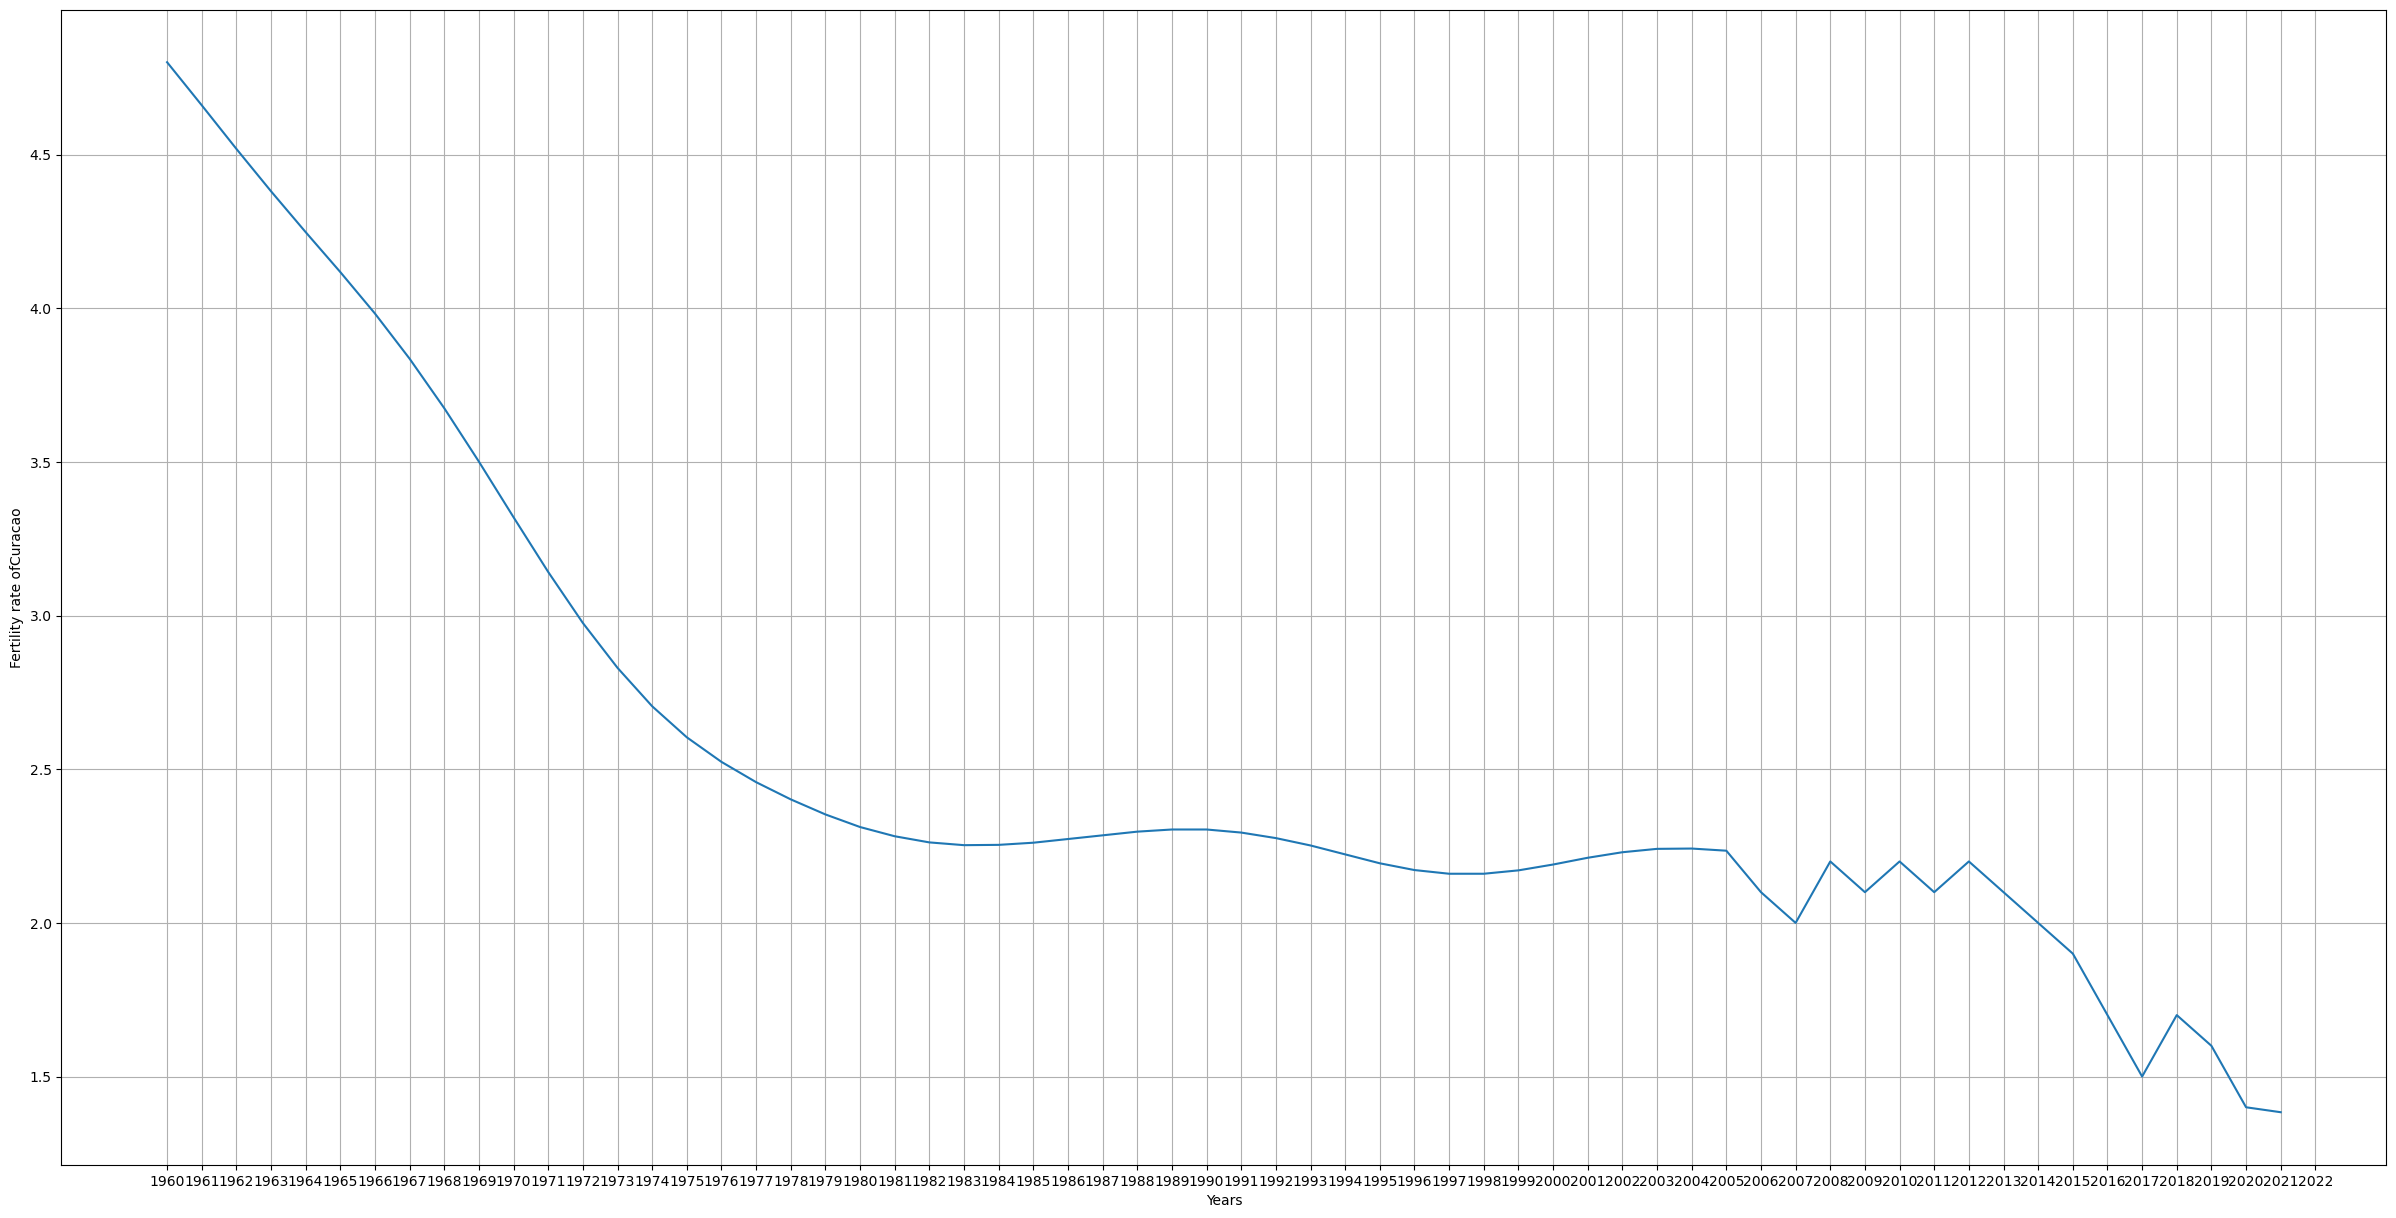

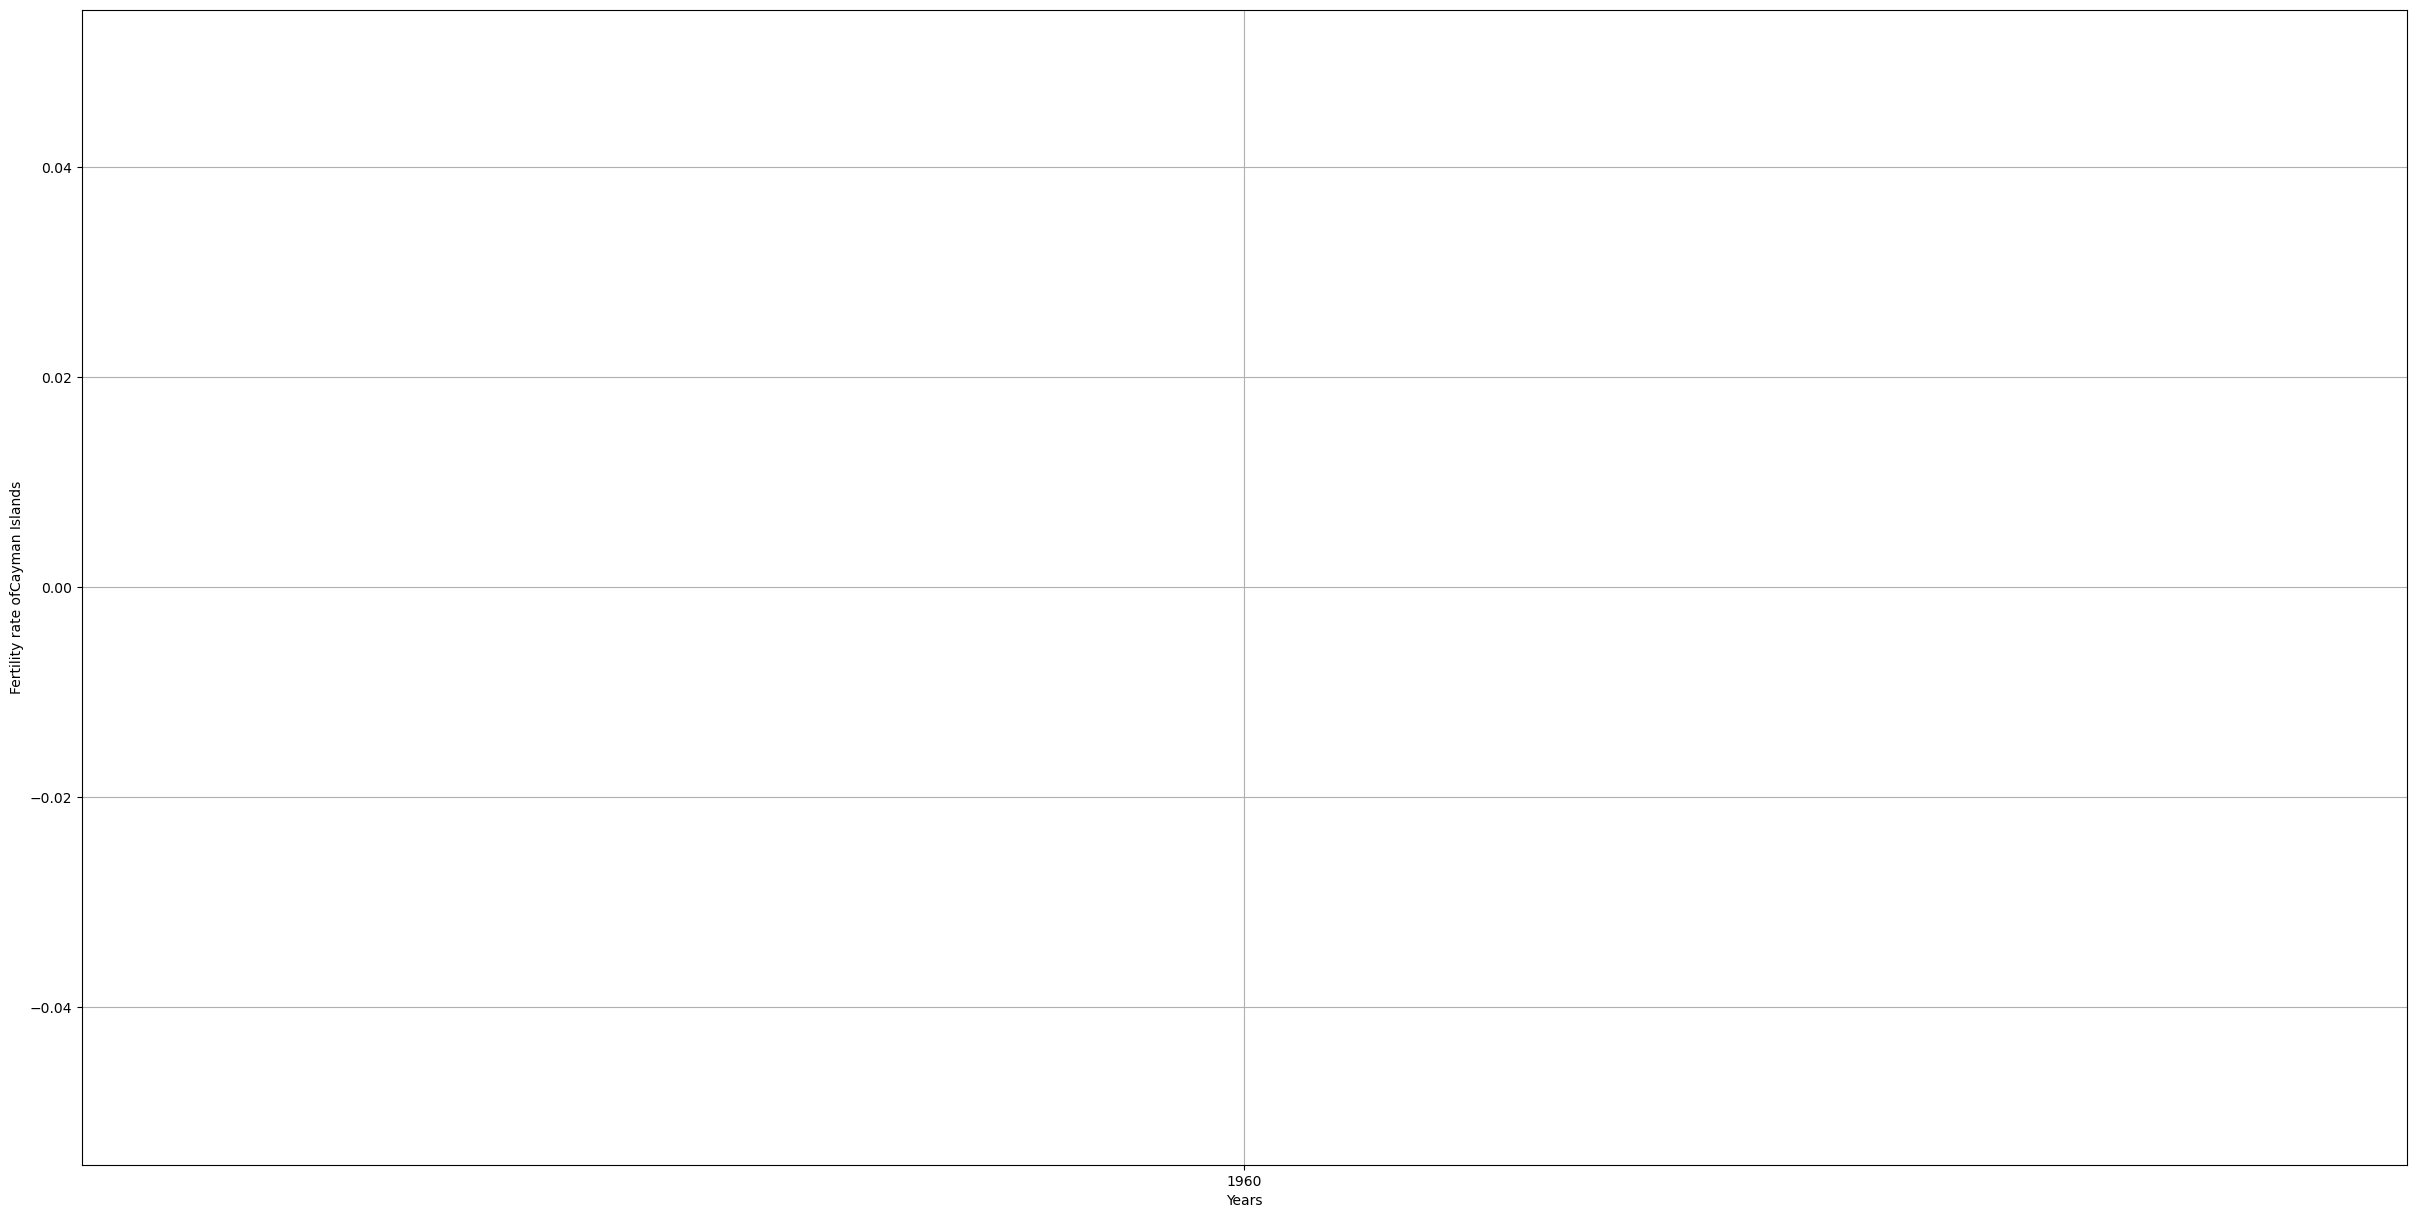

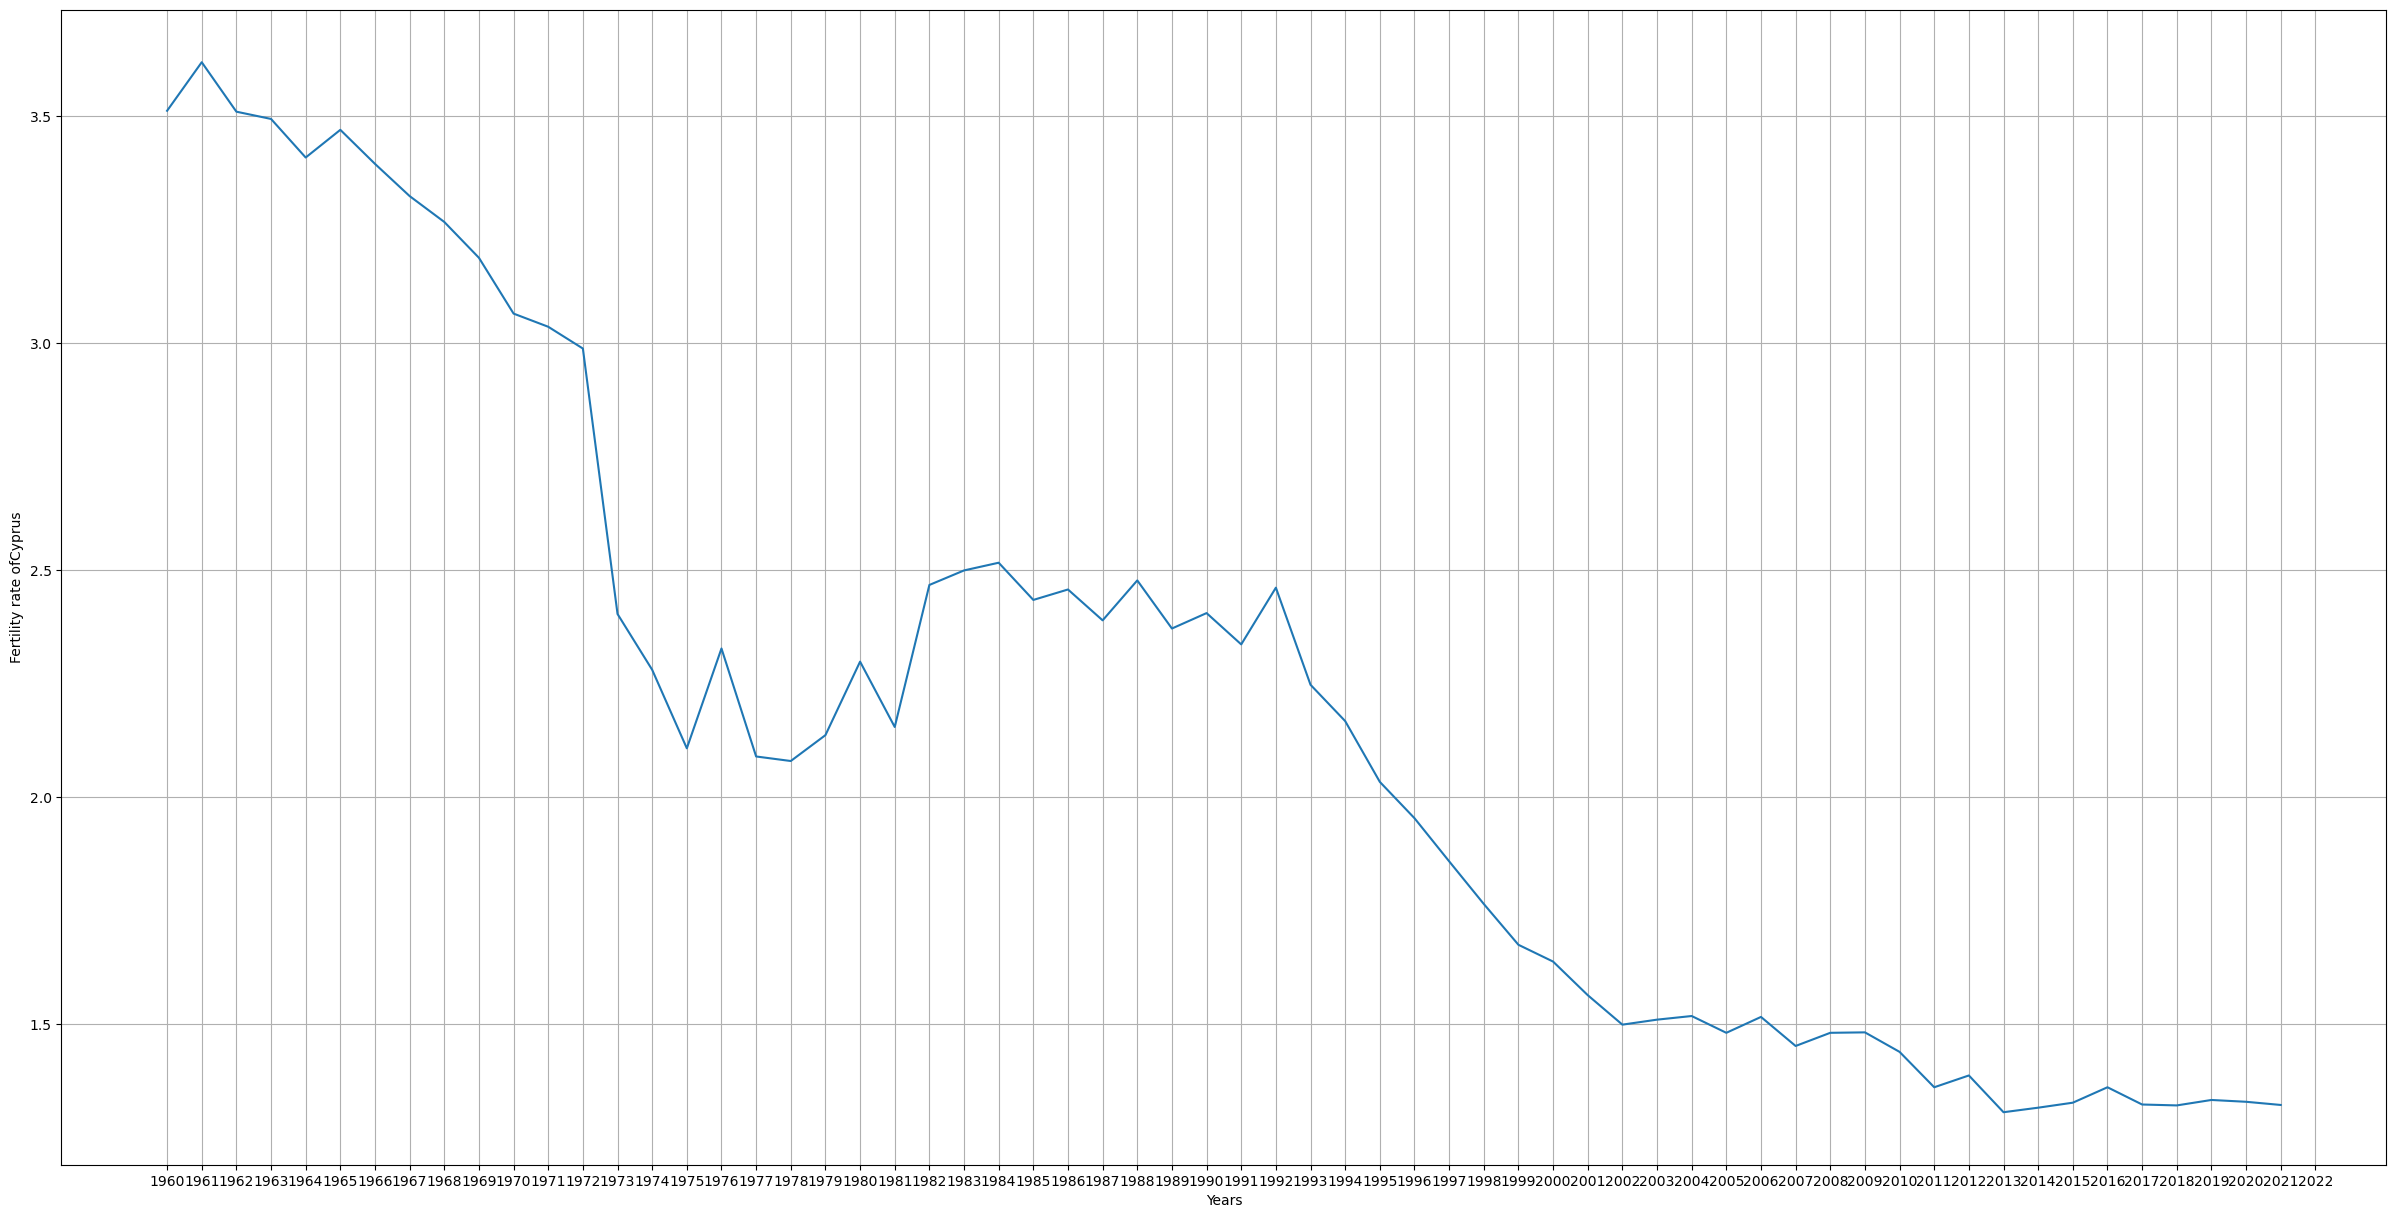

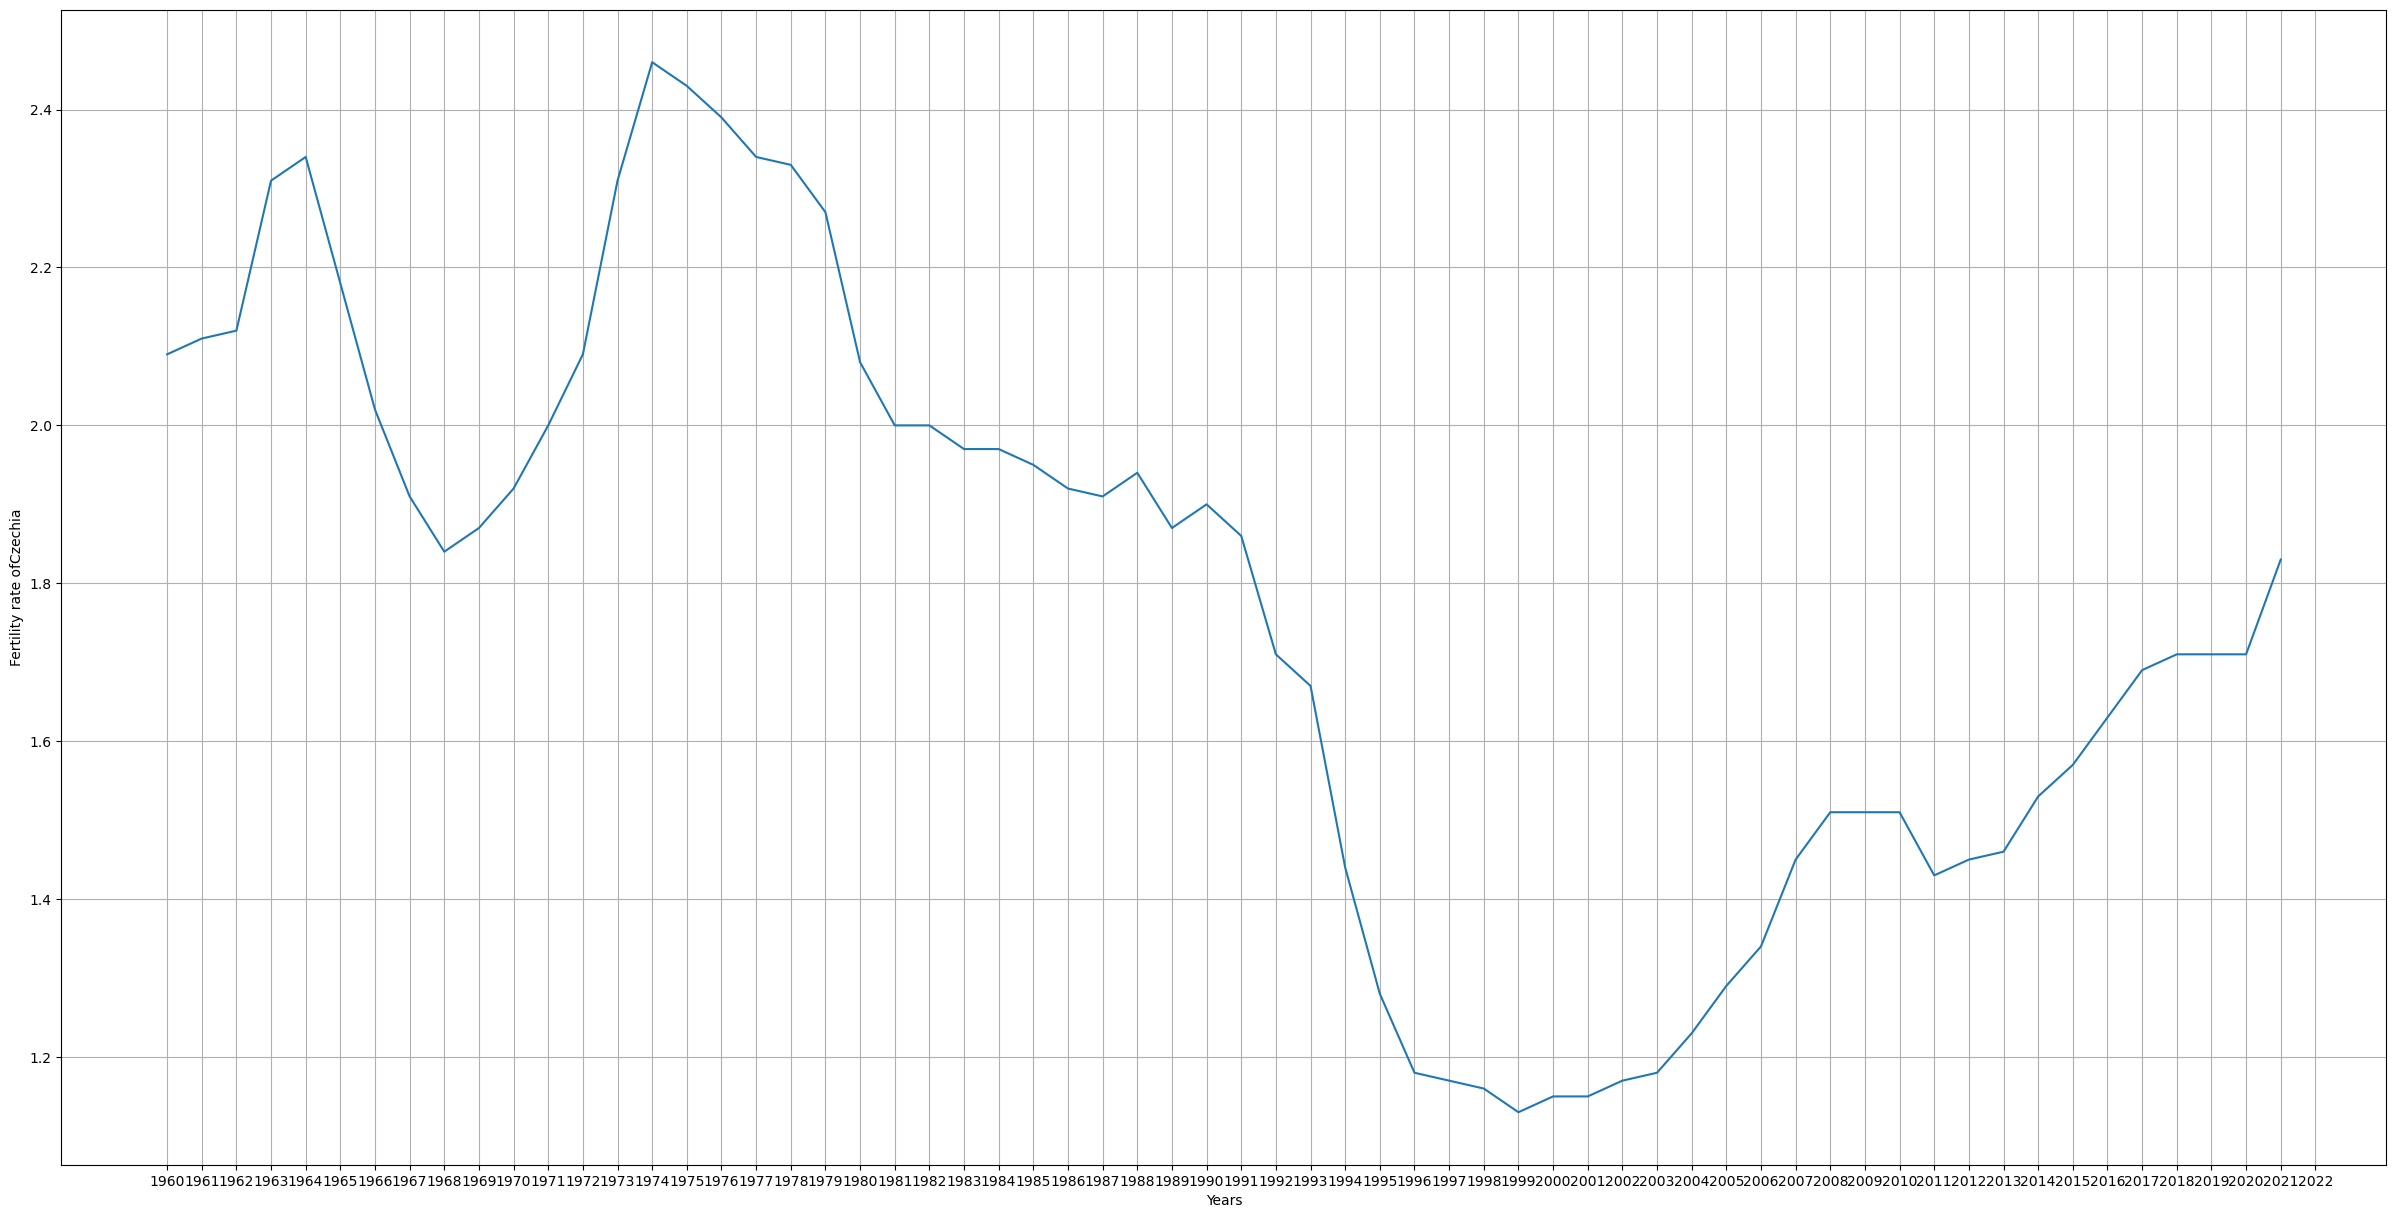

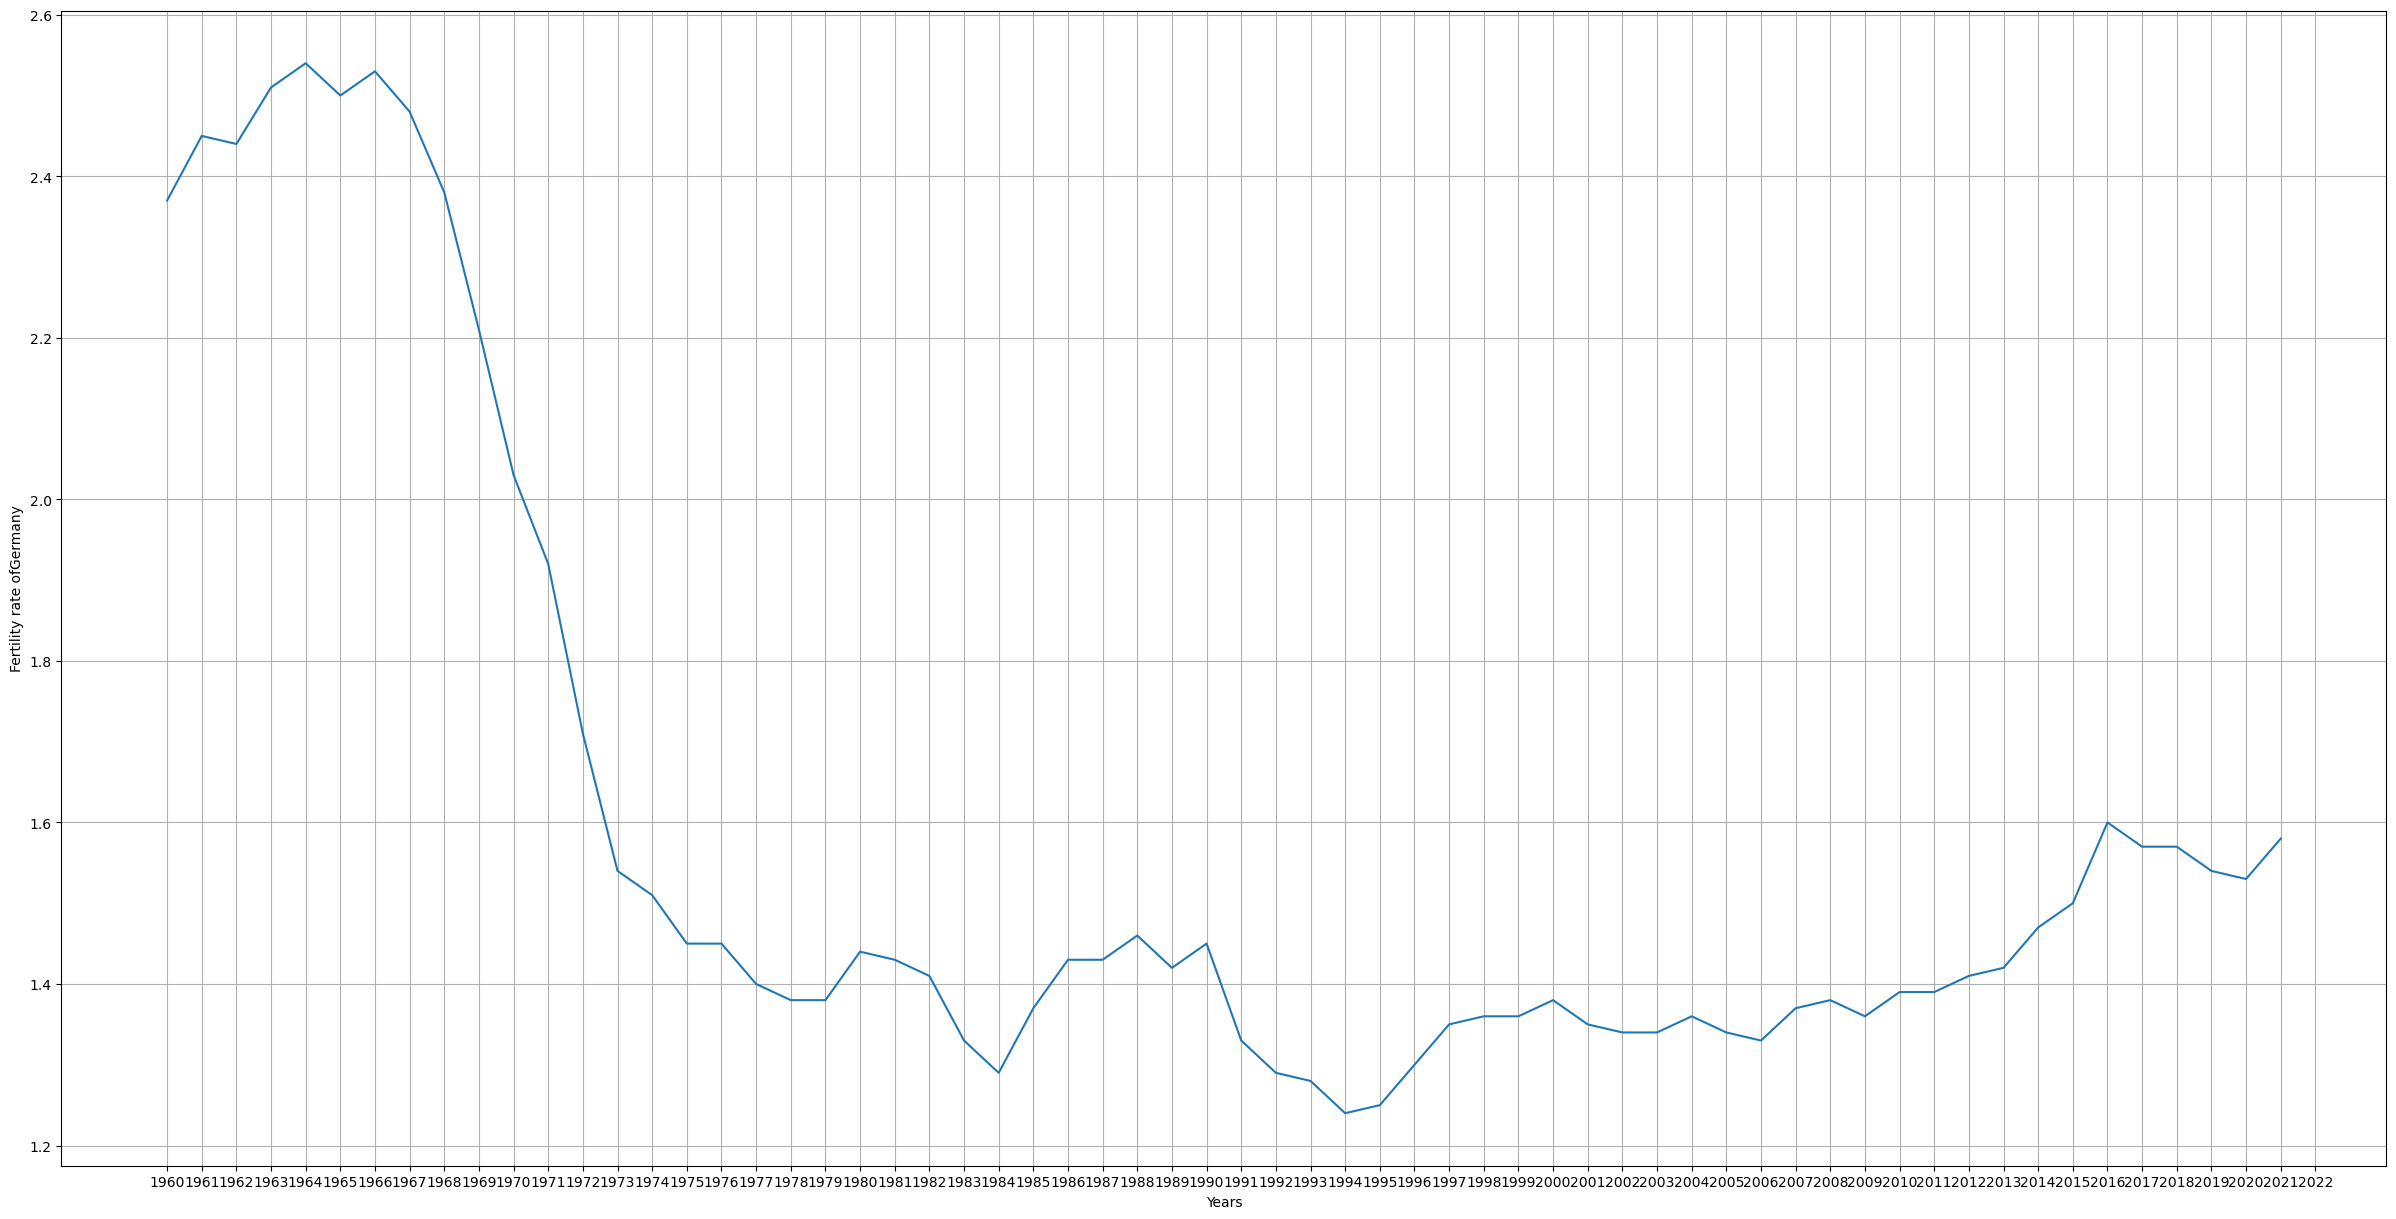

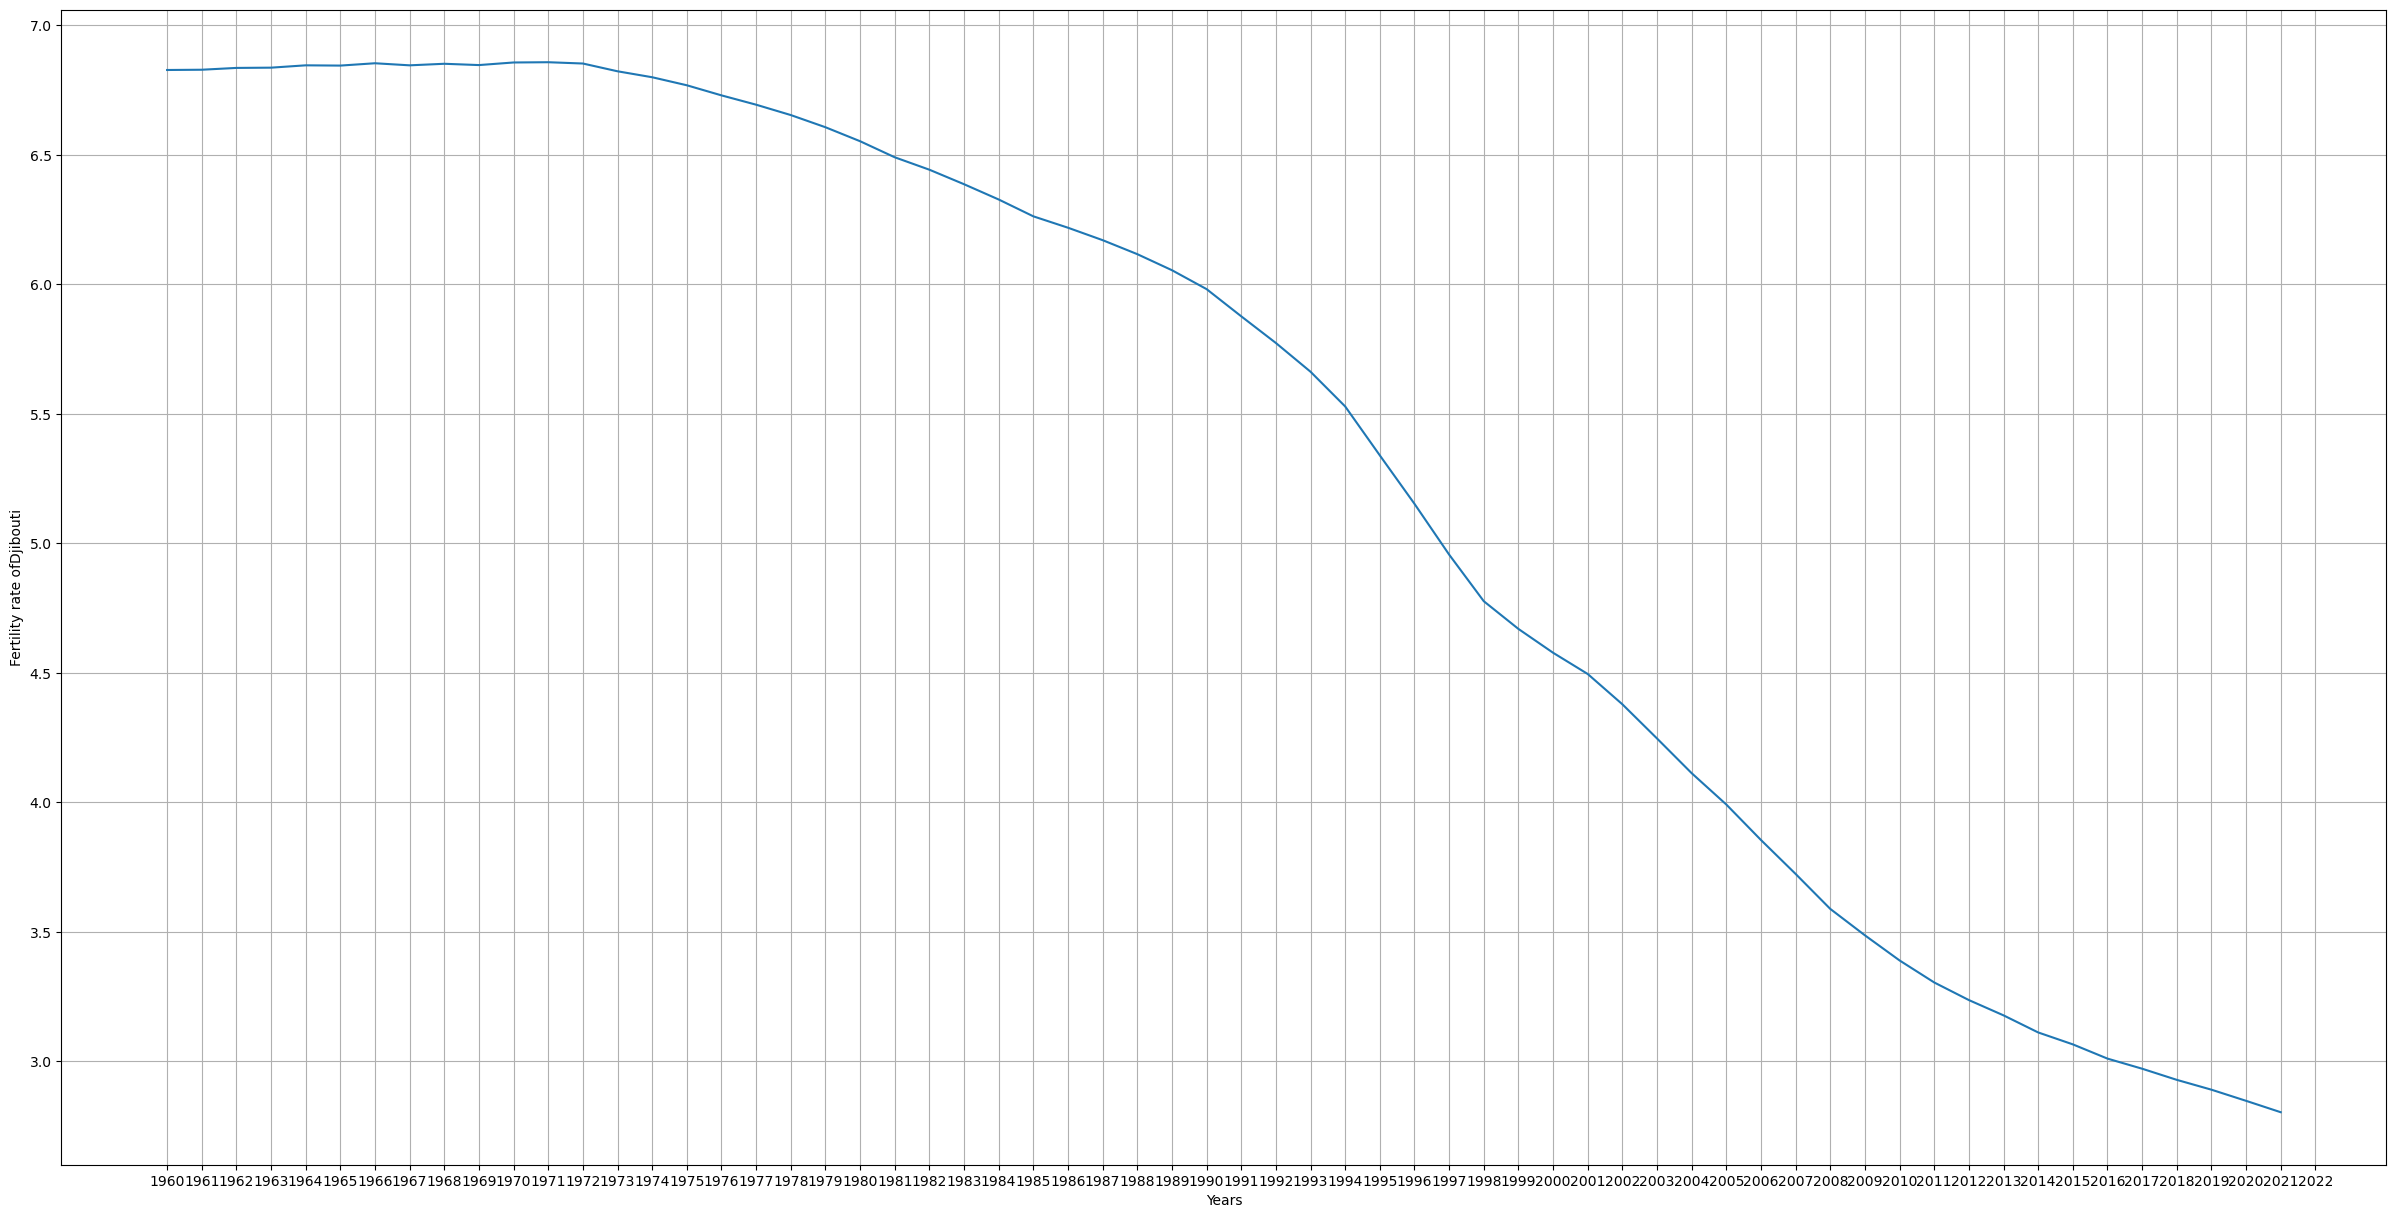

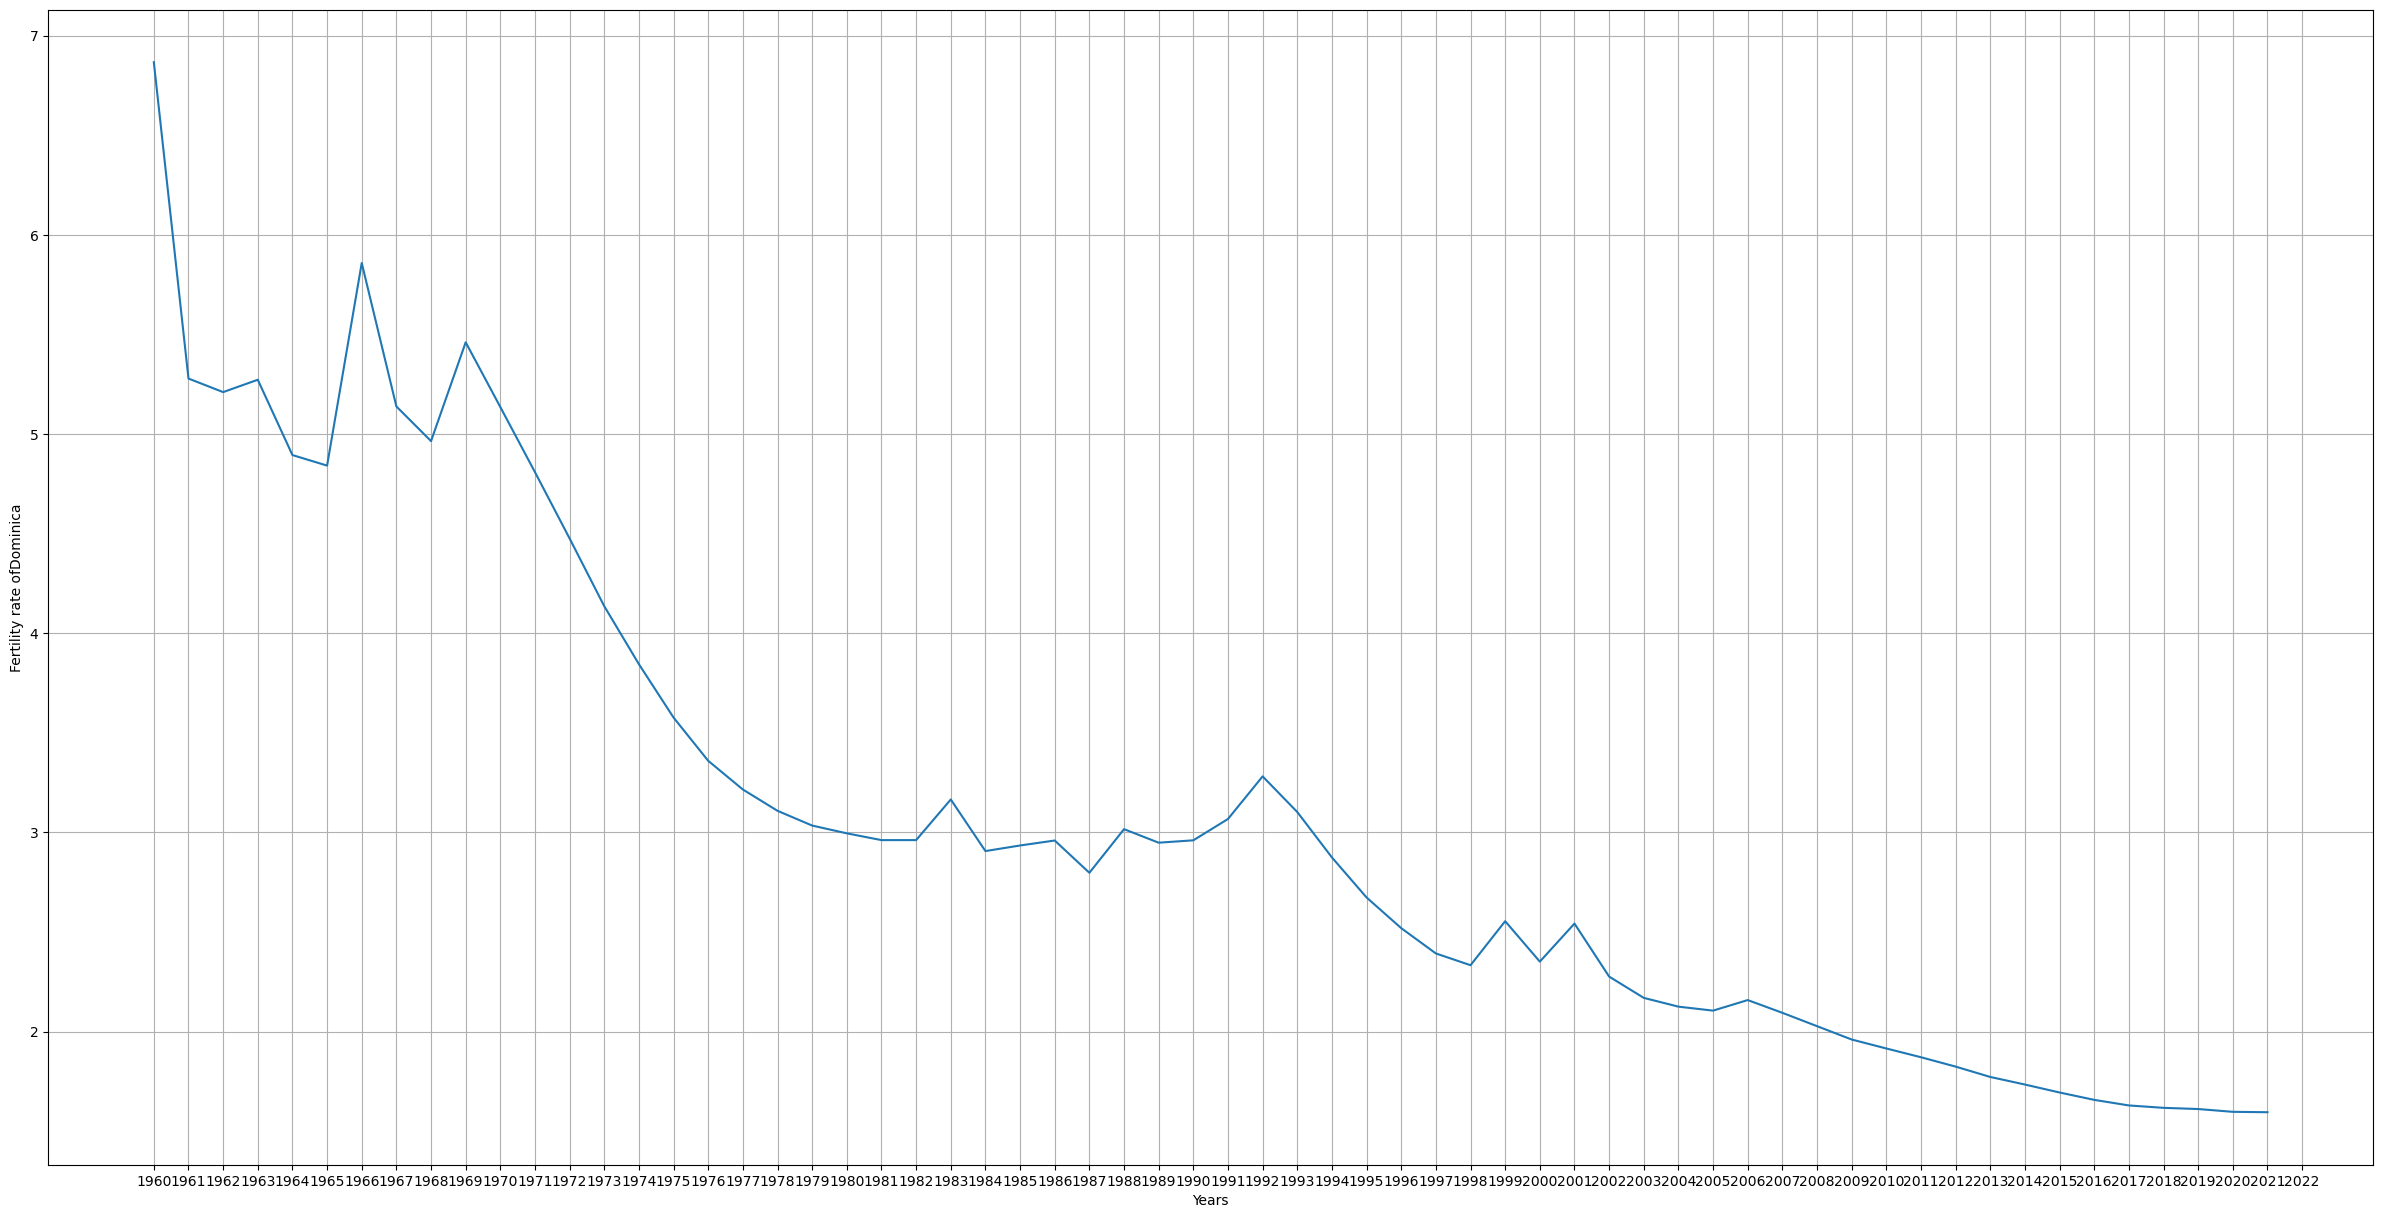

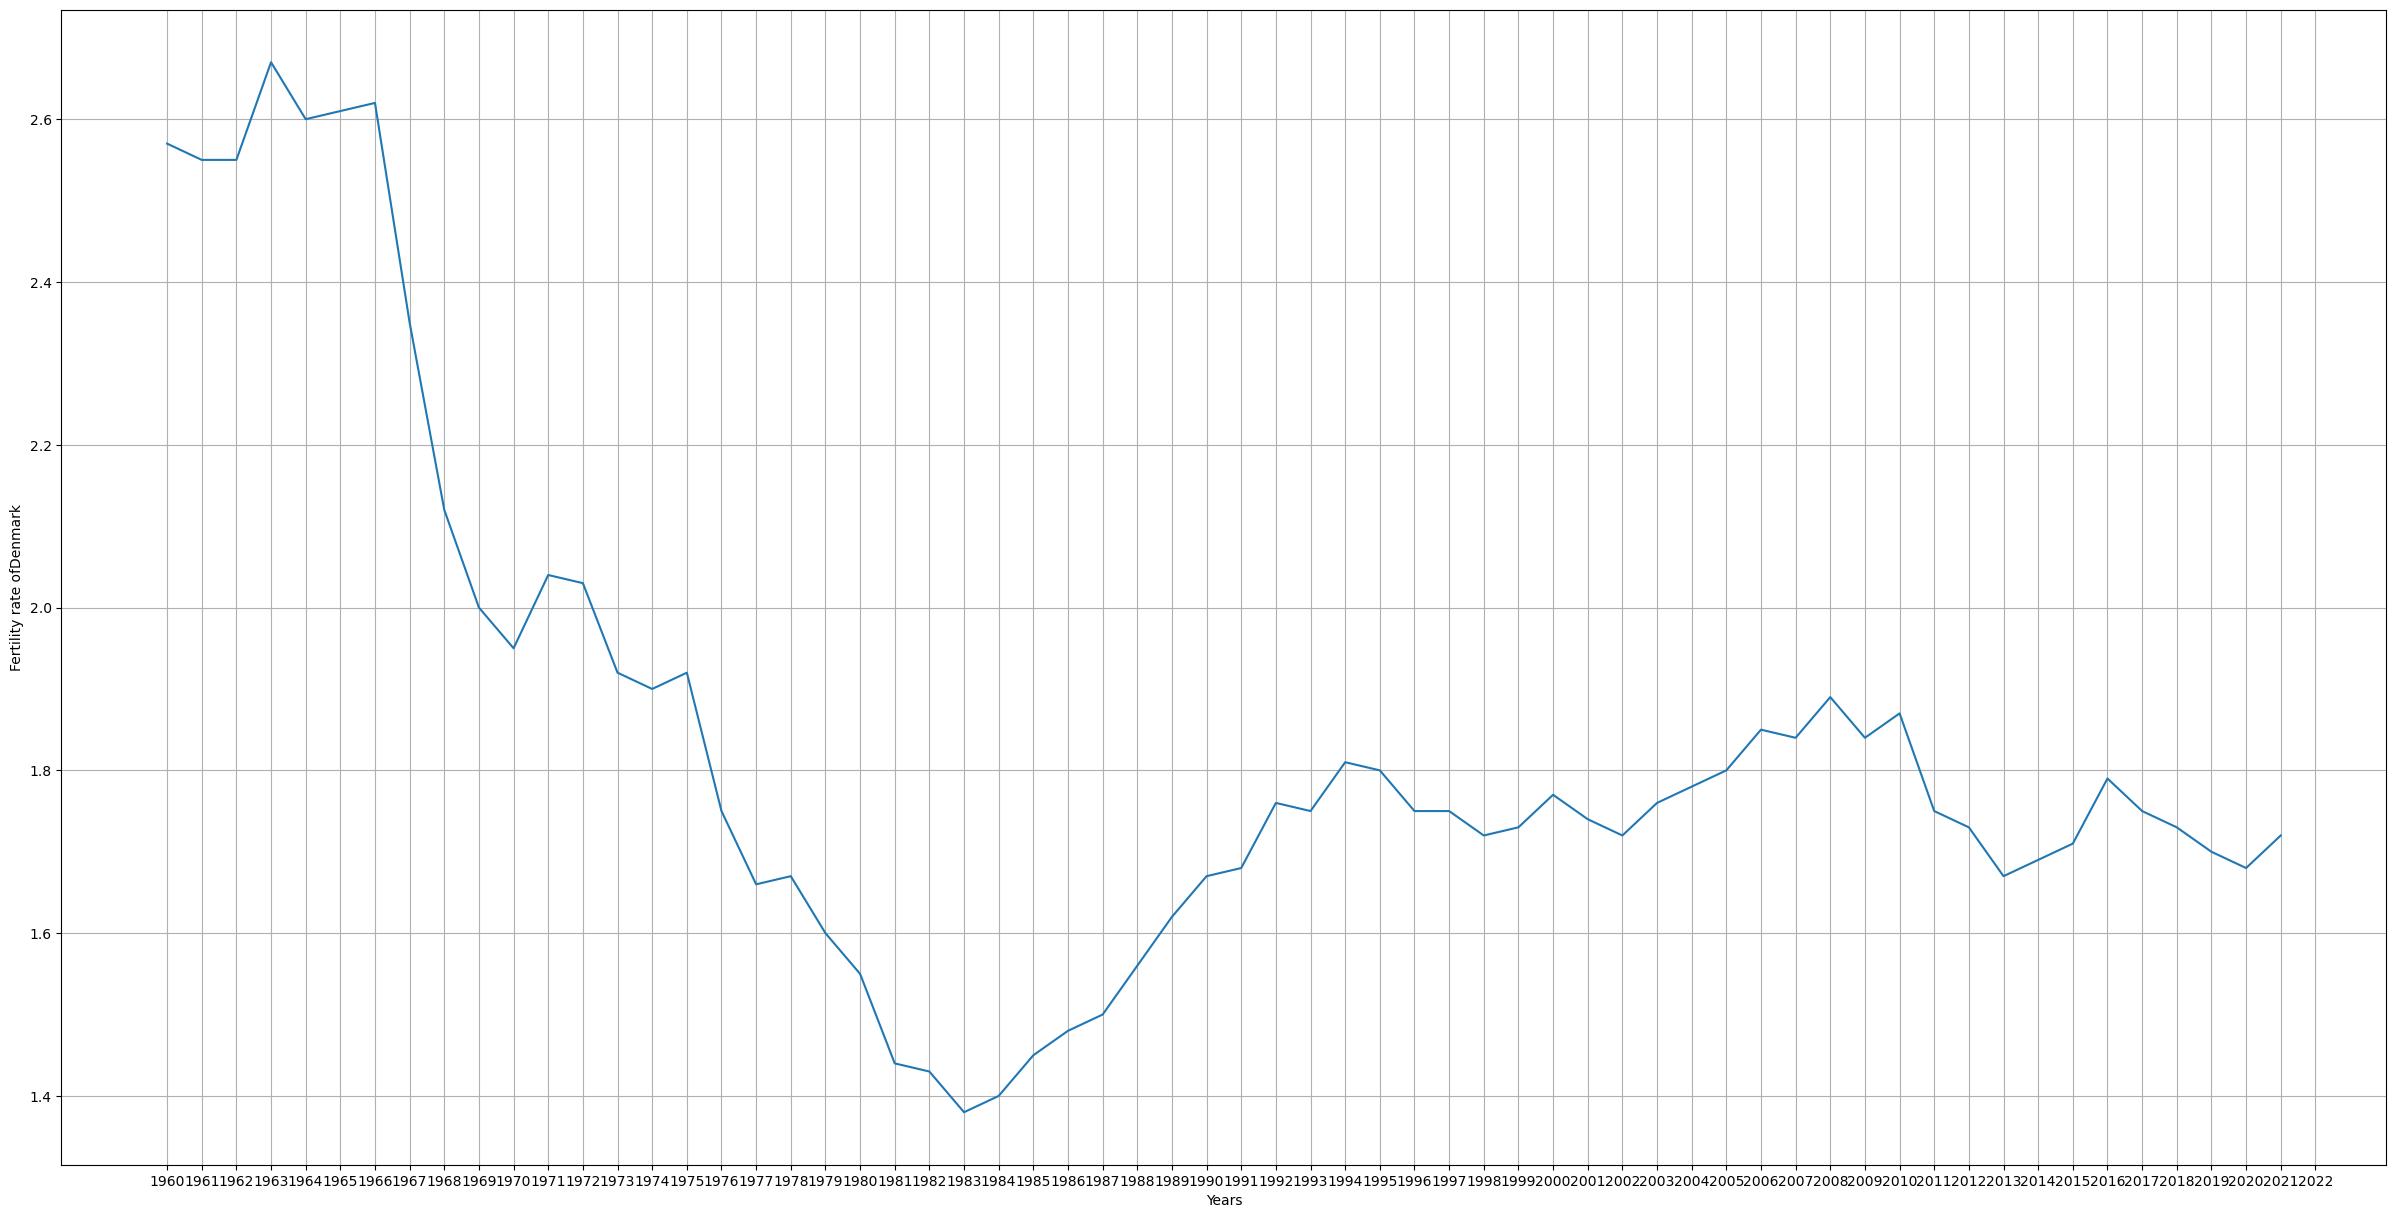

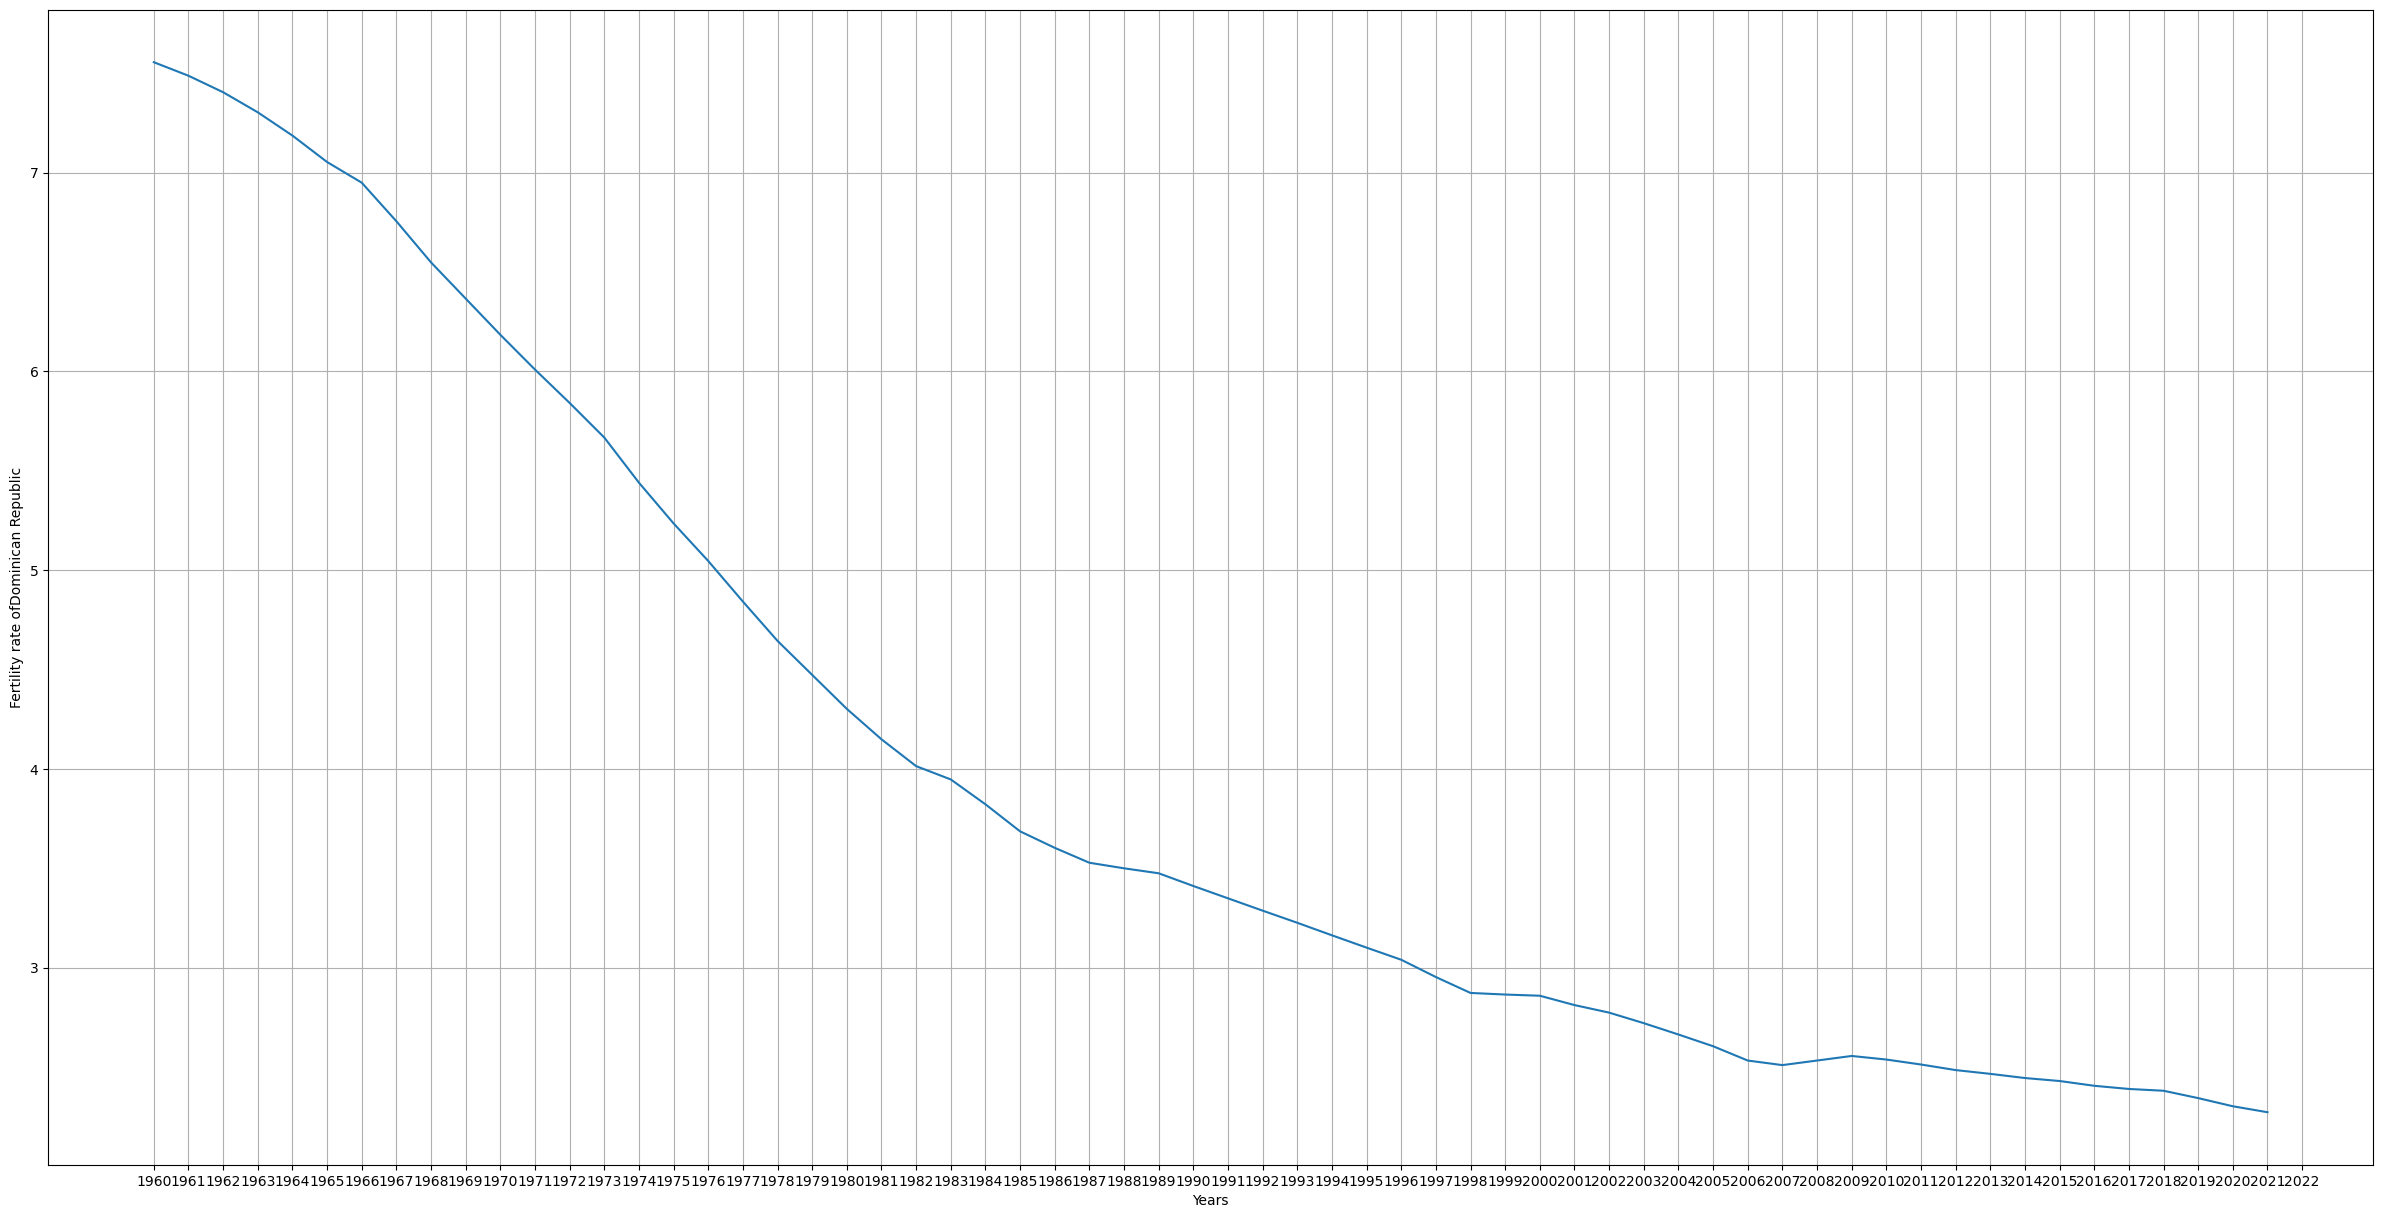

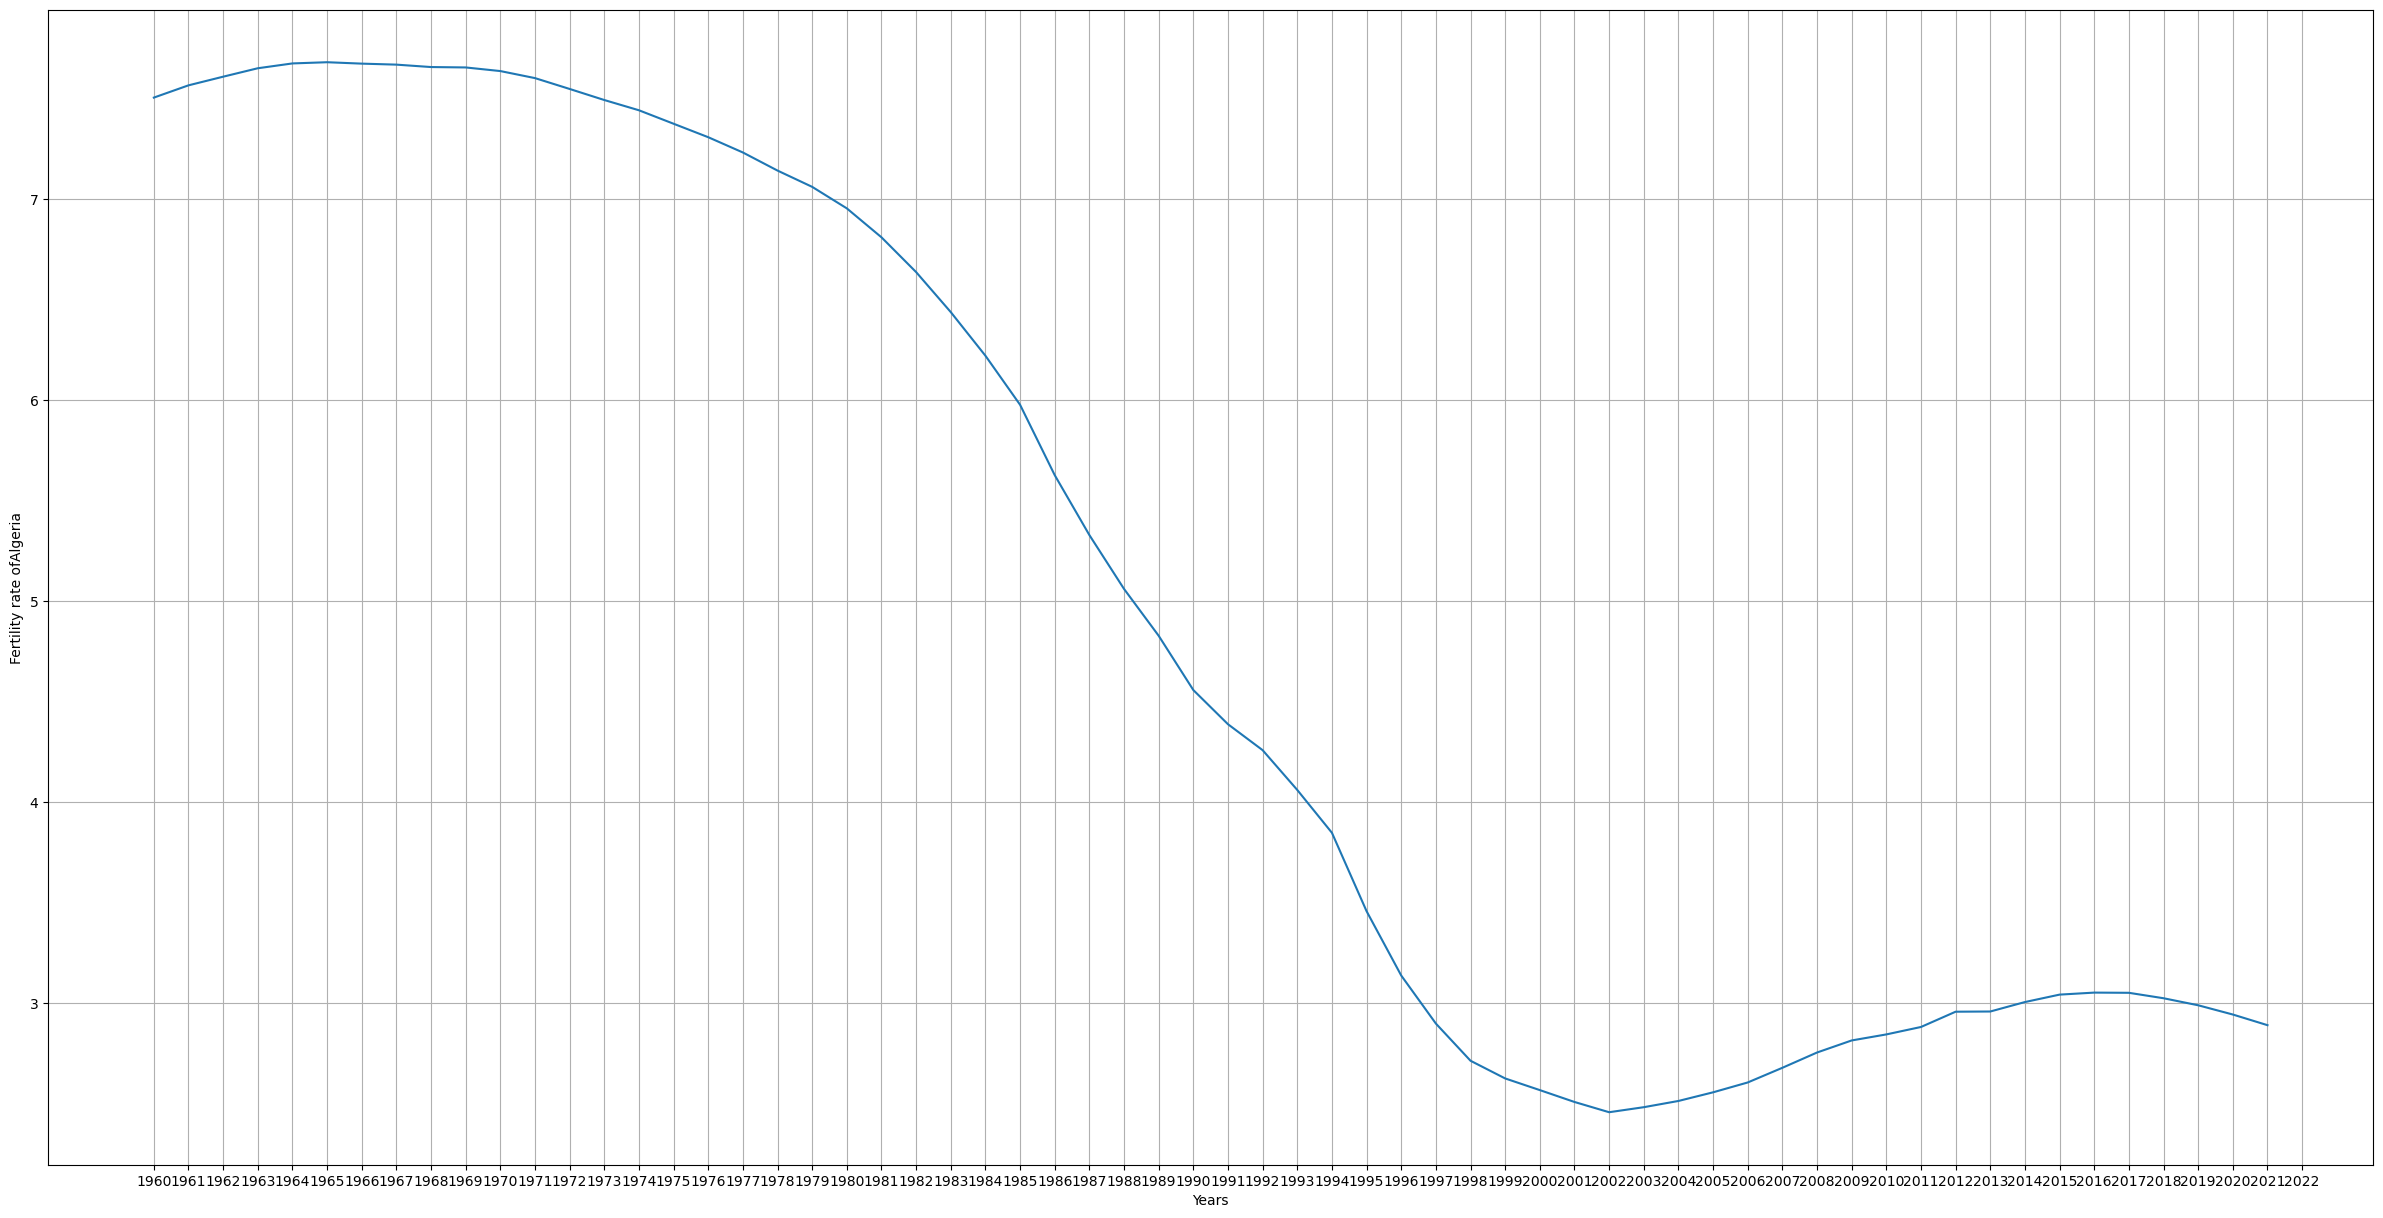

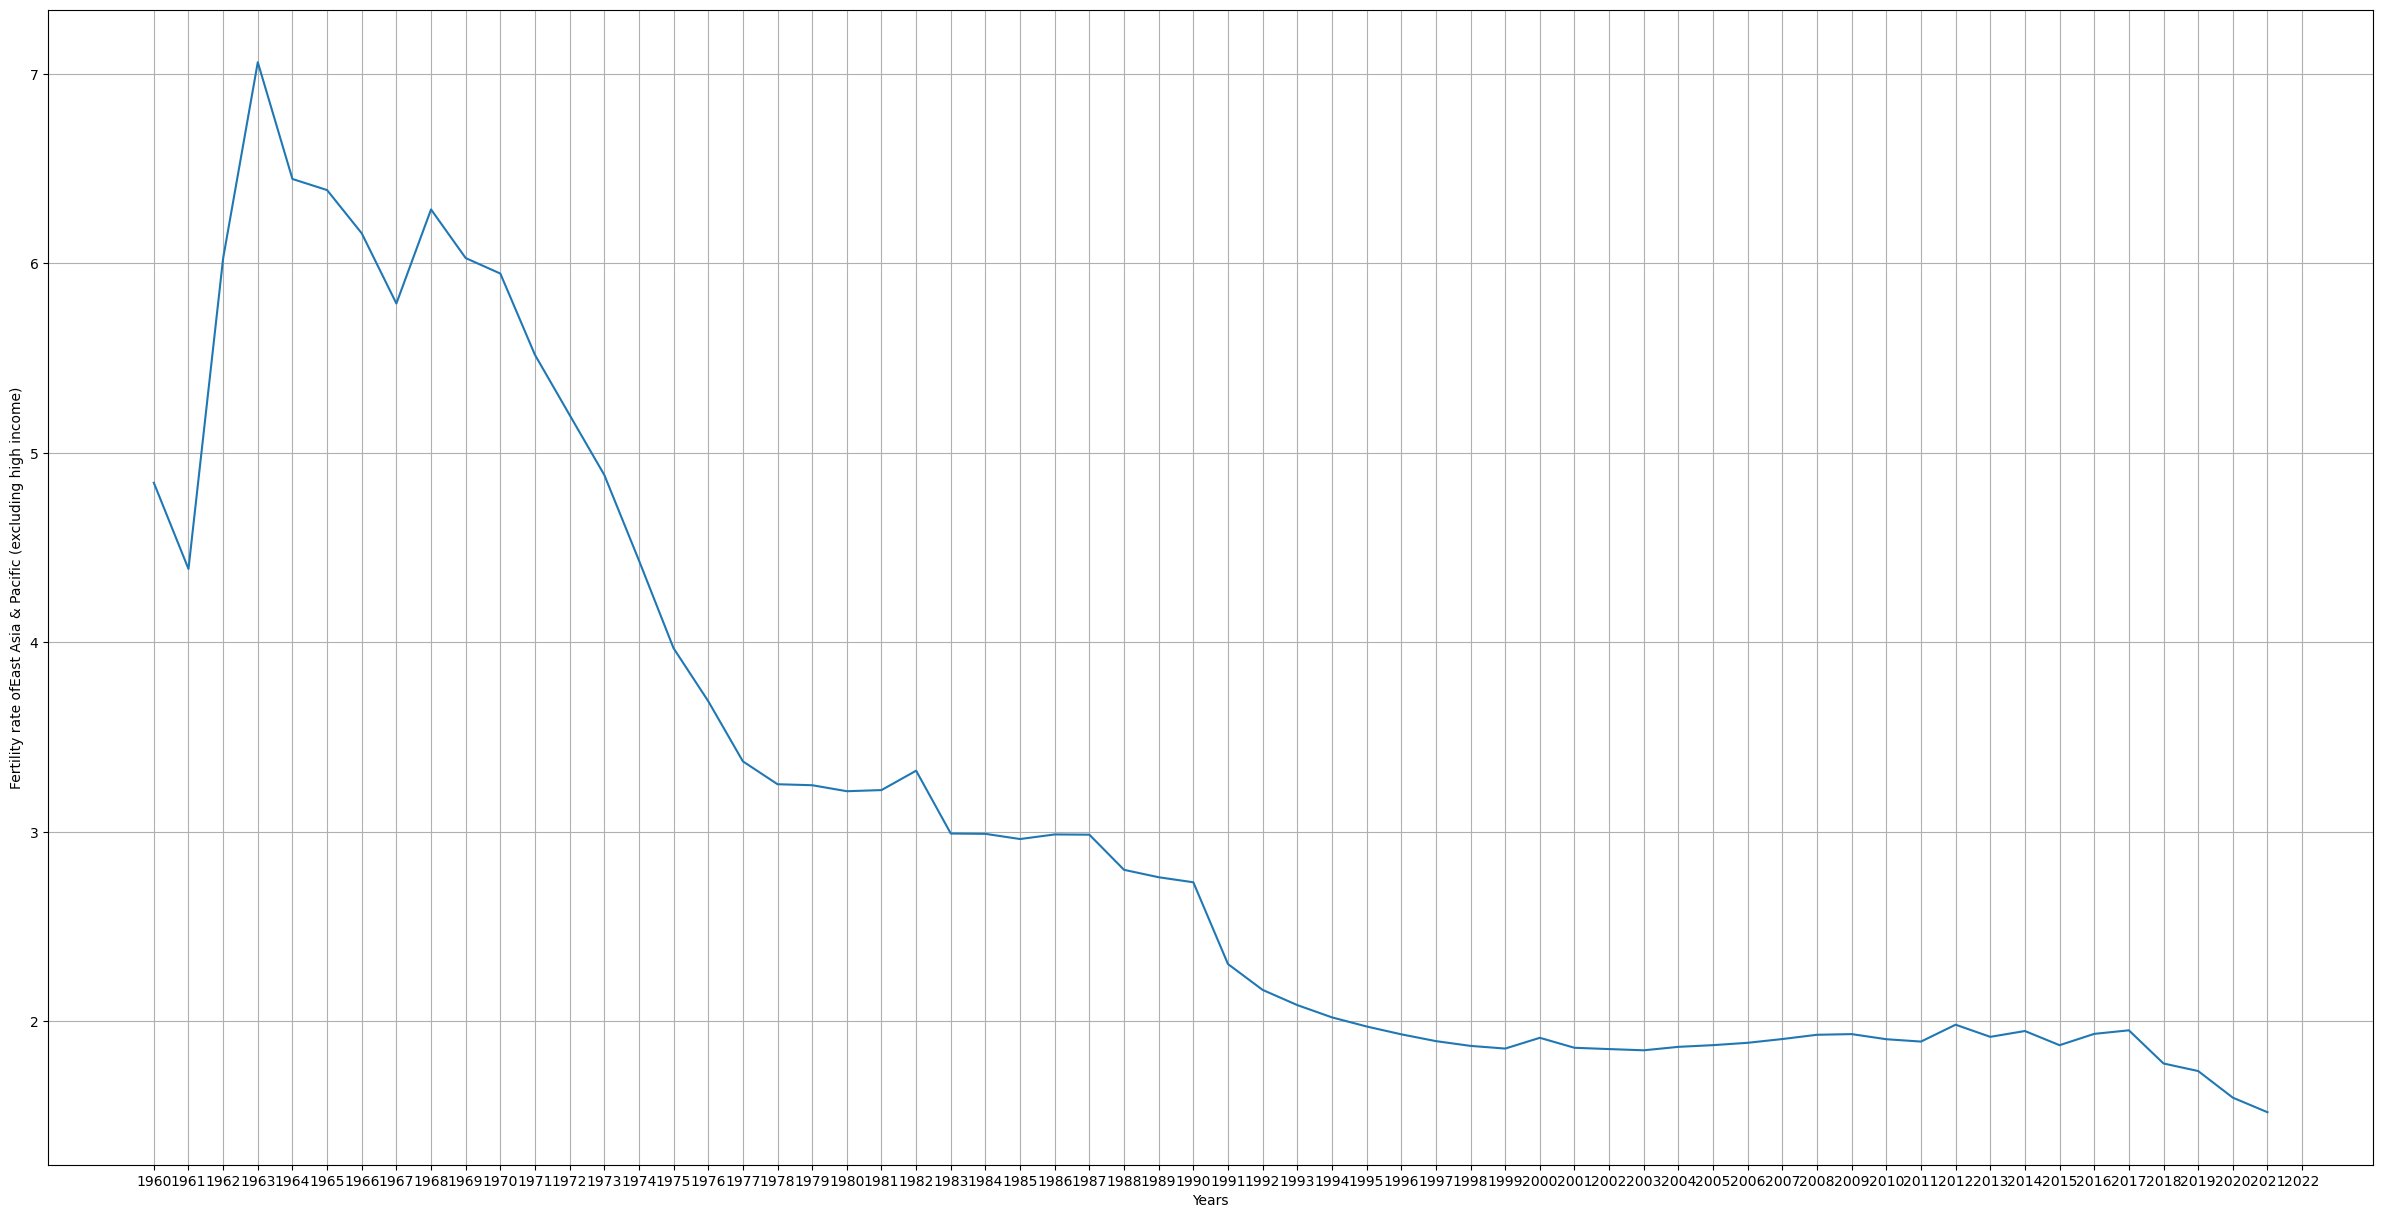

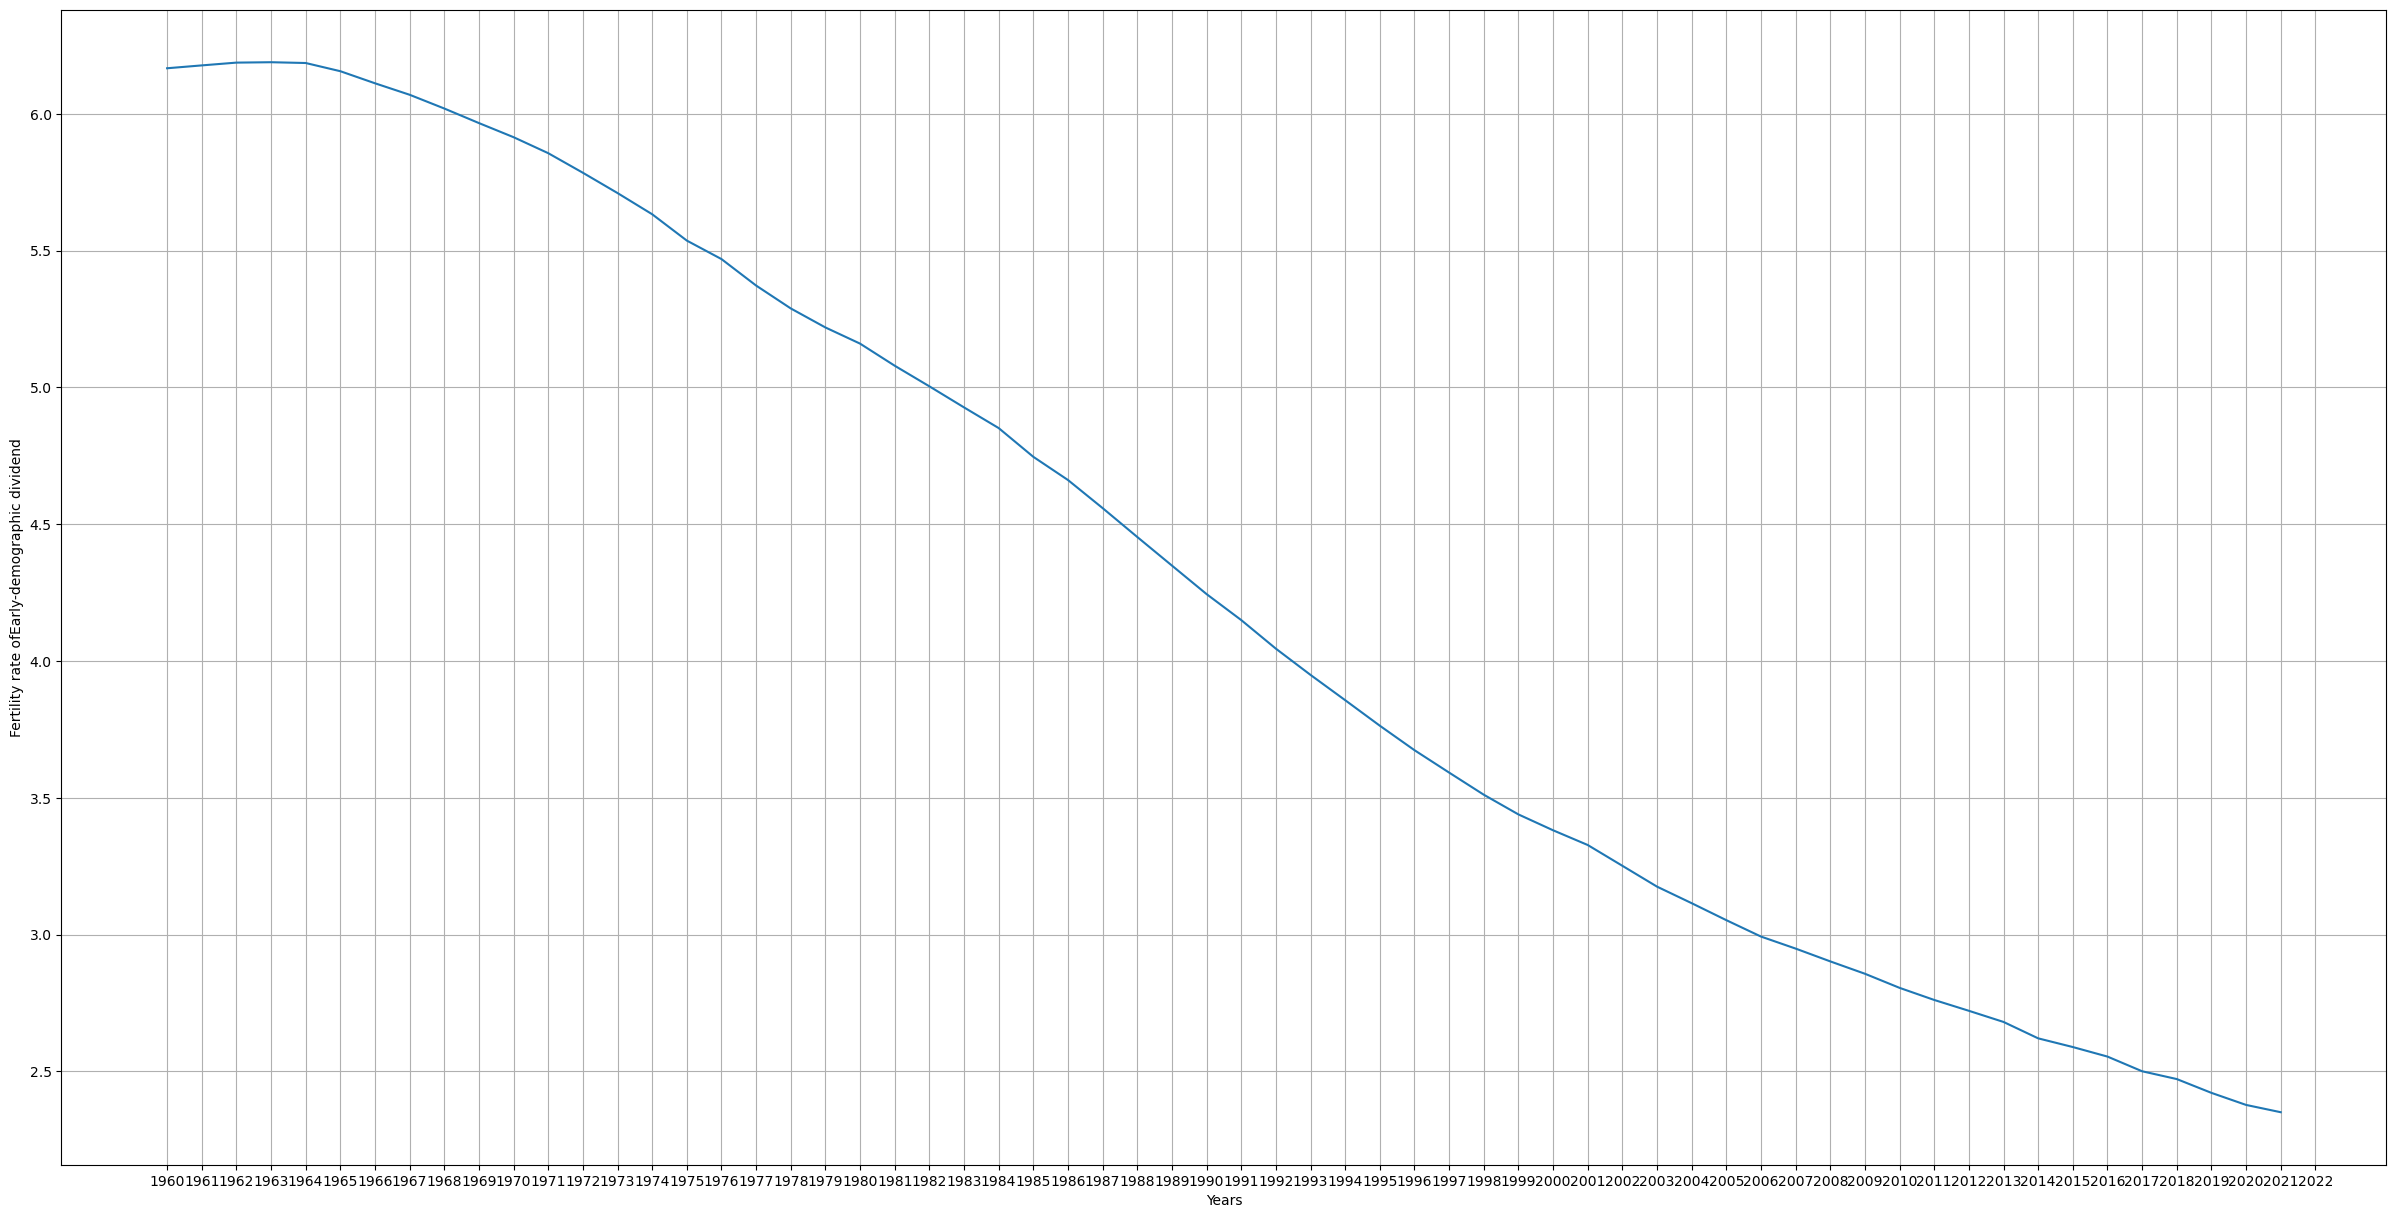

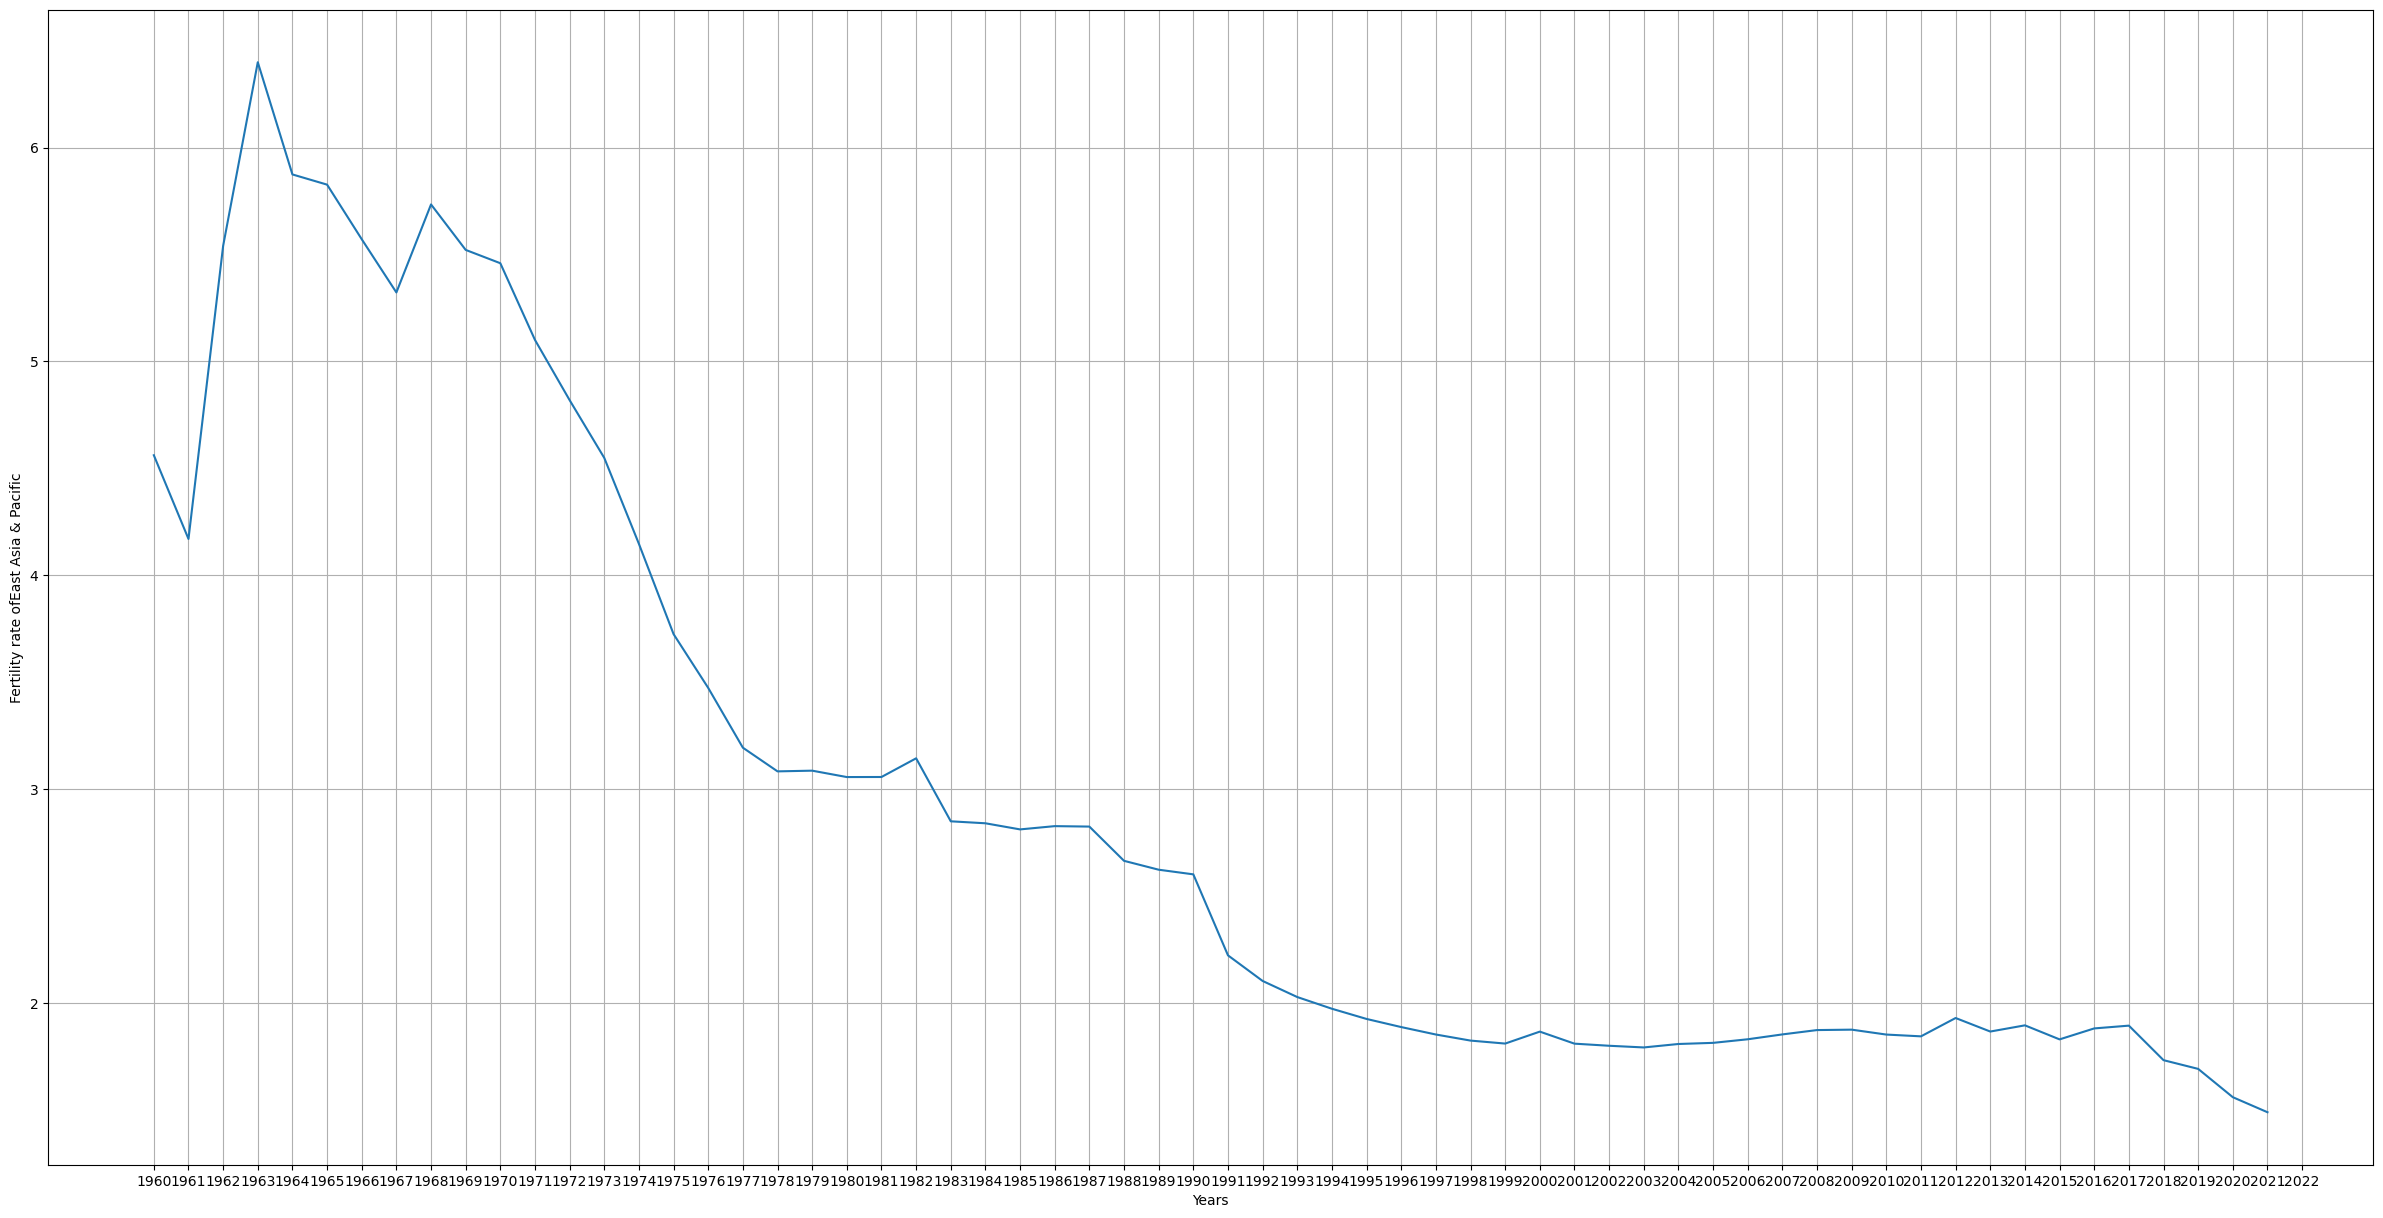

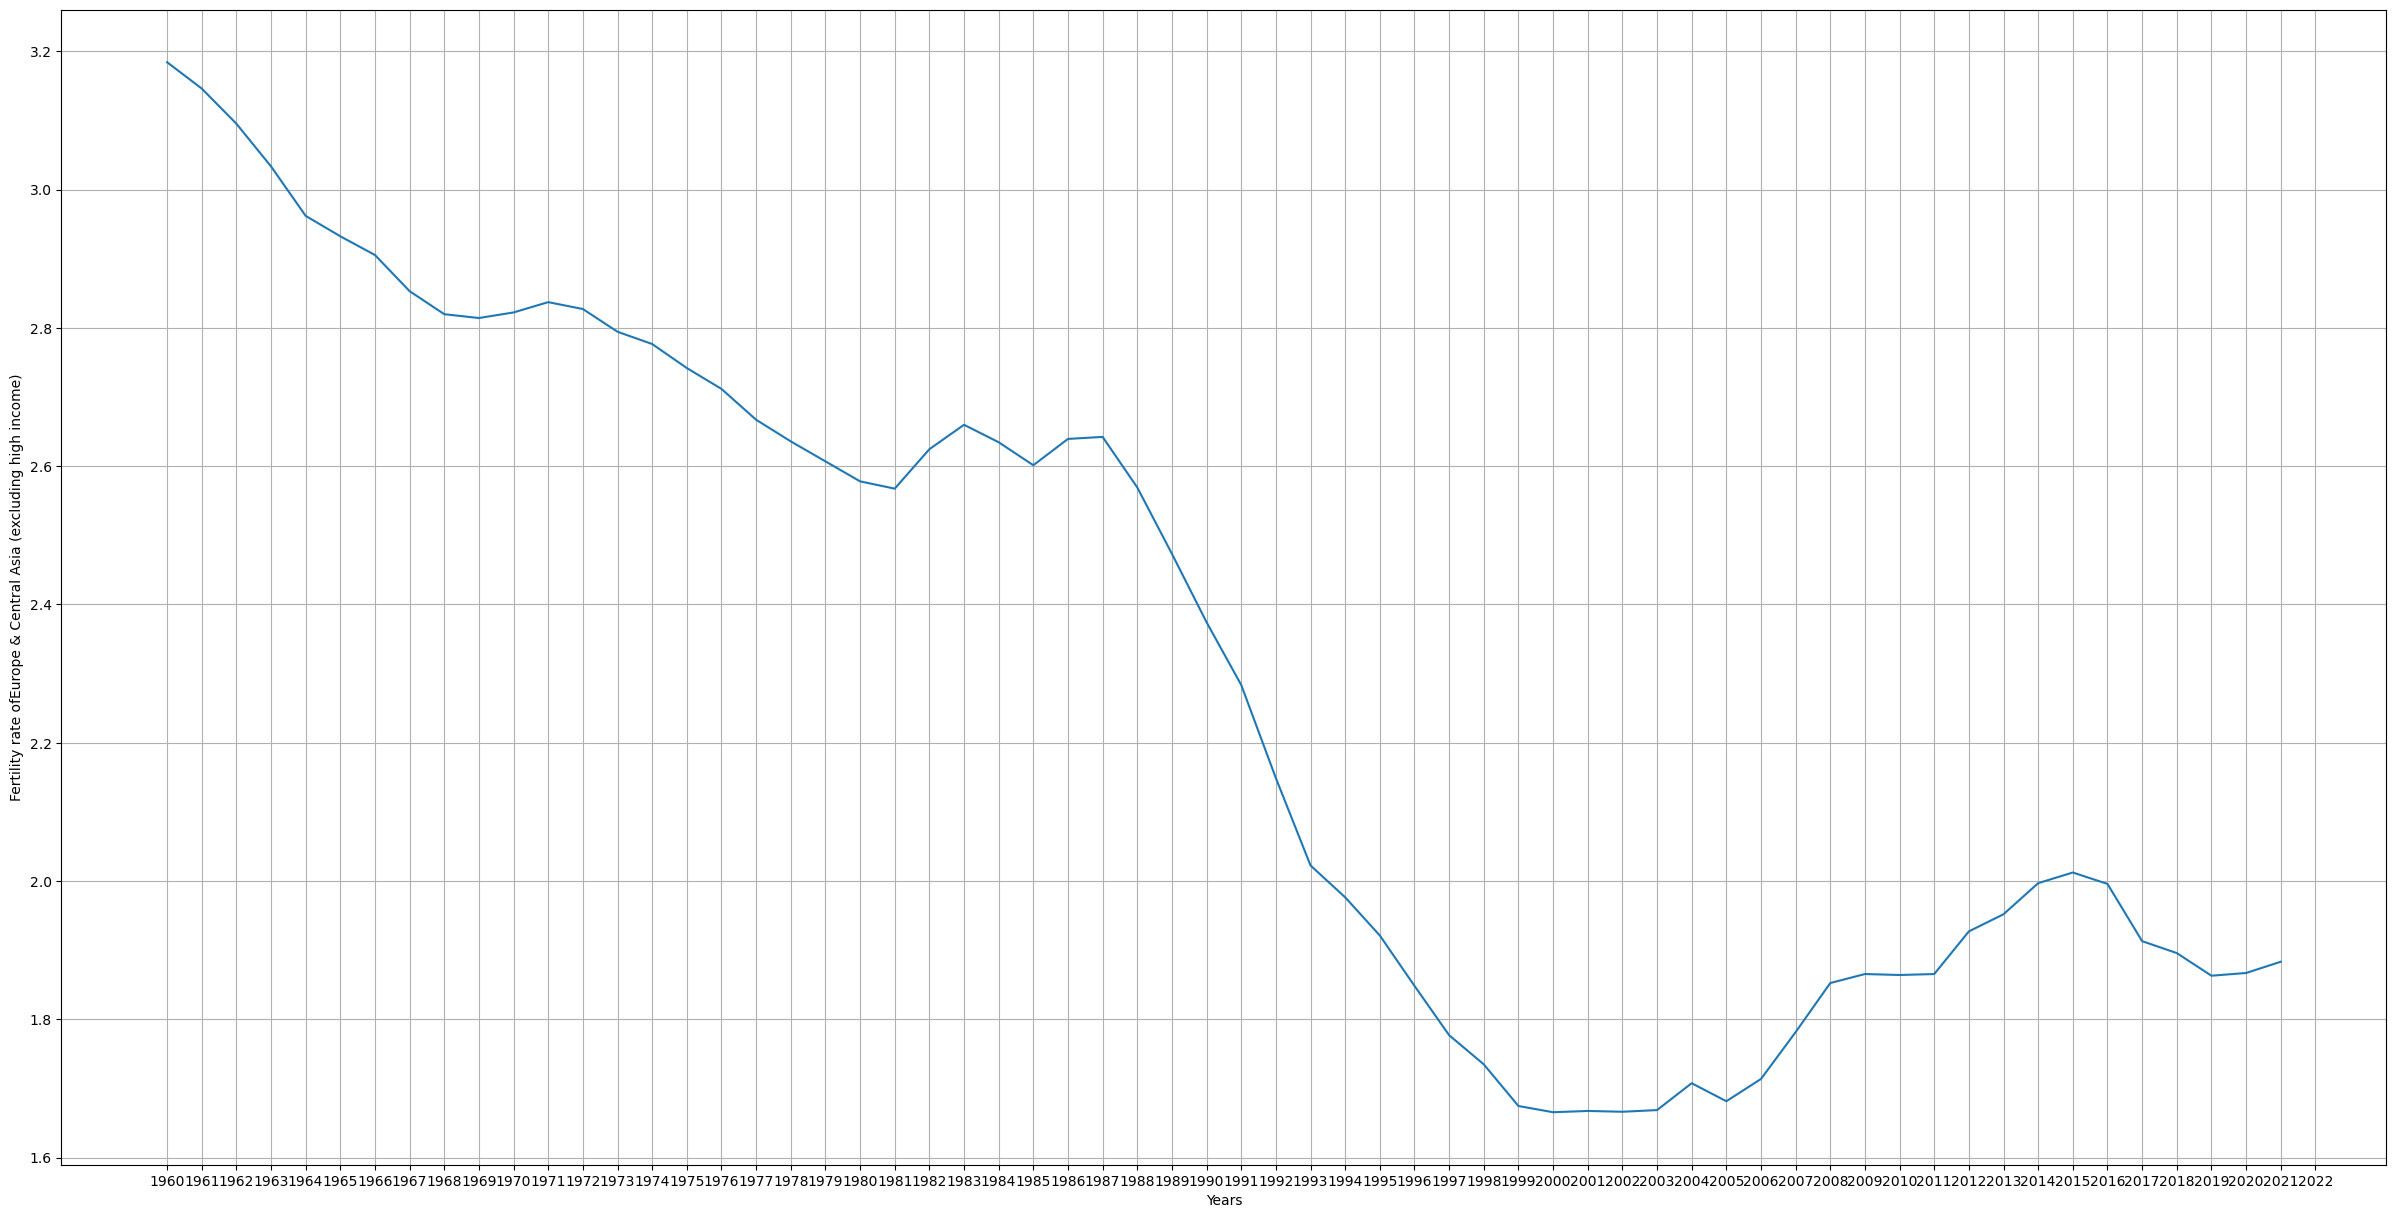

In [12]:
for i in range(0, len(df.columns)):
    plt.figure(figsize=(30,15))
    plt.grid()
    plt.xlabel("Years")
    plt.ylabel("Fertility rate of" + df_T[i]['Country Name'])
    sns.lineplot(data=df_T[i][2:])

## Work to done


There are many...


## The Following Part Is Under Perocess

**Has many errors**

In [13]:
df

,Country Name,Country Code,1960,1961,1962,1963,1964,1965,1966,1967,...,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
0,Aruba,ABW,4.820000,4.655000,4.471000,4.271000,4.059000,3.842000,3.625000,3.417000,...,2.117000,2.148000,1.972000,1.953000,1.839000,1.587000,1.486000,1.325000,1.180000,NaN
1,Africa Eastern and Southern,AFE,6.724125,6.742752,6.762930,6.778712,6.788420,6.800322,6.810571,6.818612,...,4.808821,4.739863,4.677619,4.615671,4.570410,4.527707,4.482899,4.416902,4.354710,NaN
2,Afghanistan,AFG,7.282000,7.284000,7.292000,7.302000,7.304000,7.305000,7.320000,7.339000,...,5.696000,5.560000,5.405000,5.262000,5.129000,5.002000,4.870000,4.750000,4.643000,NaN
3,Africa Western and Central,AFW,6.458448,6.471518,6.491826,6.506088,6.525355,6.541102,6.564967,6.589806,...,5.506350,5.437493,5.385059,5.328709,5.255345,5.186319,5.118932,5.049329,4.978662,NaN
4,Angola,AGO,6.708000,6.790000,6.872000,6.954000,7.036000,7.116000,7.194000,7.267000,...,5.953000,5.864000,5.774000,5.686000,5.600000,5.519000,5.442000,5.371000,5.304000,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,Kosovo,XKX,6.359000,6.350000,6.331000,6.296000,6.126000,5.927000,5.737000,5.777000,...,2.098000,1.871000,1.751000,1.658000,1.649000,1.605000,1.546000,1.529000,1.522000,NaN
262,"Yemen, Rep.",YEM,7.938000,7.963000,7.963000,7.981000,8.038000,8.067000,8.127000,8.166000,...,4.529000,4.427000,4.322000,4.214000,4.112000,4.043000,3.963000,3.886000,3.795000,NaN
263,South Africa,ZAF,6.159000,6.138000,6.110000,6.077000,6.030000,5.967000,5.907000,5.852000,...,2.428000,2.424000,2.359000,2.261000,2.334000,2.418000,2.475000,2.401000,2.374000,NaN
264,Zambia,ZMB,7.115000,7.169000,7.214000,7.249000,7.274000,7.291000,7.304000,7.317000,...,5.026000,4.899000,4.793000,4.707000,4.614000,4.536000,4.451000,4.379000,4.308000,NaN


In [14]:
df_T[1][2:] , df_T[1][0]


(1960    6.724125
 1961    6.742752
 1962     6.76293
 1963    6.778712
 1964     6.78842
           ...   
 2018    4.527707
 2019    4.482899
 2020    4.416902
 2021     4.35471
 2022         NaN
 Name: 1, Length: 63, dtype: object,
 'Africa Eastern and Southern')

In [15]:
df_T.head()

,0,1,2,3,4,5,6,7,8,9,...,256,257,258,259,260,261,262,263,264,265
Country Name,Aruba,Africa Eastern and Southern,Afghanistan,Africa Western and Central,Angola,Albania,Andorra,Arab World,United Arab Emirates,Argentina,...,Virgin Islands (U.S.),Vietnam,Vanuatu,World,Samoa,Kosovo,"Yemen, Rep.",South Africa,Zambia,Zimbabwe
Country Code,ABW,AFE,AFG,AFW,AGO,ALB,AND,ARB,ARE,ARG,...,VIR,VNM,VUT,WLD,WSM,XKX,YEM,ZAF,ZMB,ZWE
1960,4.82,6.724125,7.282,6.458448,6.708,6.455,NaN,6.934332,6.718,3.075,...,5.445,6.28,6.863,4.695876,7.646,6.359,7.938,6.159,7.115,7.22
1961,4.655,6.742752,7.284,6.471518,6.79,6.353,NaN,6.982115,6.678,3.069,...,4.893,5.476,6.818,4.575607,7.641,6.35,7.963,6.138,7.169,7.233
1962,4.471,6.76293,7.292,6.491826,6.872,6.207,NaN,7.076112,6.659,3.106,...,4.929,6.274,6.777,5.035179,7.646,6.331,7.963,6.11,7.214,7.255


In [16]:
df_country_1 = df[df['Country Name'] =='India']
df_country_2 = df[df['Country Name'] =='Argentina']
df_country_1_T = df_country_1.T
df_country_2_T = df_country_2.T
df_country_2_T

,9
Country Name,Argentina
Country Code,ARG
1960,3.075
1961,3.069
1962,3.106
...,...
2018,2.039
2019,1.994
2020,1.911
2021,1.885


In [17]:
countries = [df_country_1_T,  df_country_2_T]
df_compaire = pd.concat(countries)
df_compaire

,109,9
Country Name,India,NaN
Country Code,IND,NaN
1960,5.921,NaN
1961,5.937,NaN
1962,5.953,NaN
...,...,...
2018,NaN,2.039
2019,NaN,1.994
2020,NaN,1.911
2021,NaN,1.885


In [18]:
# plt.figure(figsize=(30,15))
# plt.grid()
# plt.xlabel("Years")
# # plt.ylabel("Fertility rate of" + df_compaire['Country Name'])
# plt.plot(np.array(df_compaire[0][2:], lable=df_compaire[0][0]))
# plt.plot(np.array(df_compaire[1][2:], lable=df_compaire[1][0]))

In [19]:
df[df['Country Name'] =='India']

,Country Name,Country Code,1960,1961,1962,1963,1964,1965,1966,1967,...,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
109,India,IND,5.921,5.937,5.953,5.969,5.979,5.941,5.881,5.825,...,2.406,2.306,2.287,2.273,2.2,2.177,2.109,2.051,2.031,NaN


In [20]:
df_T[[0,1]]


,0,1
Country Name,Aruba,Africa Eastern and Southern
Country Code,ABW,AFE
1960,4.82,6.724125
1961,4.655,6.742752
1962,4.471,6.76293
...,...,...
2018,1.587,4.527707
2019,1.486,4.482899
2020,1.325,4.416902
2021,1.18,4.35471


In [21]:
df[df['Country Name'] =='India']

,Country Name,Country Code,1960,1961,1962,1963,1964,1965,1966,1967,...,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
109,India,IND,5.921,5.937,5.953,5.969,5.979,5.941,5.881,5.825,...,2.406,2.306,2.287,2.273,2.2,2.177,2.109,2.051,2.031,NaN
